# 0. Primary run controls

This section is the notebook’s main control panel and should be edited **before running any other cells**.

It determines:
- which spaCy model is used during preprocessing
- which preprocessing profile is applied
- how broad the experiment sweep is in `full_train`
- whether the notebook performs a full candidate search or rebuilds one specific final model

## What this section controls

### spaCy model
`SPACY_MODEL_CHOICE` selects the NLP model used during preprocessing.

Options:
- `"en_core_web_sm"`: faster; useful for smoke tests, compile checks, and quick debugging
- `"en_core_web_trf"`: slower; generally preferred for full experiments and final submission runs

### Preprocessing profile
`PREPROCESS_PROFILE_CHOICE` selects the preprocessing recipe applied before training.

Options:
- `"old_baseline"`: main baseline preprocessing profile
- `"old_plus_number_token"`: baseline preprocessing plus normalization of standalone numbers into canonical number tokens

### Experiment run profile
`EXPERIMENT_RUN_PROFILE_CHOICE` controls the size of the experiment sweep in `full_train`.

Options:
- `"minimal"`: smaller, faster experiment sweep
- `"expanded"`: broader experiment sweep with additional controlled variants

## Main workflow mode

`NOTEBOOK_RUN_CONTROL["mode"]` determines the overall workflow.

### `full_train`
Use `full_train` when you want the notebook to run the complete model-selection pipeline. In this mode, the notebook will:
- run the full experiment search
- compare candidate systems
- rank candidates
- choose the best candidate automatically
- train and materialize the selected best candidate at the end

Important:
- in `full_train`, the notebook follows the **experiment search and ranking workflow**
- `exact_final_model_config` is **not intended to determine model selection in this mode**

### `submit_mode`
Use `submit_mode` when you do **not** want to rerun the full experiment search.

In `submit_mode`, the notebook skips the heavy candidate-search sections and instead does one of the following:

1. **If `exact_final_model_config` is not `None`**  
   Rebuilds and trains **exactly that one model** for submission.

2. **If `exact_final_model_config` is `None` and `saved_candidate_slug` is set**  
   Attempts to load the saved candidate corresponding to that slug.

So, in practice, `submit_mode` is intended for:
- rebuilding one exact known model
- optionally loading one previously saved candidate
- avoiding a full experiment rerun

## Important note about saved candidates

In this environment, saved notebook versions typically start from a **fresh session**. This means that candidate artifacts created during a previous interactive run are usually **not available automatically** in a later version run unless they were explicitly persisted and reattached.

As a result, the two main intended workflows are:

- **`full_train`**: run the full experiment search and let the notebook choose the best candidate automatically
- **`submit_mode` with `exact_final_model_config`**: rebuild one exact final model directly, without rerunning the full search

In other words, while `saved_candidate_slug` remains supported in the code, the most reliable submit workflow in this environment is usually to provide an explicit `exact_final_model_config`.

In [1]:
# --------------------------------------------------
# Primary run controls (edit this cell first)
# --------------------------------------------------

# Use "en_core_web_sm" for fast compile / smoke tests.
# Use "en_core_web_trf" for stronger tests.
SPACY_MODEL_CHOICE = "en_core_web_sm" # I tried with trf model and it took 3 hours without real improvement

# Separate spaCy model choice for EDA sections that use linguistic filtering.
# This can stay on TRF even if the main pipeline uses "en_core_web_sm".
EDA_SPACY_MODEL_CHOICE = "en_core_web_sm"

# Preprocessing profile:
# - "old_baseline": closest to the older stronger-scoring notebook
# - "old_plus_number_token": same old feature logic, but also normalize standalone numbers
PREPROCESS_PROFILE_CHOICE = "old_plus_number_token"

# Which experiment set to run in full_train mode:
# - "minimal": faster baseline search
# - "expanded": old strong presets + a few controlled extra variants
EXPERIMENT_RUN_PROFILE_CHOICE = "expanded"

# Default exact submit config: the stronger old-style model 
OLD_STRONG_EXACT_FINAL_MODEL_CONFIG = {
    "experiment_name": "text_plus_all_features",
    "representation_name": "qa_dual_tfidf",
    "variant_label": "dual_base",
    "candidate_slug": "text_plus_all_features__qa_dual_tfidf__dual_base",
    "source_stage": "exact_config",
    "model_params": {
        "C": 2.0,
        "solver": "liblinear",
        "max_iter": 4000,
        "class_weight": "balanced",
        "random_state": 42,
        "penalty": "l2",
    },
    "experiment_config": {
        "text_col": "qa_processed",
        "use_engineered_features": True,
        "feature_groups": [
            "punctuation",
            "surface_patterns",
            "question_intent",
            "answer_evidence",
            "qa_alignment",
            "overlap",
            "qa_pair_structure",
            "reply_style",
            "answer_group",
        ],
    },
    "selected_feature_cols": None,
    "dual_tfidf_config": {},
    "notes": "Default exact submit config matching the stronger old notebook recipe.",
}

# Main workflow control.
# - "full_train": run the full experiment search / analysis notebook
# - "submit_mode": skip the heavy search sections and rebuild only the exact
#                  final config below (or load a saved candidate if exact config is None)
NOTEBOOK_RUN_CONTROL = {
    "mode": "full_train",
    "manual_candidate": None,
    "exact_final_model_config": None,
    "saved_candidate_slug": None,
    "persist_top_k_candidates": 0,
    "persist_candidate_artifacts": True,
    "persist_full_inference_bundle": True,
    "persist_candidate_csvs": True,
    "submit_mode_fallback_rebuild": False,
}

RUN_MODE = NOTEBOOK_RUN_CONTROL.get("mode", "full_train")
IS_SUBMIT_MODE = RUN_MODE == "submit_mode"

print("Run mode:", RUN_MODE)
print("Main spaCy model choice:", SPACY_MODEL_CHOICE)
print("EDA spaCy model choice:", EDA_SPACY_MODEL_CHOICE)
print("Preprocess profile:", PREPROCESS_PROFILE_CHOICE)
if IS_SUBMIT_MODE:
    print("Submit mode exact config:",
          NOTEBOOK_RUN_CONTROL.get("exact_final_model_config", {}).get("candidate_slug"))


Run mode: full_train
Main spaCy model choice: en_core_web_sm
EDA spaCy model choice: en_core_web_sm
Preprocess profile: old_plus_number_token


In [2]:
# --------------------------------------------------
# spaCy bootstrap (must run before the first import spacy)
# --------------------------------------------------

import sys

SPACY_MODELS_TO_DOWNLOAD = sorted({EDA_SPACY_MODEL_CHOICE, SPACY_MODEL_CHOICE})

for model_name in SPACY_MODELS_TO_DOWNLOAD:
    print(f"Ensuring spaCy model is available: {model_name}")
    !{sys.executable} -m spacy download {model_name}

Ensuring spaCy model is available: en_core_web_sm
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 71.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# --------------------------------------------------
# Shared spaCy model loader
# --------------------------------------------------

def load_requested_spacy_model(model_name):
    try:
        import spacy
        if model_name == "en_core_web_trf":
            import spacy_curated_transformers  # registers curated_transformer
            import en_core_web_trf
            return en_core_web_trf.load()
        return spacy.load(model_name)
    except Exception as e:
        raise RuntimeError(
            f"Failed to load requested spaCy model: {model_name}\n"
            f"Original error: {repr(e)}"
        )

# 1. Load dataset and remove known corrupted training rows

We first load the QEvasion dataset from Hugging Face and convert the train and test splits to pandas dataframes.

At load time, we also remove a small set of known corrupted training rows whose answer text is visibly damaged.
These rows are identified explicitly by their dataset `index` values.

After loading and cleaning, we:
- add split-tracking columns
- preserve original row order inside each split
- define the target column
- create normalized text/grouping columns used later in the notebook

In [4]:
from datasets import load_dataset
import pandas as pd
import re

pd.set_option("display.max_colwidth", 300)

In [5]:
# -------------------------
# Load dataset
# -------------------------
ds = load_dataset("ailsntua/QEvasion")

df_train_raw = ds["train"].to_pandas().copy()
df_test = ds["test"].to_pandas().copy()

df_train = df_train_raw.copy()

# -------------------------
# Remove known corrupted training rows
# These are removed by the dataset's explicit `index` column.
# -------------------------
CORRUPTED_TRAIN_INDEX_VALUES = list(range(1870, 1884))  # 1870 ... 1883 inclusive

train_shape_before = df_train.shape

df_train = df_train.loc[~df_train["index"].isin(CORRUPTED_TRAIN_INDEX_VALUES)].copy()

train_shape_after = df_train.shape
num_removed = train_shape_before[0] - train_shape_after[0]

print("Train shape before removing corrupted rows:", train_shape_before)
print("Train shape after removing corrupted rows :", train_shape_after)
print("Number of corrupted train rows removed    :", num_removed)

assert num_removed == len(CORRUPTED_TRAIN_INDEX_VALUES), (
    f"Expected to remove {len(CORRUPTED_TRAIN_INDEX_VALUES)} rows, "
    f"but removed {num_removed}."
)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

Train shape before removing corrupted rows: (3448, 20)
Train shape after removing corrupted rows : (3434, 20)
Number of corrupted train rows removed    : 14


In [6]:
# -------------------------
# Add split identifiers
# -------------------------
df_train["split"] = "train"
df_test["split"] = "test"

# Preserve original row position inside each cleaned split
df_train["orig_row"] = range(len(df_train))
df_test["orig_row"] = range(len(df_test))

# Target column
TARGET_COL = "clarity_label"

print("Cleaned train shape:", df_train.shape)
print("Test shape         :", df_test.shape)

Cleaned train shape: (3434, 22)
Test shape         : (308, 22)


In [7]:
# -------------------------
# Quick sanity checks
# -------------------------
print("Train columns:")
print(df_train.columns.tolist())

print("\nTest columns:")
print(df_test.columns.tolist())

print("\nTrain label values:")
print(sorted(df_train[TARGET_COL].dropna().astype(str).unique().tolist()))

print("\nTest label values:")
print(sorted(df_test[TARGET_COL].dropna().astype(str).unique().tolist()))

Train columns:
['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label', 'split', 'orig_row']

Test columns:
['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label', 'split', 'orig_row']

Train label values:
['Ambivalent', 'Clear Non-Reply', 'Clear Reply']

Test label values:
['Ambivalent', 'Clear Non-Reply', 'Clear Reply']


In [8]:
CLASS_LABELS = [
    "Ambivalent",
    "Clear Reply",
    "Clear Non-Reply",
]

print("CLASS_LABELS:", CLASS_LABELS)

CLASS_LABELS: ['Ambivalent', 'Clear Reply', 'Clear Non-Reply']


In [9]:
# -------------------------
# Normalized text columns used later
# -------------------------
def norm_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x

for df in (df_train, df_test):
    df["answer_norm"] = df["interview_answer"].map(norm_text)
    df["question_norm"] = df["question"].map(norm_text)
    df["turn_key"] = (
        df["url"].fillna("").astype(str)
        + " || "
        + df["question_order"].fillna(-1).astype(str)
    )
    df["answer_group"] = df["turn_key"] + " || " + df["answer_norm"]

In [10]:
display(df_train.head(3))
display(df_test.head(3))

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,affirmative_questions,index,clarity_label,evasion_label,split,orig_row,answer_norm,question_norm,turn_key,answer_group
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-hanoi-vietnam-0,1,Q. Of the Biden administration. And accused the United States of containing China while pushing for diplomatic talks.How would you respond to that? And do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?,"Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now...",The question consists of 2 parts: \n1. How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?\n2. Do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?\n\nThe response pro...,Question part: 1. How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?\nVerdict: 1.1 Explicit - The information requested is explicitly stated (in the requested form)\nExplanation: The President directly responds to the accusation...,How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?,...,False,0,Clear Reply,Explicit,train,0,"well, look, first of all, thei am sincere about getting the relationship right. and one of the things that is going on now is, china is beginning to change some of the rules of the game, in terms of trade and other issues.and so one of the things we talked about, for example, is that they're now...",how would you respond to the accusation that the united states is containing china while pushing for diplomatic talks?,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-hanoi-vietnam-0 || 1,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-hanoi-vietnam-0 || 1 || well, look, first of all, thei am sincere about getting the relationship right. and one of the things that is going on now is, china is beginning to change some of the rules of the game, in terms of ..."
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-hanoi-vietnam-0,1,Q. Of the Biden administration. And accused the United States of containing China while pushing for diplomatic talks.How would you respond to that? And do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?,"Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now...",The question consists of 2 parts: \n1. How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?\n2. Do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?\n\nThe response pro...,Question part: 1. How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?\nVerdict: 1.1 Explicit - The information requested is explicitly stated (in the requested form)\nExplanation: The President directly responds to the accusation...,Do you think President Xi is being sincere about getting the relationship back 

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,affirmative_questions,index,clarity_label,evasion_label,split,orig_row,answer_norm,question_norm,turn_key,answer_group
0,None,None,None,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-3,5,"Q. What about the redline, sir?","Well, the world has made it clear that these tests caused us to come together and work in the United Nations to send a clear message to the North Korean regime. We're bound up together with a common strategy to solve this issue peacefully through diplomatic means.Kevin [Kevin Corke, NBC News].",None,None,Inquiring about the status or information regarding the redline.,...,True,0,Ambivalent,,test,0,"well, the world has made it clear that these tests caused us to come together and work in the united nations to send a clear message to the north korean regime. we're bound up together with a common strategy to solve this issue peacefully through diplomatic means.kevin [kevin corke, nbc news].",inquiring about the status or information regarding the redline.,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-3 || 5,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-3 || 5 || well, the world has made it clear that these tests caused us to come together and work in the united nations to send a clear message to the north korean regime. we're bound up together with a common strategy to so..."
1,None,None,None,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-lee-myung-bak-south-korea,2,Q. Will you invite them to the White House to negotiate on the jobs bill?,"I think that anytime and anyplace that they are serious about working on putting people back to work, we'll be prepared to work with them. But we're not going to create a lot of theater that then results in them engaging in the usual political talking points, but don't result in action.People wa...",None,None,Will you invite them to the White House to negotiate on the jobs bill?,...,False,1,Ambivalent,,test,1,"i think that anytime and anyplace that they are serious about working on putting people back to work, we'll be prepared to work with them. but we're not going to create a lot of theater that then results in them engaging in the usual political talking points, but don't result in action.people wa...",will you invite them to the white house to negotiate on the jobs bill?,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-lee-myung-bak-south-korea || 2,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-lee-myung-bak-south-korea || 2 || i think that anytime and anyplace that they are serious about working on putting people back to work, we'll be prepared to work with them. but we're not going to create a lot..."
2,None,None,None,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-chicago,1,"Q. Harsh. Mr. President, Japan has dropped the threat of sanctions from its proposed Security Council resolution about North Korea. Why was that necessary? And how do you punish or penalize a country that's already among the poorest and most isolated in the world?","I think that the purpose of the U.N. Security Council resolution is to send a clear message to the leader of that the world condemns that which he did. Part of our strategy, as you know, has been to have others at the table, is to say as clearly as possible to the n, Get rid of your weapons, and...",None,None,Why was it necessary for Japan to drop the threat of sanctions from its proposed Security Council resolution about North Korea?,...,False,2,Ambivalent,,test,2,"i think that the purpose of the u.n. security council resolution is to send a clear message to the leader of that the world condemns that which he did. part of our strategy, as you know, has been to have others at the table, is to

# 2. Data Understanding

This section provides an initial understanding of the dataset before modeling.

The goal is twofold:
1. describe the main statistical properties of the training data
2. motivate later preprocessing and feature-engineering decisions

Since the supervised instances are `(question, interview_answer)` pairs, the analysis focuses on:
- class distribution
- question/answer length
- metadata fields such as `multiple_questions`, `affirmative_questions`, and `inaudible`
- repeated-answer structure
- surface patterns such as punctuation, numbers, and temporal expressions
- identification of a small set of corrupted training rows

These analyses later justify choices such as:
- stratified train/validation splitting
- keeping question and answer separate before concatenation
- preserving punctuation-related cues
- adding surface-pattern normalization
- adding question-intent / answer-evidence / alignment features
- adding answer-group count features
- removing a very small number of clearly corrupted training rows

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

pd.set_option("display.max_colwidth", 300)

### Setup for data understanding

Because the final modeling dataframe has already been cleaned, we use:
- `df_train_raw` for descriptive analysis of the original train split
- `df_train` for analysis of the cleaned train split used in modeling

If `df_train_raw` is not available, the section falls back to `df_train`.

In [12]:
if "df_train_raw" in globals():
    df_train_analysis = df_train_raw.copy()
else:
    df_train_analysis = df_train.copy()

print("Raw-analysis train shape:", df_train_analysis.shape)
print("Cleaned-modeling train shape:", df_train.shape)

Raw-analysis train shape: (3448, 20)
Cleaned-modeling train shape: (3434, 26)


### 1. Basic overview and label distribution

We first inspect the size of each split and the distribution of the target labels.

This is important because:
- it gives a first idea of task balance
- it motivates the use of stratified splitting
- it helps explain why macro-F1 is useful in addition to accuracy

Raw-analysis train shape: (3448, 20)
Cleaned-modeling train shape: (3434, 26)
Test shape: (308, 26)

Cleaned train label counts:


clarity_label
Ambivalent         2030
Clear Reply        1049
Clear Non-Reply     355
Name: count, dtype: int64


Cleaned train label proportions:


clarity_label
Ambivalent         0.591147
Clear Reply        0.305475
Clear Non-Reply    0.103378
Name: proportion, dtype: float64

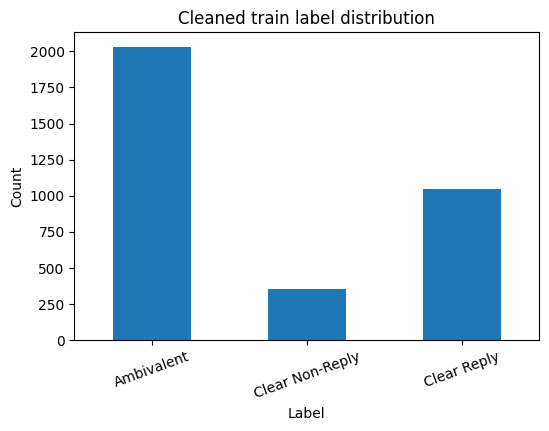

In [13]:
TARGET_COL = "clarity_label"

print("Raw-analysis train shape:", df_train_analysis.shape)
print("Cleaned-modeling train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nCleaned train label counts:")
display(df_train[TARGET_COL].value_counts())

print("\nCleaned train label proportions:")
display(df_train[TARGET_COL].value_counts(normalize=True).rename("proportion"))

fig, ax = plt.subplots(figsize=(6, 4))
df_train[TARGET_COL].value_counts().reindex(sorted(df_train[TARGET_COL].unique())).plot(
    kind="bar", ax=ax
)
ax.set_title("Cleaned train label distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.show()

### 2. Length statistics for questions and answers

We inspect text lengths in both words and characters.

This helps answer:
- whether answers are much longer than questions
- whether there is large variability in input size
- whether it makes sense to preserve both question and answer explicitly in the input

In [14]:
def word_len(x):
    if pd.isna(x):
        return 0
    return len(str(x).split())

def char_len(x):
    if pd.isna(x):
        return 0
    return len(str(x))

for df in (df_train_analysis, df_train, df_test):
    df["question_word_len"] = df["question"].apply(word_len)
    df["answer_word_len"] = df["interview_answer"].apply(word_len)
    df["question_char_len"] = df["question"].apply(char_len)
    df["answer_char_len"] = df["interview_answer"].apply(char_len)

length_summary = pd.DataFrame({
    "question_word_len": df_train["question_word_len"].describe(),
    "answer_word_len": df_train["answer_word_len"].describe(),
    "question_char_len": df_train["question_char_len"].describe(),
    "answer_char_len": df_train["answer_char_len"].describe(),
})

display(length_summary)

,question_word_len,answer_word_len,question_char_len,answer_char_len
count,3434.000000,3434.000000,3434.000000,3434.000000
mean,14.445836,290.447583,84.399243,1646.749272
std,8.840504,298.148575,51.914407,1717.289448
min,1.000000,1.000000,3.000000,3.000000
25%,8.000000,56.000000,47.000000,304.000000
50%,12.000000,206.000000,74.000000,1142.000000
75%,19.000000,439.000000,109.000000,2483.750000
max,80.000000,2117.000000,464.000000,12102.000000


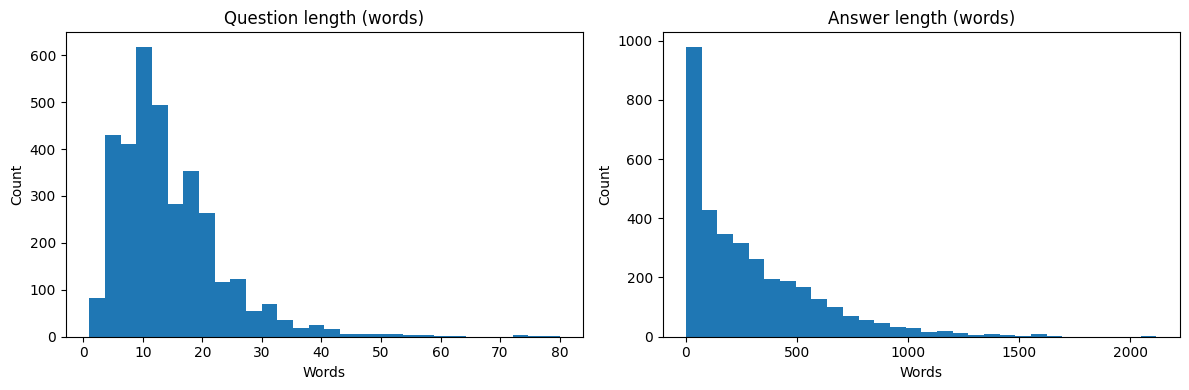

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train["question_word_len"], bins=30)
axes[0].set_title("Question length (words)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")

axes[1].hist(df_train["answer_word_len"], bins=30)
axes[1].set_title("Answer length (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [16]:
length_by_label = (
    df_train.groupby(TARGET_COL)[["question_word_len", "answer_word_len"]]
    .agg(["mean", "median", "std"])
)

display(length_by_label)

question_word_len                  answer_word_len         \
                             mean median       std            mean median   
clarity_label                                                               
Ambivalent              15.273892   13.0  9.138325      328.270936  241.5   
Clear Non-Reply         12.630986   11.0  7.861560      135.208451   39.0   
Clear Reply             13.457579   12.0  8.368902      269.788370  194.0   

                             
                        std  
clarity_label                
Ambivalent       316.187061  
Clear Non-Reply  212.091232  
Clear Reply      266.604145

### 3. Metadata fields

The dataset also includes metadata flags such as:
- `multiple_questions`
- `affirmative_questions`
- `inaudible`

These are useful to inspect even if not all are used directly, because they describe the difficulty and structure of the task.

In [17]:
meta_cols = ["multiple_questions", "affirmative_questions", "inaudible"]

for col in meta_cols:
    print(f"\n=== {col} ===")
    print(df_train[col].value_counts(dropna=False))
    print(df_train[col].value_counts(normalize=True, dropna=False).rename("proportion"))


=== multiple_questions ===
multiple_questions
False    3348
True       86
Name: count, dtype: int64
multiple_questions
False    0.974956
True     0.025044
Name: proportion, dtype: float64

=== affirmative_questions ===
affirmative_questions
False    2662
True      772
Name: count, dtype: int64
affirmative_questions
False    0.775189
True     0.224811
Name: proportion, dtype: float64

=== inaudible ===
inaudible
False    3389
True       45
Name: count, dtype: int64
inaudible
False    0.986896
True     0.013104
Name: proportion, dtype: float64


In [18]:
for col in meta_cols:
    print(f"\n=== {col} by label (row-normalized) ===")
    ct = pd.crosstab(df_train[col], df_train[TARGET_COL], normalize="index")
    display(ct)


=== multiple_questions by label (row-normalized) ===


clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
multiple_questions,,,
False,0.587814,0.104241,0.307945
True,0.720930,0.069767,0.209302



=== affirmative_questions by label (row-normalized) ===


clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
affirmative_questions,,,
False,0.604433,0.096168,0.299399
True,0.545337,0.128238,0.326425



=== inaudible by label (row-normalized) ===


clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
inaudible,,,
False,0.59103,0.104161,0.304810
True,0.60000,0.044444,0.355556


### 4. Detecting corrupted rows with an OOV-based analysis

Before modeling, we also inspect whether there are clearly corrupted transcript rows.

The intuition is:
- the text is generally close to normal English
- many non-dictionary tokens are still legitimate names, places, organizations, or domain-specific terms
- however, rows with a very high out-of-vocabulary (OOV) ratio in long answers are suspicious

To surface such cases, we compare answer tokens against an external word list and inspect rows with unusually high OOV ratios.

In [19]:
# External word list used only for data-understanding / corruption discovery
words_pos = pd.read_csv("/kaggle/input/datasets/ruchi798/part-of-speech-tagging/words_pos.csv")

print(words_pos.head())
print(words_pos.columns.tolist())
print(words_pos.shape)

   Unnamed: 0    word pos_tag
0           0      aa      NN
1           1     aaa      NN
2           2     aah      NN
3           3   aahed     VBN
4           4  aahing     VBG
['Unnamed: 0', 'word', 'pos_tag']
(370100, 3)


In [20]:
english_vocab = set(
    words_pos["word"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
    .tolist()
)

print("Vocabulary size used for OOV analysis:", len(english_vocab))

Vocabulary size used for OOV analysis: 370100


In [21]:
def tokenize_for_oov(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text)

def count_oov_tokens(tokens, vocab):
    # ignore very short tokens because they are often fragments or initials
    filtered = [tok for tok in tokens if len(tok) >= 2]
    oov = [tok for tok in filtered if tok not in vocab]
    return filtered, oov

df_train_analysis["answer_tokens_oov"] = df_train_analysis["interview_answer"].apply(tokenize_for_oov)

token_stats = df_train_analysis["answer_tokens_oov"].apply(
    lambda toks: count_oov_tokens(toks, english_vocab)
)

df_train_analysis["answer_token_count"] = token_stats.apply(lambda x: len(x[0]))
df_train_analysis["answer_oov_count"] = token_stats.apply(lambda x: len(x[1]))
df_train_analysis["answer_oov_ratio"] = df_train_analysis.apply(
    lambda row: row["answer_oov_count"] / row["answer_token_count"]
    if row["answer_token_count"] > 0 else 0.0,
    axis=1
)

display(
    df_train_analysis[
        ["index", "answer_token_count", "answer_oov_count", "answer_oov_ratio"]
    ].describe()
)

,index,answer_token_count,answer_oov_count,answer_oov_ratio
count,3448.000000,3448.000000,3448.000000,3448.000000
mean,1723.500000,287.138631,14.471288,0.059293
std,995.496191,296.497339,22.746131,0.057850
min,0.000000,0.000000,0.000000,0.000000
25%,861.750000,54.750000,3.000000,0.032287
50%,1723.500000,200.500000,10.000000,0.049170
75%,2585.250000,432.000000,20.000000,0.070016
max,3447.000000,2074.000000,306.000000,1.000000


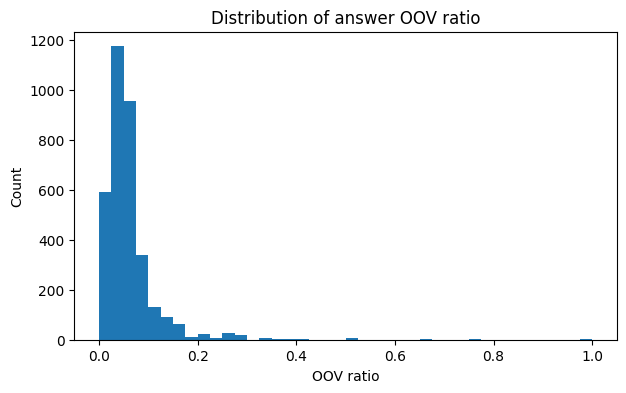

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_train_analysis["answer_oov_ratio"], bins=40)
ax.set_title("Distribution of answer OOV ratio")
ax.set_xlabel("OOV ratio")
ax.set_ylabel("Count")
plt.show()

In [23]:
# Focus on rows where the answer is long enough to make the OOV ratio meaningful
noisy_rows = df_train_analysis[
    (df_train_analysis["answer_token_count"] >= 20) &
    (df_train_analysis["answer_oov_ratio"] >= 0.20)
].copy()

display(
    noisy_rows[
        [
            "index",
            "question",
            "interview_answer",
            "answer_oov_count",
            "answer_token_count",
            "answer_oov_ratio",
            "clarity_label",
        ]
    ]
    .sort_values("answer_oov_ratio", ascending=False)
    .head(20)
)

,index,question,interview_answer,answer_oov_count,answer_token_count,answer_oov_ratio,clarity_label
1870,1870,Do you think that the agreement should be amended to address currency manipulation?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Clear Reply
1871,1871,Can you comment on whether this signals a new offensive in Afghanistan?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Clear Reply
1872,1872,Are you looking to change your strategy in how you seek approval for the Trans-Pacific Partnership in Congress?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1873,1873,Can you comment on the killing of Taliban leader Mullah Mansur and on Pakistan's concern about that strike happening on its soil?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1874,1874,Are you concerned that an even more hardline leader might take his place?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Clear Non-Reply
1875,1875,Are you concerned about the lack of enthusiasm for the Trans-Pacific Partnership in the U.S. Congress and what that means for the deal in the end?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1876,1876,"How do you respond to China's criticism of the U.S. pursuing what China says is a one-sided, selfish agenda in Asia that risks regional peace?","So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1877,1877,Are you looking to change your strategy in how you seek approval for the Trans-Pacific Partnership in Congress?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1878,1878,Can you comment on whether this signals a new offensive in Afghanistan?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they

In [24]:
# The rows identified and removed during loading
CORRUPTED_TRAIN_INDEX_VALUES = list(range(1870, 1884))

corrupted_rows_for_report = df_train_analysis[
    df_train_analysis["index"].isin(CORRUPTED_TRAIN_INDEX_VALUES)
].copy()

print("Known corrupted rows found in raw train:", len(corrupted_rows_for_report))

display(
    corrupted_rows_for_report[
        [
            "index",
            "question",
            "interview_answer",
            "answer_oov_count",
            "answer_token_count",
            "answer_oov_ratio",
            "clarity_label",
        ]
    ].sort_values("index")
)

Known corrupted rows found in raw train: 14


,index,question,interview_answer,answer_oov_count,answer_token_count,answer_oov_ratio,clarity_label
1870,1870,Do you think that the agreement should be amended to address currency manipulation?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Clear Reply
1871,1871,Can you comment on whether this signals a new offensive in Afghanistan?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Clear Reply
1872,1872,Are you looking to change your strategy in how you seek approval for the Trans-Pacific Partnership in Congress?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1873,1873,Can you comment on the killing of Taliban leader Mullah Mansur and on Pakistan's concern about that strike happening on its soil?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1874,1874,Are you concerned that an even more hardline leader might take his place?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Clear Non-Reply
1875,1875,Are you concerned about the lack of enthusiasm for the Trans-Pacific Partnership in the U.S. Congress and what that means for the deal in the end?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1876,1876,"How do you respond to China's criticism of the U.S. pursuing what China says is a one-sided, selfish agenda in Asia that risks regional peace?","So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1877,1877,Are you looking to change your strategy in how you seek approval for the Trans-Pacific Partnership in Congress?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re go...",306,1042,0.293666,Ambivalent
1878,1878,Can you comment on whether this signals a new offensive in Afghanistan?,"So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they

In [25]:
print("OOV summary for known corrupted rows:")
display(
    corrupted_rows_for_report[
        ["answer_oov_count", "answer_token_count", "answer_oov_ratio"]
    ].describe()
)

print("\nRows removed from cleaned training set:", len(CORRUPTED_TRAIN_INDEX_VALUES))
print("Do any of these remain in cleaned df_train?",
      df_train["index"].isin(CORRUPTED_TRAIN_INDEX_VALUES).any())

OOV summary for known corrupted rows:


,answer_oov_count,answer_token_count,answer_oov_ratio
count,14.0,14.0,14.000000
mean,306.0,1042.0,0.293666
std,0.0,0.0,0.000000
min,306.0,1042.0,0.293666
25%,306.0,1042.0,0.293666
50%,306.0,1042.0,0.293666
75%,306.0,1042.0,0.293666
max,306.0,1042.0,0.293666



Rows removed from cleaned training set: 14
Do any of these remain in cleaned df_train? False


### Interpretation of the corrupted-row analysis

The OOV-based inspection does not serve as a production preprocessing rule.  
Instead, it is used here as a **data-understanding diagnostic**:

- most rows do not have unusually large OOV ratios
- a small set of long-answer rows stands out clearly
- manual inspection of those rows shows systematic character deletion, specifically answers where the letter `a` appears to have been removed across many words

Because these rows are visibly corrupted rather than naturally noisy, they were removed explicitly from the training set during loading.

This cleaning decision is intentionally conservative:
- only the known corrupted rows are removed
- no broad automatic OOV-based filtering is applied to the rest of the data

### 5. Repeated-answer structure

Because the dataset uses segmented `question` fields, the same interview answer may appear across multiple rows when one journalist turn is broken into multiple sub-questions.

This is important because it motivates the answer-group features:
- `answer_n_subquestions_total`
- `answer_n_unique_subquestions`

In [26]:
answer_group_stats = (
    df_train.groupby("answer_group", dropna=False)
    .agg(
        n_rows=("question", "size"),
        n_unique_questions=("question_norm", "nunique"),
        url=("url", "first"),
        question_order=("question_order", "first"),
        answer_preview=("interview_answer", lambda s: s.iloc[0][:180].replace("\n", " "))
    )
    .reset_index()
)

print("Number of unique answer groups:", len(answer_group_stats))
print("Number of answer groups with >1 sub-question:", (answer_group_stats["n_rows"] > 1).sum())

display(
    answer_group_stats["n_rows"].value_counts().sort_index().rename("num_answer_groups")
)

Number of unique answer groups: 2061
Number of answer groups with >1 sub-question: 939


n_rows
1     1122
2      662
3      177
4       71
5       16
6        8
8        3
9        1
12       1
Name: num_answer_groups, dtype: int64

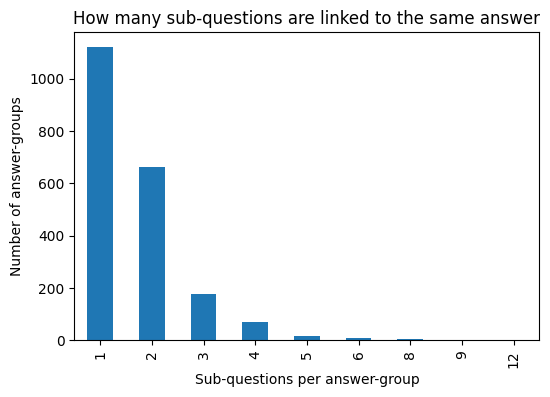

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
answer_group_stats["n_rows"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("How many sub-questions are linked to the same answer")
ax.set_xlabel("Sub-questions per answer-group")
ax.set_ylabel("Number of answer-groups")
plt.show()

In [28]:
display(
    answer_group_stats
    .sort_values(["n_rows", "n_unique_questions"], ascending=False)
    .head(15)
)

,answer_group,n_rows,n_unique_questions,url,question_order,answer_preview
1720,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-john-agyekum-kufuor-ghana-accra || 2 || thanks. i actually went to africa on the first lap of my presidency too. this is my second trip to the continent of africa, and i've come to remind our fellow citizens ...",12,6,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-john-agyekum-kufuor-ghana-accra,2,"Thanks. I actually went to Africa on the first lap of my Presidency too. This is my second trip to the continent of Africa, and I've come to remind our fellow citizens that it is i"
32,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference || 9 || i am—what i hear from commanders is that the place where there is concern is with the family members, that our troops, who have volunteered to serve the country, are willing to go into combat multiple times, but tha...",9,6,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference,9,"I am—what I hear from commanders is that the place where there is concern is with the family members, that our troops, who have volunteered to serve the country, are willing to go"
62,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-1084 || 1 || well, first of all, let's be clear: chelsea manning has served a tough prison sentence. so the notion that the average person who was thinking about disclosing vital, classified information would think that it ...",8,8,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-1084,1,"Well, first of all, let's be clear: Chelsea Manning has served a tough prison sentence. So the notion that the average person who was thinking about disclosing vital, classified in"
429,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-1140 || 1 || good. one of the great things about the united states is that when it comes to world affairs, the president obviously is the leader of the executive branch, the commander in chief, the spokesperson for the nati...",8,4,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-1140,1,"Good. One of the great things about the United States is that when it comes to world affairs, the President obviously is the leader of the executive branch, the Commander in Chief,"
1886,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-prime-minister-ehud-olmert-israel-jerusalem || 3 || yes.[],8,4,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-prime-minister-ehud-olmert-israel-jerusalem,3,Yes.[]
509,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-1151 || 15 || i just had lunch with pete rouse, who is leaving me. and that's tough.",6,6,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-1151,15,"I just had lunch with Pete Rouse, who is leaving me. And that's tough."
1503,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-washington-dc || 2 || i'd rather answer that at a little bit different time. we're looking at a lot of different things, including cabinet. i'm very happy with most of my cabinet. we're looking at different people for diffe...",6,6,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-washington-dc,2,"I'd rather answer that at a little bit different time. We're looking at a lot of different things, including Cabinet. I'm very happy with most of my Cabinet. We're looking at diffe"
1647,"https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-emmanuel-macron-france || 5 || yes, definitely. i believe the reason why we enjoy this relationship is because of the relationship between our two countries. indeed, we have a different background, but it is ...",6,6,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-emmanuel-macron-f

### 6. Question type / intent analysis

We inspect how often questions begin with forms such as:
- when
- why
- how many
- how much
- yes/no auxiliaries

This motivates the question-intent feature family and later QA-alignment features.

In [29]:
def question_type(q):
    if pd.isna(q):
        return "other"
    q = str(q).strip().lower()
    q = re.sub(r"^[^a-z0-9]+", "", q)

    if re.match(r"^how many\b", q):
        return "how_many"
    if re.match(r"^how much\b", q):
        return "how_much"
    if re.match(r"^how long\b", q):
        return "how_long"
    if re.match(r"^when\b", q):
        return "when"
    if re.match(r"^where\b", q):
        return "where"
    if re.match(r"^who\b", q):
        return "who"
    if re.match(r"^why\b", q):
        return "why"
    if re.match(r"^what\b", q):
        return "what"
    if re.match(r"^which\b", q):
        return "which"
    if re.match(r"^how\b", q):
        return "how"
    if re.match(r"^(is|are|was|were|do|does|did|can|could|will|would|should|has|have|had|am|may|might)\b", q):
        return "yes_no"
    return "other"

df_train["question_type_simple"] = df_train["question"].apply(question_type)

display(df_train["question_type_simple"].value_counts())

question_type_simple
yes_no      1389
other       1132
what         451
how          225
why          140
when          31
where         17
how_long      14
how_much      13
who           11
which          6
how_many       5
Name: count, dtype: int64

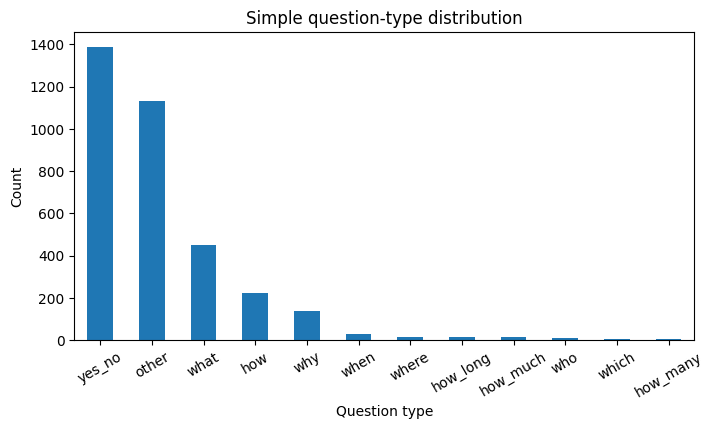

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
df_train["question_type_simple"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Simple question-type distribution")
ax.set_xlabel("Question type")
ax.set_ylabel("Count")
plt.xticks(rotation=30)
plt.show()

### 7. Surface patterns in answers

We inspect a few surface patterns that later motivated preprocessing:
- punctuation markers such as `?`, `!`, and `...`
- years, dates, times, percentages, money, and other numbers

These analyses justify preserving or normalizing such cues rather than stripping them away blindly.

In [31]:
def has_pattern(series, pattern):
    return series.fillna("").astype(str).str.contains(pattern, regex=True)

surface_df = pd.DataFrame({
    "has_question_mark_in_answer": has_pattern(df_train["interview_answer"], r"\?"),
    "has_exclamation_in_answer": has_pattern(df_train["interview_answer"], r"!"),
    "has_ellipsis_in_answer": has_pattern(df_train["interview_answer"], r"\.\.\."),
    "has_year_in_answer": has_pattern(df_train["interview_answer"], r"\b(?:18\d{2}|19\d{2}|20\d{2}|2100)\b"),
    "has_number_in_answer": has_pattern(df_train["interview_answer"], r"\b\d+(?:,\d{3})*(?:\.\d+)?\b"),
    "has_percent_in_answer": has_pattern(df_train["interview_answer"], r"\b\d+(?:\.\d+)?\s?%|\b\d+(?:\.\d+)?\s+percent\b"),
    "has_money_in_answer": has_pattern(df_train["interview_answer"], r"[$€£¥]|\b(?:usd|eur|gbp|dollars?|euros?|pounds?|yen)\b"),
    "has_time_or_date_like_in_answer": has_pattern(
        df_train["interview_answer"],
        r"\b\d{1,2}:\d{2}\b|\b(?:january|february|march|april|may|june|july|august|september|october|november|december)\b"
    ),
})

surface_rates = surface_df.mean().sort_values(ascending=False).rename("rate")
display(surface_rates.to_frame())

,rate
has_number_in_answer,0.399243
has_question_mark_in_answer,0.396040
has_time_or_date_like_in_answer,0.150262
has_money_in_answer,0.105416
has_percent_in_answer,0.068433
has_year_in_answer,0.048049
has_exclamation_in_answer,0.002330
has_ellipsis_in_answer,0.000000


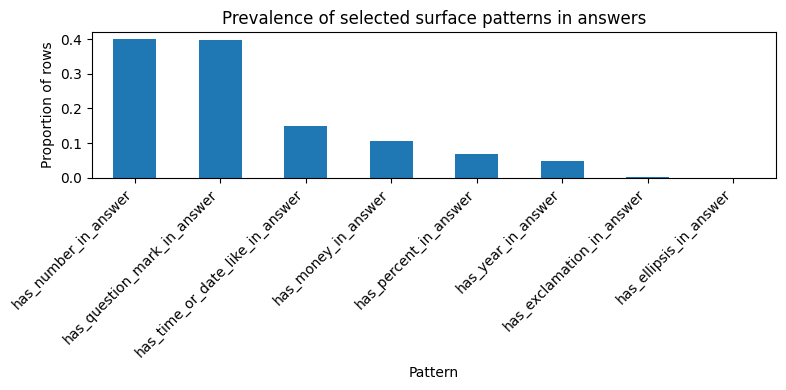

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
surface_rates.plot(kind="bar", ax=ax)
ax.set_title("Prevalence of selected surface patterns in answers")
ax.set_xlabel("Pattern")
ax.set_ylabel("Proportion of rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 8. Surface patterns by label

Finally, we inspect whether some simple surface cues appear at different rates across labels.

This is not proof of causality, but it helps motivate why these cues may carry predictive signal.

In [33]:
surface_with_label = surface_df.copy()
surface_with_label[TARGET_COL] = df_train[TARGET_COL].values

surface_by_label = surface_with_label.groupby(TARGET_COL).mean().T
display(surface_by_label)

clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
has_question_mark_in_answer,0.401478,0.498592,0.350810
has_exclamation_in_answer,0.001970,0.002817,0.002860
has_ellipsis_in_answer,0.000000,0.000000,0.000000
has_year_in_answer,0.057635,0.016901,0.040038
has_number_in_answer,0.435468,0.183099,0.402288
has_percent_in_answer,0.081281,0.011268,0.062917
has_money_in_answer,0.117734,0.036620,0.104862
has_time_or_date_like_in_answer,0.160099,0.109859,0.144900


## 9. Answer-only word clouds by label

This section examines whether the labels can be distinguished from the **answer text alone**. Instead of looking for words that are unique to a label, we first visualize the **most common answer words within each label**.

The logic is simple: if the labels have clear answer-side lexical signatures, then the word clouds should show noticeably different vocabularies. If, instead, the clouds contain broadly similar or weakly distinctive words, that suggests that answer vocabulary alone is not enough for reliable classification.

To reduce noise, the clouds are based on **document frequency within each label** rather than raw token counts. This means a word is rewarded for appearing in many answers from a label, not just being repeated many times in one long answer.

Rows in within-class DF table: 8427


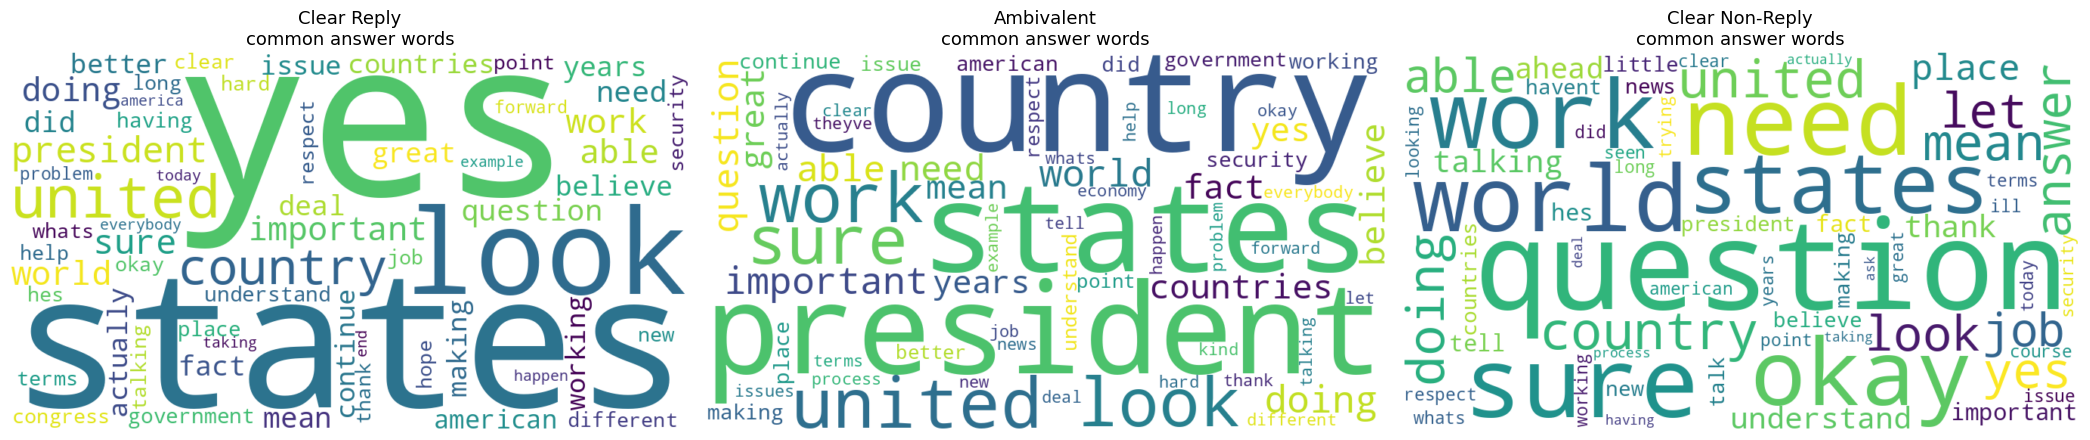

Most common answer words within each label:


,label,token,df_in_label,share_of_label_docs,n_docs_in_label
0,Ambivalent,country,661,0.325616,2030
1,Ambivalent,president,649,0.319704,2030
2,Ambivalent,states,649,0.319704,2030
3,Ambivalent,united,625,0.307882,2030
4,Ambivalent,work,606,0.298522,2030
5,Ambivalent,look,597,0.294089,2030
6,Ambivalent,sure,580,0.285714,2030
7,Ambivalent,important,536,0.264039,2030
8,Ambivalent,world,535,0.263547,2030
9,Ambivalent,doing,534,0.263054,2030



Overlap among top 30 words per label:


,label_a,label_b,top_n_used,overlap_count,jaccard_overlap,shared_words
0,Clear Reply,Ambivalent,30,27,0.818182,"able, american, believe, continue, countries, country, did, doing, fact, government, great, important, issue, look, making, mean, need, president, question, states, sure, united, work, working, world, years, yes"
1,Ambivalent,Clear Non-Reply,30,18,0.428571,"able, believe, country, doing, fact, important, look, mean, need, place, president, question, states, sure, united, work, world, yes"
2,Clear Reply,Clear Non-Reply,30,17,0.395349,"able, believe, country, doing, fact, important, look, mean, need, president, question, states, sure, united, work, world, yes"


In [34]:

import re
from collections import Counter
from itertools import combinations

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


WC_CLASS_CONFIG = {
    "text_col": "interview_answer",
    "label_col": TARGET_COL,

    # lightweight preprocessing
    "min_token_len": 3,
    "drop_numeric_tokens": True,
    "extra_stopwords": {
        "im", "ive", "youre", "weve", "theyre", "thats", "theres", "dont", "didnt",
        "doesnt", "isnt", "arent", "wasnt", "werent", "cant", "couldnt", "wouldnt",
        "shouldnt", "wont", "youve", "also", "really", "just", "like", "know",
        "think", "said", "say", "says", "going", "got", "get", "gets", "make",
        "makes", "made", "come", "comes", "coming", "take", "takes", "taken",
        # optional extra cleanup for generic conversational filler
        "people", "thing", "things", "way", "time", "lot", "good", "right", "want"
    },

    # support
    "min_df_in_label": 5,

    # outputs
    "top_n_cloud": 60,
    "top_n_table": 20,
    "top_n_overlap": 30,
}

STOPWORDS_SIMPLE = set(ENGLISH_STOP_WORDS) | set(WC_CLASS_CONFIG["extra_stopwords"])
TOKEN_PATTERN = re.compile(r"[A-Za-z][A-Za-z'\-]*")


def simple_tokenize(text, min_token_len=3, drop_numeric_tokens=True):
    if pd.isna(text):
        return []

    text = str(text).replace("’", "'").replace("`", "'").lower()
    toks = TOKEN_PATTERN.findall(text)

    out = []
    for tok in toks:
        tok_norm = tok.replace("'", "")

        if len(tok_norm) < min_token_len:
            continue
        if tok_norm in STOPWORDS_SIMPLE:
            continue
        if drop_numeric_tokens and re.search(r"\d", tok_norm):
            continue

        out.append(tok_norm)

    return out


def build_within_class_df_table(df, text_col, label_col, min_df_in_label=5):
    labels = list(df[label_col].dropna().unique())
    rows = []

    for label in labels:
        texts = df.loc[df[label_col] == label, text_col].fillna("").astype(str)
        counter = Counter()

        for txt in texts:
            toks = set(
                simple_tokenize(
                    txt,
                    min_token_len=WC_CLASS_CONFIG["min_token_len"],
                    drop_numeric_tokens=WC_CLASS_CONFIG["drop_numeric_tokens"],
                )
            )
            counter.update(toks)

        n_docs = len(texts)

        for tok, df_label in counter.items():
            if df_label < min_df_in_label:
                continue

            rows.append({
                "label": label,
                "token": tok,
                "df_in_label": df_label,
                "share_of_label_docs": df_label / n_docs if n_docs else 0.0,
                "n_docs_in_label": n_docs,
            })

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out

    return out.sort_values(
        ["label", "df_in_label", "share_of_label_docs", "token"],
        ascending=[True, False, False, True]
    ).reset_index(drop=True)


within_class_wc_table = build_within_class_df_table(
    df=df_train,
    text_col=WC_CLASS_CONFIG["text_col"],
    label_col=WC_CLASS_CONFIG["label_col"],
    min_df_in_label=WC_CLASS_CONFIG["min_df_in_label"],
)

print("Rows in within-class DF table:", len(within_class_wc_table))

if len(within_class_wc_table) == 0:
    print("No tokens survived the current threshold. Lower min_df_in_label slightly.")
else:
    labels_in_order = list(df_train[WC_CLASS_CONFIG["label_col"]].dropna().unique())

    fig, axes = plt.subplots(1, len(labels_in_order), figsize=(7 * len(labels_in_order), 6))
    if len(labels_in_order) == 1:
        axes = [axes]

    for ax, label in zip(axes, labels_in_order):
        sub = (
            within_class_wc_table[within_class_wc_table["label"] == label]
            .head(WC_CLASS_CONFIG["top_n_cloud"])
            .copy()
        )

        freqs = dict(zip(sub["token"], sub["df_in_label"]))

        if len(freqs) == 0:
            ax.axis("off")
            ax.set_title(f"{label}\n(no stable words)")
            continue

        wc = WordCloud(
            width=900,
            height=500,
            background_color="white",
            collocations=False,
            max_words=WC_CLASS_CONFIG["top_n_cloud"]
        ).generate_from_frequencies(freqs)

        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"{label}\ncommon answer words", fontsize=13)

    plt.tight_layout()
    plt.show()

    print("Most common answer words within each label:")
    display(
        within_class_wc_table
        .groupby("label", group_keys=False)
        .head(WC_CLASS_CONFIG["top_n_table"])
        .reset_index(drop=True)
    )

    # overlap of top words across labels
    top_sets = {}
    for label in labels_in_order:
        top_sets[label] = set(
            within_class_wc_table[within_class_wc_table["label"] == label]
            .head(WC_CLASS_CONFIG["top_n_overlap"])["token"]
            .tolist()
        )

    overlap_rows = []
    for a, b in combinations(labels_in_order, 2):
        inter = len(top_sets[a] & top_sets[b])
        union = len(top_sets[a] | top_sets[b])
        jaccard = inter / union if union else 0.0

        overlap_rows.append({
            "label_a": a,
            "label_b": b,
            "top_n_used": WC_CLASS_CONFIG["top_n_overlap"],
            "overlap_count": inter,
            "jaccard_overlap": jaccard,
            "shared_words": ", ".join(sorted(top_sets[a] & top_sets[b])),
        })

    overlap_table = pd.DataFrame(overlap_rows).sort_values(
        ["jaccard_overlap", "overlap_count"],
        ascending=[False, False]
    ).reset_index(drop=True)

    print(f"\nOverlap among top {WC_CLASS_CONFIG['top_n_overlap']} words per label:")
    display(overlap_table)

### Interpretation

The answer-only word clouds suggest that the labels are **not strongly separated by their most common vocabulary**. The highest-frequency words within each class are broadly similar and reflect the general discourse of the interviews rather than sharply label-specific lexical patterns. Terms such as *country*, *president*, *states*, *united*, *work*, *look*, *sure*, *question*, and *yes* recur across all three labels, indicating that the dominant answer vocabulary is largely shared.

The overlap analysis makes this especially clear. Among the top 30 words per label, **Ambivalent** and **Clear Reply** share **27 words** (Jaccard overlap **0.82**), while **Ambivalent** and **Clear Non-Reply** share **18** and **Clear Reply** and **Clear Non-Reply** share **17**. These are substantial overlaps. Even though **Clear Non-Reply** appears somewhat more distinct than the other two classes, its most common words are still largely drawn from the same lexical pool.

Substantively, this means that answer-side word frequency alone is unlikely to provide a strong basis for classification. The common vocabulary seems to reflect the shared political-interview setting more than the response type itself. In other words, the labels do not appear to correspond to clearly different lexical fields at the unigram level.

This has an important implication for the modeling strategy. If the labels were strongly encoded in answer vocabulary alone, we would expect much lower overlap and more clearly differentiated clouds. Instead, the high degree of shared vocabulary suggests that the task is intrinsically difficult when relying only on answer words. Stronger performance will likely require modeling the **relationship between the question and the answer** — for example, whether the answer directly addresses the question, partially addresses it, evades it, or shifts to adjacent content.

# 3. Preprocessing pipeline for QEvasion

This version includes:

- light normalization
- overlap features
- QA pair-structure features
- reply-style / non-reply cue features
- opening-span answer cues
- lightweight entity / answer-form compatibility cues
- pronoun / target-shift cues
- surface-pattern features
- question-intent features
- answer-evidence features
- QA-alignment features
- answer-group count features
- negation-aware preprocessing
- punctuation features and tokens
- optional lemmatization


In [35]:
import copy as _copy

BASE_PREPROCESS_CONFIG = {
    "preprocess_version": "v9_maxed_relational_features_plus_opening_entity_shift",

    # Core columns
    "question_col": "question",
    "answer_col": "interview_answer",
    "target_col": "clarity_label",
    "id_col": "index",
    "url_col": "url",
    "question_order_col": "question_order",

    # Basic normalization
    "lowercase": True,
    "strip_whitespace": True,

    # Overlap feature tokenization
    "remove_punctuation_for_overlap": True,
    "remove_stopwords_for_overlap": True,
    "min_token_length_for_overlap": 2,
    "keep_numbers_for_overlap": True,

    # Handcrafted overlap / relational features
    "compute_question_coverage": True,
    "compute_qa_pair_structure_features": True,
    "compute_reply_style_features": True,

    # Surface-pattern count/presence features
    "compute_surface_pattern_features": True,
    "surface_pattern_feature_source": "answer",

    # Question / answer / alignment structured features
    "compute_question_intent_features": True,
    "compute_answer_evidence_features": True,
    "compute_qa_alignment_features": True,

    # Answer-group structural features
    "compute_answer_group_features": True,

    # Surface-pattern normalization for model text
    "normalize_surface_patterns_for_model": True,
    "surface_pattern_token_source": "both",

    # Which surface categories to normalize / feature-engineer
    "replace_dates": True,
    "replace_years": True,
    "replace_months": True,
    "replace_times": True,
    "replace_dayparts": True,
    "replace_weekdays": True,
    "replace_durations": True,
    "replace_percentages": True,
    "replace_money": True,
    "replace_large_numbers": True,
    "replace_ranges": True,
    "replace_numbers": False,

    # Surface tokens
    "date_token": "[DATE_TOK]",
    "year_token": "[YEAR_TOK]",
    "month_token": "[MONTH_TOK]",
    "time_token": "[TIME_TOK]",
    "daypart_token": "[DAYPART_TOK]",
    "weekday_token": "[WEEKDAY_TOK]",
    "duration_token": "[DURATION_TOK]",
    "percentage_token": "[PERCENT_TOK]",
    "money_token": "[MONEY_TOK]",
    "large_number_token": "[LARGE_NUMBER_TOK]",
    "range_token": "[RANGE_TOK]",
    "number_token": "[NUMBER_TOK]",

    # Year bounds
    "year_min": 1800,
    "year_max": 2100,

    # Punctuation count features
    "compute_punctuation_features": True,
    "punctuation_feature_source": "answer",

    # Punctuation token injection
    "inject_punctuation_tokens": True,
    "punctuation_token_source": "answer",

    # Which punctuation marks to track / inject
    "track_question_marks": True,
    "track_exclamation_marks": True,
    "track_ellipsis": True,

    # Punctuation tokens
    "question_mark_token": "[QMARK]",
    "exclamation_mark_token": "[EMARK]",
    "ellipsis_token": "[ELLIPSIS]",

    # Negation preprocessing
    "apply_negation_preprocessing": True,

    # Lemmatization
    "apply_lemmatization": True,
    "lemmatize_question_text": True,
    "lemmatize_answer_text": True,
    "preserve_special_tokens_in_lemmatization": True,

    # Keep intensifier adverbs near negated targets
    "allowed_adverbs": {
        "very", "too", "so", "really", "quite", "rather",
        "particularly", "especially", "entirely", "completely",
        "totally", "necessarily", "extremely", "fairly",
        "pretty", "highly", "overly", "fully"
    },

    # Optional exclusions for adjective collapsing
    "exclude_adjectives": {
        "much", "many", "next", "same", "other", "first", "last",
        "own", "such"
    },

    # Single canonical negation prefix
    "negation_prefix": "neg",

    # spaCy
    "spacy_model": SPACY_MODEL_CHOICE,
    "spacy_batch_size": 32,

    # Final combined text
    "create_combined_text": True,
    "combined_text_sep_token": "[SEP]",

    # Output columns
    "question_processed_col": "question_processed",
    "answer_processed_col": "answer_processed",
    "combined_processed_col": "qa_processed",
    "question_coverage_col": "question_coverage",
}

PREPROCESS_PROFILE_OVERRIDES = {
    "old_baseline": {
        "preprocess_version": "v9_maxed_relational_features_plus_opening_entity_shift",
        "replace_numbers": False,
    },
    "old_plus_number_token": {
        "preprocess_version": "v9_plus_number_token_controlled",
        "replace_numbers": True,
    },
}

if PREPROCESS_PROFILE_CHOICE not in PREPROCESS_PROFILE_OVERRIDES:
    raise ValueError(
        f"Unknown PREPROCESS_PROFILE_CHOICE: {PREPROCESS_PROFILE_CHOICE}. "
        f"Valid values: {sorted(PREPROCESS_PROFILE_OVERRIDES)}"
    )

PREPROCESS_CONFIG = _copy.deepcopy(BASE_PREPROCESS_CONFIG)
PREPROCESS_CONFIG.update(_copy.deepcopy(PREPROCESS_PROFILE_OVERRIDES[PREPROCESS_PROFILE_CHOICE]))
PREPROCESS_CONFIG["spacy_model"] = SPACY_MODEL_CHOICE
PREPROCESS_CONFIG["preprocess_profile_choice"] = PREPROCESS_PROFILE_CHOICE

print("Preprocess profile:", PREPROCESS_PROFILE_CHOICE)
print("spaCy model choice:", PREPROCESS_CONFIG["spacy_model"])
print("replace_numbers   :", PREPROCESS_CONFIG["replace_numbers"])


Preprocess profile: old_plus_number_token
spaCy model choice: en_core_web_sm
replace_numbers   : True


## Imports

Core Python, pandas, sklearn stopwords, and spaCy.

In [36]:
import os
import json
import re
import unicodedata
import copy
from collections import defaultdict

import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


## Load Spacy

In [37]:
# Main preprocessing spaCy model was already ensured by the top-of-notebook bootstrap.
preferred_spacy_model = PREPROCESS_CONFIG["spacy_model"]
print("Main preprocessing spaCy model requested:", preferred_spacy_model)

Main preprocessing spaCy model requested: en_core_web_sm


In [38]:
preferred_spacy_model = PREPROCESS_CONFIG["spacy_model"]

nlp = load_requested_spacy_model(preferred_spacy_model)
loaded_model_name = preferred_spacy_model

print("Loaded spaCy model:", loaded_model_name)

Loaded spaCy model: en_core_web_sm


## Regex constants and contraction maps

In [39]:
NEGATION_CONTRACTION_MAP = {
    r"\bdon['’]?t\b": "do not",
    r"\bdont\b": "do not",
    r"\bcan['’]?t\b": "can not",
    r"\bcant\b": "can not",
    r"\bcannot\b": "can not",
    r"\bwon['’]?t\b": "will not",
    r"\bwont\b": "will not",
    r"\bdidn['’]?t\b": "did not",
    r"\bdoesn['’]?t\b": "does not",
    r"\bisn['’]?t\b": "is not",
    r"\baren['’]?t\b": "are not",
    r"\bwasn['’]?t\b": "was not",
    r"\bweren['’]?t\b": "were not",
    r"\bcouldn['’]?t\b": "could not",
    r"\bshouldn['’]?t\b": "should not",
    r"\bwouldn['’]?t\b": "would not",
    r"\bmustn['’]?t\b": "must not",
    r"\bneedn['’]?t\b": "need not",
    r"\bhasn['’]?t\b": "has not",
    r"\bhaven['’]?t\b": "have not",
    r"\bhadn['’]?t\b": "had not",
    r"\bain['’]?t\b": "is not",
}

GENERAL_CONTRACTION_MAP = {
    r"\bwe['’]re\b": "we are",
    r"\byou['’]re\b": "you are",
    r"\bthey['’]re\b": "they are",
    r"\bhe['’]s\b": "he is",
    r"\bshe['’]s\b": "she is",
    r"\bit['’]s\b": "it is",
    r"\bthat['’]s\b": "that is",
    r"\bthere['’]s\b": "there is",
    r"\bhere['’]s\b": "here is",
    r"\bwhat['’]s\b": "what is",
    r"\bwho['’]s\b": "who is",
    r"\bhow['’]s\b": "how is",
    r"\bwhere['’]s\b": "where is",
    r"\bwhen['’]s\b": "when is",
    r"\bwhy['’]s\b": "why is",
    r"\bi['’]m\b": "i am",
    r"\bi['’]ve\b": "i have",
    r"\bwe['’]ve\b": "we have",
    r"\byou['’]ve\b": "you have",
    r"\bthey['’]ve\b": "they have",
    r"\bi['’]ll\b": "i will",
    r"\bwe['’]ll\b": "we will",
    r"\byou['’]ll\b": "you will",
    r"\bthey['’]ll\b": "they will",
    r"\bhe['’]ll\b": "he will",
    r"\bshe['’]ll\b": "she will",
    r"\bit['’]ll\b": "it will",
    r"\bi['’]d\b": "i would",
    r"\bwe['’]d\b": "we would",
    r"\byou['’]d\b": "you would",
    r"\bthey['’]d\b": "they would",
    r"\bhe['’]d\b": "he would",
    r"\bshe['’]d\b": "she would",
    r"\bit['’]d\b": "it would",
}

MONTH_NAME_PATTERN = (
    r"(?:january|february|march|april|may|june|july|august|"
    r"september|october|november|december|"
    r"jan|feb|mar|apr|jun|jul|aug|sep|sept|oct|nov|dec)"
)

FULL_MONTH_NAME_PATTERN = (
    r"(?:january|february|march|april|may|june|july|august|"
    r"september|october|november|december)"
)

WEEKDAY_NAME_PATTERN = (
    r"(?:monday|tuesday|wednesday|thursday|friday|saturday|sunday)"
)

DAYPART_PATTERN = r"(?:morning|afternoon|evening|night|overnight|tonight)"

DURATION_UNIT_PATTERN = (
    r"(?:second|seconds|minute|minutes|hour|hours|day|days|week|weeks|"
    r"month|months|year|years|decade|decades)"
)

SCALE_WORD_PATTERN = r"(?:thousand|million|billion|trillion|mn|bn)"
NUMBER_PATTERN = r"\d+(?:,\d{3})*(?:\.\d+)?"
NUMBER_OR_SCALED_PATTERN = rf"{NUMBER_PATTERN}(?:\s+{SCALE_WORD_PATTERN})?"
CURRENCY_SYMBOL_PATTERN = r"(?:\$|€|£|¥)"
CURRENCY_WORD_PATTERN = r"(?:dollar|dollars|usd|us dollars|euro|euros|eur|pound|pounds|gbp|yen|jpy)"

NUMBER_WORD_PATTERN = (
    r"(?:one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve|"
    r"thirteen|fourteen|fifteen|sixteen|seventeen|eighteen|nineteen|"
    r"twenty|thirty|forty|fifty|sixty|seventy|eighty|ninety|hundred)"
)

## Basic normalization helpers and special-token map

In [40]:
def canonicalize_special_token(token, default_token):
    """
    Convert config-facing tokens like [DATE_TOK] into safe model tokens like date_tok.
    """
    if token is None or (isinstance(token, float) and pd.isna(token)):
        token = default_token

    token = str(token).strip().lower()
    token = token.replace("[", " ").replace("]", " ")
    token = re.sub(r"[^a-z0-9_]+", "_", token)
    token = re.sub(r"_+", "_", token).strip("_")

    return token if token else default_token


def build_special_token_map(config):
    return {
        "question_mark_token": canonicalize_special_token(
            config.get("question_mark_token", "[QMARK]"), "qmark"
        ),
        "exclamation_mark_token": canonicalize_special_token(
            config.get("exclamation_mark_token", "[EMARK]"), "emark"
        ),
        "ellipsis_token": canonicalize_special_token(
            config.get("ellipsis_token", "[ELLIPSIS]"), "ellipsis"
        ),
        "date_token": canonicalize_special_token(
            config.get("date_token", "[DATE_TOK]"), "date_tok"
        ),
        "year_token": canonicalize_special_token(
            config.get("year_token", "[YEAR_TOK]"), "year_tok"
        ),
        "month_token": canonicalize_special_token(
            config.get("month_token", "[MONTH_TOK]"), "month_tok"
        ),
        "time_token": canonicalize_special_token(
            config.get("time_token", "[TIME_TOK]"), "time_tok"
        ),
        "daypart_token": canonicalize_special_token(
            config.get("daypart_token", "[DAYPART_TOK]"), "daypart_tok"
        ),
        "weekday_token": canonicalize_special_token(
            config.get("weekday_token", "[WEEKDAY_TOK]"), "weekday_tok"
        ),
        "duration_token": canonicalize_special_token(
            config.get("duration_token", "[DURATION_TOK]"), "duration_tok"
        ),
        "percentage_token": canonicalize_special_token(
            config.get("percentage_token", "[PERCENT_TOK]"), "percent_tok"
        ),
        "money_token": canonicalize_special_token(
            config.get("money_token", "[MONEY_TOK]"), "money_tok"
        ),
        "large_number_token": canonicalize_special_token(
            config.get("large_number_token", "[LARGE_NUMBER_TOK]"), "large_number_tok"
        ),
        "range_token": canonicalize_special_token(
            config.get("range_token", "[RANGE_TOK]"), "range_tok"
        ),
        "number_token": canonicalize_special_token(
            config.get("number_token", "[NUMBER_TOK]"), "number_tok"
        ),
        "combined_sep_token": canonicalize_special_token(
            config.get("combined_text_sep_token", "[SEP]"), "sep"
        ),
    }


def expand_contractions(text, expand_negations=True, expand_general=True):
    if pd.isna(text):
        return ""

    text = str(text)
    text = text.replace("’", "'")

    if expand_negations:
        for pattern, replacement in NEGATION_CONTRACTION_MAP.items():
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    if expand_general:
        for pattern, replacement in GENERAL_CONTRACTION_MAP.items():
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    return text


def normalize_text(text, lowercase=True, strip_whitespace=True):
    """
    Light normalization only. Keep punctuation and surface structure because
    later stages need it.
    """
    if pd.isna(text):
        return ""

    text = str(text)
    text = unicodedata.normalize("NFKC", text)

    text = (
        text.replace("’", "'")
            .replace("“", '"')
            .replace("”", '"')
            .replace("–", "-")
            .replace("—", "-")
            .replace("…", "...")
    )

    if lowercase:
        text = text.lower()

    if strip_whitespace:
        text = re.sub(r"\s+", " ", text).strip()

    return text

## Overlap tokenization and question coverage

In [41]:
def tokenize_for_overlap(
    text,
    lowercase=True,
    remove_punctuation=True,
    remove_stopwords=True,
    min_token_length=2,
    keep_numbers=True
):
    """
    Simpler tokenization for overlap-based handcrafted features.
    This intentionally does NOT use the full model-text normalization pipeline.
    """
    if pd.isna(text):
        return []

    text = str(text)

    if lowercase:
        text = text.lower()

    text = expand_contractions(
        text,
        expand_negations=True,
        expand_general=True
    )

    if remove_punctuation:
        if keep_numbers:
            tokens = re.findall(r"[a-z]+|\d+(?:\.\d+)?", text)
        else:
            tokens = re.findall(r"[a-z]+", text)
    else:
        tokens = re.findall(r"\b[\w']+\b", text)

    filtered = []
    for tok in tokens:
        if remove_stopwords and tok in ENGLISH_STOP_WORDS:
            continue

        if re.fullmatch(r"\d+(?:\.\d+)?", tok):
            filtered.append(tok)
            continue

        if len(tok) >= min_token_length:
            filtered.append(tok)

    return filtered


def question_coverage(question_tokens, answer_tokens):
    """
    Fraction of unique question tokens that appear in the answer.
    """
    q_set = set(question_tokens)
    a_set = set(answer_tokens)

    if len(q_set) == 0:
        return 0.0

    return len(q_set & a_set) / len(q_set)

## Negation-aware preprocessing

In [42]:
def get_negation_token(lemma, negation_prefix="neg"):
    lemma = str(lemma).lower().strip()
    return f"{negation_prefix}_{lemma}"


def _collapse_negation_in_doc(
    doc,
    allowed_adverbs,
    exclude_adjectives,
    negation_prefix="neg"
):
    collapsed = {}
    consumed = set()

    for tok in doc:
        if tok.dep_ != "neg":
            continue

        head = tok.head

        # Negation attached directly to adjective
        if head.pos_ == "ADJ":
            adj = head.lemma_.lower()

            if adj not in exclude_adjectives:
                advmods = sorted(
                    [
                        child for child in head.children
                        if child.dep_ == "advmod" and child.lemma_.lower() in allowed_adverbs
                    ],
                    key=lambda x: x.i
                )

                neg_token = get_negation_token(adj, negation_prefix)

                if advmods:
                    adv_text = " ".join(child.lemma_.lower() for child in advmods)
                    collapsed[head.i] = f"{adv_text} {neg_token}"
                    consumed.update(child.i for child in advmods)
                else:
                    collapsed[head.i] = neg_token

                consumed.add(tok.i)

            continue

        # Negation attached to AUX/VERB
        if head.pos_ in {"VERB", "AUX"}:
            adj_children = [
                child for child in head.children
                if child.pos_ == "ADJ" and child.lemma_.lower() not in exclude_adjectives
            ]

            if adj_children:
                target = adj_children[0]

                advmods = sorted(
                    [
                        child for child in target.children
                        if child.dep_ == "advmod" and child.lemma_.lower() in allowed_adverbs
                    ],
                    key=lambda x: x.i
                )

                neg_token = get_negation_token(target.lemma_.lower(), negation_prefix)

                if advmods:
                    adv_text = " ".join(child.lemma_.lower() for child in advmods)
                    collapsed[target.i] = f"{adv_text} {neg_token}"
                    consumed.update(child.i for child in advmods)
                else:
                    collapsed[target.i] = neg_token

                consumed.add(tok.i)
                continue

            target = head
            if head.pos_ == "AUX":
                verbal_children = [
                    child for child in head.children
                    if child.pos_ == "VERB" and child.dep_ in {"xcomp", "ccomp", "acomp"}
                ]
                if verbal_children:
                    target = verbal_children[0]

            collapsed[target.i] = get_negation_token(target.lemma_.lower(), negation_prefix)
            consumed.add(tok.i)

            if target is not head:
                consumed.add(head.i)

            continue

    output_tokens = []

    for tok in doc:
        if tok.i in consumed:
            continue

        if tok.i in collapsed:
            output_tokens.append(collapsed[tok.i])
            continue

        if tok.is_space or tok.is_punct:
            continue

        output_tokens.append(tok.text.lower())

    return " ".join(output_tokens)


def apply_spacy_negation_preprocessing(
    text,
    nlp,
    allowed_adverbs,
    exclude_adjectives,
    negation_prefix="neg"
):
    if pd.isna(text):
        return ""

    text = str(text).strip()
    if not text:
        return ""

    doc = nlp(text)
    return _collapse_negation_in_doc(
        doc=doc,
        allowed_adverbs=allowed_adverbs,
        exclude_adjectives=exclude_adjectives,
        negation_prefix=negation_prefix
    )


def apply_spacy_negation_preprocessing_batch(
    texts,
    nlp,
    allowed_adverbs,
    exclude_adjectives,
    negation_prefix="neg",
    batch_size=32
):
    cleaned_texts = ["" if pd.isna(x) else str(x).strip() for x in texts]
    results = []

    for doc in nlp.pipe(cleaned_texts, batch_size=batch_size):
        results.append(
            _collapse_negation_in_doc(
                doc=doc,
                allowed_adverbs=allowed_adverbs,
                exclude_adjectives=exclude_adjectives,
                negation_prefix=negation_prefix
            )
        )

    return results

## Optional lemmatization for model text

The preprocessing pipeline can optionally apply lemmatization to the model-text branch.

This is done **after**:
- surface-pattern normalization
- negation preprocessing
- punctuation token injection

and **before** final lexical cleanup.

This ordering is intentional:
- negation preprocessing already creates lemma-based negation tokens such as `neg_go`
- special preprocessing tokens such as `year_tok`, `money_tok`, `qmark`, and `neg_go` should remain unchanged
- lemmatization is therefore applied only to ordinary lexical tokens

In [43]:
def build_protected_lemma_tokens(config, token_map=None):
    """
    Tokens that should be preserved exactly during lemmatization.
    """
    if token_map is None:
        token_map = build_special_token_map(config)

    protected = set(token_map.values())

    # preserve negation prefix tokens like neg_go, neg_clear, etc.
    neg_prefix = str(config.get("negation_prefix", "neg")).lower().strip()
    protected.add(neg_prefix)

    return protected


def should_preserve_token_during_lemmatization(token_text, protected_tokens=None):
    """
    Preserve special tokens exactly as they are.

    Rules:
    - preserve tokens explicitly listed in protected_tokens
    - preserve underscore tokens such as year_tok, money_tok, neg_go
    """
    tok = str(token_text).strip().lower()

    if not tok:
        return True

    if protected_tokens is not None and tok in protected_tokens:
        return True

    if "_" in tok:
        return True

    return False


def apply_spacy_lemmatization(
    text,
    nlp,
    protected_tokens=None
):
    """
    Lemmatize text while preserving special tokens.
    """
    if pd.isna(text):
        return ""

    text = str(text).strip()
    if not text:
        return ""

    doc = nlp(text)

    output_tokens = []
    for tok in doc:
        if tok.is_space:
            continue

        raw_tok = tok.text.lower()

        if should_preserve_token_during_lemmatization(
            raw_tok,
            protected_tokens=protected_tokens
        ):
            output_tokens.append(raw_tok)
            continue

        lemma = tok.lemma_.lower().strip()

        # fallback if lemma is missing or unusable
        if not lemma or lemma == "-pron-":
            lemma = raw_tok

        output_tokens.append(lemma)

    return " ".join(output_tokens)


def apply_spacy_lemmatization_batch(
    texts,
    nlp,
    protected_tokens=None,
    batch_size=32
):
    """
    Batch lemmatization while preserving special tokens.
    """
    cleaned_texts = ["" if pd.isna(x) else str(x).strip() for x in texts]
    results = []

    for doc in nlp.pipe(cleaned_texts, batch_size=batch_size):
        output_tokens = []

        for tok in doc:
            if tok.is_space:
                continue

            raw_tok = tok.text.lower()

            if should_preserve_token_during_lemmatization(
                raw_tok,
                protected_tokens=protected_tokens
            ):
                output_tokens.append(raw_tok)
                continue

            lemma = tok.lemma_.lower().strip()

            if not lemma or lemma == "-pron-":
                lemma = raw_tok

            output_tokens.append(lemma)

        results.append(" ".join(output_tokens))

    return results

## Punctuation count features and punctuation token injection

In [44]:
def extract_punctuation_features(
    text,
    track_question_marks=True,
    track_exclamation_marks=True,
    track_ellipsis=True
):
    if pd.isna(text):
        text = ""
    else:
        text = str(text)

    features = {}

    if track_question_marks:
        q_count = text.count("?")
        features["question_mark_count"] = q_count
        features["has_question_mark"] = int(q_count > 0)

    if track_exclamation_marks:
        e_count = text.count("!")
        features["exclamation_mark_count"] = e_count
        features["has_exclamation_mark"] = int(e_count > 0)

    if track_ellipsis:
        ellipsis_count = text.count("...")
        features["ellipsis_count"] = ellipsis_count
        features["has_ellipsis"] = int(ellipsis_count > 0)

    return features


def inject_punctuation_tokens(
    text,
    question_mark_token="qmark",
    exclamation_mark_token="emark",
    ellipsis_token="ellipsis",
    track_question_marks=True,
    track_exclamation_marks=True,
    track_ellipsis=True
):
    """
    Inject punctuation tokens AFTER negation preprocessing so spaCy does not
    have to parse bracket-style special tokens.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    if track_ellipsis:
        text = text.replace("...", f" {ellipsis_token} ")

    if track_question_marks:
        text = text.replace("?", f" {question_mark_token} ")

    if track_exclamation_marks:
        text = text.replace("!", f" {exclamation_mark_token} ")

    text = re.sub(r"\s+", " ", text).strip()
    return text

## Surface-pattern normalization and count extraction

In [45]:
def _sub_with_token(text, pattern, replacement_token, counts, category_name, flags=re.IGNORECASE):
    regex = re.compile(pattern, flags=flags)

    def repl(_match):
        counts[category_name] += 1
        return f" {replacement_token} "

    return regex.sub(repl, text)


def _sub_preserve_prefix(text, pattern, replacement_token, counts, category_name, flags=re.IGNORECASE):
    regex = re.compile(pattern, flags=flags)

    def repl(match):
        counts[category_name] += 1
        return f" {match.group(1)} {replacement_token} "

    return regex.sub(repl, text)


def _replace_years_with_token(text, year_token, year_min, year_max, counts, category_name="year"):
    regex = re.compile(r"\b\d{4}\b")

    def repl(match):
        year_text = match.group(0)
        year_val = int(year_text)

        if year_min <= year_val <= year_max:
            counts[category_name] += 1
            return f" {year_token} "

        return year_text

    return regex.sub(repl, text)


def apply_surface_pattern_normalization(text, config, token_map=None, return_counts=False):
    """
    Surface-pattern normalization for model text and optional count extraction.

    Order matters: stronger / more specific patterns come first.
    """
    if pd.isna(text):
        return ("", {}) if return_counts else ""

    text = str(text)
    counts = defaultdict(int)

    if token_map is None:
        token_map = build_special_token_map(config)

    # 1) definite money
    if config.get("replace_money", False):
        money_patterns = [
            rf"{CURRENCY_SYMBOL_PATTERN}\s?{NUMBER_PATTERN}(?:\s+{SCALE_WORD_PATTERN})?\b",
            rf"\b(?:usd|eur|gbp|jpy)\s?{NUMBER_PATTERN}(?:\s+{SCALE_WORD_PATTERN})?\b",
            rf"\b{NUMBER_PATTERN}(?:\s+{SCALE_WORD_PATTERN})?\s+{CURRENCY_WORD_PATTERN}\b",
        ]
        for pattern in money_patterns:
            text = _sub_with_token(text, pattern, token_map["money_token"], counts, "money")

    # 2) percentages
    if config.get("replace_percentages", False):
        percentage_patterns = [
            rf"\b{NUMBER_PATTERN}\s?%",
            rf"\b{NUMBER_PATTERN}\s+percent\b",
            rf"\b{NUMBER_PATTERN}\s+percentage points?\b",
        ]
        for pattern in percentage_patterns:
            text = _sub_with_token(text, pattern, token_map["percentage_token"], counts, "percentage")

    # 3) dates
    if config.get("replace_dates", False):
        date_patterns = [
            r"\b\d{4}[/-]\d{1,2}[/-]\d{1,2}\b",
            r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
            r"\b\d{1,2}\.\d{1,2}\.\d{2,4}\b",
            rf"\b{MONTH_NAME_PATTERN}\s+\d{{1,2}}(?:st|nd|rd|th)?(?:,\s*|\s+)\d{{4}}\b",
            rf"\b\d{{1,2}}(?:st|nd|rd|th)?\s+{MONTH_NAME_PATTERN}(?:,\s*|\s+)\d{{4}}\b",
            rf"\b{MONTH_NAME_PATTERN}\s+\d{{1,2}}(?:st|nd|rd|th)?\b",
            rf"\b\d{{1,2}}(?:st|nd|rd|th)?\s+{MONTH_NAME_PATTERN}\b",
        ]
        for pattern in date_patterns:
            text = _sub_with_token(text, pattern, token_map["date_token"], counts, "date")

    # 4) times
    if config.get("replace_times", False):
        time_patterns = [
            r"\b\d{1,2}:\d{2}\s?(?:am|pm)\b",
            r"\b\d{1,2}:\d{2}\b",
            r"\b\d{1,2}\s?(?:am|pm)\b",
            r"\b\d{1,2}\s?o['’]clock\b",
            r"\b(?:noon|midday|midnight)\b",
        ]
        for pattern in time_patterns:
            text = _sub_with_token(text, pattern, token_map["time_token"], counts, "time")

    # 5) weekdays
    if config.get("replace_weekdays", False):
        text = _sub_with_token(
            text,
            rf"\b{WEEKDAY_NAME_PATTERN}\b",
            token_map["weekday_token"],
            counts,
            "weekday"
        )

    # 6) durations
    if config.get("replace_durations", False):
        duration_patterns = [
            rf"\b{NUMBER_PATTERN}\s+{DURATION_UNIT_PATTERN}\b",
            rf"\b{NUMBER_WORD_PATTERN}\s+{DURATION_UNIT_PATTERN}\b",
        ]
        for pattern in duration_patterns:
            text = _sub_with_token(text, pattern, token_map["duration_token"], counts, "duration")

    # 7) ranges
    if config.get("replace_ranges", False):
        range_patterns = [
            rf"\bbetween\s+{NUMBER_OR_SCALED_PATTERN}\s+and\s+{NUMBER_OR_SCALED_PATTERN}\b",
            rf"\b{NUMBER_OR_SCALED_PATTERN}\s*(?:-|–|—|to)\s*{NUMBER_OR_SCALED_PATTERN}\b",
        ]
        for pattern in range_patterns:
            text = _sub_with_token(text, pattern, token_map["range_token"], counts, "range")

    # 8) large numbers (non-money)
    if config.get("replace_large_numbers", False):
        text = _sub_with_token(
            text,
            rf"\b{NUMBER_PATTERN}\s+{SCALE_WORD_PATTERN}\b",
            token_map["large_number_token"],
            counts,
            "large_number"
        )

    # 9) years
    if config.get("replace_years", False):
        text = _replace_years_with_token(
            text=text,
            year_token=token_map["year_token"],
            year_min=config.get("year_min", 1800),
            year_max=config.get("year_max", 2100),
            counts=counts,
            category_name="year"
        )

    # 10) standalone months with safer context
    if config.get("replace_months", False):
        month_context_patterns = [
            rf"\b(in|by|during|until|through|throughout|this|next|last|each|every|early|late|mid)\s+({FULL_MONTH_NAME_PATTERN})\b",
            rf"\b(the month of)\s+({FULL_MONTH_NAME_PATTERN})\b",
        ]
        for pattern in month_context_patterns:
            text = _sub_preserve_prefix(text, pattern, token_map["month_token"], counts, "month")

    # 11) dayparts
    if config.get("replace_dayparts", False):
        text = _sub_with_token(
            text,
            rf"\b{DAYPART_PATTERN}\b",
            token_map["daypart_token"],
            counts,
            "daypart"
        )

    # 12) generic numbers
    if config.get("replace_numbers", False):
        text = _sub_with_token(
            text,
            rf"\b{NUMBER_PATTERN}\b",
            token_map["number_token"],
            counts,
            "number"
        )

    text = re.sub(r"\s+", " ", text).strip()

    if return_counts:
        return text, dict(counts)

    return text


def get_enabled_surface_feature_categories(config):
    categories = []
    if config.get("replace_dates", False):
        categories.append("date")
    if config.get("replace_years", False):
        categories.append("year")
    if config.get("replace_months", False):
        categories.append("month")
    if config.get("replace_times", False):
        categories.append("time")
    if config.get("replace_dayparts", False):
        categories.append("daypart")
    if config.get("replace_weekdays", False):
        categories.append("weekday")
    if config.get("replace_durations", False):
        categories.append("duration")
    if config.get("replace_percentages", False):
        categories.append("percentage")
    if config.get("replace_money", False):
        categories.append("money")
    if config.get("replace_large_numbers", False):
        categories.append("large_number")
    if config.get("replace_ranges", False):
        categories.append("range")
    if config.get("replace_numbers", False):
        categories.append("number")
    return categories


def extract_surface_pattern_features(text, config, token_map=None):
    _, counts = apply_surface_pattern_normalization(
        text=text,
        config=config,
        token_map=token_map,
        return_counts=True
    )

    categories = get_enabled_surface_feature_categories(config)
    features = {}

    for cat in categories:
        c = counts.get(cat, 0)
        features[f"{cat}_count"] = c
        features[f"has_{cat}"] = int(c > 0)

    return features

## Question-intent, answer-evidence, and QA-alignment features

In [46]:
QUESTION_INTENT_COLUMNS = [
    "question_is_when",
    "question_is_where",
    "question_is_who",
    "question_is_why",
    "question_is_what",
    "question_is_which",
    "question_is_how",
    "question_is_how_many",
    "question_is_how_much",
    "question_is_how_long",
    "question_is_yesno",
]

ANSWER_EVIDENCE_COLUMNS = [
    "answer_has_date_evidence",
    "answer_has_year_evidence",
    "answer_has_month_evidence",
    "answer_has_time_evidence",
    "answer_has_daypart_evidence",
    "answer_has_weekday_evidence",
    "answer_has_duration_evidence",
    "answer_has_percentage_evidence",
    "answer_has_money_evidence",
    "answer_has_large_number_evidence",
    "answer_has_range_evidence",
    "answer_has_number_evidence",
    "answer_has_temporal_evidence",
    "answer_has_numeric_evidence",
    "answer_has_location_evidence",
    "answer_has_person_evidence",
    "answer_has_causal_marker",
    "answer_has_process_marker",
    "answer_has_definition_marker",
    "answer_has_positive_polarity_marker",
    "answer_has_negative_polarity_marker",
    "answer_has_explicit_polarity_marker",
]

QA_ALIGNMENT_COLUMNS = [
    "qa_when_temporal_match",
    "qa_where_location_match",
    "qa_who_person_match",
    "qa_how_many_numeric_match",
    "qa_how_much_money_or_numeric_match",
    "qa_how_long_duration_or_temporal_match",
    "qa_why_causal_match",
    "qa_how_process_match",
    "qa_what_definition_match",
    "qa_yesno_polarity_match",
    "qa_yesno_opening_match",
    "qa_when_opening_temporal_match",
    "qa_where_opening_location_match",
    "qa_who_opening_person_match",
    "qa_how_many_opening_numeric_match",
    "qa_why_because_opening_match",
    "qa_any_alignment_match",
    "qa_alignment_match_count",
]

QA_PAIR_STRUCTURE_COLUMNS = [
    "qa_question_token_len",
    "qa_answer_token_len",
    "qa_abs_token_len_diff",
    "qa_answer_to_question_len_ratio",
    "qa_shared_unique_token_count",
    "qa_unique_token_jaccard",
    "qa_question_token_coverage",
    "qa_answer_token_coverage",
    "qa_shared_fraction_of_shorter",
    "qa_answer_longer_than_question",
    "qa_shared_bigram_count",
    "qa_question_bigram_coverage",
    "qa_answer_bigram_coverage",
    "qa_answer_unique_token_ratio",
    "qa_question_unanswered_token_ratio",
    "qa_question_has_you_target",
    "qa_question_has_we_target",
    "qa_question_has_i_target",
    "qa_answer_has_you_reference",
    "qa_answer_has_we_reference",
    "qa_answer_has_i_reference",
    "qa_target_shift_second_to_collective",
    "qa_target_shift_person_mismatch",
]

REPLY_STYLE_COLUMNS = [
    "answer_starts_with_yes",
    "answer_starts_with_no",
    "answer_starts_with_uncertainty",
    "answer_starts_with_because",
    "answer_has_uncertainty_marker",
    "answer_has_nonreply_marker",
    "answer_has_deflection_marker",
    "answer_has_first_person_pronoun",
    "answer_has_second_person_reference",
    "answer_has_hedge_marker",
    "answer_has_contrast_marker",
    "answer_has_commitment_marker",
    "answer_has_example_marker",
    "answer_has_modal_marker",
    "answer_opening_has_yesno",
    "answer_opening_has_uncertainty",
    "answer_opening_has_nonreply",
    "answer_opening_has_deflection",
    "answer_opening_has_temporal_cue",
    "answer_opening_has_numeric_cue",
    "answer_opening_has_location_cue",
    "answer_opening_has_person_cue",
]


def detect_question_intent_features(text):
    """
    High-precision question intent features.
    """
    features = {col: 0 for col in QUESTION_INTENT_COLUMNS}

    if pd.isna(text):
        return features

    q = str(text).strip().lower()
    q = re.sub(r"^[^a-z0-9]+", "", q)

    if re.match(r"^how many\b", q):
        features["question_is_how"] = 1
        features["question_is_how_many"] = 1
    elif re.match(r"^how much\b", q):
        features["question_is_how"] = 1
        features["question_is_how_much"] = 1
    elif re.match(r"^how long\b", q):
        features["question_is_how"] = 1
        features["question_is_how_long"] = 1
    elif re.match(r"^how\b", q):
        features["question_is_how"] = 1

    if re.match(r"^when\b", q):
        features["question_is_when"] = 1
    if re.match(r"^where\b", q):
        features["question_is_where"] = 1
    if re.match(r"^who\b", q):
        features["question_is_who"] = 1
    if re.match(r"^why\b", q):
        features["question_is_why"] = 1
    if re.match(r"^what\b", q):
        features["question_is_what"] = 1
    if re.match(r"^which\b", q):
        features["question_is_which"] = 1

    if re.match(
        r"^(is|are|was|were|do|does|did|can|could|will|would|should|has|have|had|am|may|might)\b",
        q
    ):
        features["question_is_yesno"] = 1

    return features


def _has_person_name_like(raw_text):
    if pd.isna(raw_text):
        return False

    text = str(raw_text)

    title_pattern = r"\b(?:Mr|Mrs|Ms|Miss|Dr|Prof|President|Prime Minister|Senator|Governor|Secretary)\.?\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,2}\b"
    capped_span_pattern = r"\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+){1,2}\b"

    return bool(
        re.search(title_pattern, text)
        or re.search(capped_span_pattern, text)
    )


def _has_location_like(raw_text, normalized_text):
    raw = "" if pd.isna(raw_text) else str(raw_text)
    norm = "" if pd.isna(normalized_text) else str(normalized_text)

    capitalized_location_span = r"\b(?:in|at|from|to|near|around|across|inside|outside|throughout)\s+[A-Z][a-z]+(?:[\s-][A-Z][a-z]+){0,2}\b"
    generic_location_words = r"\b(?:here|there|abroad|overseas|downtown|uptown|home|school|office|campus|headquarters|capital)\b"

    return bool(
        re.search(capitalized_location_span, raw)
        or re.search(generic_location_words, norm)
    )


def extract_answer_evidence_features(text, config, token_map=None):
    """
    Answer-side evidence features for intent/evidence alignment.
    """
    features = {col: 0 for col in ANSWER_EVIDENCE_COLUMNS}

    if pd.isna(text):
        return features

    if token_map is None:
        token_map = build_special_token_map(config)

    raw_text = str(text)
    ans = expand_contractions(raw_text, expand_negations=True, expand_general=True)
    ans = normalize_text(ans, lowercase=True, strip_whitespace=True)

    surface = extract_surface_pattern_features(ans, config=config, token_map=token_map)

    has_date = int(surface.get("has_date", 0))
    has_year = int(surface.get("has_year", 0))
    has_month = int(surface.get("has_month", 0))
    has_time = int(surface.get("has_time", 0))
    has_daypart = int(surface.get("has_daypart", 0))
    has_weekday = int(surface.get("has_weekday", 0))
    has_duration = int(surface.get("has_duration", 0))
    has_percentage = int(surface.get("has_percentage", 0))
    has_money = int(surface.get("has_money", 0))
    has_large_number = int(surface.get("has_large_number", 0))
    has_range = int(surface.get("has_range", 0))
    has_number = int(surface.get("has_number", 0))

    features["answer_has_date_evidence"] = has_date
    features["answer_has_year_evidence"] = has_year
    features["answer_has_month_evidence"] = has_month
    features["answer_has_time_evidence"] = has_time
    features["answer_has_daypart_evidence"] = has_daypart
    features["answer_has_weekday_evidence"] = has_weekday
    features["answer_has_duration_evidence"] = has_duration
    features["answer_has_percentage_evidence"] = has_percentage
    features["answer_has_money_evidence"] = has_money
    features["answer_has_large_number_evidence"] = has_large_number
    features["answer_has_range_evidence"] = has_range
    features["answer_has_number_evidence"] = has_number

    features["answer_has_temporal_evidence"] = int(
        any([has_date, has_year, has_month, has_time, has_daypart, has_weekday, has_duration])
    )

    features["answer_has_numeric_evidence"] = int(
        any([has_money, has_percentage, has_large_number, has_range, has_number])
    )

    features["answer_has_location_evidence"] = int(
        _has_location_like(raw_text, ans)
    )
    features["answer_has_person_evidence"] = int(
        _has_person_name_like(raw_text)
    )

    causal_patterns = [
        r"\bbecause\b",
        r"\bdue to\b",
        r"\bowing to\b",
        r"\bthe reason\b",
        r"\breason is\b",
        r"\bas a result\b",
        r"\bthat's why\b",
        r"\bthat is why\b",
        r"\bsince\b",
        r"\btherefore\b",
    ]
    process_patterns = [
        r"\bby\b",
        r"\bthrough\b",
        r"\busing\b",
        r"\bwith the help of\b",
        r"\bin order to\b",
        r"\bvia\b",
    ]
    definition_patterns = [
        r"\bmeans\b",
        r"\brefers to\b",
        r"\bis called\b",
        r"\bare called\b",
        r"\bdefined as\b",
        r"\bin other words\b",
        r"\bthat is\b",
        r"\bi\.e\.\b",
    ]

    features["answer_has_causal_marker"] = int(
        any(re.search(pattern, ans, flags=re.IGNORECASE) for pattern in causal_patterns)
    )
    features["answer_has_process_marker"] = int(
        any(re.search(pattern, ans, flags=re.IGNORECASE) for pattern in process_patterns)
    )
    features["answer_has_definition_marker"] = int(
        any(re.search(pattern, ans, flags=re.IGNORECASE) for pattern in definition_patterns)
    )

    positive_patterns = [
        r"^\s*yes\b",
        r"^\s*yeah\b",
        r"^\s*yep\b",
        r"^\s*correct\b",
        r"^\s*true\b",
        r"^\s*indeed\b",
        r"^\s*absolutely\b",
        r"^\s*certainly\b",
        r"^\s*(?:it|that|he|she|they|we|i)\s+(?:is|was|are|were|did|do|does|can|could|will|would|has|have|had)\b",
    ]

    negative_patterns = [
        r"^\s*no\b",
        r"^\s*nope\b",
        r"^\s*false\b",
        r"^\s*incorrect\b",
        r"^\s*not true\b",
        r"^\s*cannot\b",
        r"^\s*can not\b",
        r"^\s*(?:it|that|he|she|they|we|i)\s+(?:is|was|are|were|did|do|does|can|could|will|would|has|have|had)\s+not\b",
    ]

    has_positive = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in positive_patterns))
    has_negative = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in negative_patterns))

    features["answer_has_positive_polarity_marker"] = has_positive
    features["answer_has_negative_polarity_marker"] = has_negative
    features["answer_has_explicit_polarity_marker"] = int(has_positive or has_negative)

    return features


def build_qa_alignment_features_from_feature_row(row):
    """
    Build question-intent / answer-evidence alignment features from a merged row
    of question-intent and answer-evidence features.
    """
    features = {col: 0 for col in QA_ALIGNMENT_COLUMNS}

    q_when = int(row.get("question_is_when", 0))
    q_where = int(row.get("question_is_where", 0))
    q_who = int(row.get("question_is_who", 0))
    q_how = int(row.get("question_is_how", 0))
    q_how_many = int(row.get("question_is_how_many", 0))
    q_how_much = int(row.get("question_is_how_much", 0))
    q_how_long = int(row.get("question_is_how_long", 0))
    q_why = int(row.get("question_is_why", 0))
    q_what = int(row.get("question_is_what", 0))
    q_which = int(row.get("question_is_which", 0))
    q_yesno = int(row.get("question_is_yesno", 0))

    a_temporal = int(row.get("answer_has_temporal_evidence", 0))
    a_numeric = int(row.get("answer_has_numeric_evidence", 0))
    a_money = int(row.get("answer_has_money_evidence", 0))
    a_duration = int(row.get("answer_has_duration_evidence", 0))
    a_percentage = int(row.get("answer_has_percentage_evidence", 0))
    a_location = int(row.get("answer_has_location_evidence", 0))
    a_person = int(row.get("answer_has_person_evidence", 0))
    a_causal = int(row.get("answer_has_causal_marker", 0))
    a_process = int(row.get("answer_has_process_marker", 0))
    a_definition = int(row.get("answer_has_definition_marker", 0))
    a_polarity = int(row.get("answer_has_explicit_polarity_marker", 0))
    a_yes_start = int(row.get("answer_starts_with_yes", 0))
    a_no_start = int(row.get("answer_starts_with_no", 0))

    a_open_temporal = int(row.get("answer_opening_has_temporal_cue", 0))
    a_open_location = int(row.get("answer_opening_has_location_cue", 0))
    a_open_person = int(row.get("answer_opening_has_person_cue", 0))
    a_open_numeric = int(row.get("answer_opening_has_numeric_cue", 0))
    a_open_because = int(row.get("answer_starts_with_because", 0))

    features["qa_when_temporal_match"] = int(q_when and a_temporal)
    features["qa_where_location_match"] = int(q_where and a_location)
    features["qa_who_person_match"] = int(q_who and a_person)
    features["qa_how_many_numeric_match"] = int(q_how_many and a_numeric)
    features["qa_how_much_money_or_numeric_match"] = int(q_how_much and (a_money or a_numeric or a_percentage))
    features["qa_how_long_duration_or_temporal_match"] = int(q_how_long and (a_duration or a_temporal))
    features["qa_why_causal_match"] = int(q_why and a_causal)
    features["qa_how_process_match"] = int(q_how and a_process)
    features["qa_what_definition_match"] = int((q_what or q_which) and a_definition)
    features["qa_yesno_polarity_match"] = int(q_yesno and a_polarity)
    features["qa_yesno_opening_match"] = int(q_yesno and (a_yes_start or a_no_start))
    features["qa_when_opening_temporal_match"] = int(q_when and a_open_temporal)
    features["qa_where_opening_location_match"] = int(q_where and a_open_location)
    features["qa_who_opening_person_match"] = int(q_who and a_open_person)
    features["qa_how_many_opening_numeric_match"] = int((q_how_many or q_how_much) and a_open_numeric)
    features["qa_why_because_opening_match"] = int(q_why and a_open_because)

    alignment_without_summary = [
        features["qa_when_temporal_match"],
        features["qa_where_location_match"],
        features["qa_who_person_match"],
        features["qa_how_many_numeric_match"],
        features["qa_how_much_money_or_numeric_match"],
        features["qa_how_long_duration_or_temporal_match"],
        features["qa_why_causal_match"],
        features["qa_how_process_match"],
        features["qa_what_definition_match"],
        features["qa_yesno_polarity_match"],
        features["qa_yesno_opening_match"],
        features["qa_when_opening_temporal_match"],
        features["qa_where_opening_location_match"],
        features["qa_who_opening_person_match"],
        features["qa_how_many_opening_numeric_match"],
        features["qa_why_because_opening_match"],
    ]
    features["qa_any_alignment_match"] = int(any(alignment_without_summary))
    features["qa_alignment_match_count"] = int(sum(alignment_without_summary))
    return features


def _token_bigram_set(tokens):
    return set(zip(tokens, tokens[1:])) if len(tokens) >= 2 else set()


def compute_qa_pair_structure_features(question_tokens, answer_tokens, question_text=None, answer_text=None):
    """
    Token-overlap / length-structure features built from the overlap-tokenized
    question and answer text. These are cheap but often informative for
    reply-vs-nonreply behaviour.
    """
    features = {col: 0.0 for col in QA_PAIR_STRUCTURE_COLUMNS}

    q_tokens = [tok for tok in question_tokens if tok]
    a_tokens = [tok for tok in answer_tokens if tok]

    q_set = set(q_tokens)
    a_set = set(a_tokens)
    shared = q_set & a_set
    union = q_set | a_set

    q_bigrams = _token_bigram_set(q_tokens)
    a_bigrams = _token_bigram_set(a_tokens)
    shared_bigrams = q_bigrams & a_bigrams

    q_len = len(q_tokens)
    a_len = len(a_tokens)
    shorter = min(len(q_set), len(a_set))

    q_cov = (len(shared) / len(q_set)) if len(q_set) > 0 else 0.0
    a_cov = (len(shared) / len(a_set)) if len(a_set) > 0 else 0.0

    q_text = normalize_text(
        expand_contractions("" if question_text is None else str(question_text), expand_negations=True, expand_general=True),
        lowercase=True,
        strip_whitespace=True
    )
    a_text = normalize_text(
        expand_contractions("" if answer_text is None else str(answer_text), expand_negations=True, expand_general=True),
        lowercase=True,
        strip_whitespace=True
    )

    q_has_you = int(bool(re.search(r"\b(?:you|your|yours)\b", q_text)))
    q_has_we = int(bool(re.search(r"\b(?:we|our|ours|us)\b", q_text)))
    q_has_i = int(bool(re.search(r"\b(?:i|me|my|mine)\b", q_text)))
    a_has_you = int(bool(re.search(r"\b(?:you|your|yours)\b", a_text)))
    a_has_we = int(bool(re.search(r"\b(?:we|our|ours|us)\b", a_text)))
    a_has_i = int(bool(re.search(r"\b(?:i|me|my|mine)\b", a_text)))

    features["qa_question_token_len"] = float(q_len)
    features["qa_answer_token_len"] = float(a_len)
    features["qa_abs_token_len_diff"] = float(abs(a_len - q_len))
    features["qa_answer_to_question_len_ratio"] = float((a_len / q_len) if q_len > 0 else float(a_len > 0))
    features["qa_shared_unique_token_count"] = float(len(shared))
    features["qa_unique_token_jaccard"] = float((len(shared) / len(union)) if len(union) > 0 else 0.0)
    features["qa_question_token_coverage"] = float(q_cov)
    features["qa_answer_token_coverage"] = float(a_cov)
    features["qa_shared_fraction_of_shorter"] = float((len(shared) / shorter) if shorter > 0 else 0.0)
    features["qa_answer_longer_than_question"] = float(a_len > q_len)
    features["qa_shared_bigram_count"] = float(len(shared_bigrams))
    features["qa_question_bigram_coverage"] = float((len(shared_bigrams) / len(q_bigrams)) if len(q_bigrams) > 0 else 0.0)
    features["qa_answer_bigram_coverage"] = float((len(shared_bigrams) / len(a_bigrams)) if len(a_bigrams) > 0 else 0.0)
    features["qa_answer_unique_token_ratio"] = float(1.0 - a_cov if len(a_set) > 0 else 0.0)
    features["qa_question_unanswered_token_ratio"] = float(1.0 - q_cov if len(q_set) > 0 else 0.0)

    features["qa_question_has_you_target"] = float(q_has_you)
    features["qa_question_has_we_target"] = float(q_has_we)
    features["qa_question_has_i_target"] = float(q_has_i)
    features["qa_answer_has_you_reference"] = float(a_has_you)
    features["qa_answer_has_we_reference"] = float(a_has_we)
    features["qa_answer_has_i_reference"] = float(a_has_i)
    features["qa_target_shift_second_to_collective"] = float(q_has_you and a_has_we and not a_has_you)
    features["qa_target_shift_person_mismatch"] = float(
        ((q_has_you or q_has_i) and a_has_we and not (a_has_you or a_has_i))
        or (q_has_we and (a_has_you or a_has_i) and not a_has_we)
    )

    return features


def extract_answer_reply_style_features(text):
    """
    Answer-style cues aimed at ambiguity, hedging, deflection, explicit
    non-reply patterns, and opening-span behaviour.
    """
    features = {col: 0 for col in REPLY_STYLE_COLUMNS}

    if pd.isna(text):
        return features

    raw_text = str(text)
    ans = expand_contractions(raw_text, expand_negations=True, expand_general=True)
    ans = normalize_text(ans, lowercase=True, strip_whitespace=True)

    opening_tokens = ans.split()[:8]
    opening = " ".join(opening_tokens)

    starts_with_yes_patterns = [
        r"^\s*(?:yes|yeah|yep|indeed|absolutely|certainly|correct|true)\b",
    ]
    starts_with_no_patterns = [
        r"^\s*(?:no|nope|not really|certainly not|absolutely not|false|incorrect)\b",
    ]
    starts_with_uncertainty_patterns = [
        r"^\s*(?:maybe|perhaps|it depends|depends|i think|i guess|i am not sure|i'm not sure|not sure|i do not know|i don't know|hard to say|difficult to say)\b",
    ]
    starts_with_because_patterns = [
        r"^\s*(?:because|since|as|due to)\b",
    ]

    uncertainty_patterns = [
        r"\b(?:maybe|perhaps|possibly|probably|likely|unclear|not sure|unsure|i think|i guess|it seems|it appears|apparently|roughly|about|approximately|to some extent|in part|partly)\b",
    ]
    nonreply_patterns = [
        r"\b(?:no comment|prefer not to say|rather not say|cannot say|can't say|hard to say|difficult to say|i do not know|i don't know|not going to answer|will not answer|won't answer|cannot answer|can't answer|not in a position to|i cannot disclose|i can't disclose|i will not speculate|i won't speculate)\b",
    ]
    deflection_patterns = [
        r"\b(?:what matters is|the point is|let me say|let me be clear|as i said|rather than|instead|look\b|well\b|you know\b|i mean\b|the broader issue|the real issue|what i can say|what i will say)\b",
    ]
    hedge_patterns = [
        r"\b(?:kind of|sort of|somewhat|relatively|fairly|roughly|more or less|it seems|it appears|i think|i believe|i guess|maybe|perhaps|likely)\b",
    ]
    contrast_patterns = [
        r"\b(?:but|however|although|though|yet|on the other hand|at the same time)\b",
    ]
    commitment_patterns = [
        r"\b(?:will|definitely|certainly|absolutely|clearly|firmly|committed|promise|guarantee)\b",
    ]
    example_patterns = [
        r"\b(?:for example|for instance|such as|including|for one)\b",
    ]
    modal_patterns = [
        r"\b(?:can|could|may|might|would|should|must)\b",
    ]

    features["answer_starts_with_yes"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in starts_with_yes_patterns))
    features["answer_starts_with_no"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in starts_with_no_patterns))
    features["answer_starts_with_uncertainty"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in starts_with_uncertainty_patterns))
    features["answer_starts_with_because"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in starts_with_because_patterns))

    features["answer_has_uncertainty_marker"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in uncertainty_patterns))
    features["answer_has_nonreply_marker"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in nonreply_patterns))
    features["answer_has_deflection_marker"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in deflection_patterns))
    features["answer_has_hedge_marker"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in hedge_patterns))
    features["answer_has_contrast_marker"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in contrast_patterns))
    features["answer_has_commitment_marker"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in commitment_patterns))
    features["answer_has_example_marker"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in example_patterns))
    features["answer_has_modal_marker"] = int(any(re.search(p, ans, flags=re.IGNORECASE) for p in modal_patterns))

    features["answer_has_first_person_pronoun"] = int(
        bool(re.search(r"\b(?:i|we|me|us|my|our|mine|ours)\b", ans))
    )
    features["answer_has_second_person_reference"] = int(
        bool(re.search(r"\b(?:you|your|yours)\b", ans))
    )

    features["answer_opening_has_yesno"] = int(
        any(re.search(p, opening, flags=re.IGNORECASE) for p in starts_with_yes_patterns + starts_with_no_patterns)
    )
    features["answer_opening_has_uncertainty"] = int(
        any(re.search(p, opening, flags=re.IGNORECASE) for p in starts_with_uncertainty_patterns)
    )
    features["answer_opening_has_nonreply"] = int(
        any(re.search(p, opening, flags=re.IGNORECASE) for p in nonreply_patterns)
    )
    features["answer_opening_has_deflection"] = int(
        any(re.search(p, opening, flags=re.IGNORECASE) for p in deflection_patterns)
    )
    features["answer_opening_has_temporal_cue"] = int(
        bool(re.search(r"\b(?:today|tomorrow|yesterday|now|then|later|earlier|morning|afternoon|evening|night|monday|tuesday|wednesday|thursday|friday|saturday|sunday|january|february|march|april|may|june|july|august|september|october|november|december|\d{1,2}:\d{2}|18\d{2}|19\d{2}|20\d{2}|2100)\b", opening))
    )
    features["answer_opening_has_numeric_cue"] = int(
        bool(re.search(r"\b\d+(?:,\d{3})*(?:\.\d+)?\b", opening))
    )
    features["answer_opening_has_location_cue"] = int(
        _has_location_like(raw_text[:120], opening)
    )
    features["answer_opening_has_person_cue"] = int(
        _has_person_name_like(raw_text[:120])
    )

    return features


## New answer-group features

These group rows by:

- `url`
- `question_order`
- normalized `interview_answer`

and compute:

- `answer_n_subquestions_total`
- `answer_n_unique_subquestions`

In [47]:
ANSWER_GROUP_FEATURE_COLUMNS = [
    "answer_n_subquestions_total",
    "answer_n_unique_subquestions",
]


def _safe_group_series(df, col_name, default_value):
    if col_name in df.columns:
        return df[col_name].fillna(default_value).astype(str)
    return pd.Series([str(default_value)] * len(df), index=df.index)


def make_answer_group_key(
    df,
    config,
    answer_norm_col="_answer_norm"
):
    url_series = _safe_group_series(df, config.get("url_col", "url"), "")
    question_order_series = _safe_group_series(df, config.get("question_order_col", "question_order"), -1)
    answer_series = df[answer_norm_col].fillna("").astype(str)

    return (
        url_series
        + " || "
        + question_order_series
        + " || "
        + answer_series
    )


def compute_answer_group_features(
    df,
    question_norm_col="_question_norm",
    answer_group_col="_answer_group_key"
):
    group_stats = (
        df.groupby(answer_group_col, dropna=False)
        .agg(
            answer_n_subquestions_total=(question_norm_col, "size"),
            answer_n_unique_subquestions=(question_norm_col, "nunique"),
        )
        .reset_index()
    )
    return group_stats

### Note on `answer_n_subquestions_total` and `answer_n_unique_subquestions`

These features are not treated here as *learned transformations* such as TF-IDF or scaling, but as **structural metadata** that is already implicitly present in the dataset.

The reasoning is the following:

- Each row corresponds to a *question–answer* pair.
- In several cases, **the same answer** is associated with **multiple subquestions**.
- Therefore, there is a real, observable fact of the form:  
  *“this answer was given in response to 5 subquestions.”*
- The features `answer_n_subquestions_total` and `answer_n_unique_subquestions` simply make that fact **explicit** for each relevant row.

Under this interpretation, these features:

- **do not use labels**
- **do not fit parameters** from the data in the way a vectorizer or scaler does
- **do not introduce external information**
- only encode, as numeric features, information that is already inherent in the structure of the examples

The assumption behind their use is that this information is a **property of the answer / answer-group itself**, rather than something “learned” from the holdout set.

In other words, the interpretation is:

> If, in the real-world setting, one answer genuinely addresses 5 subquestions, then recording that fact on each corresponding row is not data leakage, but an explicit representation of an already existing structural property of the data.

For this reason, these features are viewed here as **dataset-structural descriptors**, not as fitted transformations.

## Final cleanup for model text

In [48]:
def finalize_model_text(
    text,
    min_token_length=2,
    remove_stopwords=True
):
    """
    Final cleanup for model text.

    By this point, special pattern tokens should already be safe plain tokens
    like year_tok, money_tok, qmark, neg_clear, etc.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    text = expand_contractions(
        text,
        expand_negations=False,
        expand_general=True
    )

    text = text.replace("'", "")

    # Keep underscores so neg_helpful / year_tok survive
    text = re.sub(r"[.?!,:;()\[\]{}\"/\\|`~@#$%^&*+=<>-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()

    tokens = text.split()
    cleaned_tokens = []

    for tok in tokens:
        if re.fullmatch(r"\d+(?:\.\d+)?", tok):
            cleaned_tokens.append(tok)
            continue

        if len(tok) < min_token_length:
            continue

        if remove_stopwords and tok in ENGLISH_STOP_WORDS:
            continue

        cleaned_tokens.append(tok)

    return " ".join(cleaned_tokens)

## Main preprocessing function

Pipeline:

1. light normalization
2. answer-group features
3. punctuation features
4. surface-pattern count features
5. question-intent features
6. answer-evidence features
7. QA-alignment features
8. overlap tokenization + question coverage
9. QA pair-structure features (including target-shift cues)
10. reply-style + opening-span features
11. richer QA answer-form / entity compatibility features
12. model-text branch
   - surface normalization
   - negation preprocessing
   - punctuation token injection
   - optional lemmatization of ordinary lexical tokens
   - final cleanup
13. combined text


In [49]:
def build_preprocessed_dataframe(df, config, nlp):
    """
    Build a preprocessed dataframe for modeling.
    """
    df_proc = df.copy()
    token_map = build_special_token_map(config)
    lemma_protected_tokens = build_protected_lemma_tokens(config, token_map=token_map)

    q_col = config["question_col"]
    a_col = config["answer_col"]

    q_proc_col = config["question_processed_col"]
    a_proc_col = config["answer_processed_col"]
    qa_proc_col = config["combined_processed_col"]
    qcov_col = config["question_coverage_col"]

    punctuation_feature_source = config.get("punctuation_feature_source", "answer")
    punctuation_token_source = config.get("punctuation_token_source", "answer")
    surface_pattern_feature_source = config.get("surface_pattern_feature_source", "answer")
    surface_pattern_token_source = config.get("surface_pattern_token_source", "both")

    # ---------------------------------------
    # Step 1: light normalization
    # ---------------------------------------
    df_proc["_question_norm"] = df_proc[q_col].apply(
        lambda x: normalize_text(
            x,
            lowercase=config["lowercase"],
            strip_whitespace=config["strip_whitespace"]
        )
    )

    df_proc["_answer_norm"] = df_proc[a_col].apply(
        lambda x: normalize_text(
            x,
            lowercase=config["lowercase"],
            strip_whitespace=config["strip_whitespace"]
        )
    )

    # ---------------------------------------
    # Step 1B: answer-group features
    # ---------------------------------------
    if config.get("compute_answer_group_features", False):
        df_proc["_answer_group_key"] = make_answer_group_key(
            df=df_proc,
            config=config,
            answer_norm_col="_answer_norm"
        )

        answer_group_stats = compute_answer_group_features(
            df=df_proc,
            question_norm_col="_question_norm",
            answer_group_col="_answer_group_key"
        )

        df_proc = df_proc.merge(
            answer_group_stats,
            on="_answer_group_key",
            how="left"
        )

    # ---------------------------------------
    # Step 2A: punctuation count features
    # ---------------------------------------
    if config.get("compute_punctuation_features", False):
        if punctuation_feature_source in {"question", "both"}:
            q_punct = df_proc["_question_norm"].apply(
                lambda x: extract_punctuation_features(
                    x,
                    track_question_marks=config["track_question_marks"],
                    track_exclamation_marks=config["track_exclamation_marks"],
                    track_ellipsis=config["track_ellipsis"]
                )
            ).apply(pd.Series)

            q_punct = q_punct.add_prefix("question_")
            df_proc = pd.concat([df_proc, q_punct], axis=1)

        if punctuation_feature_source in {"answer", "both"}:
            a_punct = df_proc["_answer_norm"].apply(
                lambda x: extract_punctuation_features(
                    x,
                    track_question_marks=config["track_question_marks"],
                    track_exclamation_marks=config["track_exclamation_marks"],
                    track_ellipsis=config["track_ellipsis"]
                )
            ).apply(pd.Series)

            a_punct = a_punct.add_prefix("answer_")
            df_proc = pd.concat([df_proc, a_punct], axis=1)

    # ---------------------------------------
    # Step 2B: surface-pattern count features
    # ---------------------------------------
    if config.get("compute_surface_pattern_features", False):
        if surface_pattern_feature_source in {"question", "both"}:
            q_surface = df_proc["_question_norm"].apply(
                lambda x: extract_surface_pattern_features(
                    x,
                    config=config,
                    token_map=token_map
                )
            ).apply(pd.Series)

            q_surface = q_surface.add_prefix("question_")
            df_proc = pd.concat([df_proc, q_surface], axis=1)

        if surface_pattern_feature_source in {"answer", "both"}:
            a_surface = df_proc["_answer_norm"].apply(
                lambda x: extract_surface_pattern_features(
                    x,
                    config=config,
                    token_map=token_map
                )
            ).apply(pd.Series)

            a_surface = a_surface.add_prefix("answer_")
            df_proc = pd.concat([df_proc, a_surface], axis=1)

    # ---------------------------------------
    # Step 2C: question intent features
    # ---------------------------------------
    q_intent_df = None
    if config.get("compute_question_intent_features", False):
        q_intent_df = df_proc["_question_norm"].apply(
            detect_question_intent_features
        ).apply(pd.Series)

        df_proc = pd.concat([df_proc, q_intent_df], axis=1)

    # ---------------------------------------
    # Step 2D: answer evidence features
    # ---------------------------------------
    a_evidence_df = None
    if config.get("compute_answer_evidence_features", False):
        a_evidence_df = df_proc["_answer_norm"].apply(
            lambda x: extract_answer_evidence_features(
                x,
                config=config,
                token_map=token_map
            )
        ).apply(pd.Series)

        df_proc = pd.concat([df_proc, a_evidence_df], axis=1)

    # ---------------------------------------
    # Step 2E: QA alignment features
    # ---------------------------------------
    if config.get("compute_qa_alignment_features", False):
        if q_intent_df is None:
            q_intent_df = df_proc["_question_norm"].apply(
                detect_question_intent_features
            ).apply(pd.Series)

        if a_evidence_df is None:
            a_evidence_df = df_proc["_answer_norm"].apply(
                lambda x: extract_answer_evidence_features(
                    x,
                    config=config,
                    token_map=token_map
                )
            ).apply(pd.Series)

        qa_feature_source = pd.concat(
            [q_intent_df.reset_index(drop=True), a_evidence_df.reset_index(drop=True)],
            axis=1
        )

        qa_align_df = qa_feature_source.apply(
            build_qa_alignment_features_from_feature_row,
            axis=1
        ).apply(pd.Series)

        df_proc = pd.concat([df_proc, qa_align_df], axis=1)

    # ---------------------------------------
    # Step 3: overlap tokenization
    # ---------------------------------------
    df_proc["_question_tokens_overlap"] = df_proc["_question_norm"].apply(
        lambda x: tokenize_for_overlap(
            x,
            lowercase=False,
            remove_punctuation=config["remove_punctuation_for_overlap"],
            remove_stopwords=config["remove_stopwords_for_overlap"],
            min_token_length=config["min_token_length_for_overlap"],
            keep_numbers=config["keep_numbers_for_overlap"]
        )
    )

    df_proc["_answer_tokens_overlap"] = df_proc["_answer_norm"].apply(
        lambda x: tokenize_for_overlap(
            x,
            lowercase=False,
            remove_punctuation=config["remove_punctuation_for_overlap"],
            remove_stopwords=config["remove_stopwords_for_overlap"],
            min_token_length=config["min_token_length_for_overlap"],
            keep_numbers=config["keep_numbers_for_overlap"]
        )
    )

    # ---------------------------------------
    # Step 4A: handcrafted overlap feature
    # ---------------------------------------
    if config.get("compute_question_coverage", False):
        df_proc[qcov_col] = df_proc.apply(
            lambda row: question_coverage(
                row["_question_tokens_overlap"],
                row["_answer_tokens_overlap"]
            ),
            axis=1
        )

    # ---------------------------------------
    # Step 4B: QA pair-structure features
    # ---------------------------------------
    if config.get("compute_qa_pair_structure_features", False):
        qa_pair_df = df_proc.apply(
            lambda row: compute_qa_pair_structure_features(
                row["_question_tokens_overlap"],
                row["_answer_tokens_overlap"],
                question_text=row["_question_norm"],
                answer_text=row["_answer_norm"]
            ),
            axis=1
        ).apply(pd.Series)

        df_proc = pd.concat([df_proc, qa_pair_df], axis=1)

    # ---------------------------------------
    # Step 4C: answer reply-style features
    # ---------------------------------------
    if config.get("compute_reply_style_features", False):
        reply_style_df = df_proc["_answer_norm"].apply(
            extract_answer_reply_style_features
        ).apply(pd.Series)

        df_proc = pd.concat([df_proc, reply_style_df], axis=1)

    # ---------------------------------------
    # Step 5: model-text branch
    # ---------------------------------------
    df_proc["_question_text_for_model"] = df_proc["_question_norm"]
    df_proc["_answer_text_for_model"] = df_proc["_answer_norm"]

    # 5A: surface-pattern normalization
    if config.get("normalize_surface_patterns_for_model", False):
        if surface_pattern_token_source in {"question", "both"}:
            df_proc["_question_text_for_model"] = df_proc["_question_text_for_model"].apply(
                lambda x: apply_surface_pattern_normalization(
                    x,
                    config=config,
                    token_map=token_map,
                    return_counts=False
                )
            )

        if surface_pattern_token_source in {"answer", "both"}:
            df_proc["_answer_text_for_model"] = df_proc["_answer_text_for_model"].apply(
                lambda x: apply_surface_pattern_normalization(
                    x,
                    config=config,
                    token_map=token_map,
                    return_counts=False
                )
            )

    # 5B: negation-aware preprocessing
    if config.get("apply_negation_preprocessing", False):
        df_proc["_question_text_for_model"] = apply_spacy_negation_preprocessing_batch(
            texts=df_proc["_question_text_for_model"].tolist(),
            nlp=nlp,
            allowed_adverbs=config["allowed_adverbs"],
            exclude_adjectives=config["exclude_adjectives"],
            negation_prefix=config["negation_prefix"],
            batch_size=config.get("spacy_batch_size", 32)
        )

        df_proc["_answer_text_for_model"] = apply_spacy_negation_preprocessing_batch(
            texts=df_proc["_answer_text_for_model"].tolist(),
            nlp=nlp,
            allowed_adverbs=config["allowed_adverbs"],
            exclude_adjectives=config["exclude_adjectives"],
            negation_prefix=config["negation_prefix"],
            batch_size=config.get("spacy_batch_size", 32)
        )

    # 5C: punctuation token injection
    if config.get("inject_punctuation_tokens", False):
        if punctuation_token_source in {"question", "both"}:
            df_proc["_question_text_for_model"] = df_proc["_question_text_for_model"].apply(
                lambda x: inject_punctuation_tokens(
                    x,
                    question_mark_token=token_map["question_mark_token"],
                    exclamation_mark_token=token_map["exclamation_mark_token"],
                    ellipsis_token=token_map["ellipsis_token"],
                    track_question_marks=config["track_question_marks"],
                    track_exclamation_marks=config["track_exclamation_marks"],
                    track_ellipsis=config["track_ellipsis"]
                )
            )

        if punctuation_token_source in {"answer", "both"}:
            df_proc["_answer_text_for_model"] = df_proc["_answer_text_for_model"].apply(
                lambda x: inject_punctuation_tokens(
                    x,
                    question_mark_token=token_map["question_mark_token"],
                    exclamation_mark_token=token_map["exclamation_mark_token"],
                    ellipsis_token=token_map["ellipsis_token"],
                    track_question_marks=config["track_question_marks"],
                    track_exclamation_marks=config["track_exclamation_marks"],
                    track_ellipsis=config["track_ellipsis"]
                )
            )

    # 5D: optional lemmatization
    if config.get("apply_lemmatization", False):
        if config.get("lemmatize_question_text", True):
            df_proc["_question_text_for_model"] = apply_spacy_lemmatization_batch(
                texts=df_proc["_question_text_for_model"].tolist(),
                nlp=nlp,
                protected_tokens=lemma_protected_tokens,
                batch_size=config.get("spacy_batch_size", 32)
            )

        if config.get("lemmatize_answer_text", True):
            df_proc["_answer_text_for_model"] = apply_spacy_lemmatization_batch(
                texts=df_proc["_answer_text_for_model"].tolist(),
                nlp=nlp,
                protected_tokens=lemma_protected_tokens,
                batch_size=config.get("spacy_batch_size", 32)
            )

    # 5E: final lexical cleanup
    df_proc[q_proc_col] = df_proc["_question_text_for_model"].apply(
        lambda x: finalize_model_text(
            x,
            min_token_length=config["min_token_length_for_overlap"],
            remove_stopwords=config["remove_stopwords_for_overlap"]
        )
    )

    df_proc[a_proc_col] = df_proc["_answer_text_for_model"].apply(
        lambda x: finalize_model_text(
            x,
            min_token_length=config["min_token_length_for_overlap"],
            remove_stopwords=config["remove_stopwords_for_overlap"]
        )
    )

    # ---------------------------------------
    # Step 6: combined text
    # ---------------------------------------
    if config.get("create_combined_text", False):
        sep_token = token_map["combined_sep_token"]
        df_proc[qa_proc_col] = (
            df_proc[q_proc_col]
            + f" {sep_token} "
            + df_proc[a_proc_col]
        )

    return df_proc


## Build and cache preprocessed train/test data

In [50]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, set):
        return sorted(make_json_safe(v) for v in obj)
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    return obj


FORCE_REBUILD = False

CACHE_DIR = "/kaggle/working/preprocessed"
TRAIN_CACHE_PATH = os.path.join(CACHE_DIR, "df_train_proc.parquet")
TEST_CACHE_PATH = os.path.join(CACHE_DIR, "df_test_proc.parquet")
CONFIG_CACHE_PATH = os.path.join(CACHE_DIR, "preprocess_config.json")

os.makedirs(CACHE_DIR, exist_ok=True)

current_config_safe = make_json_safe(PREPROCESS_CONFIG)

cache_exists = (
    os.path.exists(TRAIN_CACHE_PATH)
    and os.path.exists(TEST_CACHE_PATH)
    and os.path.exists(CONFIG_CACHE_PATH)
)

cache_matches_config = False
if cache_exists:
    try:
        with open(CONFIG_CACHE_PATH, "r") as f:
            cached_config_safe = json.load(f)
        cache_matches_config = (cached_config_safe == current_config_safe)
    except Exception:
        cache_matches_config = False

if (not FORCE_REBUILD) and cache_exists and cache_matches_config:
    print("Loading cached preprocessed data...")

    df_train_proc = pd.read_parquet(TRAIN_CACHE_PATH)
    df_test_proc = pd.read_parquet(TEST_CACHE_PATH)

    print("Loaded:")
    print(TRAIN_CACHE_PATH)
    print(TEST_CACHE_PATH)
else:
    if FORCE_REBUILD:
        print("FORCE_REBUILD=True. Running preprocessing...")
    elif not cache_exists:
        print("Cache not found. Running preprocessing...")
    else:
        print("Config changed. Rebuilding preprocessing cache...")

    df_train_proc = build_preprocessed_dataframe(
        df=df_train,
        config=PREPROCESS_CONFIG,
        nlp=nlp
    )

    df_test_proc = build_preprocessed_dataframe(
        df=df_test,
        config=PREPROCESS_CONFIG,
        nlp=nlp
    )

    df_train_proc.to_parquet(TRAIN_CACHE_PATH, index=False)
    df_test_proc.to_parquet(TEST_CACHE_PATH, index=False)

    with open(CONFIG_CACHE_PATH, "w") as f:
        json.dump(current_config_safe, f, indent=2)

    print("Preprocessing finished and cached:")
    print(TRAIN_CACHE_PATH)
    print(TEST_CACHE_PATH)
    print(CONFIG_CACHE_PATH)

print("df_train_proc shape:", df_train_proc.shape)
print("df_test_proc shape:", df_test_proc.shape)

Cache not found. Running preprocessing...
Preprocessing finished and cached:
/kaggle/working/preprocessed/df_train_proc.parquet
/kaggle/working/preprocessed/df_test_proc.parquet
/kaggle/working/preprocessed/preprocess_config.json
df_train_proc shape: (3434, 170)
df_test_proc shape: (308, 169)


# 4. Input construction and experiment configuration

At this stage, preprocessing is complete and we now define the modeling inputs used in later experiments.

The assignment requires two core text representations:
1. TF–IDF features
2. Word2Vec-based representations

To keep the experiments clean and comparable, we separate:

- **text input**: the processed QA text used to build TF–IDF or Word2Vec features
- **engineered features**: structured numeric features created during preprocessing
- **experiment configuration**: switches that let us run models with and without the engineered features

This design makes it easy to:
- keep the required text-only baselines
- test augmented variants with handcrafted features
- compare all systems fairly under the same train/validation split

In addition to the earlier feature families, we now also include **answer-group features**, which describe how many extracted sub-questions are associated with the same answer-event.

These answer-group features are:

- `answer_n_subquestions_total`
- `answer_n_unique_subquestions`

They are safe to use because they are computed from input-side fields only, not from the target labels.

In [51]:
# --------------------------------------------------
# Core modeling columns and experiment configuration
# --------------------------------------------------

ID_COL = PREPROCESS_CONFIG["id_col"]
TARGET_COL = PREPROCESS_CONFIG["target_col"]

QUESTION_PROC_COL = PREPROCESS_CONFIG["question_processed_col"]
ANSWER_PROC_COL = PREPROCESS_CONFIG["answer_processed_col"]
COMBINED_PROC_COL = PREPROCESS_CONFIG["combined_processed_col"]

RAW_TEXT_COLS = {
    PREPROCESS_CONFIG["question_col"],
    PREPROCESS_CONFIG["answer_col"],
}

FINAL_TEXT_COLS = {
    QUESTION_PROC_COL,
    ANSWER_PROC_COL,
    COMBINED_PROC_COL,
}

INTERMEDIATE_COL_PREFIX = "_"

## Defining which engineered features are available

The preprocessed dataframe contains:
- final processed text columns
- final numeric / binary engineered features
- intermediate helper columns used only inside preprocessing

For training, we only want the **final engineered features**, not the intermediate helper columns.

In [52]:
def get_engineered_feature_columns(df, config):
    """
    Return only final engineered feature columns that are safe to use in modeling.

    Excludes:
    - raw text columns
    - final text columns
    - target/id
    - intermediate _columns
    """
    excluded = {
        config["id_col"],
        config["target_col"],
        config["question_col"],
        config["answer_col"],
        config["question_processed_col"],
        config["answer_processed_col"],
        config["combined_processed_col"],
    }

    feature_cols = [
        c for c in df.columns
        if not c.startswith("_") and c not in excluded
    ]

    return sorted(feature_cols)


ENGINEERED_FEATURE_COLS = get_engineered_feature_columns(df_train_proc, PREPROCESS_CONFIG)

print(f"Number of engineered feature columns: {len(ENGINEERED_FEATURE_COLS)}")
print("First 25 engineered feature columns:")
print(ENGINEERED_FEATURE_COLS[:25])

Number of engineered feature columns: 156
First 25 engineered feature columns:
['affirmative_questions', 'annotator1', 'annotator2', 'annotator3', 'annotator_id', 'answer_char_len', 'answer_date_count', 'answer_daypart_count', 'answer_duration_count', 'answer_ellipsis_count', 'answer_exclamation_mark_count', 'answer_group', 'answer_has_causal_marker', 'answer_has_commitment_marker', 'answer_has_contrast_marker', 'answer_has_date', 'answer_has_date_evidence', 'answer_has_daypart', 'answer_has_daypart_evidence', 'answer_has_definition_marker', 'answer_has_deflection_marker', 'answer_has_duration', 'answer_has_duration_evidence', 'answer_has_ellipsis', 'answer_has_example_marker']



## Grouping engineered features by family

For later experiments, it is useful to be able to switch feature groups on and off instead of always using all features together.

We define feature families for:
- punctuation features
- surface-pattern features
- question-intent features
- answer-evidence features
- question–answer alignment features
- overlap features
- QA pair-structure features (including target-shift cues)
- answer reply-style / opening-span features
- answer-group features

This will let us compare:
- text only
- text + all engineered features
- text + selected feature families


In [53]:

FEATURE_GROUPS = {
    "punctuation": [
        c for c in ENGINEERED_FEATURE_COLS
        if "question_mark" in c or "exclamation_mark" in c or "ellipsis" in c
    ],
    "surface_patterns": [
        c for c in ENGINEERED_FEATURE_COLS
        if any(
            key in c for key in [
                "_date_", "_year_", "_month_", "_time_", "_daypart_", "_weekday_",
                "_duration_", "_percentage_", "_money_", "_large_number_", "_range_", "_number_"
            ]
        )
    ],
    "question_intent": [
        c for c in ENGINEERED_FEATURE_COLS
        if c.startswith("question_is_")
    ],
    "answer_evidence": [
        c for c in ENGINEERED_FEATURE_COLS
        if c.startswith("answer_has_")
        and c not in set(REPLY_STYLE_COLUMNS)
    ],
    "qa_alignment": [
        c for c in ENGINEERED_FEATURE_COLS
        if c.startswith("qa_")
        and c not in set(QA_PAIR_STRUCTURE_COLUMNS)
    ],
    "overlap": [
        c for c in ENGINEERED_FEATURE_COLS
        if c == PREPROCESS_CONFIG["question_coverage_col"]
    ],
    "qa_pair_structure": [
        c for c in ENGINEERED_FEATURE_COLS
        if c in set(QA_PAIR_STRUCTURE_COLUMNS)
    ],
    "reply_style": [
        c for c in ENGINEERED_FEATURE_COLS
        if c in set(REPLY_STYLE_COLUMNS)
    ],
    "answer_group": [
        c for c in ENGINEERED_FEATURE_COLS
        if c in {
            "answer_n_subquestions_total",
            "answer_n_unique_subquestions",
        }
    ],
}

# Remove duplicates while preserving order
for group_name, cols in FEATURE_GROUPS.items():
    seen = set()
    FEATURE_GROUPS[group_name] = [c for c in cols if not (c in seen or seen.add(c))]

for group_name, cols in FEATURE_GROUPS.items():
    print(f"{group_name}: {len(cols)}")

print("\nQA pair-structure features:")
print(FEATURE_GROUPS["qa_pair_structure"])

print("\nReply-style features:")
print(FEATURE_GROUPS["reply_style"])


punctuation: 6
surface_patterns: 26
question_intent: 11
answer_evidence: 37
qa_alignment: 18
overlap: 1
qa_pair_structure: 23
reply_style: 22
answer_group: 2

QA pair-structure features:
['qa_abs_token_len_diff', 'qa_answer_bigram_coverage', 'qa_answer_has_i_reference', 'qa_answer_has_we_reference', 'qa_answer_has_you_reference', 'qa_answer_longer_than_question', 'qa_answer_to_question_len_ratio', 'qa_answer_token_coverage', 'qa_answer_token_len', 'qa_answer_unique_token_ratio', 'qa_question_bigram_coverage', 'qa_question_has_i_target', 'qa_question_has_we_target', 'qa_question_has_you_target', 'qa_question_token_coverage', 'qa_question_token_len', 'qa_question_unanswered_token_ratio', 'qa_shared_bigram_count', 'qa_shared_fraction_of_shorter', 'qa_shared_unique_token_count', 'qa_target_shift_person_mismatch', 'qa_target_shift_second_to_collective', 'qa_unique_token_jaccard']

Reply-style features:
['answer_has_commitment_marker', 'answer_has_contrast_marker', 'answer_has_deflection_mar

## Experiment presets

We define small experiment presets so that later sections can reuse the same setup consistently.

This makes it easy to compare:
- text-only baselines
- text + all engineered features
- text + selected engineered feature families

The new answer-group features are included in the broader augmented setups, and we also define one preset that isolates them so their contribution can be tested directly.

In [54]:
EXPERIMENT_PRESETS = {
    "text_only": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": False,
        "feature_groups": [],
    },
    "text_plus_all_features": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "punctuation",
            "surface_patterns",
            "question_intent",
            "answer_evidence",
            "qa_alignment",
            "overlap",
            "qa_pair_structure",
            "reply_style",
            "answer_group",
        ],
    },
    "text_plus_alignment_only": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "question_intent",
            "answer_evidence",
            "qa_alignment",
        ],
    },
    "text_plus_surface_only": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "surface_patterns",
            "overlap",
        ],
    },
    "text_plus_answer_group_only": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "answer_group",
        ],
    },
    "text_plus_structure_only": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "question_intent",
            "answer_evidence",
            "qa_alignment",
            "overlap",
            "qa_pair_structure",
            "reply_style",
            "answer_group",
        ],
    },

    # Controlled extra variants for experimentation
    "text_plus_relational_core": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "question_intent",
            "answer_evidence",
            "qa_alignment",
            "overlap",
            "qa_pair_structure",
        ],
    },
    "text_plus_all_minus_surface": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "punctuation",
            "question_intent",
            "answer_evidence",
            "qa_alignment",
            "overlap",
            "qa_pair_structure",
            "reply_style",
            "answer_group",
        ],
    },
    "text_plus_all_minus_answer_group": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "punctuation",
            "surface_patterns",
            "question_intent",
            "answer_evidence",
            "qa_alignment",
            "overlap",
            "qa_pair_structure",
            "reply_style",
        ],
    },
    "text_plus_surface_structure": {
        "text_col": COMBINED_PROC_COL,
        "use_engineered_features": True,
        "feature_groups": [
            "surface_patterns",
            "question_intent",
            "answer_evidence",
            "qa_alignment",
            "overlap",
            "qa_pair_structure",
            "reply_style",
        ],
    },
}

print("Available experiment presets:")
for _exp_name in EXPERIMENT_PRESETS:
    print("-", _exp_name)


Available experiment presets:
- text_only
- text_plus_all_features
- text_plus_alignment_only
- text_plus_surface_only
- text_plus_answer_group_only
- text_plus_structure_only
- text_plus_relational_core
- text_plus_all_minus_surface
- text_plus_all_minus_answer_group
- text_plus_surface_structure


## Helper functions for selecting text and engineered features

The following helpers create the final inputs for later modeling code.

They do not yet build TF–IDF or Word2Vec vectors.
They simply define:
- which processed text column to use
- which engineered numeric features to use
- the target labels

In [55]:
def resolve_feature_columns(feature_groups, feature_group_map):
    """
    Expand a list of feature-group names into the actual column names.
    """
    cols = []
    for group_name in feature_groups:
        if group_name not in feature_group_map:
            raise ValueError(f"Unknown feature group: {group_name}")
        cols.extend(feature_group_map[group_name])

    # Deduplicate while preserving order
    seen = set()
    cols = [c for c in cols if not (c in seen or seen.add(c))]
    return cols


def build_experiment_inputs(
    df_train_proc,
    df_test_proc,
    target_col,
    experiment_config,
    feature_group_map
):
    """
    Prepare model inputs for a given experiment preset.

    Returns:
        X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, selected_feature_cols
    """
    text_col = experiment_config["text_col"]

    X_text_train = df_train_proc[text_col].fillna("").astype(str)
    X_text_test = df_test_proc[text_col].fillna("").astype(str)

    y_train = df_train_proc[target_col].copy()

    if experiment_config.get("use_engineered_features", False):
        selected_feature_cols = resolve_feature_columns(
            experiment_config.get("feature_groups", []),
            feature_group_map
        )
        X_feat_train = df_train_proc[selected_feature_cols].copy()
        X_feat_test = df_test_proc[selected_feature_cols].copy()
    else:
        selected_feature_cols = []
        X_feat_train = None
        X_feat_test = None

    return X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, selected_feature_cols

## Quick sanity check of the experiment presets

Before moving to TF–IDF and Word2Vec, we verify that the experiment presets produce the expected text and feature inputs.

This is especially useful now that the answer-group features have been added.

In [56]:
for exp_name, exp_cfg in EXPERIMENT_PRESETS.items():
    X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, selected_feature_cols = build_experiment_inputs(
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
        target_col=TARGET_COL,
        experiment_config=exp_cfg,
        feature_group_map=FEATURE_GROUPS
    )

    print("=" * 80)
    print(f"Experiment: {exp_name}")
    print(f"text_col: {exp_cfg['text_col']}")
    print(f"train text shape: {X_text_train.shape}")
    print(f"test text shape: {X_text_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"use_engineered_features: {exp_cfg['use_engineered_features']}")

    if X_feat_train is not None:
        print(f"engineered feature shape (train): {X_feat_train.shape}")
        print(f"engineered feature shape (test): {X_feat_test.shape}")
        print(f"number of engineered features: {len(selected_feature_cols)}")
        print(f"first 15 engineered features: {selected_feature_cols[:15]}")
    else:
        print("engineered features: None")

Experiment: text_only
text_col: qa_processed
train text shape: (3434,)
test text shape: (308,)
y_train shape: (3434,)
use_engineered_features: False
engineered features: None
Experiment: text_plus_all_features
text_col: qa_processed
train text shape: (3434,)
test text shape: (308,)
y_train shape: (3434,)
use_engineered_features: True
engineered feature shape (train): (3434, 129)
engineered feature shape (test): (308, 129)
number of engineered features: 129
first 15 engineered features: ['answer_ellipsis_count', 'answer_exclamation_mark_count', 'answer_has_ellipsis', 'answer_has_exclamation_mark', 'answer_has_question_mark', 'answer_question_mark_count', 'answer_date_count', 'answer_daypart_count', 'answer_duration_count', 'answer_has_date_evidence', 'answer_has_daypart_evidence', 'answer_has_duration_evidence', 'answer_has_large_number_evidence', 'answer_has_money_evidence', 'answer_has_month_evidence']
Experiment: text_plus_alignment_only
text_col: qa_processed
train text shape: (3434

## Recommended usage in the next sections

In the next modeling sections, we will reuse the experiment presets above.

This allows us to compare systems such as:

- TF–IDF + Logistic Regression
- TF–IDF + engineered features + Logistic Regression
- Word2Vec + Logistic Regression
- Word2Vec + engineered features + Logistic Regression

Because the answer-group features are included as a separate family, we can also test whether they help beyond the text alone and beyond the earlier handcrafted features.

This structure keeps the required text-only baselines separate from the optional augmented variants, which is important for a clean comparison.

In [57]:
# Pick one active preset for the next section if you want a single switch
ACTIVE_EXPERIMENT_NAME = "text_only"
ACTIVE_EXPERIMENT_CONFIG = EXPERIMENT_PRESETS[ACTIVE_EXPERIMENT_NAME]

X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, ACTIVE_FEATURE_COLS = build_experiment_inputs(
    df_train_proc=df_train_proc,
    df_test_proc=df_test_proc,
    target_col=TARGET_COL,
    experiment_config=ACTIVE_EXPERIMENT_CONFIG,
    feature_group_map=FEATURE_GROUPS
)

print("Active experiment:")
print(ACTIVE_EXPERIMENT_NAME)
print("Text column:", ACTIVE_EXPERIMENT_CONFIG["text_col"])
print("Number of extra features:", len(ACTIVE_FEATURE_COLS))
print("Active engineered features:", ACTIVE_FEATURE_COLS[:20])

Active experiment:
text_only
Text column: qa_processed
Number of extra features: 0
Active engineered features: []


## Notebook run modes

This notebook now supports two practical endgame workflows:

- **`full_train`**: run the normal experiment pipeline, train the selected final model, and optionally persist several top candidate submission artifacts.
- **`submit_mode`**: skip expensive final retraining **if saved candidate artifacts already exist on disk** and load one of those saved candidates directly.

Important caveat:
- this is most useful inside the **same interactive session** (or when Kaggle session persistence keeps `/kaggle/working` available)
- a fresh code-competition rerun may still need to rebuild artifacts unless those outputs are available again in the environment


In [58]:
# --------------------------------------------------
# Notebook run control summary
# --------------------------------------------------

FINAL_MODEL_ARTIFACT_DIR = "/kaggle/working/final_model_artifacts"
os.makedirs(FINAL_MODEL_ARTIFACT_DIR, exist_ok=True)

print("Notebook mode:", RUN_MODE)
print("Final artifact dir:", FINAL_MODEL_ARTIFACT_DIR)
print("Using exact_final_model_config:", NOTEBOOK_RUN_CONTROL.get("exact_final_model_config") is not None)
if NOTEBOOK_RUN_CONTROL.get("exact_final_model_config") is not None:
    print("Exact candidate slug:",
          NOTEBOOK_RUN_CONTROL["exact_final_model_config"].get("candidate_slug"))


Notebook mode: full_train
Final artifact dir: /kaggle/working/final_model_artifacts
Using exact_final_model_config: False


# 5. TF–IDF feature extraction

This section builds the first required text representation: TF–IDF.

The design stays compatible with the experiment presets defined earlier, so the same code can support:

- a **text-only TF–IDF baseline**
- a **TF–IDF + engineered-features** variant

A very important detail is the fitting order:

- for **validation experiments**, TF–IDF and engineered-feature scaling must be fit on the **subtrain fold only**
- for the **final submission model**, TF–IDF and engineered-feature scaling can be fit on the **full training set**

To support both use cases cleanly, this section provides two types of builders:

1. **validation-safe builders**
   - used later for train/validation experiments
   - fit only on the subtrain portion

2. **full train/test builders**
   - used later for final retraining and test prediction
   - fit on the full training set

Because the experiment interface already includes the new **answer-group features** inside the engineered-feature presets, no special-case handling is needed here. They are automatically included whenever the selected preset uses them.

In [59]:
import numpy as np
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler

## TF–IDF configuration

The parameters below control how the processed QA text is converted into sparse TF–IDF vectors.

They are defined in a separate config dictionary so that later experiments can easily compare settings such as:
- unigram vs n-gram features
- minimum document frequency
- vocabulary size
- text-only vs text + engineered features

In [60]:
TFIDF_CONFIG = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "max_features": 50000,
    "sublinear_tf": True,
    "strip_accents": None,
    "use_idf": True,
    "norm": "l2",
    "dtype": np.float32,

    # Engineered-feature handling
    "scale_engineered_features": True,
}

## Helper functions for TF–IDF matrix construction

These helpers:
- fit the TF–IDF vectorizer on training text only
- transform other splits with the fitted vectorizer
- fit engineered-feature scaling on training features only
- optionally append engineered numeric features
- return final matrices ready for later modeling

In [61]:
def _to_csr_feature_matrix(X_feat, dtype=np.float32):
    """
    Convert a pandas feature dataframe or numpy array into CSR sparse format.
    """
    if X_feat is None:
        return None

    if hasattr(X_feat, "copy"):
        X_feat = X_feat.copy()

    if hasattr(X_feat, "apply"):
        X_feat = X_feat.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    if hasattr(X_feat, "to_numpy"):
        X_feat = X_feat.to_numpy(dtype=dtype)

    return csr_matrix(X_feat, dtype=dtype)


def fit_tfidf_vectorizer(X_text_train, tfidf_config):
    """
    Fit TF-IDF on training text only.
    """
    vectorizer = TfidfVectorizer(
        ngram_range=tfidf_config["ngram_range"],
        min_df=tfidf_config["min_df"],
        max_df=tfidf_config["max_df"],
        max_features=tfidf_config["max_features"],
        sublinear_tf=tfidf_config["sublinear_tf"],
        strip_accents=tfidf_config["strip_accents"],
        use_idf=tfidf_config["use_idf"],
        norm=tfidf_config["norm"],
        dtype=tfidf_config["dtype"],
    )

    X_train_tfidf = vectorizer.fit_transform(X_text_train)
    return vectorizer, X_train_tfidf


def transform_tfidf_text(vectorizer, X_text):
    """
    Transform text using an already-fitted TF-IDF vectorizer.
    """
    return vectorizer.transform(X_text)


def prepare_engineered_feature_matrices(
    X_feat_train,
    X_feat_other=None,
    scale_engineered_features=True,
    dtype=np.float32
):
    """
    Fit engineered-feature scaling on training features only and transform
    any additional feature block with the same scaler.
    """
    if X_feat_train is None:
        return None, None, None

    X_feat_train_csr = _to_csr_feature_matrix(X_feat_train, dtype=dtype)
    X_feat_other_csr = _to_csr_feature_matrix(X_feat_other, dtype=dtype) if X_feat_other is not None else None

    scaler = None
    if scale_engineered_features:
        scaler = MaxAbsScaler()
        X_feat_train_csr = scaler.fit_transform(X_feat_train_csr)
        if X_feat_other_csr is not None:
            X_feat_other_csr = scaler.transform(X_feat_other_csr)

    return X_feat_train_csr, X_feat_other_csr, scaler


def combine_sparse_text_and_engineered_features(X_text, X_feat=None):
    """
    Combine sparse text features with optional engineered feature block.
    """
    if X_feat is None:
        return X_text

    return hstack([X_text, X_feat], format="csr")

## Validation-safe TF–IDF builder

This builder is the one that should be used for validation experiments.

It assumes the dataframe has already been split into:
- subtrain
- validation

and then fits:
- TF–IDF on subtrain text only
- engineered-feature scaling on subtrain features only

In [62]:
def build_tfidf_train_val_experiment_matrices(
    df_subtrain_proc,
    df_val_proc,
    target_col,
    experiment_config,
    feature_group_map,
    tfidf_config
):
    """
    Validation-safe TF-IDF builder.

    Fit TF-IDF and feature scaling on df_subtrain_proc only,
    then transform df_val_proc with those fitted objects.
    """
    X_text_subtrain, X_text_val, X_feat_subtrain, X_feat_val, y_subtrain, selected_feature_cols = build_experiment_inputs(
        df_train_proc=df_subtrain_proc,
        df_test_proc=df_val_proc,
        target_col=target_col,
        experiment_config=experiment_config,
        feature_group_map=feature_group_map
    )

    y_val = df_val_proc[target_col].copy()

    vectorizer, X_subtrain_tfidf = fit_tfidf_vectorizer(
        X_text_train=X_text_subtrain,
        tfidf_config=tfidf_config
    )
    X_val_tfidf = transform_tfidf_text(vectorizer, X_text_val)

    X_feat_subtrain_csr, X_feat_val_csr, feature_scaler = prepare_engineered_feature_matrices(
        X_feat_train=X_feat_subtrain,
        X_feat_other=X_feat_val,
        scale_engineered_features=tfidf_config.get("scale_engineered_features", True),
        dtype=tfidf_config.get("dtype", np.float32)
    )

    X_subtrain_final = combine_sparse_text_and_engineered_features(
        X_text=X_subtrain_tfidf,
        X_feat=X_feat_subtrain_csr
    )
    X_val_final = combine_sparse_text_and_engineered_features(
        X_text=X_val_tfidf,
        X_feat=X_feat_val_csr
    )

    return {
        "vectorizer": vectorizer,
        "feature_scaler": feature_scaler,
        "X_text_subtrain": X_text_subtrain,
        "X_text_val": X_text_val,
        "X_feat_subtrain": X_feat_subtrain,
        "X_feat_val": X_feat_val,
        "selected_feature_cols": selected_feature_cols,
        "X_subtrain_tfidf": X_subtrain_tfidf,
        "X_val_tfidf": X_val_tfidf,
        "X_subtrain_final": X_subtrain_final,
        "X_val_final": X_val_final,
        "y_subtrain": y_subtrain,
        "y_val": y_val,
    }

## Full train/test TF–IDF builder

This builder is for:
- final retraining on the full training set
- final prediction on the test set

Unlike the validation-safe builder above, this one is intended for the final stage where using the full training data is correct.

In [63]:
def build_tfidf_experiment_matrices(
    df_train_proc,
    df_test_proc,
    target_col,
    experiment_config,
    feature_group_map,
    tfidf_config
):
    """
    Full train/test TF-IDF builder.

    This is intended for:
    - final model retraining on the full train split
    - final prediction on the official test split
    """
    X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, selected_feature_cols = build_experiment_inputs(
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
        target_col=target_col,
        experiment_config=experiment_config,
        feature_group_map=feature_group_map
    )

    vectorizer, X_train_tfidf = fit_tfidf_vectorizer(
        X_text_train=X_text_train,
        tfidf_config=tfidf_config
    )
    X_test_tfidf = transform_tfidf_text(vectorizer, X_text_test)

    X_feat_train_csr, X_feat_test_csr, feature_scaler = prepare_engineered_feature_matrices(
        X_feat_train=X_feat_train,
        X_feat_other=X_feat_test,
        scale_engineered_features=tfidf_config.get("scale_engineered_features", True),
        dtype=tfidf_config.get("dtype", np.float32)
    )

    X_train_final = combine_sparse_text_and_engineered_features(
        X_text=X_train_tfidf,
        X_feat=X_feat_train_csr
    )
    X_test_final = combine_sparse_text_and_engineered_features(
        X_text=X_test_tfidf,
        X_feat=X_feat_test_csr
    )

    return {
        "vectorizer": vectorizer,
        "feature_scaler": feature_scaler,
        "X_text_train": X_text_train,
        "X_text_test": X_text_test,
        "X_feat_train": X_feat_train,
        "X_feat_test": X_feat_test,
        "selected_feature_cols": selected_feature_cols,
        "X_train_tfidf": X_train_tfidf,
        "X_test_tfidf": X_test_tfidf,
        "X_train_final": X_train_final,
        "X_test_final": X_test_final,
        "y_train": y_train,
    }

## Sanity check using the full train/test builder

This is only a **smoke test** that the TF–IDF pipeline works end to end.

It should **not** be used as validation evidence, because proper validation experiments must use the split-safe builder defined above.

In [64]:

if IS_SUBMIT_MODE:
    print("Submit mode: skipping full-train smoke test for this section.")
else:
    tfidf_full_bundle = build_tfidf_experiment_matrices(
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
        target_col=TARGET_COL,
        experiment_config=ACTIVE_EXPERIMENT_CONFIG,
        feature_group_map=FEATURE_GROUPS,
        tfidf_config=TFIDF_CONFIG
    )

    # Pure text-only TF-IDF matrices from the full-train builder
    X_train_tfidf = tfidf_full_bundle["X_train_tfidf"]
    X_test_tfidf = tfidf_full_bundle["X_test_tfidf"]

    # Final matrices for the active full-train builder
    X_train_tfidf_final = tfidf_full_bundle["X_train_final"]
    X_test_tfidf_final = tfidf_full_bundle["X_test_final"]

    # Metadata
    tfidf_vectorizer = tfidf_full_bundle["vectorizer"]
    tfidf_selected_feature_cols = tfidf_full_bundle["selected_feature_cols"]

    print("Active experiment:", ACTIVE_EXPERIMENT_NAME)
    print("TF-IDF text-only train shape:", X_train_tfidf.shape)
    print("TF-IDF text-only test shape:", X_test_tfidf.shape)
    print("Final train shape:", X_train_tfidf_final.shape)
    print("Final test shape:", X_test_tfidf_final.shape)
    print("Number of appended engineered features:", len(tfidf_selected_feature_cols))
    print("First 15 appended engineered features:", tfidf_selected_feature_cols[:15])

Active experiment: text_only
TF-IDF text-only train shape: (3434, 50000)
TF-IDF text-only test shape: (308, 50000)
Final train shape: (3434, 50000)
Final test shape: (308, 50000)
Number of appended engineered features: 0
First 15 appended engineered features: []


## Inspecting the learned TF–IDF vocabulary

Before training, it is useful to inspect part of the vocabulary to confirm that the preprocessing behaves as expected.

Because the preprocessing creates canonical tokens such as `year_tok`, `money_tok`, `range_tok`, `percent_tok`, and negation tokens like `neg_clear`, some of these may appear in the final TF–IDF vocabulary.

In [65]:
if IS_SUBMIT_MODE:
    print("Submit mode: skipping TF-IDF vocabulary inspection.")
elif "tfidf_vectorizer" not in globals():
    print("TF-IDF vectorizer is not available in the current runtime.")
else:
    tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

    print("Vocabulary size:", len(tfidf_feature_names))
    print("First 50 features:")
    print(tfidf_feature_names[:50])


Vocabulary size: 50000
First 50 features:
['11th' '12th' '12th mr' '12th say' '14th' '14th amendment' '16s' '1990'
 '1st' '1st january' '20s' '20s 7s' '20th' '20th century' '21st'
 '21st century' '21stcentury' '21stcentury alliance' '25percent'
 '25percent growth' '29th' '45th' '45th president' '49er' '53d 55th'
 '55th' '55th time' '7s' '7s united' 'aan' 'abadi' 'abadi direct'
 'abadi know' 'abadi meet' 'abadi overall' 'abadi want' 'abandon'
 'abandon mexico' 'abandon nuclear' 'abandon principle'
 'abandon rationale' 'abbas' 'abbas government' 'abbas oval' 'abbas prime'
 'abbas recognize' 'abbottabad' 'abbottabad able' 'abc' 'abc news']


## Checking whether important preprocessing tokens survived into TF–IDF

This diagnostic verifies that selected special tokens are represented in the learned TF–IDF vocabulary if they occur often enough in the training data.

In [66]:
if IS_SUBMIT_MODE:
    print("Submit mode: skipping TF-IDF special-token check.")
elif "tfidf_feature_names" not in globals():
    print("tfidf_feature_names is not available in the current runtime.")
else:
    tokens_to_check = [
        "year_tok",
        "date_tok",
        "month_tok",
        "time_tok",
        "daypart_tok",
        "weekday_tok",
        "duration_tok",
        "percent_tok",
        "money_tok",
        "large_number_tok",
        "range_tok",
        "qmark",
    ]

    vocab_set = set(tfidf_feature_names)

    present_tokens = [tok for tok in tokens_to_check if tok in vocab_set]
    missing_tokens = [tok for tok in tokens_to_check if tok not in vocab_set]

    print("Present special tokens:", present_tokens)
    print("Missing special tokens:", missing_tokens)


Present special tokens: ['year_tok', 'date_tok', 'month_tok', 'time_tok', 'daypart_tok', 'weekday_tok', 'duration_tok', 'percent_tok', 'money_tok', 'large_number_tok', 'range_tok', 'qmark']
Missing special tokens: []


## What comes next

At this point, the TF–IDF building blocks are ready.

Important distinction:
- for **validation experiments**, later sections should use `build_tfidf_train_val_experiment_matrices`
- for **final full retraining and test prediction**, later sections should use `build_tfidf_experiment_matrices`

The next section will build the second required representation, a Word2Vec-based document representation, with the same split-safe logic.

# 5.5 QA-aware TF–IDF representation

The baseline combined `question [SEP] answer` TF–IDF is strong, but this task is inherently relational: the model must judge whether the **answer addresses the question**.

This section adds a richer sparse representation that is still lightweight and Kaggle-friendly:

- a **shared word-level TF–IDF space** for questions and answers, so the model can compare them directly
- a **question block** and an **answer block** kept separate
- an **optional combined-QA block** to preserve useful joint lexical patterns
- an **answer character n-gram block** to capture reply style and evasive phrasing
- explicit **QA similarity / overlap features**
- optional concatenation of the original engineered features

This is still a linear-model pipeline, but it gives the classifier much better access to the question–answer relationship than a single joined bag-of-words representation.


In [67]:

from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer

QA_DUAL_TFIDF_CONFIG = {
    # Shared question/answer space for pairwise cosine and broad lexical alignment
    "shared_word_enabled": True,
    "shared_word_ngram_range": (1, 2),
    "shared_word_min_df": 2,
    "shared_word_max_df": 0.95,
    "shared_word_max_features": 15000,

    # Dedicated question-side and answer-side spaces
    "question_word_enabled": True,
    "question_word_ngram_range": (1, 2),
    "question_word_min_df": 2,
    "question_word_max_df": 0.98,
    "question_word_max_features": 10000,

    "answer_word_enabled": True,
    "answer_word_ngram_range": (1, 3),
    "answer_word_min_df": 2,
    "answer_word_max_df": 0.98,
    "answer_word_max_features": 25000,

    # Optional combined QA block (preserves useful joint lexical patterns)
    "combined_qa_enabled": True,
    "combined_qa_ngram_range": (1, 2),
    "combined_qa_min_df": 2,
    "combined_qa_max_df": 0.95,
    "combined_qa_max_features": 15000,

    # Answer-opening block: first few answer tokens are often highly diagnostic
    "answer_opening_enabled": True,
    "answer_opening_max_tokens": 12,
    "answer_opening_ngram_range": (1, 3),
    "answer_opening_min_df": 2,
    "answer_opening_max_df": 0.98,
    "answer_opening_max_features": 6000,

    # Character n-grams for phrasing / evasive wording
    "answer_char_enabled": True,
    "answer_char_ngram_range": (3, 5),
    "answer_char_min_df": 2,
    "answer_char_max_df": 0.98,
    "answer_char_max_features": 12000,
    "answer_char_analyzer": "char_wb",

    # Numeric QA interaction features
    "use_pair_features": True,
    "scale_numeric_features": True,

    # Relative block weights (helps emphasize answer evidence over question framing)
    "shared_word_weight": 0.85,
    "question_word_weight": 0.95,
    "answer_word_weight": 1.35,
    "combined_qa_weight": 1.00,
    "answer_opening_weight": 1.15,
    "answer_char_weight": 0.90,
    "numeric_weight": 1.00,

    # General vectorizer defaults
    "sublinear_tf": True,
    "norm": "l2",
    "dtype": np.float32,
}

TFIDF_REPRESENTATION_CONFIGS = {
    "tfidf": {
        "enabled": True,
        "family": "combined_baseline",
        "description": "Baseline combined QA TF-IDF",
    },
    "qa_dual_tfidf": {
        "enabled": True,
        "family": "qa_dual",
        "description": "Weighted separate question/answer TF-IDF blocks + QA similarity + answer-opening + char n-grams",
        "config": QA_DUAL_TFIDF_CONFIG,
    },
}

print("Enabled TF-IDF-family representations:")
for rep_name, rep_cfg in TFIDF_REPRESENTATION_CONFIGS.items():
    if rep_cfg.get("enabled", True):
        print(f"- {rep_name}: {rep_cfg['description']}")


Enabled TF-IDF-family representations:
- tfidf: Baseline combined QA TF-IDF
- qa_dual_tfidf: Weighted separate question/answer TF-IDF blocks + QA similarity + answer-opening + char n-grams


In [68]:

def _safe_text_series(df, col_name):
    return df[col_name].fillna("").astype(str)


def _answer_opening_series(text_series, max_tokens=12):
    return text_series.fillna("").astype(str).apply(
        lambda s: " ".join(str(s).split()[:max_tokens])
    )


def _rowwise_sparse_cosine_from_l2_normalized_matrices(X_left, X_right):
    """
    If both sparse matrices are L2-normalized and live in the same feature space,
    the row-wise dot product equals cosine similarity.
    """
    return np.asarray(X_left.multiply(X_right).sum(axis=1)).ravel().astype(np.float32)


def _token_bigram_set(tokens):
    return set(zip(tokens, tokens[1:])) if len(tokens) >= 2 else set()


def _compute_basic_q_a_pair_features(question_series, answer_series, cosine_values=None):
    rows = []

    for q_text, a_text in zip(question_series.tolist(), answer_series.tolist()):
        q_text = "" if pd.isna(q_text) else str(q_text)
        a_text = "" if pd.isna(a_text) else str(a_text)

        q_tokens = [tok for tok in q_text.split() if tok]
        a_tokens = [tok for tok in a_text.split() if tok]

        q_set = set(q_tokens)
        a_set = set(a_tokens)
        shared = q_set & a_set
        union = q_set | a_set

        q_bigrams = _token_bigram_set(q_tokens)
        a_bigrams = _token_bigram_set(a_tokens)
        shared_bigrams = q_bigrams & a_bigrams

        q_len = len(q_tokens)
        a_len = len(a_tokens)
        q_cov = (len(shared) / len(q_set)) if len(q_set) > 0 else 0.0
        a_cov = (len(shared) / len(a_set)) if len(a_set) > 0 else 0.0

        opening_tokens = a_tokens[:8]
        opening = " ".join(opening_tokens)

        q_has_you = int(bool(re.search(r"\b(?:you|your|yours)\b", q_text)))
        q_has_we = int(bool(re.search(r"\b(?:we|our|ours|us)\b", q_text)))
        q_has_i = int(bool(re.search(r"\b(?:i|me|my|mine)\b", q_text)))
        a_has_you = int(bool(re.search(r"\b(?:you|your|yours)\b", a_text)))
        a_has_we = int(bool(re.search(r"\b(?:we|our|ours|us)\b", a_text)))
        a_has_i = int(bool(re.search(r"\b(?:i|me|my|mine)\b", a_text)))

        q_is_when = int(bool(re.match(r"^when\b", q_text)))
        q_is_where = int(bool(re.match(r"^where\b", q_text)))
        q_is_who = int(bool(re.match(r"^who\b", q_text)))
        q_is_why = int(bool(re.match(r"^why\b", q_text)))
        q_is_how_many = int(bool(re.match(r"^how many\b", q_text)))
        q_is_how_much = int(bool(re.match(r"^how much\b", q_text)))

        opening_has_temporal = int(bool(re.search(r"\b(?:today|tomorrow|yesterday|now|then|later|earlier|morning|afternoon|evening|night|monday|tuesday|wednesday|thursday|friday|saturday|sunday|january|february|march|april|may|june|july|august|september|october|november|december|\d{1,2}:\d{2}|18\d{2}|19\d{2}|20\d{2}|2100)\b", opening)))
        opening_has_numeric = int(bool(re.search(r"\b\d+(?:,\d{3})*(?:\.\d+)?\b", opening)))
        opening_has_because = int(bool(re.match(r"^(?:because|since|as|due to)\b", opening)))
        opening_has_yesno = int(bool(re.match(r"^(?:yes|yeah|yep|no|nope|true|false|correct|incorrect)\b", opening)))
        opening_has_location = int(bool(re.search(r"\b(?:here|there|abroad|overseas|home|office|school|campus)\b", opening)))
        opening_has_person = int(bool(re.search(r"\b(?:mr|mrs|ms|dr|president|prime minister|senator|governor|secretary)\b", opening)))

        rows.append({
            "pair_q_token_len": q_len,
            "pair_a_token_len": a_len,
            "pair_abs_len_diff": abs(a_len - q_len),
            "pair_answer_to_question_len_ratio": (a_len / q_len) if q_len > 0 else float(a_len > 0),
            "pair_shared_unique_token_count": len(shared),
            "pair_unique_token_jaccard": (len(shared) / len(union)) if len(union) > 0 else 0.0,
            "pair_question_token_coverage": q_cov,
            "pair_answer_token_coverage": a_cov,
            "pair_shared_fraction_of_shorter": (len(shared) / min(len(q_set), len(a_set))) if min(len(q_set), len(a_set)) > 0 else 0.0,
            "pair_answer_longer_than_question": float(a_len > q_len),
            "pair_shared_bigram_count": len(shared_bigrams),
            "pair_question_bigram_coverage": (len(shared_bigrams) / len(q_bigrams)) if len(q_bigrams) > 0 else 0.0,
            "pair_answer_bigram_coverage": (len(shared_bigrams) / len(a_bigrams)) if len(a_bigrams) > 0 else 0.0,
            "pair_answer_unique_token_ratio": (1.0 - a_cov) if len(a_set) > 0 else 0.0,
            "pair_question_unanswered_token_ratio": (1.0 - q_cov) if len(q_set) > 0 else 0.0,
            "pair_question_has_you_target": q_has_you,
            "pair_question_has_we_target": q_has_we,
            "pair_question_has_i_target": q_has_i,
            "pair_answer_has_you_reference": a_has_you,
            "pair_answer_has_we_reference": a_has_we,
            "pair_answer_has_i_reference": a_has_i,
            "pair_target_shift_second_to_collective": float(q_has_you and a_has_we and not a_has_you),
            "pair_target_shift_person_mismatch": float(
                ((q_has_you or q_has_i) and a_has_we and not (a_has_you or a_has_i))
                or (q_has_we and (a_has_you or a_has_i) and not a_has_we)
            ),
            "pair_when_opening_temporal_match": float(q_is_when and opening_has_temporal),
            "pair_where_opening_location_match": float(q_is_where and opening_has_location),
            "pair_who_opening_person_match": float(q_is_who and opening_has_person),
            "pair_howmany_opening_numeric_match": float((q_is_how_many or q_is_how_much) and opening_has_numeric),
            "pair_why_because_opening_match": float(q_is_why and opening_has_because),
            "pair_yesno_opening_match": float(bool(re.match(r"^(?:is|are|was|were|do|does|did|can|could|will|would|should|has|have|had|am|may|might)\b", q_text)) and opening_has_yesno),
        })

    pair_df = pd.DataFrame(rows)

    if cosine_values is not None:
        pair_df["pair_shared_word_tfidf_cosine"] = cosine_values.astype(np.float32)

    return pair_df

def _fit_sparse_numeric_block(X_num_train, X_num_other=None, scale_numeric_features=True, dtype=np.float32):
    if X_num_train is None:
        return None, None, None

    X_train_csr, X_other_csr, scaler = prepare_engineered_feature_matrices(
        X_feat_train=X_num_train,
        X_feat_other=X_num_other,
        scale_engineered_features=scale_numeric_features,
        dtype=dtype
    )
    return X_train_csr, X_other_csr, scaler


def _combine_sparse_blocks(blocks):
    blocks = [blk for blk in blocks if blk is not None]
    if len(blocks) == 0:
        raise ValueError("No sparse blocks were provided for combination.")
    if len(blocks) == 1:
        return blocks[0]
    return hstack(blocks, format="csr")


def _weighted_sparse_block(X, weight):
    if X is None:
        return None
    weight = np.float32(weight)
    if float(weight) == 1.0:
        return X
    return X.multiply(weight)


def _build_dual_tfidf_blocks(
    q_train, a_train, qa_train,
    q_other, a_other, qa_other,
    dual_tfidf_config
):
    text_blocks_train = []
    text_blocks_other = []
    text_feature_names = []

    shared_word_vectorizer = None
    question_word_vectorizer = None
    answer_word_vectorizer = None
    combined_qa_vectorizer = None
    answer_opening_vectorizer = None
    answer_char_vectorizer = None

    q_train_word = a_train_word = q_other_word = a_other_word = None

    common_vec_kwargs = {
        "sublinear_tf": dual_tfidf_config.get("sublinear_tf", True),
        "norm": dual_tfidf_config.get("norm", "l2"),
        "dtype": dual_tfidf_config.get("dtype", np.float32),
    }

    if dual_tfidf_config.get("shared_word_enabled", True):
        shared_word_vectorizer = TfidfVectorizer(
            ngram_range=dual_tfidf_config["shared_word_ngram_range"],
            min_df=dual_tfidf_config["shared_word_min_df"],
            max_df=dual_tfidf_config["shared_word_max_df"],
            max_features=dual_tfidf_config["shared_word_max_features"],
            **common_vec_kwargs,
        )
        shared_word_vectorizer.fit(pd.concat([q_train, a_train], axis=0, ignore_index=True))

        q_train_word = shared_word_vectorizer.transform(q_train)
        a_train_word = shared_word_vectorizer.transform(a_train)
        q_other_word = shared_word_vectorizer.transform(q_other)
        a_other_word = shared_word_vectorizer.transform(a_other)

        base_names = shared_word_vectorizer.get_feature_names_out()
        text_blocks_train.extend([
            _weighted_sparse_block(q_train_word, dual_tfidf_config.get("shared_word_weight", 1.0)),
            _weighted_sparse_block(a_train_word, dual_tfidf_config.get("shared_word_weight", 1.0)),
        ])
        text_blocks_other.extend([
            _weighted_sparse_block(q_other_word, dual_tfidf_config.get("shared_word_weight", 1.0)),
            _weighted_sparse_block(a_other_word, dual_tfidf_config.get("shared_word_weight", 1.0)),
        ])
        text_feature_names.extend([f"q_shared::{feat}" for feat in base_names])
        text_feature_names.extend([f"a_shared::{feat}" for feat in base_names])

    if dual_tfidf_config.get("question_word_enabled", True):
        question_word_vectorizer = TfidfVectorizer(
            ngram_range=dual_tfidf_config["question_word_ngram_range"],
            min_df=dual_tfidf_config["question_word_min_df"],
            max_df=dual_tfidf_config["question_word_max_df"],
            max_features=dual_tfidf_config["question_word_max_features"],
            **common_vec_kwargs,
        )
        q_train_specific = question_word_vectorizer.fit_transform(q_train)
        q_other_specific = question_word_vectorizer.transform(q_other)

        q_names = question_word_vectorizer.get_feature_names_out()
        text_blocks_train.append(_weighted_sparse_block(q_train_specific, dual_tfidf_config.get("question_word_weight", 1.0)))
        text_blocks_other.append(_weighted_sparse_block(q_other_specific, dual_tfidf_config.get("question_word_weight", 1.0)))
        text_feature_names.extend([f"q_word::{feat}" for feat in q_names])

    if dual_tfidf_config.get("answer_word_enabled", True):
        answer_word_vectorizer = TfidfVectorizer(
            ngram_range=dual_tfidf_config["answer_word_ngram_range"],
            min_df=dual_tfidf_config["answer_word_min_df"],
            max_df=dual_tfidf_config["answer_word_max_df"],
            max_features=dual_tfidf_config["answer_word_max_features"],
            **common_vec_kwargs,
        )
        a_train_specific = answer_word_vectorizer.fit_transform(a_train)
        a_other_specific = answer_word_vectorizer.transform(a_other)

        a_names = answer_word_vectorizer.get_feature_names_out()
        text_blocks_train.append(_weighted_sparse_block(a_train_specific, dual_tfidf_config.get("answer_word_weight", 1.0)))
        text_blocks_other.append(_weighted_sparse_block(a_other_specific, dual_tfidf_config.get("answer_word_weight", 1.0)))
        text_feature_names.extend([f"a_word::{feat}" for feat in a_names])

    if dual_tfidf_config.get("combined_qa_enabled", True):
        combined_qa_vectorizer = TfidfVectorizer(
            ngram_range=dual_tfidf_config["combined_qa_ngram_range"],
            min_df=dual_tfidf_config["combined_qa_min_df"],
            max_df=dual_tfidf_config["combined_qa_max_df"],
            max_features=dual_tfidf_config["combined_qa_max_features"],
            **common_vec_kwargs,
        )
        qa_train_word = combined_qa_vectorizer.fit_transform(qa_train)
        qa_other_word = combined_qa_vectorizer.transform(qa_other)

        qa_names = combined_qa_vectorizer.get_feature_names_out()
        text_blocks_train.append(_weighted_sparse_block(qa_train_word, dual_tfidf_config.get("combined_qa_weight", 1.0)))
        text_blocks_other.append(_weighted_sparse_block(qa_other_word, dual_tfidf_config.get("combined_qa_weight", 1.0)))
        text_feature_names.extend([f"qa_word::{feat}" for feat in qa_names])

    if dual_tfidf_config.get("answer_opening_enabled", True):
        a_train_open = _answer_opening_series(a_train, max_tokens=dual_tfidf_config.get("answer_opening_max_tokens", 12))
        a_other_open = _answer_opening_series(a_other, max_tokens=dual_tfidf_config.get("answer_opening_max_tokens", 12))

        answer_opening_vectorizer = TfidfVectorizer(
            ngram_range=dual_tfidf_config["answer_opening_ngram_range"],
            min_df=dual_tfidf_config["answer_opening_min_df"],
            max_df=dual_tfidf_config["answer_opening_max_df"],
            max_features=dual_tfidf_config["answer_opening_max_features"],
            **common_vec_kwargs,
        )
        a_train_open_block = answer_opening_vectorizer.fit_transform(a_train_open)
        a_other_open_block = answer_opening_vectorizer.transform(a_other_open)

        open_names = answer_opening_vectorizer.get_feature_names_out()
        text_blocks_train.append(_weighted_sparse_block(a_train_open_block, dual_tfidf_config.get("answer_opening_weight", 1.0)))
        text_blocks_other.append(_weighted_sparse_block(a_other_open_block, dual_tfidf_config.get("answer_opening_weight", 1.0)))
        text_feature_names.extend([f"a_open::{feat}" for feat in open_names])

    if dual_tfidf_config.get("answer_char_enabled", True):
        answer_char_vectorizer = TfidfVectorizer(
            analyzer=dual_tfidf_config.get("answer_char_analyzer", "char_wb"),
            ngram_range=dual_tfidf_config["answer_char_ngram_range"],
            min_df=dual_tfidf_config["answer_char_min_df"],
            max_df=dual_tfidf_config["answer_char_max_df"],
            max_features=dual_tfidf_config["answer_char_max_features"],
            **common_vec_kwargs,
        )
        a_train_char = answer_char_vectorizer.fit_transform(a_train)
        a_other_char = answer_char_vectorizer.transform(a_other)

        char_names = answer_char_vectorizer.get_feature_names_out()
        text_blocks_train.append(_weighted_sparse_block(a_train_char, dual_tfidf_config.get("answer_char_weight", 1.0)))
        text_blocks_other.append(_weighted_sparse_block(a_other_char, dual_tfidf_config.get("answer_char_weight", 1.0)))
        text_feature_names.extend([f"a_char::{feat}" for feat in char_names])

    X_train_text = _combine_sparse_blocks(text_blocks_train)
    X_other_text = _combine_sparse_blocks(text_blocks_other)

    return {
        "shared_word_vectorizer": shared_word_vectorizer,
        "question_word_vectorizer": question_word_vectorizer,
        "answer_word_vectorizer": answer_word_vectorizer,
        "combined_qa_vectorizer": combined_qa_vectorizer,
        "answer_opening_vectorizer": answer_opening_vectorizer,
        "answer_char_vectorizer": answer_char_vectorizer,
        "q_train_word": q_train_word,
        "a_train_word": a_train_word,
        "q_other_word": q_other_word,
        "a_other_word": a_other_word,
        "X_train_text": X_train_text,
        "X_other_text": X_other_text,
        "text_feature_names": np.array(text_feature_names),
    }


def build_dual_tfidf_train_val_experiment_matrices(
    df_subtrain_proc,
    df_val_proc,
    target_col,
    experiment_config,
    feature_group_map,
    dual_tfidf_config
):
    q_train = _safe_text_series(df_subtrain_proc, QUESTION_PROC_COL)
    a_train = _safe_text_series(df_subtrain_proc, ANSWER_PROC_COL)
    qa_train = _safe_text_series(df_subtrain_proc, COMBINED_PROC_COL)

    q_val = _safe_text_series(df_val_proc, QUESTION_PROC_COL)
    a_val = _safe_text_series(df_val_proc, ANSWER_PROC_COL)
    qa_val = _safe_text_series(df_val_proc, COMBINED_PROC_COL)

    y_subtrain = df_subtrain_proc[target_col].copy()
    y_val = df_val_proc[target_col].copy()

    selected_feature_cols = []
    engineered_train = None
    engineered_val = None
    if experiment_config.get("use_engineered_features", False):
        selected_feature_cols = resolve_feature_columns(
            experiment_config.get("feature_groups", []),
            feature_group_map
        )
        engineered_train = df_subtrain_proc[selected_feature_cols].reset_index(drop=True).copy()
        engineered_val = df_val_proc[selected_feature_cols].reset_index(drop=True).copy()

    text_bundle = _build_dual_tfidf_blocks(
        q_train=q_train,
        a_train=a_train,
        qa_train=qa_train,
        q_other=q_val,
        a_other=a_val,
        qa_other=qa_val,
        dual_tfidf_config=dual_tfidf_config
    )

    X_subtrain_text = text_bundle["X_train_text"]
    X_val_text = text_bundle["X_other_text"]

    pair_feature_cols = []
    pair_train_df = None
    pair_val_df = None

    if dual_tfidf_config.get("use_pair_features", True):
        cosine_train = None
        cosine_val = None
        if text_bundle["q_train_word"] is not None and text_bundle["a_train_word"] is not None:
            cosine_train = _rowwise_sparse_cosine_from_l2_normalized_matrices(
                text_bundle["q_train_word"], text_bundle["a_train_word"]
            )
            cosine_val = _rowwise_sparse_cosine_from_l2_normalized_matrices(
                text_bundle["q_other_word"], text_bundle["a_other_word"]
            )

        pair_train_df = _compute_basic_q_a_pair_features(q_train, a_train, cosine_values=cosine_train).reset_index(drop=True).reset_index(drop=True)
        pair_val_df = _compute_basic_q_a_pair_features(q_val, a_val, cosine_values=cosine_val).reset_index(drop=True)
        pair_feature_cols = pair_train_df.columns.tolist()

    numeric_train_parts = []
    numeric_val_parts = []

    if pair_train_df is not None:
        numeric_train_parts.append(pair_train_df)
        numeric_val_parts.append(pair_val_df)

    if engineered_train is not None:
        numeric_train_parts.append(engineered_train)
        numeric_val_parts.append(engineered_val)

    numeric_train_df = pd.concat(numeric_train_parts, axis=1) if len(numeric_train_parts) > 0 else None
    numeric_val_df = pd.concat(numeric_val_parts, axis=1) if len(numeric_val_parts) > 0 else None

    X_num_train, X_num_val, numeric_scaler = _fit_sparse_numeric_block(
        X_num_train=numeric_train_df,
        X_num_other=numeric_val_df,
        scale_numeric_features=dual_tfidf_config.get("scale_numeric_features", True),
        dtype=dual_tfidf_config.get("dtype", np.float32)
    )

    X_num_train = _weighted_sparse_block(X_num_train, dual_tfidf_config.get("numeric_weight", 1.0))
    X_num_val = _weighted_sparse_block(X_num_val, dual_tfidf_config.get("numeric_weight", 1.0))

    X_subtrain_final = _combine_sparse_blocks([X_subtrain_text, X_num_train])
    X_val_final = _combine_sparse_blocks([X_val_text, X_num_val])

    final_selected_feature_cols = pair_feature_cols + selected_feature_cols

    return {
        **text_bundle,
        "numeric_scaler": numeric_scaler,
        "selected_feature_cols": final_selected_feature_cols,
        "qa_pair_feature_cols": pair_feature_cols,
        "preset_engineered_feature_cols": selected_feature_cols,
        "X_subtrain_text": X_subtrain_text,
        "X_val_text": X_val_text,
        "X_subtrain_final": X_subtrain_final,
        "X_val_final": X_val_final,
        "y_subtrain": y_subtrain,
        "y_val": y_val,
        "text_feature_shape": X_subtrain_text.shape,
    }


def build_dual_tfidf_experiment_matrices(
    df_train_proc,
    df_test_proc,
    target_col,
    experiment_config,
    feature_group_map,
    dual_tfidf_config
):
    q_train = _safe_text_series(df_train_proc, QUESTION_PROC_COL)
    a_train = _safe_text_series(df_train_proc, ANSWER_PROC_COL)
    qa_train = _safe_text_series(df_train_proc, COMBINED_PROC_COL)

    q_test = _safe_text_series(df_test_proc, QUESTION_PROC_COL)
    a_test = _safe_text_series(df_test_proc, ANSWER_PROC_COL)
    qa_test = _safe_text_series(df_test_proc, COMBINED_PROC_COL)

    y_train = df_train_proc[target_col].copy()

    selected_feature_cols = []
    engineered_train = None
    engineered_test = None
    if experiment_config.get("use_engineered_features", False):
        selected_feature_cols = resolve_feature_columns(
            experiment_config.get("feature_groups", []),
            feature_group_map
        )
        engineered_train = df_train_proc[selected_feature_cols].reset_index(drop=True).copy()
        engineered_test = df_test_proc[selected_feature_cols].reset_index(drop=True).copy()

    text_bundle = _build_dual_tfidf_blocks(
        q_train=q_train,
        a_train=a_train,
        qa_train=qa_train,
        q_other=q_test,
        a_other=a_test,
        qa_other=qa_test,
        dual_tfidf_config=dual_tfidf_config
    )

    X_train_text = text_bundle["X_train_text"]
    X_test_text = text_bundle["X_other_text"]

    pair_feature_cols = []
    pair_train_df = None
    pair_test_df = None

    if dual_tfidf_config.get("use_pair_features", True):
        cosine_train = None
        cosine_test = None
        if text_bundle["q_train_word"] is not None and text_bundle["a_train_word"] is not None:
            cosine_train = _rowwise_sparse_cosine_from_l2_normalized_matrices(
                text_bundle["q_train_word"], text_bundle["a_train_word"]
            )
            cosine_test = _rowwise_sparse_cosine_from_l2_normalized_matrices(
                text_bundle["q_other_word"], text_bundle["a_other_word"]
            )

        pair_train_df = _compute_basic_q_a_pair_features(q_train, a_train, cosine_values=cosine_train).reset_index(drop=True).reset_index(drop=True)
        pair_test_df = _compute_basic_q_a_pair_features(q_test, a_test, cosine_values=cosine_test).reset_index(drop=True)
        pair_feature_cols = pair_train_df.columns.tolist()

    numeric_train_parts = []
    numeric_test_parts = []

    if pair_train_df is not None:
        numeric_train_parts.append(pair_train_df)
        numeric_test_parts.append(pair_test_df)

    if engineered_train is not None:
        numeric_train_parts.append(engineered_train)
        numeric_test_parts.append(engineered_test)

    numeric_train_df = pd.concat(numeric_train_parts, axis=1) if len(numeric_train_parts) > 0 else None
    numeric_test_df = pd.concat(numeric_test_parts, axis=1) if len(numeric_test_parts) > 0 else None

    X_num_train, X_num_test, numeric_scaler = _fit_sparse_numeric_block(
        X_num_train=numeric_train_df,
        X_num_other=numeric_test_df,
        scale_numeric_features=dual_tfidf_config.get("scale_numeric_features", True),
        dtype=dual_tfidf_config.get("dtype", np.float32)
    )

    X_num_train = _weighted_sparse_block(X_num_train, dual_tfidf_config.get("numeric_weight", 1.0))
    X_num_test = _weighted_sparse_block(X_num_test, dual_tfidf_config.get("numeric_weight", 1.0))

    X_train_final = _combine_sparse_blocks([X_train_text, X_num_train])
    X_test_final = _combine_sparse_blocks([X_test_text, X_num_test])

    final_selected_feature_cols = pair_feature_cols + selected_feature_cols

    return {
        **text_bundle,
        "numeric_scaler": numeric_scaler,
        "selected_feature_cols": final_selected_feature_cols,
        "qa_pair_feature_cols": pair_feature_cols,
        "preset_engineered_feature_cols": selected_feature_cols,
        "X_train_text": X_train_text,
        "X_test_text": X_test_text,
        "X_train_final": X_train_final,
        "X_test_final": X_test_final,
        "y_train": y_train,
        "text_feature_shape": X_train_text.shape,
    }


# 6. Word2Vec-based feature extraction

The second required text representation is a Word2Vec-based representation.

Each processed QA example is tokenized from the final preprocessed text, a Word2Vec model is trained on the training corpus, and each example is represented by the average of its token embeddings.

As in the TF–IDF section, the setup stays compatible with the experiment presets, so the same code can support:

- a **Word2Vec-only baseline**
- a **Word2Vec + engineered-features** variant

A very important detail is the fitting order:

- for **validation experiments**, Word2Vec and engineered-feature scaling must be fit on the **subtrain fold only**
- for the **final submission model**, Word2Vec and engineered-feature scaling can be fit on the **full training set**

To support both use cases cleanly, this section provides two types of builders:

1. **validation-safe builders**
   - used later for train/validation experiments
   - fit only on the subtrain portion

2. **full train/test builders**
   - used later for final retraining and test prediction
   - fit on the full training set

Because the experiment interface already includes the new **answer-group features** inside the engineered-feature presets, no special handling is needed here. They are automatically appended whenever the selected preset uses them.

In [69]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.preprocessing import StandardScaler
import hashlib

## Word2Vec configuration

The parameters below control how the Word2Vec model is trained and how document-level vectors are constructed.

They are kept separate in a config dictionary so that later experiments can compare:
- embedding dimensionality
- context window
- CBOW vs skip-gram
- aggregation method
- text-only vs text + engineered features

In [70]:
W2V_CONFIG = {
    # Word2Vec training
    "vector_size": 200,
    "window": 5,
    "min_count": 1,
    "workers": 4,
    "sg": 1,           # 1 = skip-gram, 0 = CBOW
    "epochs": 20,
    "seed": 42,

    # Document representation
    "aggregation": "mean",   # currently supports "mean"

    # Engineered-feature handling
    "scale_engineered_features": True,
}

## Optional Wikipedia-pretrained Word2Vec configuration

The notebook keeps the original in-corpus Word2Vec pipeline unchanged.

This extension adds one extra Word2Vec family member that:

1. pretrains on external Wikipedia plaintext shards if they are available in `/kaggle/input`
2. continues training on the QEvasion processed text for the selected experiment preset
3. plugs into the same experiment runner, learning-curve section, and final model-selection logic

To keep the external pass tractable on Kaggle, the default external-text preprocessing is **text-only** and skips the slower QA-only / spaCy-heavy steps. You can still turn those back on in the config below if you want a slower but more tightly aligned pretraining pass.


In [71]:
from pathlib import Path
import copy

try:
    import pyarrow.parquet as pq
except Exception:
    pq = None


def discover_wiki_plaintext_parquet_files(
    search_root="/kaggle/input",
    index_filename="wiki_2023_index.parquet"
):
    """
    Discover the Wikipedia plaintext dataset automatically from Kaggle input mounts.

    We look for the index file and then collect all article shard parquet files
    from the same directory.
    """
    root = Path(search_root)
    if not root.exists():
        return []

    candidate_files = []
    for index_path in root.rglob(index_filename):
        shard_files = sorted([
            str(p)
            for p in index_path.parent.glob("*.parquet")
            if p.name != index_filename
        ])
        if shard_files:
            candidate_files.extend(shard_files)

    # Deduplicate while preserving order
    seen = set()
    candidate_files = [p for p in candidate_files if not (p in seen or seen.add(p))]
    return candidate_files


WIKI_TEXT_PREPROCESS_CONFIG = copy.deepcopy(PREPROCESS_CONFIG)
WIKI_TEXT_PREPROCESS_CONFIG.update({
    # External Wikipedia text is plain text, so disable QA-only feature engineering.
    "compute_question_coverage": False,
    "compute_surface_pattern_features": False,
    "compute_question_intent_features": False,
    "compute_answer_evidence_features": False,
    "compute_qa_alignment_features": False,
    "compute_answer_group_features": False,
    "compute_punctuation_features": False,
    "compute_qa_pair_structure_features": False,
    "compute_reply_style_features": False,

    # Keep answer-side text processing only.
    "create_combined_text": False,
    "surface_pattern_feature_source": "answer",
    "punctuation_feature_source": "answer",
    "surface_pattern_token_source": "answer",
    "punctuation_token_source": "answer",

    # External pretraining defaults: fast text-only pass.
    # You can flip these to True if you want the slower spaCy path.
    "apply_negation_preprocessing": False,
    "apply_lemmatization": False,
    "lemmatize_question_text": False,
    "lemmatize_answer_text": True,
})

WIKI_W2V_CONFIG = {
    "enabled": False,
    "search_root": "/kaggle/input",
    "index_filename": "wiki_2023_index.parquet",
    "text_column": "text",
    "batch_size": 2048,
    "max_files": 1,          # I set 1 to be faster
    "max_rows_per_file": None,  # Optional per-file cap
    "pretrain_epochs": 1,
    "preprocess_config": WIKI_TEXT_PREPROCESS_CONFIG,
    "verbose": True,

    # Artifact caching for the expensive external-corpus path
    "artifact_cache_enabled": True,
    "artifact_cache_dir": "/kaggle/working/w2v_artifact_cache",
    "artifact_cache_version": "v2_wiki_external_model_cache",
}

WIKI_W2V_CONFIG["parquet_files"] = discover_wiki_plaintext_parquet_files(
    search_root=WIKI_W2V_CONFIG["search_root"],
    index_filename=WIKI_W2V_CONFIG["index_filename"]
)

if WIKI_W2V_CONFIG["max_files"] is not None:
    WIKI_W2V_CONFIG["parquet_files"] = WIKI_W2V_CONFIG["parquet_files"][:WIKI_W2V_CONFIG["max_files"]]

WIKI_W2V_READY = (
    WIKI_W2V_CONFIG["enabled"]
    and pq is not None
    and len(WIKI_W2V_CONFIG["parquet_files"]) > 0
)

QA_DUAL_W2V_CONFIG = {
    # Dense block weighting for separate question/answer views
    "question_weight": 0.95,
    "answer_weight": 1.35,
    "combined_weight": 0.80,
    "abs_diff_weight": 0.55,
    "elementwise_product_weight": 0.45,

    # Which dense blocks to include
    "use_combined_block": True,
    "use_abs_diff_block": True,
    "use_elementwise_product_block": True,

    # Reuse the same explicit QA pair features as the dual TF-IDF path
    "use_pair_features": True,
    "scale_numeric_features": True,

    "dtype": np.float32,
}

WORD2VEC_REPRESENTATION_CONFIGS = {
    "word2vec": {
        "enabled": True,
        "family": "combined_baseline",
        "external_corpus_config": None,
        "description": "Train only on the QEvasion processed text",
    },
    "qa_dual_word2vec": {
        "enabled": True,
        "family": "qa_dual",
        "external_corpus_config": None,
        "config": QA_DUAL_W2V_CONFIG,
        "description": "Separate question/answer Word2Vec blocks + QA similarity features",
    },
    "word2vec_wiki_finetuned": {
        "enabled": WIKI_W2V_READY,
        "family": "combined_baseline",
        "external_corpus_config": WIKI_W2V_CONFIG if WIKI_W2V_READY else None,
        "description": "Wikipedia pretraining followed by QEvasion fine-tuning",
    },
    "qa_dual_word2vec_wiki_finetuned": {
        "enabled": WIKI_W2V_READY,
        "family": "qa_dual",
        "external_corpus_config": WIKI_W2V_CONFIG if WIKI_W2V_READY else None,
        "config": QA_DUAL_W2V_CONFIG,
        "description": "Dual question/answer Word2Vec with Wikipedia pretraining followed by QEvasion fine-tuning",
    },
}

print("Wikipedia parquet files discovered:", len(WIKI_W2V_CONFIG["parquet_files"]))
if len(WIKI_W2V_CONFIG["parquet_files"]) > 0:
    print("First 5 Wikipedia shard files:")
    print(WIKI_W2V_CONFIG["parquet_files"][:5])

print("Wikipedia-enhanced Word2Vec ready:", WIKI_W2V_READY)
print("Wikipedia artifact cache enabled:", WIKI_W2V_CONFIG["artifact_cache_enabled"])

print("Enabled Word2Vec-family representations:")
for rep_name, rep_cfg in WORD2VEC_REPRESENTATION_CONFIGS.items():
    if rep_cfg.get("enabled", True):
        print(f"- {rep_name}: {rep_cfg['description']}")

Wikipedia parquet files discovered: 0
Wikipedia-enhanced Word2Vec ready: False
Wikipedia artifact cache enabled: True
Enabled Word2Vec-family representations:
- word2vec: Train only on the QEvasion processed text
- qa_dual_word2vec: Separate question/answer Word2Vec blocks + QA similarity features


## Cache and hashing helpers

These helpers are defined **before** any Word2Vec cache-key or artifact-path logic,
so the notebook can be run safely out of order after a kernel restart without
hitting `NameError` for `stable_hash` / `make_json_safe_for_cache`.


In [72]:
import os
import json
import hashlib
import joblib

EXPERIMENT_CACHE_DIR = "/kaggle/working/experiment_cache"
os.makedirs(EXPERIMENT_CACHE_DIR, exist_ok=True)

W2V_ARTIFACT_CACHE_DIR = "/kaggle/working/w2v_artifact_cache"
os.makedirs(W2V_ARTIFACT_CACHE_DIR, exist_ok=True)

W2V_EXTERNAL_MODEL_CACHE_VERSION = "v2_external_pretrain_model"
W2V_TRAIN_BUNDLE_CACHE_VERSION = "v2_train_bundle"
W2V_TRANSFORM_CACHE_VERSION = "v2_transform_bundle"

def make_json_safe_for_cache(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe_for_cache(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe_for_cache(v) for v in obj]
    if isinstance(obj, set):
        return sorted(make_json_safe_for_cache(v) for v in obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, pd.Series):
        return obj.astype(str).tolist()
    if isinstance(obj, type):
        return f"{obj.__module__}.{obj.__name__}"
    if isinstance(obj, np.dtype):
        return str(obj)
    try:
        json.dumps(obj)
        return obj
    except TypeError:
        return repr(obj)

def stable_hash(obj):
    payload = json.dumps(
        make_json_safe_for_cache(obj),
        sort_keys=True,
        ensure_ascii=False
    ).encode("utf-8")
    return hashlib.md5(payload).hexdigest()


## Helper functions for Word2Vec matrix construction

These helpers:
- tokenize the already-processed QA text
- train Word2Vec only on the training corpus
- average token embeddings into one dense vector per example
- fit engineered-feature scaling on training features only
- optionally append engineered numeric features

The output is a dense feature matrix that can later be used with Logistic Regression.

In [73]:
def tokenize_processed_text_for_w2v(text):
    """
    Tokenize already-preprocessed model text for Word2Vec training.
    Since the text columns are already cleaned, whitespace tokenization is enough.
    """
    if pd.isna(text):
        return []

    text = str(text).strip()
    if not text:
        return []

    return text.split()


def build_w2v_training_corpus(X_text_train):
    """
    Build tokenized training corpus for Word2Vec.
    """
    return [tokenize_processed_text_for_w2v(text) for text in X_text_train]


def preprocess_external_plaintext_series_for_w2v(
    text_series,
    preprocess_config,
    nlp=None
):
    """
    Lightweight text-only preprocessing path for external corpora such as Wikipedia.

    This reuses the same normalization / token-injection / final-cleanup helpers from
    the notebook, while skipping QA-only engineered features.
    """
    series = pd.Series(text_series).fillna("").astype(str)

    token_map = build_special_token_map(preprocess_config)
    lemma_protected_tokens = build_protected_lemma_tokens(
        preprocess_config,
        token_map=token_map
    )

    series = series.apply(
        lambda x: normalize_text(
            x,
            lowercase=preprocess_config["lowercase"],
            strip_whitespace=preprocess_config["strip_whitespace"]
        )
    )

    if preprocess_config.get("normalize_surface_patterns_for_model", False):
        series = series.apply(
            lambda x: apply_surface_pattern_normalization(
                x,
                config=preprocess_config,
                token_map=token_map,
                return_counts=False
            )
        )

    if preprocess_config.get("apply_negation_preprocessing", False):
        if nlp is None:
            raise ValueError(
                "External-corpus negation preprocessing requires an nlp object."
            )

        series = pd.Series(
            apply_spacy_negation_preprocessing_batch(
                texts=series.tolist(),
                nlp=nlp,
                allowed_adverbs=preprocess_config["allowed_adverbs"],
                exclude_adjectives=preprocess_config["exclude_adjectives"],
                negation_prefix=preprocess_config["negation_prefix"],
                batch_size=preprocess_config.get("spacy_batch_size", 32)
            )
        )

    if preprocess_config.get("inject_punctuation_tokens", False):
        series = series.apply(
            lambda x: inject_punctuation_tokens(
                x,
                question_mark_token=token_map["question_mark_token"],
                exclamation_mark_token=token_map["exclamation_mark_token"],
                ellipsis_token=token_map["ellipsis_token"],
                track_question_marks=preprocess_config["track_question_marks"],
                track_exclamation_marks=preprocess_config["track_exclamation_marks"],
                track_ellipsis=preprocess_config["track_ellipsis"]
            )
        )

    if preprocess_config.get("apply_lemmatization", False):
        if nlp is None:
            raise ValueError(
                "External-corpus lemmatization requires an nlp object."
            )

        series = pd.Series(
            apply_spacy_lemmatization_batch(
                texts=series.tolist(),
                nlp=nlp,
                protected_tokens=lemma_protected_tokens,
                batch_size=preprocess_config.get("spacy_batch_size", 32)
            )
        )

    series = series.apply(
        lambda x: finalize_model_text(
            x,
            min_token_length=preprocess_config["min_token_length_for_overlap"],
            remove_stopwords=preprocess_config["remove_stopwords_for_overlap"]
        )
    )

    return series


class ExternalParquetTextCorpusIterator:
    """
    Re-iterable parquet-backed text corpus for Word2Vec external pretraining.
    """

    def __init__(
        self,
        parquet_files,
        text_column="text",
        batch_size=2048,
        max_rows_per_file=None,
        preprocess_config=None,
        nlp=None,
        verbose=False
    ):
        self.parquet_files = list(parquet_files)
        self.text_column = text_column
        self.batch_size = int(batch_size)
        self.max_rows_per_file = max_rows_per_file
        self.preprocess_config = preprocess_config
        self.nlp = nlp
        self.verbose = verbose

    def __iter__(self):
        if pq is None:
            raise ImportError(
                "pyarrow is required for parquet-backed external Word2Vec pretraining."
            )

        for file_idx, parquet_path in enumerate(self.parquet_files, start=1):
            if self.verbose:
                print(
                    f"[external-corpus] file {file_idx}/{len(self.parquet_files)}: "
                    f"{Path(parquet_path).name}"
                )

            parquet_file = pq.ParquetFile(parquet_path)
            rows_yielded_from_file = 0

            for batch in parquet_file.iter_batches(
                columns=[self.text_column],
                batch_size=self.batch_size
            ):
                batch_df = batch.to_pandas()

                if self.text_column not in batch_df.columns:
                    continue

                if self.max_rows_per_file is not None:
                    remaining = self.max_rows_per_file - rows_yielded_from_file
                    if remaining <= 0:
                        break
                    batch_df = batch_df.iloc[:remaining].copy()

                processed_series = preprocess_external_plaintext_series_for_w2v(
                    text_series=batch_df[self.text_column],
                    preprocess_config=self.preprocess_config,
                    nlp=self.nlp
                )

                for text in processed_series.tolist():
                    tokens = tokenize_processed_text_for_w2v(text)
                    if tokens:
                        yield tokens

                rows_yielded_from_file += len(batch_df)


def make_external_corpus_iterator(external_corpus_config, nlp=None):
    """
    Build a re-iterable external corpus object from a config dictionary.
    """
    if external_corpus_config is None:
        return None

    parquet_files = external_corpus_config.get("parquet_files", [])
    if len(parquet_files) == 0:
        raise ValueError(
            "external_corpus_config was provided but no parquet files were found."
        )

    return ExternalParquetTextCorpusIterator(
        parquet_files=parquet_files,
        text_column=external_corpus_config.get("text_column", "text"),
        batch_size=external_corpus_config.get("batch_size", 2048),
        max_rows_per_file=external_corpus_config.get("max_rows_per_file"),
        preprocess_config=external_corpus_config["preprocess_config"],
        nlp=nlp,
        verbose=external_corpus_config.get("verbose", False)
    )


def get_w2v_training_param_subset(w2v_config):
    """
    Keep only the parameters that materially affect Word2Vec training.
    """
    keys = [
        "vector_size",
        "window",
        "min_count",
        "workers",
        "sg",
        "epochs",
        "seed",
        "aggregation",
    ]
    return {k: w2v_config.get(k) for k in keys if k in w2v_config}


def get_w2v_artifact_cache_dir(external_corpus_config=None):
    """
    Resolve the artifact-cache directory used by Word2Vec helper caches.
    """
    if external_corpus_config is not None and external_corpus_config.get("artifact_cache_dir"):
        cache_dir = external_corpus_config["artifact_cache_dir"]
    else:
        cache_dir = globals().get("W2V_ARTIFACT_CACHE_DIR", "/kaggle/working/w2v_artifact_cache")

    os.makedirs(cache_dir, exist_ok=True)
    return cache_dir


def text_sequence_signature(texts):
    """
    Stable signature for a sequence of texts used as Word2Vec inputs.
    """
    texts_series = pd.Series(texts).fillna("").astype(str)
    hashed = pd.util.hash_pandas_object(texts_series, index=True).values
    return hashlib.md5(hashed.tobytes()).hexdigest()


def get_external_pretraining_cache_key(external_corpus_config, w2v_config):
    """
    Cache key for the expensive external-corpus-only pretraining stage.
    """
    if external_corpus_config is None:
        return None

    return stable_hash({
        "cache_version": external_corpus_config.get(
            "artifact_cache_version",
            globals().get("W2V_EXTERNAL_MODEL_CACHE_VERSION", "v1_external_pretrain_model")
        ),
        "parquet_files": external_corpus_config.get("parquet_files", []),
        "text_column": external_corpus_config.get("text_column", "text"),
        "batch_size": external_corpus_config.get("batch_size", 2048),
        "max_rows_per_file": external_corpus_config.get("max_rows_per_file"),
        "pretrain_epochs": external_corpus_config.get("pretrain_epochs", 1),
        "preprocess_config": external_corpus_config.get("preprocess_config", {}),
        "w2v_training_params": {
            k: v
            for k, v in get_w2v_training_param_subset(w2v_config).items()
            if k not in {"epochs", "aggregation"}
        },
    })


def get_external_pretraining_cache_paths(external_corpus_config, w2v_config):
    """
    Paths for the cached external-pretrained Word2Vec model.
    """
    cache_key = get_external_pretraining_cache_key(
        external_corpus_config=external_corpus_config,
        w2v_config=w2v_config
    )
    cache_dir = get_w2v_artifact_cache_dir(external_corpus_config)
    model_path = os.path.join(cache_dir, f"external_pretrain_w2v_{cache_key}.model")
    meta_path = os.path.join(cache_dir, f"external_pretrain_w2v_{cache_key}.json")
    return cache_key, model_path, meta_path


def get_train_bundle_cache_key(
    X_text_train,
    w2v_config,
    external_corpus_config=None
):
    """
    Cache key for a task-specific fitted Word2Vec model + transformed train matrix.
    """
    train_text_sig = text_sequence_signature(X_text_train)
    external_key = get_external_pretraining_cache_key(
        external_corpus_config=external_corpus_config,
        w2v_config=w2v_config
    )

    return stable_hash({
        "cache_version": globals().get("W2V_TRAIN_BUNDLE_CACHE_VERSION", "v1_train_bundle"),
        "train_text_signature": train_text_sig,
        "w2v_training_params": get_w2v_training_param_subset(w2v_config),
        "external_pretraining_cache_key": external_key,
    })


def get_train_bundle_cache_paths(
    X_text_train,
    w2v_config,
    external_corpus_config=None
):
    """
    Paths for the cached task-specific Word2Vec model bundle.
    """
    cache_key = get_train_bundle_cache_key(
        X_text_train=X_text_train,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )
    cache_dir = get_w2v_artifact_cache_dir(external_corpus_config)
    model_path = os.path.join(cache_dir, f"train_bundle_w2v_{cache_key}.model")
    bundle_path = os.path.join(cache_dir, f"train_bundle_w2v_{cache_key}.joblib")
    return cache_key, model_path, bundle_path


def get_transform_cache_paths(
    w2v_model,
    X_text,
    w2v_config,
    external_corpus_config=None
):
    """
    Paths for cached transformed dense matrices for a fixed fitted model.
    """
    model_cache_key = getattr(w2v_model, "_oa_train_bundle_cache_key", None)
    if model_cache_key is None:
        return None, None

    cache_key = stable_hash({
        "cache_version": globals().get("W2V_TRANSFORM_CACHE_VERSION", "v1_transform_bundle"),
        "model_cache_key": model_cache_key,
        "text_signature": text_sequence_signature(X_text),
        "aggregation": w2v_config["aggregation"],
    })
    cache_dir = get_w2v_artifact_cache_dir(external_corpus_config)
    bundle_path = os.path.join(cache_dir, f"transform_w2v_{cache_key}.joblib")
    return cache_key, bundle_path


def train_word2vec_model(tokenized_train_corpus, w2v_config):
    """
    Train a Word2Vec model on the in-task training corpus only.
    """
    model = Word2Vec(
        sentences=tokenized_train_corpus,
        vector_size=w2v_config["vector_size"],
        window=w2v_config["window"],
        min_count=w2v_config["min_count"],
        workers=w2v_config["workers"],
        sg=w2v_config["sg"],
        epochs=w2v_config["epochs"],
        seed=w2v_config["seed"],
    )
    return model


def load_or_pretrain_external_word2vec_model(
    external_corpus_config,
    w2v_config,
    nlp=None
):
    """
    Load a cached external-pretrained Word2Vec model if available; otherwise
    pretrain it from the external parquet corpus and save it.
    """
    cache_key, model_path, meta_path = get_external_pretraining_cache_paths(
        external_corpus_config=external_corpus_config,
        w2v_config=w2v_config
    )
    cache_enabled = external_corpus_config.get("artifact_cache_enabled", True)
    verbose = external_corpus_config.get("verbose", False)

    if cache_enabled and os.path.exists(model_path):
        if verbose:
            print(f"[external-corpus-cache] Loading cached model: {model_path}")
        model = Word2Vec.load(model_path)
        model._oa_external_pretrain_cache_key = cache_key
        return model

    external_iterator = make_external_corpus_iterator(
        external_corpus_config=external_corpus_config,
        nlp=nlp
    )

    if verbose:
        print("[external-corpus-cache] No cached model found. Pretraining from parquet shards...")

    model = Word2Vec(
        vector_size=w2v_config["vector_size"],
        window=w2v_config["window"],
        min_count=w2v_config["min_count"],
        workers=w2v_config["workers"],
        sg=w2v_config["sg"],
        seed=w2v_config["seed"],
    )

    model.build_vocab(external_iterator)
    model.train(
        external_iterator,
        total_examples=model.corpus_count,
        epochs=external_corpus_config.get("pretrain_epochs", 1)
    )

    model._oa_external_pretrain_cache_key = cache_key

    if cache_enabled:
        model.save(model_path)
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(
                {
                    "cache_key": cache_key,
                    "model_path": model_path,
                    "external_corpus_config": make_json_safe_for_cache(external_corpus_config),
                    "w2v_training_params": make_json_safe_for_cache(
                        {
                            k: v
                            for k, v in get_w2v_training_param_subset(w2v_config).items()
                            if k not in {"epochs", "aggregation"}
                        }
                    ),
                },
                f,
                ensure_ascii=False,
                indent=2
            )
        if verbose:
            print(f"[external-corpus-cache] Saved cached model: {model_path}")

    return model


def pretrain_and_finetune_word2vec_model(
    tokenized_train_corpus,
    w2v_config,
    external_corpus_config,
    nlp=None
):
    """
    Pretrain Word2Vec on an external corpus, then continue training on the
    QEvasion training corpus for the selected experiment.
    """
    model = load_or_pretrain_external_word2vec_model(
        external_corpus_config=external_corpus_config,
        w2v_config=w2v_config,
        nlp=nlp
    )

    model.build_vocab(tokenized_train_corpus, update=True)
    model.train(
        tokenized_train_corpus,
        total_examples=len(tokenized_train_corpus),
        epochs=w2v_config["epochs"]
    )

    return model


def aggregate_document_vector(tokens, w2v_model, aggregation="mean"):
    """
    Convert one tokenized document into a single dense vector.
    """
    vector_size = w2v_model.wv.vector_size
    token_vectors = [w2v_model.wv[tok] for tok in tokens if tok in w2v_model.wv]

    if not token_vectors:
        return np.zeros(vector_size, dtype=np.float32)

    token_vectors = np.vstack(token_vectors)

    if aggregation == "mean":
        return token_vectors.mean(axis=0).astype(np.float32)

    raise ValueError(f"Unsupported aggregation method: {aggregation}")


def fit_word2vec_model_and_transform_train(
    X_text_train,
    w2v_config,
    external_corpus_config=None,
    nlp=None
):
    """
    Fit Word2Vec on training text only and return the training document matrix.

    If external_corpus_config is provided, first pretrain on the external corpus
    and then continue training on X_text_train.
    """
    train_bundle_key, train_model_cache_path, train_bundle_cache_path = get_train_bundle_cache_paths(
        X_text_train=X_text_train,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )

    if os.path.exists(train_model_cache_path) and os.path.exists(train_bundle_cache_path):
        w2v_model = Word2Vec.load(train_model_cache_path)
        cached_bundle = joblib.load(train_bundle_cache_path)
        w2v_model._oa_train_bundle_cache_key = train_bundle_key
        w2v_model._oa_external_pretrain_cache_key = get_external_pretraining_cache_key(
            external_corpus_config=external_corpus_config,
            w2v_config=w2v_config
        )
        return (
            w2v_model,
            cached_bundle["train_corpus"],
            cached_bundle["X_train_w2v"]
        )

    train_corpus = build_w2v_training_corpus(X_text_train)

    if external_corpus_config is None:
        w2v_model = train_word2vec_model(
            tokenized_train_corpus=train_corpus,
            w2v_config=w2v_config
        )
    else:
        w2v_model = pretrain_and_finetune_word2vec_model(
            tokenized_train_corpus=train_corpus,
            w2v_config=w2v_config,
            external_corpus_config=external_corpus_config,
            nlp=nlp
        )

    X_train_w2v = np.vstack([
        aggregate_document_vector(
            tokens=tokens,
            w2v_model=w2v_model,
            aggregation=w2v_config["aggregation"]
        )
        for tokens in train_corpus
    ]).astype(np.float32)

    w2v_model._oa_train_bundle_cache_key = train_bundle_key

    w2v_model.save(train_model_cache_path)
    joblib.dump(
        {
            "train_corpus": train_corpus,
            "X_train_w2v": X_train_w2v,
        },
        train_bundle_cache_path,
        compress=3
    )

    return w2v_model, train_corpus, X_train_w2v


def transform_text_with_word2vec_model(w2v_model, X_text, w2v_config, external_corpus_config=None):
    """
    Transform text into document vectors using an already-fitted Word2Vec model.
    """
    _, transform_bundle_cache_path = get_transform_cache_paths(
        w2v_model=w2v_model,
        X_text=X_text,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )

    if transform_bundle_cache_path is not None and os.path.exists(transform_bundle_cache_path):
        cached_bundle = joblib.load(transform_bundle_cache_path)
        return cached_bundle["corpus"], cached_bundle["X_w2v"]

    corpus = [tokenize_processed_text_for_w2v(text) for text in X_text]

    X_w2v = np.vstack([
        aggregate_document_vector(
            tokens=tokens,
            w2v_model=w2v_model,
            aggregation=w2v_config["aggregation"]
        )
        for tokens in corpus
    ]).astype(np.float32)

    if transform_bundle_cache_path is not None:
        joblib.dump(
            {
                "corpus": corpus,
                "X_w2v": X_w2v,
            },
            transform_bundle_cache_path,
            compress=3
        )

    return corpus, X_w2v


def prepare_dense_engineered_feature_matrices(
    X_feat_train,
    X_feat_other=None,
    scale_engineered_features=True,
    dtype=np.float32
):
    """
    Fit engineered-feature scaling on training features only and transform
    any additional feature block with the same scaler.
    """
    if X_feat_train is None:
        return None, None, None

    if hasattr(X_feat_train, "copy"):
        X_feat_train = X_feat_train.copy()
    if hasattr(X_feat_other, "copy"):
        X_feat_other = X_feat_other.copy()

    if hasattr(X_feat_train, "apply"):
        X_feat_train = X_feat_train.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    if X_feat_other is not None and hasattr(X_feat_other, "apply"):
        X_feat_other = X_feat_other.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    if hasattr(X_feat_train, "to_numpy"):
        X_feat_train = X_feat_train.to_numpy(dtype=dtype)
    else:
        X_feat_train = np.asarray(X_feat_train, dtype=dtype)

    if X_feat_other is not None:
        if hasattr(X_feat_other, "to_numpy"):
            X_feat_other = X_feat_other.to_numpy(dtype=dtype)
        else:
            X_feat_other = np.asarray(X_feat_other, dtype=dtype)

    scaler = None
    if scale_engineered_features:
        scaler = StandardScaler()
        X_feat_train = scaler.fit_transform(X_feat_train).astype(dtype)
        if X_feat_other is not None:
            X_feat_other = scaler.transform(X_feat_other).astype(dtype)

    return X_feat_train, X_feat_other, scaler


def combine_dense_text_and_engineered_features(X_text, X_feat=None):
    """
    Combine dense text vectors with optional engineered feature block.
    """
    if X_feat is None:
        return X_text.astype(np.float32)

    return np.hstack([X_text, X_feat]).astype(np.float32)

## Validation-safe Word2Vec builder

This builder is the one that should be used for validation experiments.

It assumes the dataframe has already been split into:
- subtrain
- validation

and then fits:
- Word2Vec on subtrain text only
- engineered-feature scaling on subtrain features only

In [74]:
def build_word2vec_train_val_experiment_matrices(
    df_subtrain_proc,
    df_val_proc,
    target_col,
    experiment_config,
    feature_group_map,
    w2v_config,
    external_corpus_config=None
):
    """
    Validation-safe Word2Vec builder.

    Fit Word2Vec and feature scaling on df_subtrain_proc only,
    then transform df_val_proc with those fitted objects.
    Optionally pretrain Word2Vec on an external corpus before continuing
    on the subtrain fold.
    """
    X_text_subtrain, X_text_val, X_feat_subtrain, X_feat_val, y_subtrain, selected_feature_cols = build_experiment_inputs(
        df_train_proc=df_subtrain_proc,
        df_test_proc=df_val_proc,
        target_col=target_col,
        experiment_config=experiment_config,
        feature_group_map=feature_group_map
    )

    y_val = df_val_proc[target_col].copy()

    w2v_model, train_corpus, X_subtrain_w2v = fit_word2vec_model_and_transform_train(
        X_text_train=X_text_subtrain,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config,
        nlp=nlp
    )
    val_corpus, X_val_w2v = transform_text_with_word2vec_model(
        w2v_model=w2v_model,
        X_text=X_text_val,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )

    X_feat_subtrain_arr, X_feat_val_arr, feature_scaler = prepare_dense_engineered_feature_matrices(
        X_feat_train=X_feat_subtrain,
        X_feat_other=X_feat_val,
        scale_engineered_features=w2v_config.get("scale_engineered_features", True),
        dtype=np.float32
    )

    X_subtrain_final = combine_dense_text_and_engineered_features(
        X_text=X_subtrain_w2v,
        X_feat=X_feat_subtrain_arr
    )
    X_val_final = combine_dense_text_and_engineered_features(
        X_text=X_val_w2v,
        X_feat=X_feat_val_arr
    )

    return {
        "w2v_model": w2v_model,
        "feature_scaler": feature_scaler,
        "train_corpus": train_corpus,
        "val_corpus": val_corpus,
        "X_text_subtrain": X_text_subtrain,
        "X_text_val": X_text_val,
        "X_feat_subtrain": X_feat_subtrain,
        "X_feat_val": X_feat_val,
        "selected_feature_cols": selected_feature_cols,
        "X_subtrain_w2v": X_subtrain_w2v,
        "X_val_w2v": X_val_w2v,
        "X_subtrain_final": X_subtrain_final,
        "X_val_final": X_val_final,
        "y_subtrain": y_subtrain,
        "y_val": y_val,
        "external_pretraining_used": external_corpus_config is not None,
    }


## Full train/test Word2Vec builder

This builder is for:
- final retraining on the full training set
- final prediction on the test set

Unlike the validation-safe builder above, this one is intended for the final stage where using the full training data is correct.

In [75]:
def build_word2vec_experiment_matrices(
    df_train_proc,
    df_test_proc,
    target_col,
    experiment_config,
    feature_group_map,
    w2v_config,
    external_corpus_config=None
):
    """
    Full train/test Word2Vec builder.

    This is intended for:
    - final model retraining on the full train split
    - final prediction on the official test split

    Optionally pretrain Word2Vec on an external corpus before continuing
    on the full QEvasion training set.
    """
    X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, selected_feature_cols = build_experiment_inputs(
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
        target_col=target_col,
        experiment_config=experiment_config,
        feature_group_map=feature_group_map
    )

    w2v_model, train_corpus, X_train_w2v = fit_word2vec_model_and_transform_train(
        X_text_train=X_text_train,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config,
        nlp=nlp
    )
    test_corpus, X_test_w2v = transform_text_with_word2vec_model(
        w2v_model=w2v_model,
        X_text=X_text_test,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )

    X_feat_train_arr, X_feat_test_arr, feature_scaler = prepare_dense_engineered_feature_matrices(
        X_feat_train=X_feat_train,
        X_feat_other=X_feat_test,
        scale_engineered_features=w2v_config.get("scale_engineered_features", True),
        dtype=np.float32
    )

    X_train_final = combine_dense_text_and_engineered_features(
        X_text=X_train_w2v,
        X_feat=X_feat_train_arr
    )
    X_test_final = combine_dense_text_and_engineered_features(
        X_text=X_test_w2v,
        X_feat=X_feat_test_arr
    )

    return {
        "w2v_model": w2v_model,
        "feature_scaler": feature_scaler,
        "train_corpus": train_corpus,
        "test_corpus": test_corpus,
        "X_text_train": X_text_train,
        "X_text_test": X_text_test,
        "X_feat_train": X_feat_train,
        "X_feat_test": X_feat_test,
        "selected_feature_cols": selected_feature_cols,
        "X_train_w2v": X_train_w2v,
        "X_test_w2v": X_test_w2v,
        "X_train_final": X_train_final,
        "X_test_final": X_test_final,
        "y_train": y_train,
        "external_pretraining_used": external_corpus_config is not None,
    }


In [76]:
def _rowwise_dense_cosine(X_left, X_right):
    X_left = np.asarray(X_left, dtype=np.float32)
    X_right = np.asarray(X_right, dtype=np.float32)

    numer = np.sum(X_left * X_right, axis=1)
    denom = np.linalg.norm(X_left, axis=1) * np.linalg.norm(X_right, axis=1)
    cos = np.divide(
        numer,
        denom,
        out=np.zeros_like(numer, dtype=np.float32),
        where=denom > 0
    )
    cos[~np.isfinite(cos)] = 0.0
    return cos.astype(np.float32)


def _weighted_dense_block(X_block, weight=1.0):
    if X_block is None:
        return None
    return (np.asarray(X_block, dtype=np.float32) * np.float32(weight)).astype(np.float32, copy=False)


def _combine_dense_blocks(blocks):
    dense_blocks = [np.asarray(b, dtype=np.float32) for b in blocks if b is not None]
    if len(dense_blocks) == 0:
        return None
    return np.hstack(dense_blocks).astype(np.float32, copy=False)


def _fit_dual_word2vec_model(
    q_train,
    a_train,
    qa_train,
    w2v_config,
    external_corpus_config=None,
    nlp=None
):
    joint_train_series = pd.concat(
        [
            pd.Series(q_train).reset_index(drop=True),
            pd.Series(a_train).reset_index(drop=True),
            pd.Series(qa_train).reset_index(drop=True),
        ],
        ignore_index=True
    )

    w2v_model, joint_train_corpus, _ = fit_word2vec_model_and_transform_train(
        X_text_train=joint_train_series,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config,
        nlp=nlp
    )

    return w2v_model, joint_train_corpus


def _build_dual_word2vec_blocks(
    q_train,
    a_train,
    qa_train,
    q_other,
    a_other,
    qa_other,
    w2v_config,
    dual_w2v_config,
    external_corpus_config=None,
    nlp=None
):
    w2v_model, joint_train_corpus = _fit_dual_word2vec_model(
        q_train=q_train,
        a_train=a_train,
        qa_train=qa_train,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config,
        nlp=nlp
    )

    q_train_corpus, q_train_w2v = transform_text_with_word2vec_model(
        w2v_model=w2v_model,
        X_text=q_train,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )
    a_train_corpus, a_train_w2v = transform_text_with_word2vec_model(
        w2v_model=w2v_model,
        X_text=a_train,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )

    qa_train_corpus = None
    qa_train_w2v = None
    if dual_w2v_config.get("use_combined_block", True):
        qa_train_corpus, qa_train_w2v = transform_text_with_word2vec_model(
            w2v_model=w2v_model,
            X_text=qa_train,
            w2v_config=w2v_config,
            external_corpus_config=external_corpus_config
        )

    q_other_corpus, q_other_w2v = transform_text_with_word2vec_model(
        w2v_model=w2v_model,
        X_text=q_other,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )
    a_other_corpus, a_other_w2v = transform_text_with_word2vec_model(
        w2v_model=w2v_model,
        X_text=a_other,
        w2v_config=w2v_config,
        external_corpus_config=external_corpus_config
    )

    qa_other_corpus = None
    qa_other_w2v = None
    if dual_w2v_config.get("use_combined_block", True):
        qa_other_corpus, qa_other_w2v = transform_text_with_word2vec_model(
            w2v_model=w2v_model,
            X_text=qa_other,
            w2v_config=w2v_config,
            external_corpus_config=external_corpus_config
        )

    X_train_blocks = [
        _weighted_dense_block(q_train_w2v, dual_w2v_config.get("question_weight", 1.0)),
        _weighted_dense_block(a_train_w2v, dual_w2v_config.get("answer_weight", 1.0)),
    ]
    X_other_blocks = [
        _weighted_dense_block(q_other_w2v, dual_w2v_config.get("question_weight", 1.0)),
        _weighted_dense_block(a_other_w2v, dual_w2v_config.get("answer_weight", 1.0)),
    ]

    if dual_w2v_config.get("use_combined_block", True):
        X_train_blocks.append(
            _weighted_dense_block(qa_train_w2v, dual_w2v_config.get("combined_weight", 1.0))
        )
        X_other_blocks.append(
            _weighted_dense_block(qa_other_w2v, dual_w2v_config.get("combined_weight", 1.0))
        )

    if dual_w2v_config.get("use_abs_diff_block", True):
        X_train_blocks.append(
            _weighted_dense_block(
                np.abs(a_train_w2v - q_train_w2v),
                dual_w2v_config.get("abs_diff_weight", 1.0)
            )
        )
        X_other_blocks.append(
            _weighted_dense_block(
                np.abs(a_other_w2v - q_other_w2v),
                dual_w2v_config.get("abs_diff_weight", 1.0)
            )
        )

    if dual_w2v_config.get("use_elementwise_product_block", True):
        X_train_blocks.append(
            _weighted_dense_block(
                a_train_w2v * q_train_w2v,
                dual_w2v_config.get("elementwise_product_weight", 1.0)
            )
        )
        X_other_blocks.append(
            _weighted_dense_block(
                a_other_w2v * q_other_w2v,
                dual_w2v_config.get("elementwise_product_weight", 1.0)
            )
        )

    X_train_text = _combine_dense_blocks(X_train_blocks)
    X_other_text = _combine_dense_blocks(X_other_blocks)

    return {
        "w2v_model": w2v_model,
        "joint_train_corpus": joint_train_corpus,
        "q_train_corpus": q_train_corpus,
        "a_train_corpus": a_train_corpus,
        "qa_train_corpus": qa_train_corpus,
        "q_other_corpus": q_other_corpus,
        "a_other_corpus": a_other_corpus,
        "qa_other_corpus": qa_other_corpus,
        "q_train_w2v": q_train_w2v,
        "a_train_w2v": a_train_w2v,
        "qa_train_w2v": qa_train_w2v,
        "q_other_w2v": q_other_w2v,
        "a_other_w2v": a_other_w2v,
        "qa_other_w2v": qa_other_w2v,
        "X_train_text": X_train_text,
        "X_other_text": X_other_text,
    }


def build_dual_word2vec_train_val_experiment_matrices(
    df_subtrain_proc,
    df_val_proc,
    target_col,
    experiment_config,
    feature_group_map,
    w2v_config,
    dual_w2v_config,
    external_corpus_config=None
):
    q_subtrain = _safe_text_series(df_subtrain_proc, QUESTION_PROC_COL)
    a_subtrain = _safe_text_series(df_subtrain_proc, ANSWER_PROC_COL)
    qa_subtrain = _safe_text_series(df_subtrain_proc, COMBINED_PROC_COL)

    q_val = _safe_text_series(df_val_proc, QUESTION_PROC_COL)
    a_val = _safe_text_series(df_val_proc, ANSWER_PROC_COL)
    qa_val = _safe_text_series(df_val_proc, COMBINED_PROC_COL)

    y_subtrain = df_subtrain_proc[target_col].copy()
    y_val = df_val_proc[target_col].copy()

    selected_feature_cols = []
    engineered_subtrain = None
    engineered_val = None
    if experiment_config.get("use_engineered_features", False):
        selected_feature_cols = resolve_feature_columns(
            experiment_config.get("feature_groups", []),
            feature_group_map
        )
        engineered_subtrain = df_subtrain_proc[selected_feature_cols].reset_index(drop=True).copy()
        engineered_val = df_val_proc[selected_feature_cols].reset_index(drop=True).copy()

    text_bundle = _build_dual_word2vec_blocks(
        q_train=q_subtrain,
        a_train=a_subtrain,
        qa_train=qa_subtrain,
        q_other=q_val,
        a_other=a_val,
        qa_other=qa_val,
        w2v_config=w2v_config,
        dual_w2v_config=dual_w2v_config,
        external_corpus_config=external_corpus_config,
        nlp=nlp
    )

    X_subtrain_text = text_bundle["X_train_text"]
    X_val_text = text_bundle["X_other_text"]

    pair_feature_cols = []
    pair_subtrain_df = None
    pair_val_df = None

    if dual_w2v_config.get("use_pair_features", True):
        cosine_subtrain = _rowwise_dense_cosine(
            text_bundle["q_train_w2v"],
            text_bundle["a_train_w2v"]
        )
        cosine_val = _rowwise_dense_cosine(
            text_bundle["q_other_w2v"],
            text_bundle["a_other_w2v"]
        )

        pair_subtrain_df = _compute_basic_q_a_pair_features(
            q_subtrain,
            a_subtrain,
            cosine_values=cosine_subtrain
        ).reset_index(drop=True)
        pair_val_df = _compute_basic_q_a_pair_features(
            q_val,
            a_val,
            cosine_values=cosine_val
        ).reset_index(drop=True)
        pair_feature_cols = pair_subtrain_df.columns.tolist()

    numeric_subtrain_parts = []
    numeric_val_parts = []

    if pair_subtrain_df is not None:
        numeric_subtrain_parts.append(pair_subtrain_df)
        numeric_val_parts.append(pair_val_df)

    if engineered_subtrain is not None:
        numeric_subtrain_parts.append(engineered_subtrain)
        numeric_val_parts.append(engineered_val)

    numeric_subtrain_df = pd.concat(numeric_subtrain_parts, axis=1) if len(numeric_subtrain_parts) > 0 else None
    numeric_val_df = pd.concat(numeric_val_parts, axis=1) if len(numeric_val_parts) > 0 else None

    X_num_subtrain, X_num_val, numeric_scaler = prepare_dense_engineered_feature_matrices(
        X_feat_train=numeric_subtrain_df,
        X_feat_other=numeric_val_df,
        scale_engineered_features=dual_w2v_config.get("scale_numeric_features", True),
        dtype=dual_w2v_config.get("dtype", np.float32)
    )

    X_num_subtrain = _weighted_dense_block(X_num_subtrain, dual_w2v_config.get("numeric_weight", 1.0))
    X_num_val = _weighted_dense_block(X_num_val, dual_w2v_config.get("numeric_weight", 1.0))

    X_subtrain_final = _combine_dense_blocks([X_subtrain_text, X_num_subtrain])
    X_val_final = _combine_dense_blocks([X_val_text, X_num_val])

    final_selected_feature_cols = pair_feature_cols + selected_feature_cols

    return {
        **text_bundle,
        "numeric_scaler": numeric_scaler,
        "selected_feature_cols": final_selected_feature_cols,
        "qa_pair_feature_cols": pair_feature_cols,
        "preset_engineered_feature_cols": selected_feature_cols,
        "X_subtrain_text": X_subtrain_text,
        "X_val_text": X_val_text,
        "X_subtrain_final": X_subtrain_final,
        "X_val_final": X_val_final,
        "y_subtrain": y_subtrain,
        "y_val": y_val,
        "text_feature_shape": X_subtrain_text.shape,
        "external_pretraining_used": external_corpus_config is not None,
    }


def build_dual_word2vec_experiment_matrices(
    df_train_proc,
    df_test_proc,
    target_col,
    experiment_config,
    feature_group_map,
    w2v_config,
    dual_w2v_config,
    external_corpus_config=None
):
    q_train = _safe_text_series(df_train_proc, QUESTION_PROC_COL)
    a_train = _safe_text_series(df_train_proc, ANSWER_PROC_COL)
    qa_train = _safe_text_series(df_train_proc, COMBINED_PROC_COL)

    q_test = _safe_text_series(df_test_proc, QUESTION_PROC_COL)
    a_test = _safe_text_series(df_test_proc, ANSWER_PROC_COL)
    qa_test = _safe_text_series(df_test_proc, COMBINED_PROC_COL)

    y_train = df_train_proc[target_col].copy()

    selected_feature_cols = []
    engineered_train = None
    engineered_test = None
    if experiment_config.get("use_engineered_features", False):
        selected_feature_cols = resolve_feature_columns(
            experiment_config.get("feature_groups", []),
            feature_group_map
        )
        engineered_train = df_train_proc[selected_feature_cols].reset_index(drop=True).copy()
        engineered_test = df_test_proc[selected_feature_cols].reset_index(drop=True).copy()

    text_bundle = _build_dual_word2vec_blocks(
        q_train=q_train,
        a_train=a_train,
        qa_train=qa_train,
        q_other=q_test,
        a_other=a_test,
        qa_other=qa_test,
        w2v_config=w2v_config,
        dual_w2v_config=dual_w2v_config,
        external_corpus_config=external_corpus_config,
        nlp=nlp
    )

    X_train_text = text_bundle["X_train_text"]
    X_test_text = text_bundle["X_other_text"]

    pair_feature_cols = []
    pair_train_df = None
    pair_test_df = None

    if dual_w2v_config.get("use_pair_features", True):
        cosine_train = _rowwise_dense_cosine(
            text_bundle["q_train_w2v"],
            text_bundle["a_train_w2v"]
        )
        cosine_test = _rowwise_dense_cosine(
            text_bundle["q_other_w2v"],
            text_bundle["a_other_w2v"]
        )

        pair_train_df = _compute_basic_q_a_pair_features(
            q_train,
            a_train,
            cosine_values=cosine_train
        ).reset_index(drop=True)
        pair_test_df = _compute_basic_q_a_pair_features(
            q_test,
            a_test,
            cosine_values=cosine_test
        ).reset_index(drop=True)
        pair_feature_cols = pair_train_df.columns.tolist()

    numeric_train_parts = []
    numeric_test_parts = []

    if pair_train_df is not None:
        numeric_train_parts.append(pair_train_df)
        numeric_test_parts.append(pair_test_df)

    if engineered_train is not None:
        numeric_train_parts.append(engineered_train)
        numeric_test_parts.append(engineered_test)

    numeric_train_df = pd.concat(numeric_train_parts, axis=1) if len(numeric_train_parts) > 0 else None
    numeric_test_df = pd.concat(numeric_test_parts, axis=1) if len(numeric_test_parts) > 0 else None

    X_num_train, X_num_test, numeric_scaler = prepare_dense_engineered_feature_matrices(
        X_feat_train=numeric_train_df,
        X_feat_other=numeric_test_df,
        scale_engineered_features=dual_w2v_config.get("scale_numeric_features", True),
        dtype=dual_w2v_config.get("dtype", np.float32)
    )

    X_num_train = _weighted_dense_block(X_num_train, dual_w2v_config.get("numeric_weight", 1.0))
    X_num_test = _weighted_dense_block(X_num_test, dual_w2v_config.get("numeric_weight", 1.0))

    X_train_final = _combine_dense_blocks([X_train_text, X_num_train])
    X_test_final = _combine_dense_blocks([X_test_text, X_num_test])

    final_selected_feature_cols = pair_feature_cols + selected_feature_cols

    return {
        **text_bundle,
        "numeric_scaler": numeric_scaler,
        "selected_feature_cols": final_selected_feature_cols,
        "qa_pair_feature_cols": pair_feature_cols,
        "preset_engineered_feature_cols": selected_feature_cols,
        "X_train_text": X_train_text,
        "X_test_text": X_test_text,
        "X_train_final": X_train_final,
        "X_test_final": X_test_final,
        "y_train": y_train,
        "text_feature_shape": X_train_text.shape,
        "external_pretraining_used": external_corpus_config is not None,
    }

## Sanity check using the full train/test builder

This is only a **smoke test** that the Word2Vec pipeline works end to end.

It should **not** be used as validation evidence, because proper validation experiments must use the split-safe builder defined above.

In [77]:

if IS_SUBMIT_MODE:
    print("Submit mode: skipping full-train smoke test for this section.")
else:
    w2v_full_bundle = build_word2vec_experiment_matrices(
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
        target_col=TARGET_COL,
        experiment_config=ACTIVE_EXPERIMENT_CONFIG,
        feature_group_map=FEATURE_GROUPS,
        w2v_config=W2V_CONFIG
    )

    # Pure text-only Word2Vec matrices from the full-train builder
    X_train_w2v = w2v_full_bundle["X_train_w2v"]
    X_test_w2v = w2v_full_bundle["X_test_w2v"]

    # Final matrices for the active full-train builder
    X_train_w2v_final = w2v_full_bundle["X_train_final"]
    X_test_w2v_final = w2v_full_bundle["X_test_final"]

    # Metadata
    w2v_model = w2v_full_bundle["w2v_model"]
    w2v_selected_feature_cols = w2v_full_bundle["selected_feature_cols"]

    print("Active experiment:", ACTIVE_EXPERIMENT_NAME)
    print("Word2Vec text-only train shape:", X_train_w2v.shape)
    print("Word2Vec text-only test shape:", X_test_w2v.shape)
    print("Final train shape:", X_train_w2v_final.shape)
    print("Final test shape:", X_test_w2v_final.shape)
    print("Number of appended engineered features:", len(w2v_selected_feature_cols))
    print("First 15 appended engineered features:", w2v_selected_feature_cols[:15])

Active experiment: text_only
Word2Vec text-only train shape: (3434, 200)
Word2Vec text-only test shape: (308, 200)
Final train shape: (3434, 200)
Final test shape: (308, 200)
Number of appended engineered features: 0
First 15 appended engineered features: []


## Inspecting the learned Word2Vec vocabulary

Before training, it is useful to inspect a few properties of the learned embedding model:
- vocabulary size
- example tokens in the vocabulary
- whether important preprocessing tokens were retained

In [78]:
if IS_SUBMIT_MODE:
    print("Submit mode: skipping Word2Vec vocabulary inspection.")
elif "w2v_model" not in globals():
    print("Word2Vec model is not available in the current runtime.")
else:
    w2v_vocab = list(w2v_model.wv.index_to_key)

    print("Word2Vec vocabulary size:", len(w2v_vocab))
    print("First 50 tokens:")
    print(w2v_vocab[:50])


Word2Vec vocabulary size: 11321
First 50 tokens:
['think', 'people', 'make', 'say', 've', 'sep', 'country', 'know', 'just', 'work', 'president', 'thing', 'way', 'want', 'like', 'good', 'time', 'look', 'united', 'come', 'states', 'right', 'lot', 'issue', 'neg_be', 'world', 'number_tok', 'talk', 'need', 'deal', 'sure', 'happen', 'question', 'important', 'government', 'mean', 'great', 'help', 'american', 'try', 'able', 'duration_tok', 'believe', 'continue', 'job', 'problem', 'fact', 'term', 'security', 'china']


## Checking whether important preprocessing tokens are present in Word2Vec

This diagnostic checks whether selected special tokens created during preprocessing appear in the Word2Vec vocabulary.

In [79]:
if IS_SUBMIT_MODE:
    print("Submit mode: skipping Word2Vec special-token check.")
elif "w2v_vocab" not in globals():
    print("w2v_vocab is not available in the current runtime.")
else:
    tokens_to_check = [
        "year_tok",
        "date_tok",
        "month_tok",
        "time_tok",
        "daypart_tok",
        "weekday_tok",
        "duration_tok",
        "percent_tok",
        "money_tok",
        "large_number_tok",
        "range_tok",
        "qmark",
    ]

    w2v_vocab_set = set(w2v_vocab)

    present_tokens = [tok for tok in tokens_to_check if tok in w2v_vocab_set]
    missing_tokens = [tok for tok in tokens_to_check if tok not in w2v_vocab_set]

    print("Present special tokens:", present_tokens)
    print("Missing special tokens:", missing_tokens)


Present special tokens: ['year_tok', 'date_tok', 'month_tok', 'time_tok', 'daypart_tok', 'weekday_tok', 'duration_tok', 'percent_tok', 'money_tok', 'large_number_tok', 'range_tok', 'qmark']
Missing special tokens: []


## Inspecting nearest neighbors for selected tokens (optional)

This optional diagnostic can help sanity-check whether the embedding space learned reasonable local neighborhoods for important tokens.

In [80]:
if IS_SUBMIT_MODE:
    print("Submit mode: skipping Word2Vec nearest-neighbor inspection.")
elif "w2v_vocab_set" not in globals() or "w2v_model" not in globals():
    print("Word2Vec vocabulary/model is not available in the current runtime.")
else:
    tokens_for_neighbors = [
        tok for tok in ["money_tok", "year_tok", "range_tok", "percent_tok"]
        if tok in w2v_vocab_set
    ]

    for tok in tokens_for_neighbors:
        print("=" * 80)
        print(f"Nearest neighbors for: {tok}")
        print(w2v_model.wv.most_similar(tok, topn=10))


Nearest neighbors for: money_tok
[('sequesterthat', 0.5074978470802307), ('infrastructural', 0.47654885053634644), ('neg_evencongress', 0.4724012315273285), ('neg_brag', 0.46390673518180847), ('voluntarily', 0.46278896927833557), ('stipend', 0.46152499318122864), ('neg_survive', 0.45738735795021057), ('accumulating', 0.45556503534317017), ('webefore', 0.44774994254112244), ('disservice', 0.4476187825202942)]
Nearest neighbors for: year_tok
[('obsolete', 0.5541089177131653), ('onward', 0.5409700870513916), ('tailspin', 0.5333506464958191), ('eon', 0.5241857767105103), ('qualify', 0.4985370635986328), ('unquestionably', 0.48357588052749634), ('implying', 0.47371700406074524), ('broadminded', 0.4704129993915558), ('bird', 0.4678461253643036), ('overtake', 0.4607623219490051)]
Nearest neighbors for: range_tok
[('thatve', 0.5847287774085999), ('isakson', 0.5429719686508179), ('amounts', 0.5382152795791626), ('salary', 0.5311150550842285), ('republicanswe', 0.5237988233566284), ('consultant'

## What comes next

At this point, the Word2Vec building blocks are ready.

Important distinction:
- for **validation experiments**, later sections should use `build_word2vec_train_val_experiment_matrices`
- for **final full retraining and test prediction**, later sections should use `build_word2vec_experiment_matrices`

The next section should run the experiment comparisons using the split-safe builders for validation.

# 7. Multiclass train/validation setup

This task is a three-class classification problem.  
The classifier must predict the exact labels:

- `Ambivalent`
- `Clear Reply`
- `Clear Non-Reply`

Because of this, evaluation must be handled as **multiclass classification**, not binary classification.

This section provides:
- a reproducible train/validation split
- multiclass-safe evaluation metrics
- Logistic Regression training helpers
- optional hyperparameter search
- compact result summaries for later comparison

This section is representation-agnostic: it works the same way for:
- TF–IDF matrices
- Word2Vec-based document vectors
- text-only inputs
- text + engineered-feature inputs

The dataset is not perfectly balanced across labels, so the validation split is built with **stratification** to preserve class proportions as much as possible.

That means the new answer-group features require no special handling here; if they were selected earlier, they are already included in the final feature matrix.

In [81]:
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

## Training configuration

The configuration below controls:
- validation split size
- random seed
- whether the split is stratified
- Logistic Regression defaults
- whether to run a small grid search
- which metric is used for model selection

For multiclass classification, we use **macro F1** as the main selection metric.

The default Logistic Regression setup below is intentionally simple and stable for both:
- sparse TF–IDF matrices
- dense Word2Vec-based matrices

Because the class distribution is not perfectly balanced, we keep:
- `stratify=True` for the split
- `class_weight="balanced"` as one option in the grid search

In [82]:

TRAINING_CONFIG = {
    "test_size": 0.2,
    "random_state": 42,
    "stratify": True,

    # Logistic Regression defaults
    "default_model_params": {
        "C": 1.0,
        "solver": "liblinear",
        "max_iter": 3000,
        "class_weight": None,
        "random_state": 42,
    },

    # Slightly broader grid search than the baseline notebook
    "run_grid_search": True,
    "grid_params": {
        "C": [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0],
        "class_weight": [None, "balanced"],
        "solver": ["liblinear"],
        "max_iter": [3000],
    },

    # Main selection metric
    "selection_metric": "f1_macro",
}


## Validation split helper

We use one reusable function to build a train/validation split from any feature matrix.

This keeps all later TF–IDF and Word2Vec experiments comparable.

In [83]:
def make_train_val_split(X, y, training_config):
    """
    Create a reproducible train/validation split.
    Works for sparse matrices, dense numpy arrays, and pandas objects.
    """
    stratify_y = y if training_config.get("stratify", True) else None

    X_train, X_val, y_train_split, y_val_split = train_test_split(
        X,
        y,
        test_size=training_config["test_size"],
        random_state=training_config["random_state"],
        stratify=stratify_y
    )

    return X_train, X_val, y_train_split, y_val_split

## Split-distribution sanity check

Before running experiments, it is useful to confirm that the stratified split preserves the label proportions reasonably well.

In [84]:
def summarize_label_distribution(y, class_labels=CLASS_LABELS, name="split"):
    counts = pd.Series(y).value_counts().reindex(class_labels, fill_value=0)
    proportions = (counts / counts.sum()).rename("proportion")

    out = pd.DataFrame({
        "count": counts,
        "proportion": proportions
    })
    out.index.name = "label"

    print(f"Label distribution for {name}:")
    display(out)

    return out


# quick sanity check using labels only
_, _, y_train_check, y_val_check = make_train_val_split(
    X=df_train_proc.index,
    y=df_train_proc[TARGET_COL],
    training_config=TRAINING_CONFIG
)

full_dist_df = summarize_label_distribution(
    y=df_train_proc[TARGET_COL],
    class_labels=CLASS_LABELS,
    name="full training data"
)

train_dist_df = summarize_label_distribution(
    y=y_train_check,
    class_labels=CLASS_LABELS,
    name="train split"
)

val_dist_df = summarize_label_distribution(
    y=y_val_check,
    class_labels=CLASS_LABELS,
    name="validation split"
)

Label distribution for full training data:


,count,proportion
label,,
Ambivalent,2030,0.591147
Clear Reply,1049,0.305475
Clear Non-Reply,355,0.103378


Label distribution for train split:


,count,proportion
label,,
Ambivalent,1624,0.591190
Clear Reply,839,0.305424
Clear Non-Reply,284,0.103386


Label distribution for validation split:


,count,proportion
label,,
Ambivalent,406,0.590975
Clear Reply,210,0.305677
Clear Non-Reply,71,0.103348


## Multiclass evaluation helpers

We report:
- accuracy
- macro precision / recall / F1
- weighted precision / recall / F1

Macro F1 is used for model selection because it treats the three classes more evenly.

In [85]:
def compute_classification_metrics(y_true, y_pred, labels=None):
    """
    Multiclass-safe metrics.
    """
    if labels is None:
        labels = CLASS_LABELS

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }


def print_classification_metrics(metrics_dict, prefix=""):
    """
    Pretty-print multiclass metrics.
    """
    if prefix:
        print(prefix)

    ordered_keys = [
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
    ]

    for k in ordered_keys:
        print(f"{k}: {metrics_dict[k]:.4f}")

## Detailed evaluation helpers

In addition to aggregate metrics, we keep:
- a per-class classification report
- a confusion matrix

These are useful later for error analysis and report writing.

In [86]:
def build_detailed_evaluation_bundle(y_true, y_pred, class_labels=CLASS_LABELS):
    """
    Return aggregate metrics plus per-class report and confusion matrix.
    """
    metrics_dict = compute_classification_metrics(
        y_true=y_true,
        y_pred=y_pred,
        labels=class_labels
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_labels,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_labels
    )

    return {
        "metrics": metrics_dict,
        "classification_report_dict": report_dict,
        "confusion_matrix": cm,
    }


def display_classification_report_df(y_true, y_pred, class_labels=CLASS_LABELS):
    """
    DataFrame version of sklearn's classification report.
    """
    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=class_labels,
            target_names=class_labels,
            output_dict=True,
            zero_division=0
        )
    ).T

    return report_df

## Logistic Regression training helpers

These functions:
- train one Logistic Regression model
- evaluate it on the validation set
- optionally search a small hyperparameter grid
- return structured result dictionaries for later comparison

In [87]:
def train_logistic_regression_model(X_train, y_train, model_params):
    """
    Fit a Logistic Regression classifier.
    """
    model = LogisticRegression(**model_params)
    model.fit(X_train, y_train)
    return model


def evaluate_model_on_validation(model, X_val, y_val, class_labels=CLASS_LABELS):
    """
    Predict on validation set and compute multiclass-safe metrics.
    """
    y_val_pred = model.predict(X_val)

    detailed_eval = build_detailed_evaluation_bundle(
        y_true=y_val,
        y_pred=y_val_pred,
        class_labels=class_labels
    )

    return {
        "y_val_pred": y_val_pred,
        "metrics": detailed_eval["metrics"],
        "classification_report_dict": detailed_eval["classification_report_dict"],
        "confusion_matrix": detailed_eval["confusion_matrix"],
    }


def run_single_logreg_experiment(
    X,
    y,
    training_config,
    experiment_name="experiment",
    representation_name="representation",
    model_params=None,
    print_report=True,
    class_labels=CLASS_LABELS
):
    """
    Run one train/validation experiment with Logistic Regression.
    """
    if model_params is None:
        model_params = training_config["default_model_params"].copy()

    X_train, X_val, y_train_split, y_val_split = make_train_val_split(
        X, y, training_config
    )

    model = train_logistic_regression_model(
        X_train=X_train,
        y_train=y_train_split,
        model_params=model_params
    )

    eval_bundle = evaluate_model_on_validation(
        model=model,
        X_val=X_val,
        y_val=y_val_split,
        class_labels=class_labels
    )

    result = {
        "experiment_name": experiment_name,
        "representation_name": representation_name,
        "model_params": model_params,
        "model": model,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train_split,
        "y_val": y_val_split,
        "y_val_pred": eval_bundle["y_val_pred"],
        "metrics": eval_bundle["metrics"],
        "classification_report_dict": eval_bundle["classification_report_dict"],
        "confusion_matrix": eval_bundle["confusion_matrix"],
    }

    if print_report:
        print("=" * 90)
        print(f"Experiment: {experiment_name}")
        print(f"Representation: {representation_name}")
        print("Model parameters:")
        print(model_params)
        print_classification_metrics(result["metrics"], prefix="Validation metrics:")

    return result

## Optional grid search for Logistic Regression

This helper runs a small grid search using one train/validation split and selects the best model by macro F1.

In [88]:
def run_logreg_grid_search(
    X,
    y,
    training_config,
    experiment_name="experiment",
    representation_name="representation",
    print_each_result=False,
    class_labels=CLASS_LABELS
):
    """
    Run a simple grid search over Logistic Regression parameters using one
    train/validation split and select the best configuration by the chosen metric.
    """
    selection_metric = training_config["selection_metric"]
    param_grid = list(ParameterGrid(training_config["grid_params"]))

    X_train, X_val, y_train_split, y_val_split = make_train_val_split(
        X, y, training_config
    )

    all_results = []
    best_result = None
    best_score = -np.inf

    for grid_params in param_grid:
        model_params = training_config["default_model_params"].copy()
        model_params.update(grid_params)

        model = train_logistic_regression_model(
            X_train=X_train,
            y_train=y_train_split,
            model_params=model_params
        )

        y_val_pred = model.predict(X_val)
        metrics_dict = compute_classification_metrics(
            y_true=y_val_split,
            y_pred=y_val_pred,
            labels=class_labels
        )

        row = {
            "experiment_name": experiment_name,
            "representation_name": representation_name,
            **grid_params,
            **metrics_dict,
            "model": model,
        }
        all_results.append(row)

        score = metrics_dict[selection_metric]
        if score > best_score:
            best_score = score
            best_result = {
                "experiment_name": experiment_name,
                "representation_name": representation_name,
                "model_params": model_params,
                "model": model,
                "X_train": X_train,
                "X_val": X_val,
                "y_train": y_train_split,
                "y_val": y_val_split,
                "y_val_pred": y_val_pred,
                "metrics": metrics_dict,
                "classification_report_dict": classification_report(
                    y_val_split,
                    y_val_pred,
                    labels=class_labels,
                    target_names=class_labels,
                    output_dict=True,
                    zero_division=0
                ),
                "confusion_matrix": confusion_matrix(
                    y_val_split,
                    y_val_pred,
                    labels=class_labels
                ),
            }

        if print_each_result:
            print("-" * 80)
            print(grid_params)
            print_classification_metrics(metrics_dict)

    results_df = pd.DataFrame(all_results).drop(columns=["model"])

    print("=" * 90)
    print(f"Grid search completed: {experiment_name} | {representation_name}")
    print(f"Best selection metric ({selection_metric}): {best_score:.4f}")
    print("Best parameters:")
    print(best_result["model_params"])
    print_classification_metrics(best_result["metrics"], prefix="Best validation metrics:")

    return best_result, results_df

## Compact summary helper

This helper converts a result bundle into one flat row so that many experiments can later be compared in one table.

In [89]:
def summarize_experiment_result(result):
    """
    Convert a training result bundle into a flat summary dictionary.
    """
    summary = {
        "experiment_name": result["experiment_name"],
        "representation_name": result["representation_name"],
        "accuracy": result["metrics"]["accuracy"],
        "precision_macro": result["metrics"]["precision_macro"],
        "recall_macro": result["metrics"]["recall_macro"],
        "f1_macro": result["metrics"]["f1_macro"],
        "precision_weighted": result["metrics"]["precision_weighted"],
        "recall_weighted": result["metrics"]["recall_weighted"],
        "f1_weighted": result["metrics"]["f1_weighted"],
    }

    for k, v in result["model_params"].items():
        summary[f"param_{k}"] = v

    return summary

## Quick sanity check on label space

Before running experiments, it is useful to verify that the training labels match the expected three-class label set.

In [90]:
train_label_values = sorted(df_train_proc[TARGET_COL].dropna().astype(str).unique().tolist())

print("Observed training labels:")
print(train_label_values)

print("\nExpected labels:")
print(CLASS_LABELS)

missing_expected = sorted(set(CLASS_LABELS) - set(train_label_values))
unexpected_observed = sorted(set(train_label_values) - set(CLASS_LABELS))

print("\nMissing expected labels:", missing_expected)
print("Unexpected observed labels:", unexpected_observed)

Observed training labels:
['Ambivalent', 'Clear Non-Reply', 'Clear Reply']

Expected labels:
['Ambivalent', 'Clear Reply', 'Clear Non-Reply']

Missing expected labels: []
Unexpected observed labels: []


## Optional stricter label validation

This optional check raises an error if the observed label space does not match the expected one exactly.

That helps catch issues early before running comparisons.

In [91]:
if set(train_label_values) != set(CLASS_LABELS):
    raise ValueError(
        "Observed training labels do not match CLASS_LABELS.\n"
        f"Observed: {train_label_values}\n"
        f"Expected: {CLASS_LABELS}"
    )
else:
    print("Label space check passed.")

Label space check passed.


## What comes next

At this point, the notebook has:
- both required text representations
- multiclass-safe training and evaluation helpers

The next section should run the main experiment comparisons and compare:
- TF–IDF vs Word2Vec
- text-only vs text + engineered features
- validation performance using macro F1

In [92]:
import os
import json
import hashlib
import joblib

EXPERIMENT_CACHE_DIR = "/kaggle/working/experiment_cache"
os.makedirs(EXPERIMENT_CACHE_DIR, exist_ok=True)

W2V_ARTIFACT_CACHE_DIR = "/kaggle/working/w2v_artifact_cache"
os.makedirs(W2V_ARTIFACT_CACHE_DIR, exist_ok=True)

W2V_EXTERNAL_MODEL_CACHE_VERSION = "v2_external_pretrain_model"
W2V_TRAIN_BUNDLE_CACHE_VERSION = "v2_train_bundle"
W2V_TRANSFORM_CACHE_VERSION = "v2_transform_bundle"


def make_json_safe_for_cache(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe_for_cache(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe_for_cache(v) for v in obj]
    if isinstance(obj, set):
        return sorted(make_json_safe_for_cache(v) for v in obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (pd.Series,)):
        return obj.astype(str).tolist()
    if isinstance(obj, type):
        return f"{obj.__module__}.{obj.__name__}"
    if isinstance(obj, np.dtype):
        return str(obj)

    try:
        json.dumps(obj)
        return obj
    except TypeError:
        return repr(obj)


def stable_hash(obj):
    payload = json.dumps(
        make_json_safe_for_cache(obj),
        sort_keys=True,
        ensure_ascii=False
    ).encode("utf-8")
    return hashlib.md5(payload).hexdigest()


def dataframe_signature(df, cols):
    cols = [c for c in cols if c in df.columns]
    if len(cols) == 0:
        cols = [df.columns[0]]

    hashed = pd.util.hash_pandas_object(
        df[cols].astype(str),
        index=True
    ).values

    return hashlib.md5(hashed.tobytes()).hexdigest()


TRAIN_PROC_SIGNATURE = dataframe_signature(
    df_train_proc,
    cols=["index", TARGET_COL] if "index" in df_train_proc.columns else [TARGET_COL]
)

TEST_PROC_SIGNATURE = dataframe_signature(
    df_test_proc,
    cols=["index"] if "index" in df_test_proc.columns else [df_test_proc.columns[0]]
)

SECTION8_CACHE_VERSION = "v6_weighted_qa_dual_tfidf_opening_entity_shift"
LEARNING_CURVE_CACHE_VERSION = "v6_weighted_qa_dual_tfidf_opening_entity_shift"

print("EXPERIMENT_CACHE_DIR:", EXPERIMENT_CACHE_DIR)
print("W2V_ARTIFACT_CACHE_DIR:", W2V_ARTIFACT_CACHE_DIR)
print("TRAIN_PROC_SIGNATURE:", TRAIN_PROC_SIGNATURE)
print("TEST_PROC_SIGNATURE :", TEST_PROC_SIGNATURE)


EXPERIMENT_CACHE_DIR: /kaggle/working/experiment_cache
W2V_ARTIFACT_CACHE_DIR: /kaggle/working/w2v_artifact_cache
TRAIN_PROC_SIGNATURE: f5ae1524d107ce1e5e18c74c0b408ccd
TEST_PROC_SIGNATURE : a7fb6afee0d543e31a7f7cdecb3c1dab


# 8. Multi-experiment comparison

So far, the notebook can build:
- TF–IDF matrices
- Word2Vec matrices
- multiclass-safe Logistic Regression results

The next step is to run a small set of experiment presets automatically so that we can compare:

- text-only baselines
- text + all engineered features

for both required text representations:
- TF–IDF
- Word2Vec

This section produces a compact results table that makes it easier to judge whether the engineered features actually improve validation performance.

To keep the notebook focused and not overdo the comparison, we only run the two main presets:
- `text_only`
- `text_plus_all_features`

The new answer-group features
- `answer_n_subquestions_total`
- `answer_n_unique_subquestions`

are already included automatically inside `text_plus_all_features`.

A key implementation detail here is that validation is now **split-safe**:
- the dataframe is split into **subtrain / validation**
- TF–IDF or Word2Vec is fit on **subtrain only**
- validation is transformed using the fitted representation

Because the labels are not perfectly balanced, the split remains **stratified** using the same `TRAINING_CONFIG`.

In [93]:
# --------------------------------------------------
# Which experiment presets should be compared?
# --------------------------------------------------

EXPERIMENT_RUN_PROFILES = {
    "minimal": [
        "text_only",
        "text_plus_all_features",
        "text_plus_structure_only",
    ],
    "expanded": [
        "text_only",
        "text_plus_all_features",
        "text_plus_structure_only",
        "text_plus_relational_core",
        "text_plus_all_minus_surface",
        "text_plus_all_minus_answer_group",
        "text_plus_surface_structure",
    ],
}

if EXPERIMENT_RUN_PROFILE_CHOICE not in EXPERIMENT_RUN_PROFILES:
    raise ValueError(
        f"Unknown EXPERIMENT_RUN_PROFILE_CHOICE: {EXPERIMENT_RUN_PROFILE_CHOICE}. "
        f"Valid values: {sorted(EXPERIMENT_RUN_PROFILES)}"
    )

EXPERIMENTS_TO_RUN = EXPERIMENT_RUN_PROFILES[EXPERIMENT_RUN_PROFILE_CHOICE]

print("Experiment run profile:", EXPERIMENT_RUN_PROFILE_CHOICE)
print("Experiment presets to run:")
for exp_name in EXPERIMENTS_TO_RUN:
    print("-", exp_name)


Experiment run profile: expanded
Experiment presets to run:
- text_only
- text_plus_all_features
- text_plus_structure_only
- text_plus_relational_core
- text_plus_all_minus_surface
- text_plus_all_minus_answer_group
- text_plus_surface_structure


## Helper functions for running split-safe experiment suites

These helpers automate the full workflow for each experiment preset:

1. build a stratified subtrain / validation split
2. build the representation matrices using only the subtrain fold for fitting
3. train Logistic Regression
4. evaluate on the validation split
5. collect the results into a summary table

This ensures that all systems are evaluated with the same training logic and metric computation without leakage from validation into feature construction.

In [94]:

def make_train_val_dataframe_split(df, target_col, training_config):
    """
    Split the training dataframe into subtrain and validation subsets.

    This uses the same random seed and stratification settings as the rest
    of the notebook so comparisons remain consistent.
    """
    stratify_y = df[target_col] if training_config.get("stratify", True) else None

    subtrain_idx, val_idx = train_test_split(
        df.index,
        test_size=training_config["test_size"],
        random_state=training_config["random_state"],
        stratify=stratify_y
    )

    df_subtrain_proc = df.loc[subtrain_idx].copy()
    df_val_proc = df.loc[val_idx].copy()

    return df_subtrain_proc, df_val_proc, subtrain_idx, val_idx


def run_single_logreg_experiment_on_prebuilt_split(
    X_train,
    X_val,
    y_train,
    y_val,
    experiment_name="experiment",
    representation_name="representation",
    model_params=None,
    print_report=True,
    class_labels=CLASS_LABELS
):
    """
    Train and evaluate Logistic Regression on an already-created
    subtrain / validation split.
    """
    model = train_logistic_regression_model(
        X_train=X_train,
        y_train=y_train,
        model_params=model_params
    )

    eval_bundle = evaluate_model_on_validation(
        model=model,
        X_val=X_val,
        y_val=y_val,
        class_labels=class_labels
    )

    result = {
        "experiment_name": experiment_name,
        "representation_name": representation_name,
        "model_params": model_params,
        "model": model,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "y_val_pred": eval_bundle["y_val_pred"],
        "metrics": eval_bundle["metrics"],
        "classification_report_dict": eval_bundle["classification_report_dict"],
        "confusion_matrix": eval_bundle["confusion_matrix"],
    }

    if print_report:
        print("=" * 90)
        print(f"Experiment: {experiment_name}")
        print(f"Representation: {representation_name}")
        print("Model parameters:")
        print(model_params)
        print_classification_metrics(result["metrics"], prefix="Validation metrics:")

    return result


def run_logreg_grid_search_on_prebuilt_split(
    X_train,
    X_val,
    y_train,
    y_val,
    training_config,
    experiment_name="experiment",
    representation_name="representation",
    print_each_result=False,
    class_labels=CLASS_LABELS
):
    """
    Run a small grid search on an already-created subtrain / validation split.
    """
    selection_metric = training_config["selection_metric"]
    param_grid = list(ParameterGrid(training_config["grid_params"]))

    all_results = []
    best_result = None
    best_score = -np.inf

    for grid_params in param_grid:
        model_params = training_config["default_model_params"].copy()
        model_params.update(grid_params)

        model = train_logistic_regression_model(
            X_train=X_train,
            y_train=y_train,
            model_params=model_params
        )

        y_val_pred = model.predict(X_val)
        metrics_dict = compute_classification_metrics(
            y_true=y_val,
            y_pred=y_val_pred,
            labels=class_labels
        )

        row = {
            "experiment_name": experiment_name,
            "representation_name": representation_name,
            **grid_params,
            **metrics_dict,
            "model": model,
        }
        all_results.append(row)

        score = metrics_dict[selection_metric]
        if score > best_score:
            best_score = score
            best_result = {
                "experiment_name": experiment_name,
                "representation_name": representation_name,
                "model_params": model_params,
                "model": model,
                "X_train": X_train,
                "X_val": X_val,
                "y_train": y_train,
                "y_val": y_val,
                "y_val_pred": y_val_pred,
                "metrics": metrics_dict,
                "classification_report_dict": classification_report(
                    y_val,
                    y_val_pred,
                    labels=class_labels,
                    target_names=class_labels,
                    output_dict=True,
                    zero_division=0
                ),
                "confusion_matrix": confusion_matrix(
                    y_val,
                    y_val_pred,
                    labels=class_labels
                ),
            }

        if print_each_result:
            print("-" * 80)
            print(grid_params)
            print_classification_metrics(metrics_dict)

    results_df = pd.DataFrame(all_results).drop(columns=["model"])

    print("=" * 90)
    print(f"Grid search completed: {experiment_name} | {representation_name}")
    print(f"Best selection metric ({selection_metric}): {best_score:.4f}")
    print("Best parameters:")
    print(best_result["model_params"])
    print_classification_metrics(best_result["metrics"], prefix="Best validation metrics:")

    return best_result, results_df


def run_tfidf_suite_experiment(
    exp_name,
    exp_cfg,
    df_train_proc,
    target_col,
    feature_group_map,
    tfidf_config,
    training_config,
    representation_name="tfidf"
):
    """
    Build split-safe TF-IDF matrices for one preset and train/evaluate
    Logistic Regression.
    """
    df_subtrain_proc, df_val_proc, subtrain_idx, val_idx = make_train_val_dataframe_split(
        df=df_train_proc,
        target_col=target_col,
        training_config=training_config
    )

    bundle = build_tfidf_train_val_experiment_matrices(
        df_subtrain_proc=df_subtrain_proc,
        df_val_proc=df_val_proc,
        target_col=target_col,
        experiment_config=exp_cfg,
        feature_group_map=feature_group_map,
        tfidf_config=tfidf_config
    )

    X_train = bundle["X_subtrain_final"]
    X_val = bundle["X_val_final"]
    y_train = bundle["y_subtrain"]
    y_val = bundle["y_val"]

    if training_config["run_grid_search"]:
        result, grid_df = run_logreg_grid_search_on_prebuilt_split(
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            training_config=training_config,
            experiment_name=exp_name,
            representation_name=representation_name,
            print_each_result=False,
            class_labels=CLASS_LABELS
        )
    else:
        result = run_single_logreg_experiment_on_prebuilt_split(
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            experiment_name=exp_name,
            representation_name=representation_name,
            model_params=training_config["default_model_params"].copy(),
            print_report=False,
            class_labels=CLASS_LABELS
        )
        grid_df = None

    result["selected_feature_cols"] = bundle["selected_feature_cols"]
    result["num_engineered_features"] = len(bundle["selected_feature_cols"])
    result["text_feature_shape"] = bundle["X_subtrain_tfidf"].shape
    result["final_feature_shape"] = bundle["X_subtrain_final"].shape
    result["subtrain_index"] = list(subtrain_idx)
    result["val_index"] = list(val_idx)

    return result, grid_df, bundle


def run_dual_tfidf_suite_experiment(
    exp_name,
    exp_cfg,
    df_train_proc,
    target_col,
    feature_group_map,
    dual_tfidf_config,
    training_config,
    representation_name="qa_dual_tfidf"
):
    df_subtrain_proc, df_val_proc, subtrain_idx, val_idx = make_train_val_dataframe_split(
        df=df_train_proc,
        target_col=target_col,
        training_config=training_config
    )

    bundle = build_dual_tfidf_train_val_experiment_matrices(
        df_subtrain_proc=df_subtrain_proc,
        df_val_proc=df_val_proc,
        target_col=target_col,
        experiment_config=exp_cfg,
        feature_group_map=feature_group_map,
        dual_tfidf_config=dual_tfidf_config
    )

    X_train = bundle["X_subtrain_final"]
    X_val = bundle["X_val_final"]
    y_train = bundle["y_subtrain"]
    y_val = bundle["y_val"]

    if training_config["run_grid_search"]:
        result, grid_df = run_logreg_grid_search_on_prebuilt_split(
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            training_config=training_config,
            experiment_name=exp_name,
            representation_name=representation_name,
            print_each_result=False,
            class_labels=CLASS_LABELS
        )
    else:
        result = run_single_logreg_experiment_on_prebuilt_split(
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            experiment_name=exp_name,
            representation_name=representation_name,
            model_params=training_config["default_model_params"].copy(),
            print_report=False,
            class_labels=CLASS_LABELS
        )
        grid_df = None

    result["selected_feature_cols"] = bundle["selected_feature_cols"]
    result["num_engineered_features"] = len(bundle["selected_feature_cols"])
    result["text_feature_shape"] = bundle["text_feature_shape"]
    result["final_feature_shape"] = bundle["X_subtrain_final"].shape
    result["subtrain_index"] = list(subtrain_idx)
    result["val_index"] = list(val_idx)

    return result, grid_df, bundle


def run_w2v_suite_experiment(
    exp_name,
    exp_cfg,
    df_train_proc,
    target_col,
    feature_group_map,
    w2v_config,
    training_config,
    representation_name="word2vec",
    external_corpus_config=None
):
    """
    Build split-safe Word2Vec matrices for one preset and train/evaluate
    Logistic Regression.

    representation_name can refer to either:
    - a combined-text baseline Word2Vec representation, or
    - a dual question/answer Word2Vec representation
    with or without external pretraining.
    """
    df_subtrain_proc, df_val_proc, subtrain_idx, val_idx = make_train_val_dataframe_split(
        df=df_train_proc,
        target_col=target_col,
        training_config=training_config
    )

    rep_cfg = WORD2VEC_REPRESENTATION_CONFIGS.get(representation_name, {})
    rep_family = rep_cfg.get("family", "combined_baseline")

    if rep_family == "qa_dual":
        bundle = build_dual_word2vec_train_val_experiment_matrices(
            df_subtrain_proc=df_subtrain_proc,
            df_val_proc=df_val_proc,
            target_col=target_col,
            experiment_config=exp_cfg,
            feature_group_map=feature_group_map,
            w2v_config=w2v_config,
            dual_w2v_config=rep_cfg.get("config", QA_DUAL_W2V_CONFIG),
            external_corpus_config=external_corpus_config
        )
    else:
        bundle = build_word2vec_train_val_experiment_matrices(
            df_subtrain_proc=df_subtrain_proc,
            df_val_proc=df_val_proc,
            target_col=target_col,
            experiment_config=exp_cfg,
            feature_group_map=feature_group_map,
            w2v_config=w2v_config,
            external_corpus_config=external_corpus_config
        )

    X_train = bundle["X_subtrain_final"]
    X_val = bundle["X_val_final"]
    y_train = bundle["y_subtrain"]
    y_val = bundle["y_val"]

    if training_config["run_grid_search"]:
        result, grid_df = run_logreg_grid_search_on_prebuilt_split(
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            training_config=training_config,
            experiment_name=exp_name,
            representation_name=representation_name,
            print_each_result=False,
            class_labels=CLASS_LABELS
        )
    else:
        result = run_single_logreg_experiment_on_prebuilt_split(
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            experiment_name=exp_name,
            representation_name=representation_name,
            model_params=training_config["default_model_params"].copy(),
            print_report=False,
            class_labels=CLASS_LABELS
        )
        grid_df = None

    result["selected_feature_cols"] = bundle["selected_feature_cols"]
    result["num_engineered_features"] = len(bundle["selected_feature_cols"])
    result["text_feature_shape"] = bundle.get("text_feature_shape", bundle["X_subtrain_final"].shape)
    result["final_feature_shape"] = bundle["X_subtrain_final"].shape
    result["subtrain_index"] = list(subtrain_idx)
    result["val_index"] = list(val_idx)
    result["external_pretraining_used"] = bundle.get("external_pretraining_used", False)

    return result, grid_df, bundle

## Summary helper for suite-level comparisons

To compare many runs at once, we extend the earlier summary function with:
- number of engineered features
- text-matrix shape
- final-matrix shape

In [95]:

def summarize_suite_result(result):
    """
    Convert one suite result into a flat summary row.
    """
    summary = summarize_experiment_result(result)

    summary["num_engineered_features"] = result.get("num_engineered_features", 0)
    summary["text_feature_shape"] = str(result.get("text_feature_shape", ""))
    summary["final_feature_shape"] = str(result.get("final_feature_shape", ""))
    summary["external_pretraining_used"] = bool(result.get("external_pretraining_used", False))

    return summary


## Running all TF–IDF and Word2Vec experiments

The following cell runs the selected experiment presets for both representations and stores:

- the fitted experiment result objects
- optional grid-search tables
- the validation-safe representation bundles
- the final summary rows for comparison

In [96]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping Section 8 experiment sweep.')
    all_experiment_results = []
    all_grid_search_tables = {}
    all_bundles = {}
else:

    section8_cache_key = stable_hash({
        "cache_version": SECTION8_CACHE_VERSION,
        "experiments_to_run": EXPERIMENTS_TO_RUN,
        "experiment_presets_subset": {k: EXPERIMENT_PRESETS[k] for k in EXPERIMENTS_TO_RUN},
        "feature_groups": FEATURE_GROUPS,
        "tfidf_config": TFIDF_CONFIG,
        "dual_tfidf_config": QA_DUAL_TFIDF_CONFIG,
        "tfidf_representation_configs": TFIDF_REPRESENTATION_CONFIGS,
        "w2v_config": W2V_CONFIG,
        "word2vec_representation_configs": WORD2VEC_REPRESENTATION_CONFIGS,
        "training_config": TRAINING_CONFIG,
        "class_labels": CLASS_LABELS,
        "train_proc_signature": TRAIN_PROC_SIGNATURE,
        "test_proc_signature": TEST_PROC_SIGNATURE,
    })

    SECTION8_CACHE_PATH = os.path.join(
        EXPERIMENT_CACHE_DIR,
        f"section8_experiments_{section8_cache_key}.joblib"
    )

    cache_loaded = False
    if os.path.exists(SECTION8_CACHE_PATH):
        try:
            cache_obj = joblib.load(SECTION8_CACHE_PATH)
            all_experiment_results = cache_obj["all_experiment_results"]
            all_grid_search_tables = cache_obj["all_grid_search_tables"]
            all_bundles = cache_obj["all_bundles"]
            cache_loaded = True
            print(f"Loaded Section 8 cache: {SECTION8_CACHE_PATH}")
        except Exception as e:
            print("Failed to load Section 8 cache. Recomputing...")
            print("Error:", e)

    if not cache_loaded:
        all_experiment_results = []
        all_grid_search_tables = {}
        all_bundles = {}

        enabled_tfidf_representations = {
            name: cfg
            for name, cfg in TFIDF_REPRESENTATION_CONFIGS.items()
            if cfg.get("enabled", True)
        }

        enabled_w2v_representations = {
            name: cfg
            for name, cfg in WORD2VEC_REPRESENTATION_CONFIGS.items()
            if cfg.get("enabled", True)
        }

        for exp_name in EXPERIMENTS_TO_RUN:
            exp_cfg = EXPERIMENT_PRESETS[exp_name]

            print("=" * 100)
            print(f"Running experiment preset: {exp_name}")

            # TF-IDF-family representations
            for rep_name, rep_cfg in enabled_tfidf_representations.items():
                print(f"Running TF-IDF representation: {rep_name}")

                if rep_name == "tfidf":
                    rep_result, rep_grid, rep_bundle = run_tfidf_suite_experiment(
                        exp_name=exp_name,
                        exp_cfg=exp_cfg,
                        df_train_proc=df_train_proc,
                        target_col=TARGET_COL,
                        feature_group_map=FEATURE_GROUPS,
                        tfidf_config=TFIDF_CONFIG,
                        training_config=TRAINING_CONFIG,
                        representation_name=rep_name
                    )
                elif rep_name == "qa_dual_tfidf":
                    rep_result, rep_grid, rep_bundle = run_dual_tfidf_suite_experiment(
                        exp_name=exp_name,
                        exp_cfg=exp_cfg,
                        df_train_proc=df_train_proc,
                        target_col=TARGET_COL,
                        feature_group_map=FEATURE_GROUPS,
                        dual_tfidf_config=rep_cfg["config"],
                        training_config=TRAINING_CONFIG,
                        representation_name=rep_name
                    )
                else:
                    raise ValueError(f"Unknown TF-IDF representation: {rep_name}")

                all_experiment_results.append(rep_result)
                all_bundles[(exp_name, rep_name)] = rep_bundle
                if rep_grid is not None:
                    all_grid_search_tables[(exp_name, rep_name)] = rep_grid

            # Word2Vec-family representations
            for rep_name, rep_cfg in enabled_w2v_representations.items():
                print(f"Running Word2Vec representation: {rep_name}")

                w2v_result_suite, w2v_grid_suite, w2v_bundle_suite = run_w2v_suite_experiment(
                    exp_name=exp_name,
                    exp_cfg=exp_cfg,
                    df_train_proc=df_train_proc,
                    target_col=TARGET_COL,
                    feature_group_map=FEATURE_GROUPS,
                    w2v_config=W2V_CONFIG,
                    training_config=TRAINING_CONFIG,
                    representation_name=rep_name,
                    external_corpus_config=rep_cfg.get("external_corpus_config")
                )
                all_experiment_results.append(w2v_result_suite)
                all_bundles[(exp_name, rep_name)] = w2v_bundle_suite
                if w2v_grid_suite is not None:
                    all_grid_search_tables[(exp_name, rep_name)] = w2v_grid_suite

        joblib.dump(
            {
                "all_experiment_results": all_experiment_results,
                "all_grid_search_tables": all_grid_search_tables,
                "all_bundles": all_bundles,
            },
            SECTION8_CACHE_PATH,
            compress=3
        )
        print(f"Saved Section 8 cache: {SECTION8_CACHE_PATH}")


Running experiment preset: text_only
Running TF-IDF representation: tfidf
Grid search completed: text_only | tfidf
Best selection metric (f1_macro): 0.5557
Best parameters:
{'C': 5.0, 'solver': 'liblinear', 'max_iter': 3000, 'class_weight': 'balanced', 'random_state': 42}
Best validation metrics:
accuracy: 0.6157
precision_macro: 0.5658
recall_macro: 0.5480
f1_macro: 0.5557
precision_weighted: 0.6074
recall_weighted: 0.6157
f1_weighted: 0.6105
Running TF-IDF representation: qa_dual_tfidf
Grid search completed: text_only | qa_dual_tfidf
Best selection metric (f1_macro): 0.5832
Best parameters:
{'C': 0.5, 'solver': 'liblinear', 'max_iter': 3000, 'class_weight': 'balanced', 'random_state': 42}
Best validation metrics:
accuracy: 0.6405
precision_macro: 0.5953
recall_macro: 0.5743
f1_macro: 0.5832
precision_weighted: 0.6322
recall_weighted: 0.6405
f1_weighted: 0.6349
Running Word2Vec representation: word2vec
Grid search completed: text_only | word2vec
Best selection metric (f1_macro): 0.477

## Summary table of all experiments

This table compares all selected experiment presets across both representations using the same validation procedure.

In [97]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping experiment summary table.')
    all_results_summary_df = pd.DataFrame()
else:
    all_results_summary_df = pd.DataFrame(
        [summarize_suite_result(res) for res in all_experiment_results]
    )

    # Sort by macro F1 first, then accuracy
    all_results_summary_df = all_results_summary_df.sort_values(
        by=["f1_macro", "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    display(all_results_summary_df)


,experiment_name,representation_name,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,param_C,param_solver,param_max_iter,param_class_weight,param_random_state,num_engineered_features,text_feature_shape,final_feature_shape,external_pretraining_used
0,text_plus_relational_core,qa_dual_tfidf,0.649199,0.607518,0.596946,0.601748,0.644472,0.649199,0.646336,1.00,liblinear,3000,balanced,42,120,"(2747, 91121)","(2747, 91241)",False
1,text_plus_all_minus_answer_group,qa_dual_tfidf,0.647744,0.598587,0.595402,0.595952,0.641275,0.647744,0.643388,0.50,liblinear,3000,balanced,42,157,"(2747, 91121)","(2747, 91278)",False
2,text_plus_surface_structure,qa_dual_tfidf,0.646288,0.597394,0.594581,0.595025,0.639990,0.646288,0.642106,0.50,liblinear,3000,balanced,42,154,"(2747, 91121)","(2747, 91275)",False
3,text_plus_all_features,qa_dual_tfidf,0.640466,0.597228,0.589679,0.593304,0.638100,0.640466,0.639173,2.00,liblinear,3000,balanced,42,159,"(2747, 91121)","(2747, 91280)",False
4,text_plus_structure_only,qa_dual_tfidf,0.641921,0.593182,0.593650,0.592759,0.637134,0.641921,0.638876,0.50,liblinear,3000,balanced,42,144,"(2747, 91121)","(2747, 91265)",False
5,text_plus_all_minus_surface,qa_dual_tfidf,0.640466,0.596952,0.588913,0.592740,0.637555,0.640466,0.638849,2.00,liblinear,3000,balanced,42,147,"(2747, 91121)","(2747, 91268)",False
6,text_plus_structure_only,tfidf,0.625910,0.584790,0.589983,0.587294,0.628268,0.625910,0.627006,10.00,liblinear,3000,balanced,42,114,"(2747, 50000)","(2747, 50114)",False
7,text_plus_relational_core,tfidf,0.628821,0.581860,0.589326,0.585452,0.629561,0.628821,0.629142,10.00,liblinear,3000,balanced,42,90,"(2747, 50000)","(2747, 50090)",False
8,text_plus_all_minus_surface,tfidf,0.624454,0.581540,0.588396,0.584843,0.626786,0.624454,0.625533,10.00,liblinear,3000,balanced,42,117,"(2747, 50000)","(2747, 50117)",False
9,text_plus_all_features,tfidf,0.624454,0.581376,0.588396,0.584745,0.627146,0.624454,0.625693,10.00,liblinear,3000,balanced,42,129,"(2747, 50000)","(2747, 50129)",False


## Best result by representation

To make the comparison easier to interpret, the next cell shows the best validation result separately for:
- TF–IDF
- Word2Vec

In [98]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping best-by-representation summary.')
    best_by_representation_df = pd.DataFrame()
else:
    best_by_representation_df = (
        all_results_summary_df
        .sort_values(by=["representation_name", "f1_macro", "accuracy"], ascending=[True, False, False])
        .groupby("representation_name", as_index=False)
        .first()
    )

    display(best_by_representation_df)


,representation_name,experiment_name,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,param_C,param_solver,param_max_iter,param_class_weight,param_random_state,num_engineered_features,text_feature_shape,final_feature_shape,external_pretraining_used
0,qa_dual_tfidf,text_plus_relational_core,0.649199,0.607518,0.596946,0.601748,0.644472,0.649199,0.646336,1.00,liblinear,3000,balanced,42,120,"(2747, 91121)","(2747, 91241)",False
1,qa_dual_word2vec,text_plus_relational_core,0.604076,0.523213,0.534459,0.525103,0.601631,0.604076,0.600346,0.05,liblinear,3000,balanced,42,120,"(2747, 1000)","(2747, 1120)",False
2,tfidf,text_plus_structure_only,0.625910,0.584790,0.589983,0.587294,0.628268,0.625910,0.627006,10.00,liblinear,3000,balanced,42,114,"(2747, 50000)","(2747, 50114)",False
3,word2vec,text_plus_all_features,0.615721,0.557179,0.515528,0.529604,0.598748,0.615721,0.601284,10.00,liblinear,3000,balanced,42,129,"(2747, 329)","(2747, 329)",False


## Best overall experiment

This cell extracts the single best validation result across all selected experiment presets and both representations.

In [99]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping best-overall summary.')
    best_overall_row = None
else:
    best_overall_row = all_results_summary_df.iloc[0]
    display(best_overall_row.to_frame().T)


,experiment_name,representation_name,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,param_C,param_solver,param_max_iter,param_class_weight,param_random_state,num_engineered_features,text_feature_shape,final_feature_shape,external_pretraining_used
0,text_plus_relational_core,qa_dual_tfidf,0.649199,0.607518,0.596946,0.601748,0.644472,0.649199,0.646336,1.0,liblinear,3000,balanced,42,120,"(2747, 91121)","(2747, 91241)",False


# 8.1 Second-stage optimization for the strongest sparse candidates

The first experiment sweep is intentionally broad: it compares many presets and representations under a single fixed validation split.

To make the final system stronger **and** give the report a real hyper-parameter tuning / optimization section, we add a second stage focused on the most promising sparse candidates:

- start from the best Stage-1 sparse candidates (`tfidf` / `qa_dual_tfidf`)
- search **representation hyper-parameters** (vectorizer sizes, n-gram ranges, block toggles/weights)
- search a richer **Logistic Regression** space
- optionally run **Stratified K-fold cross-validation** on the top refined finalists

This keeps the notebook assignment-compliant (same overall model family), but pushes the representation and optimization much harder than the broad first pass.


In [100]:

from sklearn.model_selection import StratifiedKFold

SECOND_STAGE_OPT_CONFIG = {
    "enabled": True,

    # Only refine the sparse text families that are currently the strongest
    "candidate_representations": ["tfidf", "qa_dual_tfidf"],
    "top_k_stage1_candidates": 6,

    # Search control
    "selection_metric": "f1_macro",
    "cache_version": "v4_second_stage_sparse_refinement_old_notebook_merge",

    # Logistic Regression refinement grid
    "model_param_grid": {
        "C": [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
        "class_weight": [None, "balanced"],
        "solver": ["liblinear"],
        "penalty": ["l2", "l1"],
        "max_iter": [4000],
    },

    # Plain combined TF-IDF search space
    "tfidf_variants": [
        {
            "variant_label": "tfidf_base_50k",
            "overrides": {
                "ngram_range": (1, 2),
                "min_df": 2,
                "max_df": 0.95,
                "max_features": 50000,
                "sublinear_tf": True,
            },
        },
        {
            "variant_label": "tfidf_wide_75k",
            "overrides": {
                "ngram_range": (1, 2),
                "min_df": 1,
                "max_df": 0.98,
                "max_features": 75000,
                "sublinear_tf": True,
            },
        },
        {
            "variant_label": "tfidf_trigram_100k",
            "overrides": {
                "ngram_range": (1, 3),
                "min_df": 2,
                "max_df": 0.98,
                "max_features": 100000,
                "sublinear_tf": True,
            },
        },
        {
            "variant_label": "tfidf_dense_unbounded",
            "overrides": {
                "ngram_range": (1, 3),
                "min_df": 1,
                "max_df": 0.99,
                "max_features": None,
                "sublinear_tf": True,
            },
        },
        {
            "variant_label": "tfidf_low_df_bigram",
            "overrides": {
                "ngram_range": (1, 2),
                "min_df": 1,
                "max_df": 0.99,
                "max_features": None,
                "sublinear_tf": False,
            },
        },
    ],

    # QA-dual TF-IDF search space
    "qa_dual_tfidf_variants": [
        {
            "variant_label": "dual_base",
            "overrides": {},
        },
        {
            "variant_label": "dual_answer_heavy",
            "overrides": {
                "answer_word_max_features": 35000,
                "answer_char_max_features": 18000,
                "answer_word_weight": 1.55,
                "answer_opening_weight": 1.25,
                "shared_word_weight": 0.80,
            },
        },
        {
            "variant_label": "dual_wider_spaces",
            "overrides": {
                "shared_word_max_features": 25000,
                "question_word_max_features": 15000,
                "answer_word_max_features": 35000,
                "combined_qa_max_features": 25000,
                "answer_char_max_features": 18000,
            },
        },
        {
            "variant_label": "dual_sparse_regularized",
            "overrides": {
                "shared_word_min_df": 3,
                "question_word_min_df": 2,
                "answer_word_min_df": 2,
                "combined_qa_min_df": 3,
                "answer_char_min_df": 3,
                "combined_qa_enabled": False,
                "shared_word_weight": 0.90,
                "answer_word_weight": 1.25,
            },
        },
        {
            "variant_label": "dual_trigram_opening",
            "overrides": {
                "answer_word_ngram_range": (1, 3),
                "combined_qa_ngram_range": (1, 3),
                "answer_opening_max_tokens": 16,
                "answer_opening_max_features": 10000,
                "answer_opening_weight": 1.30,
            },
        },
        {
            "variant_label": "dual_full_capacity",
            "overrides": {
                "shared_word_max_features": 30000,
                "question_word_max_features": 18000,
                "answer_word_max_features": 45000,
                "combined_qa_max_features": 30000,
                "answer_opening_max_features": 12000,
                "answer_char_max_features": 22000,
                "answer_word_weight": 1.45,
                "combined_qa_weight": 1.10,
            },
        },

        {
            "variant_label": "dual_no_char_answer_focus",
            "overrides": {
                "answer_char_enabled": False,
                "answer_word_max_features": 35000,
                "answer_word_weight": 1.50,
                "answer_opening_weight": 1.20,
                "combined_qa_weight": 0.95,
            },
        },
        {
            "variant_label": "dual_numeric_heavy",
            "overrides": {
                "numeric_weight": 1.20,
                "answer_word_weight": 1.40,
                "shared_word_weight": 0.80,
            },
        },
        {
            "variant_label": "dual_opening_numeric_mix",
            "overrides": {
                "answer_opening_max_tokens": 16,
                "answer_opening_max_features": 9000,
                "answer_opening_weight": 1.30,
                "numeric_weight": 1.10,
            },
        },
    ],

    # Optional fold-based check for the best refined finalists
    "run_cv_on_top_k_finalists": 2,
    "cv_folds": 5,
    "cv_random_state": 42,
    "cv_metric": "f1_macro",
}

print("Second-stage sparse optimization enabled:", SECOND_STAGE_OPT_CONFIG["enabled"])
print("Representations to refine:", SECOND_STAGE_OPT_CONFIG["candidate_representations"])
print("Top Stage-1 sparse candidates to refine:", SECOND_STAGE_OPT_CONFIG["top_k_stage1_candidates"])
print("CV finalists:", SECOND_STAGE_OPT_CONFIG["run_cv_on_top_k_finalists"])


Second-stage sparse optimization enabled: True
Representations to refine: ['tfidf', 'qa_dual_tfidf']
Top Stage-1 sparse candidates to refine: 6
CV finalists: 2


In [101]:

def make_stage2_candidate_slug(experiment_name, representation_name, variant_label=None):
    safe_exp = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(experiment_name))
    safe_rep = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(representation_name))
    base = f"{safe_exp}__{safe_rep}"

    if variant_label is None or (isinstance(variant_label, float) and pd.isna(variant_label)):
        return base

    variant_label = str(variant_label)
    if variant_label.strip() == "" or variant_label == "baseline":
        return base

    safe_variant = re.sub(r"[^A-Za-z0-9_\-]+", "_", variant_label)
    return f"{base}__{safe_variant}"


def merge_config_dict(base_config, override_dict=None):
    merged = copy.deepcopy(base_config)
    if override_dict:
        merged.update(copy.deepcopy(override_dict))
    return merged


def select_stage2_sparse_candidates(all_results_summary_df, stage2_config):
    allowed_reps = set(stage2_config["candidate_representations"])
    stage1_sparse = (
        all_results_summary_df[all_results_summary_df["representation_name"].isin(allowed_reps)]
        .sort_values(by=[stage2_config["selection_metric"], "accuracy"], ascending=False)
        .reset_index(drop=True)
        .copy()
    )

    # One row per experiment/representation from Stage 1 already exists,
    # so a simple head(top_k) is enough.
    return stage1_sparse.head(stage2_config["top_k_stage1_candidates"]).copy()


def get_representation_variant_specs(representation_name, stage2_config):
    if representation_name == "tfidf":
        return stage2_config["tfidf_variants"]
    if representation_name == "qa_dual_tfidf":
        return stage2_config["qa_dual_tfidf_variants"]
    return []


def build_stage2_sparse_bundle(
    representation_name,
    exp_cfg,
    df_subtrain_proc,
    df_val_proc,
    tfidf_override=None,
    dual_tfidf_override=None,
):
    if representation_name == "tfidf":
        effective_tfidf_config = merge_config_dict(TFIDF_CONFIG, tfidf_override)
        bundle = build_tfidf_train_val_experiment_matrices(
            df_subtrain_proc=df_subtrain_proc,
            df_val_proc=df_val_proc,
            target_col=TARGET_COL,
            experiment_config=exp_cfg,
            feature_group_map=FEATURE_GROUPS,
            tfidf_config=effective_tfidf_config,
        )
        feature_names = bundle["vectorizer"].get_feature_names_out()
        return bundle, feature_names, effective_tfidf_config, None

    if representation_name == "qa_dual_tfidf":
        effective_dual_config = merge_config_dict(QA_DUAL_TFIDF_CONFIG, dual_tfidf_override)
        bundle = build_dual_tfidf_train_val_experiment_matrices(
            df_subtrain_proc=df_subtrain_proc,
            df_val_proc=df_val_proc,
            target_col=TARGET_COL,
            experiment_config=exp_cfg,
            feature_group_map=FEATURE_GROUPS,
            dual_tfidf_config=effective_dual_config,
        )
        feature_names = bundle["text_feature_names"]
        return bundle, feature_names, None, effective_dual_config

    raise ValueError(f"Unsupported sparse refinement representation: {representation_name}")


def evaluate_sparse_candidate_grid(
    exp_name,
    representation_name,
    exp_cfg,
    df_subtrain_proc,
    df_val_proc,
    stage2_config,
):
    variant_specs = get_representation_variant_specs(representation_name, stage2_config)
    if len(variant_specs) == 0:
        return [], {}, pd.DataFrame()

    selection_metric = stage2_config["selection_metric"]
    model_param_grid = list(ParameterGrid(stage2_config["model_param_grid"]))

    summary_rows = []
    best_result_objects = {}
    best_rows_by_variant = []

    for variant_spec in variant_specs:
        variant_label = variant_spec["variant_label"]
        overrides = copy.deepcopy(variant_spec.get("overrides", {}))

        if representation_name == "tfidf":
            tfidf_override = overrides
            dual_override = None
        else:
            tfidf_override = None
            dual_override = overrides

        bundle, text_feature_names, effective_tfidf_config, effective_dual_config = build_stage2_sparse_bundle(
            representation_name=representation_name,
            exp_cfg=exp_cfg,
            df_subtrain_proc=df_subtrain_proc,
            df_val_proc=df_val_proc,
            tfidf_override=tfidf_override,
            dual_tfidf_override=dual_override,
        )

        X_train = bundle["X_subtrain_final"]
        X_val = bundle["X_val_final"]
        y_train = bundle["y_subtrain"]
        y_val = bundle["y_val"]

        variant_best_score = -np.inf
        variant_best_result = None

        for model_grid_params in model_param_grid:
            try:
                model_params = TRAINING_CONFIG["default_model_params"].copy()
                model_params.update(copy.deepcopy(model_grid_params))

                model = train_logistic_regression_model(
                    X_train=X_train,
                    y_train=y_train,
                    model_params=model_params,
                )

                y_val_pred = model.predict(X_val)
                metrics_dict = compute_classification_metrics(
                    y_true=y_val,
                    y_pred=y_val_pred,
                    labels=CLASS_LABELS,
                )

                row = {
                    "experiment_name": exp_name,
                    "representation_name": representation_name,
                    "source_stage": "second_stage",
                    "variant_label": variant_label,
                    "tfidf_config_override": copy.deepcopy(effective_tfidf_config) if effective_tfidf_config is not None else None,
                    "dual_tfidf_config_override": copy.deepcopy(effective_dual_config) if effective_dual_config is not None else None,
                    "selected_model_params": copy.deepcopy(model_params),
                    "num_engineered_features": len(bundle.get("selected_feature_cols", [])),
                    "text_feature_shape": str(bundle["X_subtrain_text"].shape) if "X_subtrain_text" in bundle else "",
                    "final_feature_shape": str(bundle["X_subtrain_final"].shape),
                    "external_pretraining_used": False,
                    **metrics_dict,
                }
                summary_rows.append(row)

                score = metrics_dict[selection_metric]
                if score > variant_best_score:
                    variant_best_score = score
                    variant_best_result = {
                        "experiment_name": exp_name,
                        "representation_name": representation_name,
                        "source_stage": "second_stage",
                        "variant_label": variant_label,
                        "model_params": copy.deepcopy(model_params),
                        "selected_model_params": copy.deepcopy(model_params),
                        "selected_feature_cols": bundle.get("selected_feature_cols", []),
                        "text_feature_names": text_feature_names,
                        "y_val_pred": y_val_pred,
                        "metrics": metrics_dict,
                        "classification_report_dict": classification_report(
                            y_val,
                            y_val_pred,
                            labels=CLASS_LABELS,
                            target_names=CLASS_LABELS,
                            output_dict=True,
                            zero_division=0,
                        ),
                        "confusion_matrix": confusion_matrix(
                            y_val,
                            y_val_pred,
                            labels=CLASS_LABELS,
                        ),
                        "tfidf_config_override": copy.deepcopy(effective_tfidf_config) if effective_tfidf_config is not None else None,
                        "dual_tfidf_config_override": copy.deepcopy(effective_dual_config) if effective_dual_config is not None else None,
                        "text_feature_shape": str(bundle["X_subtrain_text"].shape) if "X_subtrain_text" in bundle else "",
                        "final_feature_shape": str(bundle["X_subtrain_final"].shape),
                        "external_pretraining_used": False,
                    }

            except Exception as e:
                summary_rows.append({
                    "experiment_name": exp_name,
                    "representation_name": representation_name,
                    "source_stage": "second_stage",
                    "variant_label": variant_label,
                    "tfidf_config_override": copy.deepcopy(effective_tfidf_config) if effective_tfidf_config is not None else None,
                    "dual_tfidf_config_override": copy.deepcopy(effective_dual_config) if effective_dual_config is not None else None,
                    "selected_model_params": copy.deepcopy(TRAINING_CONFIG["default_model_params"]),
                    "fit_error": repr(e),
                    "f1_macro": -np.inf,
                    "accuracy": -np.inf,
                })

        if variant_best_result is not None:
            candidate_slug = make_stage2_candidate_slug(
                exp_name,
                representation_name,
                variant_label=variant_label,
            )
            best_result_objects[candidate_slug] = variant_best_result
            best_rows_by_variant.append({
                "experiment_name": exp_name,
                "representation_name": representation_name,
                "source_stage": "second_stage",
                "variant_label": variant_label,
                "selected_model_params": copy.deepcopy(variant_best_result["selected_model_params"]),
                "tfidf_config_override": copy.deepcopy(variant_best_result["tfidf_config_override"]),
                "dual_tfidf_config_override": copy.deepcopy(variant_best_result["dual_tfidf_config_override"]),
                "num_engineered_features": len(variant_best_result.get("selected_feature_cols", [])),
                "text_feature_shape": variant_best_result.get("text_feature_shape", ""),
                "final_feature_shape": variant_best_result.get("final_feature_shape", ""),
                "external_pretraining_used": False,
                **variant_best_result["metrics"],
            })

    raw_grid_df = pd.DataFrame(summary_rows)
    best_variant_df = pd.DataFrame(best_rows_by_variant).sort_values(
        by=[selection_metric, "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    return best_rows_by_variant, best_result_objects, raw_grid_df, best_variant_df


def run_sparse_candidate_cv(
    candidate_row,
    df_train_proc,
    stage2_result_lookup,
    cv_folds=5,
    random_state=42,
):
    experiment_name = candidate_row["experiment_name"]
    representation_name = candidate_row["representation_name"]
    variant_label = candidate_row.get("variant_label", None)
    exp_cfg = EXPERIMENT_PRESETS[experiment_name]

    model_params = copy.deepcopy(candidate_row["selected_model_params"])
    tfidf_override = candidate_row.get("tfidf_config_override", None)
    dual_override = candidate_row.get("dual_tfidf_config_override", None)

    skf = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=random_state,
    )

    y_all = df_train_proc[TARGET_COL].astype(str).values
    fold_rows = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_train_proc, y_all), start=1):
        df_subtrain_fold = df_train_proc.iloc[train_idx].copy()
        df_val_fold = df_train_proc.iloc[val_idx].copy()

        bundle, _, _, _ = build_stage2_sparse_bundle(
            representation_name=representation_name,
            exp_cfg=exp_cfg,
            df_subtrain_proc=df_subtrain_fold,
            df_val_proc=df_val_fold,
            tfidf_override=tfidf_override,
            dual_tfidf_override=dual_override,
        )

        model = train_logistic_regression_model(
            X_train=bundle["X_subtrain_final"],
            y_train=bundle["y_subtrain"],
            model_params=model_params,
        )

        y_val_pred = model.predict(bundle["X_val_final"])
        metrics_dict = compute_classification_metrics(
            y_true=bundle["y_val"],
            y_pred=y_val_pred,
            labels=CLASS_LABELS,
        )

        fold_rows.append({
            "experiment_name": experiment_name,
            "representation_name": representation_name,
            "variant_label": variant_label,
            "fold": fold_idx,
            **metrics_dict,
        })

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "experiment_name": experiment_name,
        "representation_name": representation_name,
        "variant_label": variant_label,
        "cv_mean_accuracy": fold_df["accuracy"].mean(),
        "cv_std_accuracy": fold_df["accuracy"].std(ddof=0),
        "cv_mean_f1_macro": fold_df["f1_macro"].mean(),
        "cv_std_f1_macro": fold_df["f1_macro"].std(ddof=0),
        "cv_mean_precision_macro": fold_df["precision_macro"].mean(),
        "cv_mean_recall_macro": fold_df["recall_macro"].mean(),
        "cv_folds": cv_folds,
    }
    return fold_df, summary


In [102]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping second-stage sparse refinement.')
    second_stage_result_lookup = {}
    second_stage_raw_grid_df = pd.DataFrame()
    second_stage_best_variant_df = pd.DataFrame()
    second_stage_cv_folds_df = pd.DataFrame()
    second_stage_cv_summary_df = pd.DataFrame()
else:

    second_stage_result_lookup = {}
    second_stage_raw_grid_df = pd.DataFrame()
    second_stage_best_variant_df = pd.DataFrame()
    second_stage_cv_folds_df = pd.DataFrame()
    second_stage_cv_summary_df = pd.DataFrame()

    if not SECOND_STAGE_OPT_CONFIG["enabled"]:
        print("Second-stage sparse refinement is disabled.")
    else:
        stage2_candidate_seed_df = select_stage2_sparse_candidates(
            all_results_summary_df=all_results_summary_df,
            stage2_config=SECOND_STAGE_OPT_CONFIG,
        )

        print("Stage-1 sparse candidates selected for refinement:")
        display(stage2_candidate_seed_df[[
            "experiment_name", "representation_name", "f1_macro", "accuracy"
        ]])

        stage2_cache_key = stable_hash({
            "cache_version": SECOND_STAGE_OPT_CONFIG["cache_version"],
            "stage2_config": SECOND_STAGE_OPT_CONFIG,
            "stage2_candidate_seed_df": stage2_candidate_seed_df[[
                "experiment_name", "representation_name", "f1_macro", "accuracy"
            ]].to_dict(orient="records"),
            "train_proc_signature": TRAIN_PROC_SIGNATURE,
        })
        stage2_cache_path = os.path.join(
            EXPERIMENT_CACHE_DIR,
            f"stage2_sparse_refinement_{stage2_cache_key}.joblib"
        )

        stage2_cache_loaded = False
        if os.path.exists(stage2_cache_path):
            try:
                stage2_cache_obj = joblib.load(stage2_cache_path)
                second_stage_result_lookup = stage2_cache_obj["second_stage_result_lookup"]
                second_stage_raw_grid_df = stage2_cache_obj["second_stage_raw_grid_df"]
                second_stage_best_variant_df = stage2_cache_obj["second_stage_best_variant_df"]
                second_stage_cv_folds_df = stage2_cache_obj.get("second_stage_cv_folds_df", pd.DataFrame())
                second_stage_cv_summary_df = stage2_cache_obj.get("second_stage_cv_summary_df", pd.DataFrame())
                stage2_cache_loaded = True
                print(f"Loaded second-stage refinement cache: {stage2_cache_path}")
            except Exception as e:
                print("Failed to load second-stage refinement cache. Recomputing...")
                print("Error:", e)

        if not stage2_cache_loaded:
            df_subtrain_opt, df_val_opt, _, _ = make_train_val_dataframe_split(
                df=df_train_proc,
                target_col=TARGET_COL,
                training_config=TRAINING_CONFIG,
            )

            best_variant_rows_all = []
            raw_grid_frames = []

            for _, candidate_row in stage2_candidate_seed_df.iterrows():
                exp_name = candidate_row["experiment_name"]
                representation_name = candidate_row["representation_name"]
                exp_cfg = EXPERIMENT_PRESETS[exp_name]

                print("=" * 100)
                print(f"Second-stage refinement: {exp_name} | {representation_name}")

                best_rows, best_obj_lookup, raw_grid_df, best_variant_df = evaluate_sparse_candidate_grid(
                    exp_name=exp_name,
                    representation_name=representation_name,
                    exp_cfg=exp_cfg,
                    df_subtrain_proc=df_subtrain_opt,
                    df_val_proc=df_val_opt,
                    stage2_config=SECOND_STAGE_OPT_CONFIG,
                )

                if len(raw_grid_df) > 0:
                    raw_grid_frames.append(raw_grid_df)
                if len(best_variant_df) > 0:
                    best_variant_rows_all.append(best_variant_df)
                second_stage_result_lookup.update(best_obj_lookup)

            second_stage_raw_grid_df = (
                pd.concat(raw_grid_frames, ignore_index=True, sort=False)
                if len(raw_grid_frames) > 0 else pd.DataFrame()
            )
            second_stage_best_variant_df = (
                pd.concat(best_variant_rows_all, ignore_index=True, sort=False)
                .sort_values(by=[SECOND_STAGE_OPT_CONFIG["selection_metric"], "accuracy"], ascending=False)
                .reset_index(drop=True)
                if len(best_variant_rows_all) > 0 else pd.DataFrame()
            )

            if len(second_stage_best_variant_df) > 0 and SECOND_STAGE_OPT_CONFIG.get("run_cv_on_top_k_finalists", 0) > 0:
                cv_fold_frames = []
                cv_summary_rows = []

                top_k_cv = int(SECOND_STAGE_OPT_CONFIG["run_cv_on_top_k_finalists"])
                top_cv_candidates = second_stage_best_variant_df.head(top_k_cv).copy()

                print("=" * 100)
                print("Running fold-based validation on the strongest refined sparse finalists...")

                for _, finalist_row in top_cv_candidates.iterrows():
                    fold_df, cv_summary = run_sparse_candidate_cv(
                        candidate_row=finalist_row,
                        df_train_proc=df_train_proc,
                        stage2_result_lookup=second_stage_result_lookup,
                        cv_folds=int(SECOND_STAGE_OPT_CONFIG["cv_folds"]),
                        random_state=int(SECOND_STAGE_OPT_CONFIG["cv_random_state"]),
                    )
                    cv_fold_frames.append(fold_df)
                    cv_summary_rows.append(cv_summary)

                second_stage_cv_folds_df = pd.concat(cv_fold_frames, ignore_index=True, sort=False)
                second_stage_cv_summary_df = pd.DataFrame(cv_summary_rows)

                if len(second_stage_cv_summary_df) > 0:
                    second_stage_best_variant_df = second_stage_best_variant_df.merge(
                        second_stage_cv_summary_df,
                        on=["experiment_name", "representation_name", "variant_label"],
                        how="left",
                    )

            joblib.dump(
                {
                    "second_stage_result_lookup": second_stage_result_lookup,
                    "second_stage_raw_grid_df": second_stage_raw_grid_df,
                    "second_stage_best_variant_df": second_stage_best_variant_df,
                    "second_stage_cv_folds_df": second_stage_cv_folds_df,
                    "second_stage_cv_summary_df": second_stage_cv_summary_df,
                },
                stage2_cache_path,
                compress=3,
            )
            print(f"Saved second-stage refinement cache: {stage2_cache_path}")

    print("Second-stage best refined sparse candidates:")
    if len(second_stage_best_variant_df) == 0:
        print("No second-stage sparse candidates were generated.")
    else:
        display(second_stage_best_variant_df.head(15))

    if len(second_stage_cv_summary_df) > 0:
        print("Cross-validation summary for the strongest refined finalists:")
        display(second_stage_cv_summary_df.sort_values("cv_mean_f1_macro", ascending=False).reset_index(drop=True))


Stage-1 sparse candidates selected for refinement:


,experiment_name,representation_name,f1_macro,accuracy
0,text_plus_relational_core,qa_dual_tfidf,0.601748,0.649199
1,text_plus_all_minus_answer_group,qa_dual_tfidf,0.595952,0.647744
2,text_plus_surface_structure,qa_dual_tfidf,0.595025,0.646288
3,text_plus_all_features,qa_dual_tfidf,0.593304,0.640466
4,text_plus_structure_only,qa_dual_tfidf,0.592759,0.641921
5,text_plus_all_minus_surface,qa_dual_tfidf,0.592740,0.640466


Second-stage refinement: text_plus_relational_core | qa_dual_tfidf
Second-stage refinement: text_plus_all_minus_answer_group | qa_dual_tfidf
Second-stage refinement: text_plus_surface_structure | qa_dual_tfidf
Second-stage refinement: text_plus_all_features | qa_dual_tfidf
Second-stage refinement: text_plus_structure_only | qa_dual_tfidf
Second-stage refinement: text_plus_all_minus_surface | qa_dual_tfidf
Running fold-based validation on the strongest refined sparse finalists...
Saved second-stage refinement cache: /kaggle/working/experiment_cache/stage2_sparse_refinement_62ebc927950060c9dfc3284b5e38ce88.joblib
Second-stage best refined sparse candidates:


,experiment_name,representation_name,source_stage,variant_label,selected_model_params,tfidf_config_override,dual_tfidf_config_override,num_engineered_features,text_feature_shape,final_feature_shape,...,precision_weighted,recall_weighted,f1_weighted,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_precision_macro,cv_mean_recall_macro,cv_folds
0,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_sparse_regularized,"{'C': 2.0, 'solver': 'liblinear', 'max_iter': 4000, 'class_weight': 'balanced', 'random_state': 42, 'penalty': 'l2'}",None,"{'shared_word_enabled': True, 'shared_word_ngram_range': (1, 2), 'shared_word_min_df': 3, 'shared_word_max_df': 0.95, 'shared_word_max_features': 15000, 'question_word_enabled': True, 'question_word_ngram_range': (1, 2), 'question_word_min_df': 2, 'question_word_max_df': 0.98, 'question_word_max...",120,"(2747, 76121)","(2747, 76241)",...,0.649076,0.652111,0.650398,0.631916,0.005714,0.578529,0.014549,0.594974,0.566826,5.0
1,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_base,"{'C': 1.0, 'solver': 'liblinear', 'max_iter': 4000, 'class_weight': 'balanced', 'random_state': 42, 'penalty': 'l2'}",None,"{'shared_word_enabled': True, 'shared_word_ngram_range': (1, 2), 'shared_word_min_df': 2, 'shared_word_max_df': 0.95, 'shared_word_max_features': 15000, 'question_word_enabled': True, 'question_word_ngram_range': (1, 2), 'question_word_min_df': 2, 'question_word_max_df': 0.98, 'question_word_max...",120,"(2747, 91121)","(2747, 91241)",...,0.644472,0.649199,0.646336,0.641525,0.009211,0.587050,0.017113,0.604117,0.575175,5.0
2,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_wider_spaces,"{'C': 1.0, 'solver': 'liblinear', 'max_iter': 4000, 'class_weight': 'balanced', 'random_state': 42, 'penalty': 'l2'}",None,"{'shared_word_enabled': True, 'shared_word_ngram_range': (1, 2), 'shared_word_min_df': 2, 'shared_word_max_df': 0.95, 'shared_word_max_features': 25000, 'question_word_enabled': True, 'question_word_ngram_range': (1, 2), 'question_word_min_df': 2, 'question_word_max_df': 0.98, 'question_word_max...",120,"(2747, 137121)","(2747, 137241)",...,0.642469,0.647744,0.644449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_full_capacity,"{'C': 0.5, 'solver': 'liblinear', 'max_iter': 4000, 'class_weight': 'balanced', 'random_state': 42, 'penalty': 'l2'}",None,"{'shared_word_enabled': True, 'shared_word_ngram_range': (1, 2), 'shared_word_min_df': 2, 'shared_word_max_df': 0.95, 'shared_word_max_features': 30000, 'question_word_enabled': True, 'question_word_ngram_range': (1, 2), 'question_word_min_df': 2, 'question_word_max_df': 0.98, 'question_word_max...",120,"(2747, 172121)","(2747, 172241)",...,0.638404,0.643377,0.640355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_answer_heavy,"{'C': 1.0, 'solver': 'liblinear', 'max_iter': 4000, 'class_weight': 'balanced', 'random_state': 42, 'penalty': 'l2'}",None,"{'shared_word_enabled': True, 'shared_word_ngram_range': (1, 2), 'shared_word_min_df': 2, 'shared_word_max_df': 0.95, 'shared_word_max_features': 15000, 'question_word_enabled': True, 'question_word_ngram_range': (1, 2), 'question_word_min_df': 2, 'question_word_max_df': 0.98, 'question_word_max...",120,"(2747, 107121)","(2747, 107241)",...,0.642242,0.646288,0.643920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,text_plus_all_minus_answer_group,qa_dual_tfidf,second_stage,dual_base,"{'C': 0.5, 'solver': 'liblinear', 'max_iter': 4000, 'class_weight': 'balanced', 'random_state': 42, 'penalty': 'l2'}",None,"{'shared_word_enabled': True, 'shared_word_ngram_range': (1, 2), 'shared_word_min_df': 2, 'shared_word_max_df': 0.95, 'shared_word_max_features': 15000, 'question_word_enabled': True, 'question_word_ngram_range': (1, 2), 'question_word_min_df': 2, 'question_word_max_df': 0.98, 'question_word_max...",157,"(2747, 91121)","(2747, 91278)",...,0.641275,0.647744,0.643388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,t

Cross-validation summary for the strongest refined finalists:


,experiment_name,representation_name,variant_label,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_precision_macro,cv_mean_recall_macro,cv_folds
0,text_plus_relational_core,qa_dual_tfidf,dual_base,0.641525,0.009211,0.587050,0.017113,0.604117,0.575175,5
1,text_plus_relational_core,qa_dual_tfidf,dual_sparse_regularized,0.631916,0.005714,0.578529,0.014549,0.594974,0.566826,5


## Why this section matters for the report

This section gives us concrete material for:

### 3.2 Hyper-parameter tuning
We can now discuss:
- vectorizer hyper-parameters (`ngram_range`, `min_df`, `max_df`, `max_features`)
- QA-dual sparse block sizes and weights
- stronger Logistic Regression tuning (`C`, `class_weight`, `penalty`)

### 3.3 Optimization techniques
We can now honestly report:
- a **two-stage optimization strategy**
- a broad Stage-1 model-family sweep
- a focused Stage-2 sparse-representation refinement
- optional **Stratified K-fold** validation for the strongest refined finalists
- use of **caching** to make repeated optimization runs feasible on Kaggle


## Inspecting which engineered features were used in a selected experiment

This is useful for sanity-checking the augmented variants and confirming which feature families were actually included.

In [103]:
INSPECT_EXPERIMENT_NAME = "text_plus_all_features"
INSPECT_REPRESENTATION = "tfidf"

matching_results = [
    res for res in all_experiment_results
    if res["experiment_name"] == INSPECT_EXPERIMENT_NAME
    and res["representation_name"] == INSPECT_REPRESENTATION
]

if len(matching_results) == 0:
    print("No matching experiment found.")
else:
    inspect_result = matching_results[0]
    print("Experiment:", INSPECT_EXPERIMENT_NAME)
    print("Representation:", INSPECT_REPRESENTATION)
    print("Number of engineered features:", inspect_result["num_engineered_features"])
    print("Selected engineered features:")
    print(inspect_result["selected_feature_cols"])

Experiment: text_plus_all_features
Representation: tfidf
Number of engineered features: 129
Selected engineered features:
['answer_ellipsis_count', 'answer_exclamation_mark_count', 'answer_has_ellipsis', 'answer_has_exclamation_mark', 'answer_has_question_mark', 'answer_question_mark_count', 'answer_date_count', 'answer_daypart_count', 'answer_duration_count', 'answer_has_date_evidence', 'answer_has_daypart_evidence', 'answer_has_duration_evidence', 'answer_has_large_number_evidence', 'answer_has_money_evidence', 'answer_has_month_evidence', 'answer_has_number_evidence', 'answer_has_percentage_evidence', 'answer_has_range_evidence', 'answer_has_time_evidence', 'answer_has_weekday_evidence', 'answer_has_year_evidence', 'answer_large_number_count', 'answer_money_count', 'answer_month_count', 'answer_number_count', 'answer_percentage_count', 'answer_range_count', 'answer_time_count', 'answer_weekday_count', 'answer_year_count', 'qa_how_long_duration_or_temporal_match', 'qa_how_much_money_

## Optional: inspect validation sizes and stored indices

Because the experiments are now truly split-safe, each result stores:
- subtrain indices
- validation indices

This is useful later for error analysis, since the inspected validation rows can be recovered directly from the stored split.

In [104]:
INSPECT_EXPERIMENT_NAME = "text_only"
INSPECT_REPRESENTATION = "tfidf"

matching_results = [
    res for res in all_experiment_results
    if res["experiment_name"] == INSPECT_EXPERIMENT_NAME
    and res["representation_name"] == INSPECT_REPRESENTATION
]

if len(matching_results) == 0:
    print("No matching experiment found.")
else:
    inspect_result = matching_results[0]
    print("Subtrain size:", len(inspect_result["subtrain_index"]))
    print("Validation size:", len(inspect_result["val_index"]))
    print("First 10 validation indices:", inspect_result["val_index"][:10])

Subtrain size: 2747
Validation size: 687
First 10 validation indices: [2104, 2467, 1818, 2894, 1229, 2482, 1552, 41, 83, 2657]


## Optional: inspect grid-search results for one experiment

If grid search is enabled, the following cell shows all tested Logistic Regression parameter combinations for one selected experiment.

In [105]:
INSPECT_GRID_EXPERIMENT_NAME = "text_only"
INSPECT_GRID_REPRESENTATION = "tfidf"

grid_key = (INSPECT_GRID_EXPERIMENT_NAME, INSPECT_GRID_REPRESENTATION)

if grid_key not in all_grid_search_tables:
    print("No grid-search results found for this experiment.")
else:
    display(
        all_grid_search_tables[grid_key].sort_values(
            by=["f1_macro", "accuracy"],
            ascending=False
        ).reset_index(drop=True)
    )

,experiment_name,representation_name,C,class_weight,max_iter,solver,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,text_only,tfidf,5.00,balanced,3000,liblinear,0.615721,0.565777,0.547966,0.555674,0.607449,0.615721,0.610520
1,text_only,tfidf,10.00,None,3000,liblinear,0.622999,0.595392,0.527380,0.550403,0.608644,0.622999,0.608877
2,text_only,tfidf,2.00,balanced,3000,liblinear,0.621543,0.567549,0.542055,0.549798,0.606654,0.621543,0.608667
3,text_only,tfidf,10.00,balanced,3000,liblinear,0.604076,0.553523,0.541398,0.546858,0.597798,0.604076,0.600392
4,text_only,tfidf,5.00,None,3000,liblinear,0.625910,0.625604,0.512037,0.542956,0.613615,0.625910,0.604688
5,text_only,tfidf,1.00,balanced,3000,liblinear,0.628821,0.583597,0.529217,0.542430,0.610280,0.628821,0.605458
6,text_only,tfidf,2.00,None,3000,liblinear,0.618632,0.633102,0.464681,0.490891,0.607889,0.618632,0.578916
7,text_only,tfidf,0.50,balanced,3000,liblinear,0.609898,0.567295,0.470737,0.479004,0.584208,0.609898,0.559689
8,text_only,tfidf,0.20,balanced,3000,liblinear,0.622999,0.676733,0.431810,0.421539,0.664137,0.622999,0.530303
9,text_only,tfidf,1.00,None,3000,liblinear,0.609898,0.655028,0.404967,0.400157,0.607216,0.609898,0.529741


## Short interpretation helper

The next cell prints a concise summary of the current experiment suite:
- best overall system
- best TF–IDF system
- best Word2Vec system

In [106]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping interpretation helper summary.')
else:

    best_overall = all_results_summary_df.iloc[0]

    best_tfidf = (
        all_results_summary_df[all_results_summary_df["representation_name"] == "tfidf"]
        .sort_values(by=["f1_macro", "accuracy"], ascending=False)
        .iloc[0]
    )

    w2v_family_df = all_results_summary_df[
        all_results_summary_df["representation_name"].astype(str).str.startswith("word2vec")
    ].copy()

    best_w2v_family = None
    if len(w2v_family_df) > 0:
        best_w2v_family = (
            w2v_family_df
            .sort_values(by=["f1_macro", "accuracy"], ascending=False)
            .iloc[0]
        )

    print("Best overall system:")
    print(best_overall[["experiment_name", "representation_name", "accuracy", "precision_macro", "recall_macro", "f1_macro"]])
    print()

    print("Best TF-IDF system:")
    print(best_tfidf[["experiment_name", "representation_name", "accuracy", "precision_macro", "recall_macro", "f1_macro"]])
    print()

    if best_w2v_family is None:
        print("No Word2Vec-family systems were run.")
    else:
        print("Best Word2Vec-family system:")
        print(best_w2v_family[["experiment_name", "representation_name", "accuracy", "precision_macro", "recall_macro", "f1_macro"]])


Best overall system:
experiment_name        text_plus_relational_core
representation_name                qa_dual_tfidf
accuracy                                0.649199
precision_macro                         0.607518
recall_macro                            0.596946
f1_macro                                0.601748
Name: 0, dtype: object

Best TF-IDF system:
experiment_name        text_plus_structure_only
representation_name                       tfidf
accuracy                                0.62591
precision_macro                         0.58479
recall_macro                           0.589983
f1_macro                               0.587294
Name: 6, dtype: object

Best Word2Vec-family system:
experiment_name        text_plus_all_features
representation_name                  word2vec
accuracy                             0.615721
precision_macro                      0.557179
recall_macro                         0.515528
f1_macro                             0.529604
Name: 14, dtype: object


## What comes next

At this point, the notebook can compare:
- TF–IDF vs Word2Vec
- text-only vs text + engineered features
- validation performance using macro F1

The next section should support interpretation and report writing by adding:
- detailed classification reports
- confusion matrices
- targeted error analysis
- optional inspection of important TF–IDF coefficients

# 8.5 Learning curves

This section studies how validation performance changes as the amount of training data increases.

Unlike the earlier multi-experiment comparison, learning curves answer a different question:

- does the model still improve with more data?
- does it overfit at small training sizes?
- do engineered features help more in low-data or high-data settings?

To keep this section flexible, the systems to plot are defined in a configuration block.  
This makes it easy to change later which preset / representation combinations are included.

Important:
- the validation split is fixed once per system
- for each smaller training fraction, only the **subtrain** portion is reduced
- TF–IDF / Word2Vec and feature scaling are fit again on each reduced subtrain subset
- this keeps the learning-curve evaluation split-safe

In [107]:
import matplotlib.pyplot as plt

## Learning-curve configuration

You can change the systems below at any time.

Recommended starting choices:
- `text_only` + `tfidf`
- `text_plus_all_features` + `tfidf`

If you also want to inspect Word2Vec, add:
- `text_only` + `word2vec`
- `text_plus_all_features` + `word2vec`
- `text_only` + `word2vec_wiki_finetuned`
- `text_plus_all_features` + `word2vec_wiki_finetuned`

In [108]:

LEARNING_CURVE_CONFIG = {
    "systems": [
        {"experiment_name": "text_only", "representation_name": "tfidf"},
        {"experiment_name": "text_plus_all_features", "representation_name": "tfidf"},
        {"experiment_name": "text_plus_all_features", "representation_name": "qa_dual_tfidf"},
        {"experiment_name": "text_plus_structure_only", "representation_name": "qa_dual_tfidf"},
        # Optional:
        # {"experiment_name": "text_only", "representation_name": "word2vec"},
        # {"experiment_name": "text_plus_all_features", "representation_name": "word2vec"},
        # {"experiment_name": "text_only", "representation_name": "word2vec_wiki_finetuned"},
        # {"experiment_name": "text_plus_all_features", "representation_name": "word2vec_wiki_finetuned"},
    ],
    "train_size_fractions": [0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    "selection_metric": "f1_macro",
    "use_best_known_params_if_available": True,
    "fallback_model_params": TRAINING_CONFIG["default_model_params"].copy(),
    "random_state": 42,
}

print("Learning-curve systems:")
for system in LEARNING_CURVE_CONFIG["systems"]:
    print(system)


Learning-curve systems:
{'experiment_name': 'text_only', 'representation_name': 'tfidf'}
{'experiment_name': 'text_plus_all_features', 'representation_name': 'tfidf'}
{'experiment_name': 'text_plus_all_features', 'representation_name': 'qa_dual_tfidf'}
{'experiment_name': 'text_plus_structure_only', 'representation_name': 'qa_dual_tfidf'}


## Helper functions for learning curves

These helpers:
- create one fixed stratified subtrain/validation split
- sample smaller stratified subsets from the subtrain portion
- rebuild TF–IDF or Word2Vec representations on each subset
- train Logistic Regression and record train / validation metrics

In [109]:

def get_best_known_model_params_for_system(
    experiment_name,
    representation_name,
    all_experiment_results,
    fallback_model_params
):
    """
    Use the already-selected parameters from Section 8 if available.
    Otherwise fall back to the default model parameters.
    """
    matches = [
        res for res in all_experiment_results
        if res["experiment_name"] == experiment_name
        and res["representation_name"] == representation_name
    ]

    if len(matches) == 0:
        return fallback_model_params.copy()

    return matches[0]["model_params"].copy()


def make_fixed_subtrain_val_split(df_train_proc, target_col, training_config):
    """
    Create one fixed stratified subtrain/validation split for learning curves.
    """
    df_subtrain_proc, df_val_proc, subtrain_idx, val_idx = make_train_val_dataframe_split(
        df=df_train_proc,
        target_col=target_col,
        training_config=training_config
    )
    return df_subtrain_proc, df_val_proc, subtrain_idx, val_idx


def sample_stratified_fraction_of_subtrain(
    df_subtrain_proc,
    target_col,
    fraction,
    random_state=42
):
    """
    Sample a stratified fraction of the subtrain dataframe.

    If fraction == 1.0, return the full subtrain split.
    """
    if fraction >= 1.0:
        return df_subtrain_proc.copy()

    stratify_y = df_subtrain_proc[target_col]
    sampled_idx, _ = train_test_split(
        df_subtrain_proc.index,
        train_size=fraction,
        random_state=random_state,
        stratify=stratify_y
    )

    return df_subtrain_proc.loc[sampled_idx].copy()


def evaluate_learning_curve_point(
    df_subtrain_fraction_proc,
    df_val_proc,
    experiment_config,
    representation_name,
    target_col,
    feature_group_map,
    tfidf_config,
    dual_tfidf_config,
    w2v_config,
    model_params
):
    """
    Build representation matrices on the reduced subtrain subset,
    then train/evaluate one Logistic Regression model.
    """
    if representation_name == "tfidf":
        bundle = build_tfidf_train_val_experiment_matrices(
            df_subtrain_proc=df_subtrain_fraction_proc,
            df_val_proc=df_val_proc,
            target_col=target_col,
            experiment_config=experiment_config,
            feature_group_map=feature_group_map,
            tfidf_config=tfidf_config
        )
        X_train = bundle["X_subtrain_final"]
        X_val = bundle["X_val_final"]

    elif representation_name == "qa_dual_tfidf":
        bundle = build_dual_tfidf_train_val_experiment_matrices(
            df_subtrain_proc=df_subtrain_fraction_proc,
            df_val_proc=df_val_proc,
            target_col=target_col,
            experiment_config=experiment_config,
            feature_group_map=feature_group_map,
            dual_tfidf_config=dual_tfidf_config
        )
        X_train = bundle["X_subtrain_final"]
        X_val = bundle["X_val_final"]

    elif representation_name in WORD2VEC_REPRESENTATION_CONFIGS:
        rep_cfg = WORD2VEC_REPRESENTATION_CONFIGS[representation_name]
        if not rep_cfg.get("enabled", True):
            raise ValueError(f"Representation is disabled: {representation_name}")

        if rep_cfg.get("family", "combined_baseline") == "qa_dual":
            bundle = build_dual_word2vec_train_val_experiment_matrices(
                df_subtrain_proc=df_subtrain_fraction_proc,
                df_val_proc=df_val_proc,
                target_col=target_col,
                experiment_config=experiment_config,
                feature_group_map=feature_group_map,
                w2v_config=w2v_config,
                dual_w2v_config=rep_cfg.get("config", QA_DUAL_W2V_CONFIG),
                external_corpus_config=rep_cfg.get("external_corpus_config")
            )
        else:
            bundle = build_word2vec_train_val_experiment_matrices(
                df_subtrain_proc=df_subtrain_fraction_proc,
                df_val_proc=df_val_proc,
                target_col=target_col,
                experiment_config=experiment_config,
                feature_group_map=feature_group_map,
                w2v_config=w2v_config,
                external_corpus_config=rep_cfg.get("external_corpus_config")
            )
        X_train = bundle["X_subtrain_final"]
        X_val = bundle["X_val_final"]

    else:
        raise ValueError(f"Unknown representation_name: {representation_name}")

    y_train = bundle["y_subtrain"]
    y_val = bundle["y_val"]

    model = train_logistic_regression_model(
        X_train=X_train,
        y_train=y_train,
        model_params=model_params
    )

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_metrics = compute_classification_metrics(
        y_true=y_train,
        y_pred=y_train_pred,
        labels=CLASS_LABELS
    )
    val_metrics = compute_classification_metrics(
        y_true=y_val,
        y_pred=y_val_pred,
        labels=CLASS_LABELS
    )

    return {
        "bundle": bundle,
        "model": model,
        "y_train": y_train,
        "y_val": y_val,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "train_size": len(y_train),
        "val_size": len(y_val),
        "num_engineered_features": len(bundle["selected_feature_cols"]),
        "selected_feature_cols": bundle["selected_feature_cols"],
    }


## Running learning curves

For each selected system:
- keep one fixed validation split
- train on increasing fractions of the subtrain data
- record both training and validation performance

We report both training and validation macro F1 by default.

In [110]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping learning-curve computation.')
    learning_curve_rows = []
    learning_curve_df = pd.DataFrame()
else:

    learning_curve_param_map = {
        f"{res['experiment_name']}||{res['representation_name']}": res["model_params"]
        for res in all_experiment_results
    }

    learning_curve_cache_key = stable_hash({
        "cache_version": LEARNING_CURVE_CACHE_VERSION,
        "learning_curve_config": LEARNING_CURVE_CONFIG,
        "training_config": TRAINING_CONFIG,
        "tfidf_config": TFIDF_CONFIG,
        "dual_tfidf_config": QA_DUAL_TFIDF_CONFIG,
        "tfidf_representation_configs": TFIDF_REPRESENTATION_CONFIGS,
        "w2v_config": W2V_CONFIG,
        "word2vec_representation_configs": WORD2VEC_REPRESENTATION_CONFIGS,
        "feature_groups": FEATURE_GROUPS,
        "experiment_presets_subset": {
            s["experiment_name"]: EXPERIMENT_PRESETS[s["experiment_name"]]
            for s in LEARNING_CURVE_CONFIG["systems"]
        },
        "best_known_model_params": learning_curve_param_map,
        "train_proc_signature": TRAIN_PROC_SIGNATURE,
    })

    LEARNING_CURVE_CACHE_PATH = os.path.join(
        EXPERIMENT_CACHE_DIR,
        f"learning_curves_{learning_curve_cache_key}.joblib"
    )

    cache_loaded = False
    if os.path.exists(LEARNING_CURVE_CACHE_PATH):
        try:
            cache_obj = joblib.load(LEARNING_CURVE_CACHE_PATH)
            learning_curve_rows = cache_obj["learning_curve_rows"]
            learning_curve_artifacts = cache_obj["learning_curve_artifacts"]
            learning_curve_df = cache_obj["learning_curve_df"]
            cache_loaded = True
            print(f"Loaded learning-curve cache: {LEARNING_CURVE_CACHE_PATH}")
        except Exception as e:
            print("Failed to load learning-curve cache. Recomputing...")
            print("Error:", e)

    if not cache_loaded:
        learning_curve_rows = []
        learning_curve_artifacts = {}

        for system in LEARNING_CURVE_CONFIG["systems"]:
            experiment_name = system["experiment_name"]
            representation_name = system["representation_name"]

            experiment_config = EXPERIMENT_PRESETS[experiment_name]

            if LEARNING_CURVE_CONFIG["use_best_known_params_if_available"]:
                model_params = get_best_known_model_params_for_system(
                    experiment_name=experiment_name,
                    representation_name=representation_name,
                    all_experiment_results=all_experiment_results,
                    fallback_model_params=LEARNING_CURVE_CONFIG["fallback_model_params"]
                )
            else:
                model_params = LEARNING_CURVE_CONFIG["fallback_model_params"].copy()

            df_subtrain_proc, df_val_proc, subtrain_idx, val_idx = make_fixed_subtrain_val_split(
                df_train_proc=df_train_proc,
                target_col=TARGET_COL,
                training_config=TRAINING_CONFIG
            )

            system_key = (experiment_name, representation_name)
            learning_curve_artifacts[system_key] = {
                "subtrain_idx": list(subtrain_idx),
                "val_idx": list(val_idx),
                "points": {}
            }

            for fraction in LEARNING_CURVE_CONFIG["train_size_fractions"]:
                df_subtrain_fraction_proc = sample_stratified_fraction_of_subtrain(
                    df_subtrain_proc=df_subtrain_proc,
                    target_col=TARGET_COL,
                    fraction=fraction,
                    random_state=LEARNING_CURVE_CONFIG["random_state"]
                )

                point_result = evaluate_learning_curve_point(
                    df_subtrain_fraction_proc=df_subtrain_fraction_proc,
                    df_val_proc=df_val_proc,
                    experiment_config=experiment_config,
                    representation_name=representation_name,
                    target_col=TARGET_COL,
                    feature_group_map=FEATURE_GROUPS,
                    tfidf_config=TFIDF_CONFIG,
                    dual_tfidf_config=QA_DUAL_TFIDF_CONFIG,
                    w2v_config=W2V_CONFIG,
                    model_params=model_params
                )

                learning_curve_artifacts[system_key]["points"][fraction] = point_result

                learning_curve_rows.append({
                    "experiment_name": experiment_name,
                    "representation_name": representation_name,
                    "train_fraction": fraction,
                    "train_size": point_result["train_size"],
                    "val_size": point_result["val_size"],
                    "num_engineered_features": point_result["num_engineered_features"],
                    "train_accuracy": point_result["train_metrics"]["accuracy"],
                    "train_f1_macro": point_result["train_metrics"]["f1_macro"],
                    "val_accuracy": point_result["val_metrics"]["accuracy"],
                    "val_f1_macro": point_result["val_metrics"]["f1_macro"],
                })

        learning_curve_df = pd.DataFrame(learning_curve_rows).sort_values(
            ["representation_name", "experiment_name", "train_fraction"]
        ).reset_index(drop=True)

        joblib.dump(
            {
                "learning_curve_rows": learning_curve_rows,
                "learning_curve_artifacts": learning_curve_artifacts,
                "learning_curve_df": learning_curve_df,
            },
            LEARNING_CURVE_CACHE_PATH,
            compress=3
        )
        print(f"Saved learning-curve cache: {LEARNING_CURVE_CACHE_PATH}")

    display(learning_curve_df)


Saved learning-curve cache: /kaggle/working/experiment_cache/learning_curves_fd8c71ef691da3aa1bc847d98718574b.joblib


,experiment_name,representation_name,train_fraction,train_size,val_size,num_engineered_features,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro
0,text_plus_all_features,qa_dual_tfidf,0.1,274,687,159,1.000000,1.000000,0.599709,0.471174
1,text_plus_all_features,qa_dual_tfidf,0.2,549,687,159,1.000000,1.000000,0.618632,0.517594
2,text_plus_all_features,qa_dual_tfidf,0.4,1098,687,159,0.999089,0.999246,0.614265,0.537743
3,text_plus_all_features,qa_dual_tfidf,0.6,1648,687,159,0.993932,0.993705,0.615721,0.550252
4,text_plus_all_features,qa_dual_tfidf,0.8,2197,687,159,0.989076,0.987502,0.614265,0.561736
5,text_plus_all_features,qa_dual_tfidf,1.0,2747,687,159,0.986531,0.986561,0.640466,0.593304
6,text_plus_structure_only,qa_dual_tfidf,0.1,274,687,144,0.996350,0.996996,0.593886,0.470914
7,text_plus_structure_only,qa_dual_tfidf,0.2,549,687,144,0.990893,0.988186,0.620087,0.518267
8,text_plus_structure_only,qa_dual_tfidf,0.4,1098,687,144,0.969945,0.969144,0.615721,0.541755
9,text_plus_structure_only,qa_dual_tfidf,0.6,1648,687,144,0.950850,0.948292,0.614265,0.544192


## Plotting learning curves

The plots below show:
- training macro F1
- validation macro F1

as the effective training size increases.

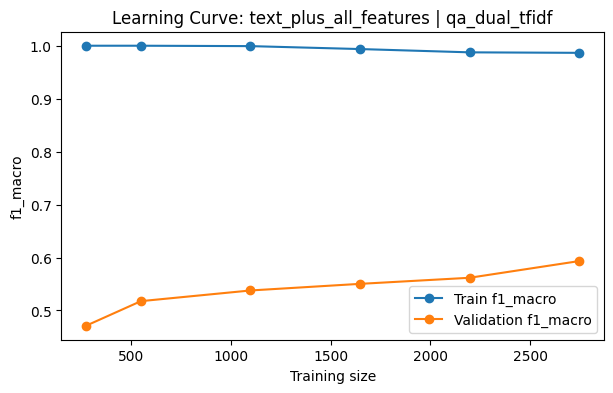

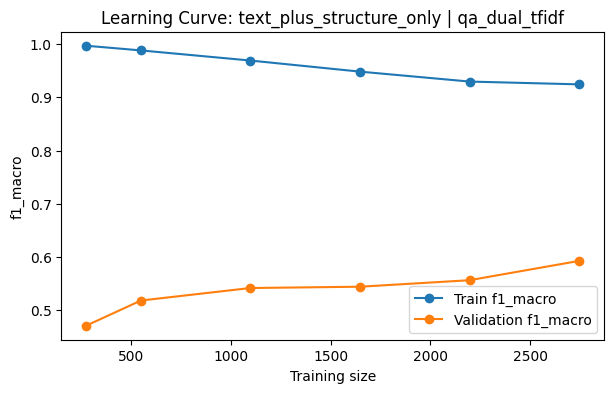

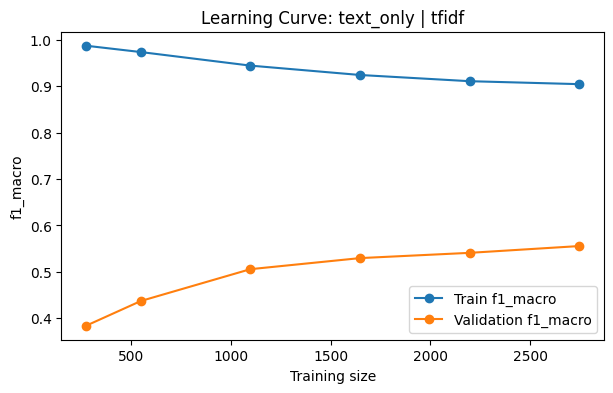

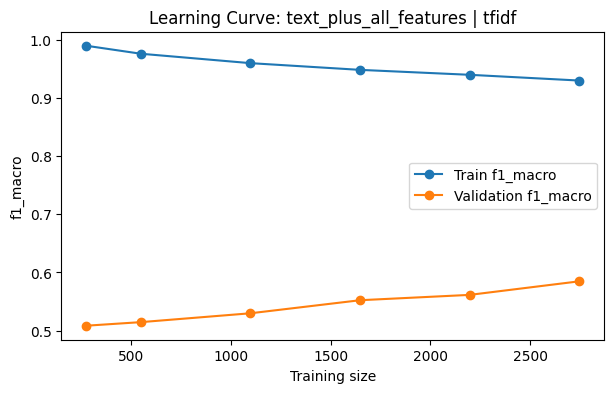

In [111]:
if NOTEBOOK_RUN_CONTROL.get("mode", "full_train") == "submit_mode":
    print("Submit mode: skipping learning-curve plots.")
else:
    metric_to_plot = LEARNING_CURVE_CONFIG["selection_metric"]  # usually f1_macro

    systems_in_df = (
        learning_curve_df[["experiment_name", "representation_name"]]
        .drop_duplicates()
        .to_dict("records")
    )

    for system in systems_in_df:
        experiment_name = system["experiment_name"]
        representation_name = system["representation_name"]

        plot_df = learning_curve_df[
            (learning_curve_df["experiment_name"] == experiment_name) &
            (learning_curve_df["representation_name"] == representation_name)
        ].sort_values("train_size")

        plt.figure(figsize=(7, 4))
        plt.plot(plot_df["train_size"], plot_df[f"train_{metric_to_plot}"], marker="o", label=f"Train {metric_to_plot}")
        plt.plot(plot_df["train_size"], plot_df[f"val_{metric_to_plot}"], marker="o", label=f"Validation {metric_to_plot}")
        plt.xlabel("Training size")
        plt.ylabel(metric_to_plot)
        plt.title(f"Learning Curve: {experiment_name} | {representation_name}")
        plt.legend()
        plt.show()

## Compact table for report writing

This table makes it easier to discuss:
- whether the model is still improving with more data
- whether there is a large train/validation gap
- whether engineered features help more at small or large data sizes

In [112]:
if NOTEBOOK_RUN_CONTROL.get("mode", "full_train") == "submit_mode":
    print("Submit mode: skipping learning-curve summary.")
else:
    learning_curve_summary_df = learning_curve_df.copy()
    learning_curve_summary_df["generalization_gap_f1_macro"] = (
        learning_curve_summary_df["train_f1_macro"] - learning_curve_summary_df["val_f1_macro"]
    )

    display(learning_curve_summary_df)

,experiment_name,representation_name,train_fraction,train_size,val_size,num_engineered_features,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,generalization_gap_f1_macro
0,text_plus_all_features,qa_dual_tfidf,0.1,274,687,159,1.000000,1.000000,0.599709,0.471174,0.528826
1,text_plus_all_features,qa_dual_tfidf,0.2,549,687,159,1.000000,1.000000,0.618632,0.517594,0.482406
2,text_plus_all_features,qa_dual_tfidf,0.4,1098,687,159,0.999089,0.999246,0.614265,0.537743,0.461503
3,text_plus_all_features,qa_dual_tfidf,0.6,1648,687,159,0.993932,0.993705,0.615721,0.550252,0.443453
4,text_plus_all_features,qa_dual_tfidf,0.8,2197,687,159,0.989076,0.987502,0.614265,0.561736,0.425765
5,text_plus_all_features,qa_dual_tfidf,1.0,2747,687,159,0.986531,0.986561,0.640466,0.593304,0.393257
6,text_plus_structure_only,qa_dual_tfidf,0.1,274,687,144,0.996350,0.996996,0.593886,0.470914,0.526081
7,text_plus_structure_only,qa_dual_tfidf,0.2,549,687,144,0.990893,0.988186,0.620087,0.518267,0.469918
8,text_plus_structure_only,qa_dual_tfidf,0.4,1098,687,144,0.969945,0.969144,0.615721,0.541755,0.427389
9,text_plus_structure_only,qa_dual_tfidf,0.6,1648,687,144,0.950850,0.948292,0.614265,0.544192,0.404099


## Easy system switching

To change which systems get learning curves, edit only:

- `LEARNING_CURVE_CONFIG["systems"]`

For example:
- `text_only` + `tfidf`
- `text_plus_all_features` + `tfidf`
- `text_only` + `word2vec`
- `text_plus_all_features` + `word2vec`
- `text_only` + `word2vec_wiki_finetuned`
- `text_plus_all_features` + `word2vec_wiki_finetuned`

There is no need to rewrite any of the logic below.

In [113]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping learning-curve system listing.')
else:
    print("Currently configured systems for learning curves:")
    for system in LEARNING_CURVE_CONFIG["systems"]:
        print(system)


Currently configured systems for learning curves:
{'experiment_name': 'text_only', 'representation_name': 'tfidf'}
{'experiment_name': 'text_plus_all_features', 'representation_name': 'tfidf'}
{'experiment_name': 'text_plus_all_features', 'representation_name': 'qa_dual_tfidf'}
{'experiment_name': 'text_plus_structure_only', 'representation_name': 'qa_dual_tfidf'}


## Suggested interpretation

A useful reading of these curves is:

- if training score is high but validation score is much lower, the model is overfitting
- if both scores are low, the model may be underpowered or the task may need richer features
- if validation score keeps increasing with more data, the model still benefits from additional training data
- if `text_plus_all_features` stays above `text_only`, the engineered features are likely helping consistently

# 9. Error analysis and model interpretation

After comparing validation scores, the next step is to inspect *why* certain systems perform better or worse.

This section supports report writing by adding:
- per-class validation reports
- confusion matrices
- misclassification inspection
- TF–IDF coefficient analysis
- engineered-feature coefficient analysis

These diagnostics help identify whether errors are concentrated in particular classes, whether the model confuses specific label pairs, and whether certain lexical cues dominate the classifier.

In [114]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

## Selecting one experiment to inspect

The following cells let us inspect a specific trained experiment from the multi-experiment comparison section.

By default, we inspect the best overall validation result, but this can be changed to compare different systems manually.

In [115]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping error-analysis experiment selection.')
    INSPECT_EXPERIMENT_NAME = None
    INSPECT_REPRESENTATION = None
    inspect_result = None
else:
    # Default: inspect the best overall experiment from the summary table
    INSPECT_EXPERIMENT_NAME = all_results_summary_df.iloc[0]["experiment_name"]
    INSPECT_REPRESENTATION = all_results_summary_df.iloc[0]["representation_name"]

    inspect_matches = [
        res for res in all_experiment_results
        if res["experiment_name"] == INSPECT_EXPERIMENT_NAME
        and res["representation_name"] == INSPECT_REPRESENTATION
    ]

    if len(inspect_matches) == 0:
        raise ValueError("No matching experiment found for inspection.")

    inspect_result = inspect_matches[0]

    print("Inspecting experiment:")
    print("experiment_name:", INSPECT_EXPERIMENT_NAME)
    print("representation_name:", INSPECT_REPRESENTATION)
    print("num_engineered_features:", inspect_result.get("num_engineered_features", 0))
    print_classification_metrics(inspect_result["metrics"], prefix="Validation metrics:")


Inspecting experiment:
experiment_name: text_plus_relational_core
representation_name: qa_dual_tfidf
num_engineered_features: 120
Validation metrics:
accuracy: 0.6492
precision_macro: 0.6075
recall_macro: 0.5969
f1_macro: 0.6017
precision_weighted: 0.6445
recall_weighted: 0.6492
f1_weighted: 0.6463


## Per-class validation report

This table shows precision, recall, and F1 for each class separately.

It is especially useful in multiclass settings where one class may be much harder than the others.

In [116]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping per-class validation report.')
else:
    inspect_report_df = pd.DataFrame(inspect_result["classification_report_dict"]).T
    display(inspect_report_df)


,precision,recall,f1-score,support
Ambivalent,0.712941,0.746305,0.729242,406.000000
Clear Reply,0.536082,0.495238,0.514851,210.000000
Clear Non-Reply,0.573529,0.549296,0.561151,71.000000
accuracy,0.649199,0.649199,0.649199,0.649199
macro avg,0.607518,0.596946,0.601748,687.000000
weighted avg,0.644472,0.649199,0.646336,687.000000


## Confusion matrix

The confusion matrix shows which label pairs are most often confused.

This is useful for identifying systematic errors, such as confusing `Ambivalent` with `Clear Non-Reply`.

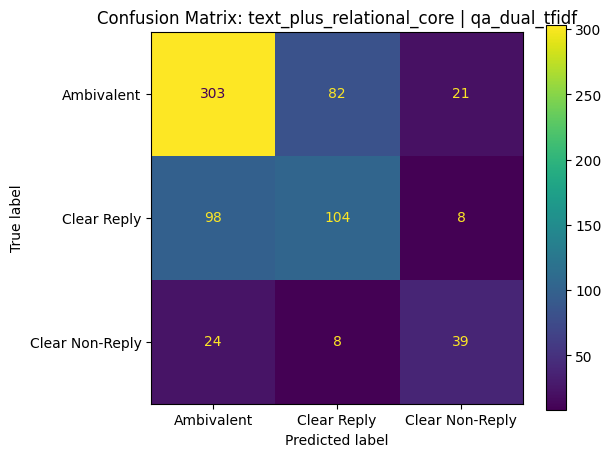

In [117]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping confusion matrix.')
else:
    cm = inspect_result["confusion_matrix"]

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Confusion Matrix: {INSPECT_EXPERIMENT_NAME} | {INSPECT_REPRESENTATION}")
    plt.show()


## Recovering validation examples for inspection

To perform targeted error analysis, we recover the exact validation rows directly from the stored experiment result.

This lets us examine:
- raw question / answer text
- processed question / answer text
- gold label
- predicted label
- whether the prediction was correct

Because the multi-experiment comparison section now stores the actual validation indices used in each split-safe experiment, this recovery matches the validation predictions exactly without rerunning the split.

In [118]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping validation example recovery.')
else:
    val_idx = inspect_result["val_index"]
    df_val_inspect = df_train_proc.loc[val_idx].copy()

    df_val_inspect["y_true"] = (
        inspect_result["y_val"].values
        if hasattr(inspect_result["y_val"], "values")
        else inspect_result["y_val"]
    )
    df_val_inspect["y_pred"] = inspect_result["y_val_pred"]
    df_val_inspect["is_correct"] = (df_val_inspect["y_true"] == df_val_inspect["y_pred"]).astype(int)

    print("Validation inspection dataframe shape:", df_val_inspect.shape)


Validation inspection dataframe shape: (687, 173)


## Overall misclassification preview

This table shows a sample of misclassified validation examples.

In [119]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping misclassification preview.')
else:
    misclassified_df = df_val_inspect[df_val_inspect["is_correct"] == 0].copy()

    misclassified_preview_cols = [
        ID_COL,
        PREPROCESS_CONFIG["question_col"],
        PREPROCESS_CONFIG["answer_col"],
        PREPROCESS_CONFIG["question_processed_col"],
        PREPROCESS_CONFIG["answer_processed_col"],
        "y_true",
        "y_pred",
    ]

    print("Number of misclassified validation examples:", len(misclassified_df))
    display(misclassified_df[misclassified_preview_cols].head(20))


Number of misclassified validation examples: 241


,index,question,interview_answer,question_processed,answer_processed,y_true,y_pred
2104,2118,Did you talk about the Italian Marine riflemen during your talks?,"When it comes to defense spending, all of us have to make sure that our defense forces are efficient, effective; that for every dollar or lira that we're spending, that we're getting the most defense for our money.And so in the United States, we've reduced our defense spending as we've brought t...",talk italian marine rifleman talk,come defense spending make sure defense force efficient effective dollar lira spend defense money united states ve reduce defense spending ve bring war close natural transition kind spending increase unsustainable recognize europe discuss president napolitano opportunity great efficiency country...,Clear Reply,Ambivalent
41,41,Bribery allegations against President Biden,"But wait, wait, wait, wait, wait.",bribery allegation president biden,wait wait wait wait wait,Ambivalent,Clear Reply
3123,3137,Can you clarify who has the authority and control over this issue?,"I did say it should be a goal of the Nation to shut down Guantanamo. I also made it clear that part of the delay was the reluctance of some nations to take back some of the people being held there. In other words, in order to make it work, we've got to have a place for these people to go. I don'...",clarify authority control issue,say goal nation shut guantanamo make clear delay reluctance nation people hold word order make work ve place people neg_know notice resolution senate day senator say neg_want prisoner country neg_know range_tok vote number_tok vote word issue peter practical issue people qmark say place strongly...,Clear Reply,Clear Non-Reply
198,198,Inquiring about the belief in an off-ramp for Vladimir Putin.,Yes.,inquire belief ramp vladimir putin,yes,Clear Reply,Ambivalent
2776,2790,Betrayal by Scott McClellan's assessment of the war in Iraq,"I have had no comment on—no comment now on Scott's book.Secondly, I would ask him to listen carefully to Ryan Crocker and General Petraeus. It's—there's a temptation to kind of get—let the politics at home get in the way with the considered judgment of the commanders. That's why I strongly rejec...",betrayal scott mcclellan assessment war iraq,comment comment scott book secondly ask listen carefully ryan crocker general petraeus temptation kind let politic home way consider judgment commander strongly reject artificial timetable withdrawal kind like arbitrary thing know decide hall congress conduct affair base poll politic impose peop...,Clear Non-Reply,Clear Reply
1603,1603,Have you made up your mind to pull out of that deal?,"No, I think it sends the right message. You know, in 7 years that deal will have expired and Iran is free to go ahead and create nuclear weapons. That's not acceptable. Seven years is tomorrow. That's not acceptable.So no, if anything, it's proven right what Israel has done today with the news c...",make mind pull deal,think send right message know duration_tok deal expire iran free ahead create nuclear weapon neg_acceptable duration_tok tomorrow neg_be acceptable prove right israel today news conference prime minister netanyahu just neg_know everybody little bit neg_be just acceptable situation ve say happen ...,Ambivalent,Clear Reply
589,589,Can you say whether you yourself think that annexation should be off the table for Israel?,"Well, not off the table. No. It's something they've discussed, but Israel has agreed not to do that. I mean, more than just off the table, they have agreed not to do it. And I think that was very important, and I think it was a great concession by Israel, and I think it was a very smart concessi...",say think annexation table israel,table ve discuss israel agree neg_do mean just table agree neg_do think important think great concession israel think smart concession israel david add,Clear Reply,Ambivalent
1412,1412,Request for permission to ask a question,Since you're where? Sin

## Misclassifications by true/predicted label pair

This view is useful for targeted analysis of specific confusions.
For example, it can isolate cases where the true label is `Ambivalent` but the model predicts `Clear Reply`.

In [120]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping confusion-pair summary.')
else:
    confusion_pairs_df = (
        misclassified_df
        .groupby(["y_true", "y_pred"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    display(confusion_pairs_df)


,y_true,y_pred,count
0,Clear Reply,Ambivalent,98
1,Ambivalent,Clear Reply,82
2,Clear Non-Reply,Ambivalent,24
3,Ambivalent,Clear Non-Reply,21
4,Clear Non-Reply,Clear Reply,8
5,Clear Reply,Clear Non-Reply,8


## Inspecting one specific confusion pair

Change the labels below to inspect a particular confusion pattern in more detail.

In [121]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping focused confusion inspection.')
else:
    FOCUS_TRUE_LABEL = "Ambivalent"
    FOCUS_PRED_LABEL = "Clear Reply"

    focused_confusions_df = misclassified_df[
        (misclassified_df["y_true"] == FOCUS_TRUE_LABEL) &
        (misclassified_df["y_pred"] == FOCUS_PRED_LABEL)
    ].copy()

    print(f"Examples where true='{FOCUS_TRUE_LABEL}' and predicted='{FOCUS_PRED_LABEL}': {len(focused_confusions_df)}")

    display(
        focused_confusions_df[
            [
                ID_COL,
                PREPROCESS_CONFIG["question_col"],
                PREPROCESS_CONFIG["answer_col"],
                PREPROCESS_CONFIG["question_processed_col"],
                PREPROCESS_CONFIG["answer_processed_col"],
                "y_true",
                "y_pred",
            ]
        ].head(20)
    )


Examples where true='Ambivalent' and predicted='Clear Reply': 82


,index,question,interview_answer,question_processed,answer_processed,y_true,y_pred
41,41,Bribery allegations against President Biden,"But wait, wait, wait, wait, wait.",bribery allegation president biden,wait wait wait wait wait,Ambivalent,Clear Reply
1603,1603,Have you made up your mind to pull out of that deal?,"No, I think it sends the right message. You know, in 7 years that deal will have expired and Iran is free to go ahead and create nuclear weapons. That's not acceptable. Seven years is tomorrow. That's not acceptable.So no, if anything, it's proven right what Israel has done today with the news c...",make mind pull deal,think send right message know duration_tok deal expire iran free ahead create nuclear weapon neg_acceptable duration_tok tomorrow neg_be acceptable prove right israel today news conference prime minister netanyahu just neg_know everybody little bit neg_be just acceptable situation ve say happen ...,Ambivalent,Clear Reply
480,480,Why do you object to that being taught in schools?,"Yes, so—no, I want everybody to know everything they can about our history. I'm not a believer in cancel culture, the good or the bad. If you don't study the bad, it could happen again. So I do want that subject studied very, very carefully and very accurately.But we grew up with a certain histo...",object teach school,yes want everybody know history neg_be believer cancel culture good bad study neg_bad happen want subject study carefully accurately grow certain history try change history revisionist history want monument want statues day absolutely horrendous washington monument want rename dc committee dc co...,Ambivalent,Clear Reply
1078,1078,Request for evidence on how mail-in ballots in Nevada and other states will lead to widespread fraud.,"Well, if you read, even the Washington Post had a terrible story on mail-in and the New York Times. And many, many newspapers have had terrible stories. You see them all over the internet. They've had some just horrible stories on mail-in ballots.You look at Arizona [Nevada]*, you don't even hav...",request evidence mail ballot nevada state lead widespread fraud,read washington post terrible story mail new york times newspaper terrible story internet ve just horrible story mail ballots look arizona nevada neg_have know provision neg_have check signature sign totally different signature okay neg_approve right duration_tok election approval neg_go know wi...,Ambivalent,Clear Reply
3199,3213,No—nothing else that might have worked?,"Well, we tried other things. As you might remember back then, we tried the diplomatic route: 1441 was a unanimous vote in the Security Council that said disclose, disarm, or face serious consequences. So the choice was his to make. And he made a choice that has subsequently left—subsequently cau...",work,try thing remember try diplomatic route number_tok unanimous vote security council say disclose disarm face consequence choice make make choice subsequently leave subsequently cause lose life neg_give citizen try diplomacy matter fact try diplomacy president try diplomacy let john john mckinnon ...,Ambivalent,Clear Reply
1529,1529,Is it true that you are stopping the military exercises with South Korea?,"Yes, we've done exercises for a long period of time, working with South Korea. And we call them war games, and I call them war games. And they're tremendously expensive. The amount of money that we spend on that is incredible. And South Korea contributes, but not a hundred percent, which is cert...",true stop military exercise south korea,yes ve exercise long period time work south korea war game war game tremendously expensive money spend incredible south korea contribute percent certainly subject talk military expense trade actually new deal south korea term trade deal talk talk country treat fairly war game expensive pay big m...,Ambivalent,Clear Reply
1628,1628,Can the relationship between President Macron and President Trump have a concrete impact on Fran

## Correct prediction examples

Inspecting correctly classified examples can also be useful, because it helps reveal the kinds of lexical or structural cues the model handles well.

In [122]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping correct-example preview.')
else:
    correct_df = df_val_inspect[df_val_inspect["is_correct"] == 1].copy()

    print("Number of correctly classified validation examples:", len(correct_df))
    display(
        correct_df[
            [
                ID_COL,
                PREPROCESS_CONFIG["question_col"],
                PREPROCESS_CONFIG["answer_col"],
                PREPROCESS_CONFIG["question_processed_col"],
                PREPROCESS_CONFIG["answer_processed_col"],
                "y_true",
                "y_pred",
            ]
        ].head(20)
    )


Number of correctly classified validation examples: 446


,index,question,interview_answer,question_processed,answer_processed,y_true,y_pred
2467,2481,"The question is asking about the Japanese press and their interaction with the President, specifically requesting information about the President's interaction with the Japanese media.","From the Japanese media, because of--because obviously, we're concerned about what's happening in Japan.",question ask japanese press interaction president specifically request information president interaction japanese medium,japanese medium obviously concerned happen japan,Ambivalent,Ambivalent
1818,1818,Do you still have any concern about his temperament?,"As I saidbecause, Athena asked the questionwhatever you bring to this office, this office has a habit of magnifying and pointing out, and hopefully, then you correct for it.This may seem like a silly example, but I know myself well enough to know I can't keep track of paper. I am not well organi...",concern temperament,saidbecause athena ask questionwhatever bring office office habit magnify point hopefully correct month_tok like silly example know know neg_keep track paper neg_organize way pretty quickly stack briefing book come daypart_tok say ve figure bad filing sort organizing habit ve people help track s...,Ambivalent,Ambivalent
2894,2908,Concrete measures to address soaring food prices,"Let me start on Iran here. If they learn how to enrich, it is knowledge which can be used to develop a nuclear weapon. They claimed that they've got a civilian program in place, that this is only for civilian purposes. If that's the case, why did they have a secret program? Why have they violate...",concrete measure address soar food price,let start iran learn enrich knowledge use develop nuclear weapon claim ve civilian program place civilian purpose case secret program violate iaea objective hand recognize sovereign right civilian power join russia provide fuel necessary run civilian nuclear facility honor agreement ve sign prov...,Clear Reply,Clear Reply
1229,1229,"Why are you pitting Americans against one another, sir?","Excuse me. Peter. Peter, what, are you trying to be him?",pit americans sir,excuse peter peter try,Ambivalent,Ambivalent
2482,2496,Do you think the markets will wait 2 years?,"I should have written all this down, Jackie. [] I'm running out of room here in my brain.",think market wait duration_tok,write jackie run room brain,Clear Non-Reply,Clear Non-Reply
1552,1552,How can the sanctions regime be kept in place when other countries seem to be moving towards eroding it?,"Well, I think we have a lot of leverage. I think we have tremendous leverage. I do believe that China, despite my relationship with President Xi—a man who I told you I have great respect for and like, also, a lot. You know, we're having very tough talks on trade. And I think that probably affect...",sanction regime place country erode,think lot leverage think tremendous leverage believe china despite relationship president xi man tell great respect like lot know tough talk trade think probably affect china somewhat think duration_tok border open start tremendous deficit trade commonly know trade deficit tremendous deficit tra...,Ambivalent,Ambivalent
83,83,Changes in migration policies and the treatment of migrants after the summit.,"Very well. We did speak about migration in a very broad manner. Of course, there is cooperation with the U.S. administration. And at the same time, we have a commitment to protect migrants.What President Biden has proposed is absolutely true. If migrants cross our country—and, in some cases, the...",change migration policy treatment migrant summit,speak migration broad manner course cooperation administration time commitment protect migrants president biden propose absolutely true migrant cross country case country latin america arrive united states migrant face risk start fact victim trafficant smuggler human trafficker know charge migra...,Ambivalent,Ambivalent
2657,2671,What are your thoug

## TF–IDF text coefficient analysis

For linear models trained on TF–IDF, the learned coefficients can provide interpretable lexical signals.

Unlike the earlier version, this works even when engineered features were appended:
- the text coefficients are taken from the TF–IDF part only
- the engineered-feature coefficients are inspected separately later

This makes it possible to interpret the lexical TF–IDF cues in both:
- `text_only`
- `text_plus_all_features`

In [123]:

def extract_top_text_features_per_class(
    model,
    feature_names,
    top_n=20
):
    """
    Extract strongest positive and negative text coefficients per class for
    any sparse linear representation whose text features occupy the first block.
    """
    if not hasattr(model, "coef_"):
        raise ValueError("Model does not expose coefficients.")

    feature_names = np.array(feature_names)
    num_text_features = len(feature_names)

    coef_matrix = model.coef_[:, :num_text_features]
    rows = []

    for class_idx, class_label in enumerate(model.classes_):
        coef = coef_matrix[class_idx]

        top_pos_idx = np.argsort(coef)[-top_n:][::-1]
        top_neg_idx = np.argsort(coef)[:top_n]

        for rank, feat_idx in enumerate(top_pos_idx, start=1):
            rows.append({
                "class_label": class_label,
                "direction": "positive",
                "rank": rank,
                "feature": feature_names[feat_idx],
                "coefficient": coef[feat_idx],
                "abs_coefficient": abs(coef[feat_idx]),
            })

        for rank, feat_idx in enumerate(top_neg_idx, start=1):
            rows.append({
                "class_label": class_label,
                "direction": "negative",
                "rank": rank,
                "feature": feature_names[feat_idx],
                "coefficient": coef[feat_idx],
                "abs_coefficient": abs(coef[feat_idx]),
            })

    return pd.DataFrame(rows)


In [124]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping text coefficient analysis.')
else:

    if INSPECT_REPRESENTATION not in {"tfidf", "qa_dual_tfidf"}:
        print("Text coefficient inspection skipped because the selected experiment is not TF-IDF-family.")
    else:
        inspect_bundle = all_bundles[(INSPECT_EXPERIMENT_NAME, INSPECT_REPRESENTATION)]

        if INSPECT_REPRESENTATION == "tfidf":
            inspect_feature_names = inspect_bundle["vectorizer"].get_feature_names_out()
        else:
            inspect_feature_names = inspect_bundle["text_feature_names"]

        top_text_features_df = extract_top_text_features_per_class(
            model=inspect_result["model"],
            feature_names=inspect_feature_names,
            top_n=20
        )

        display(top_text_features_df)


,class_label,direction,rank,feature,coefficient,abs_coefficient
0,Ambivalent,positive,1,a_open::happen,0.902588,0.902588
1,Ambivalent,positive,2,q_word::sanction,0.803186,0.803186
2,Ambivalent,positive,3,q_shared::sanction,0.758325,0.758325
3,Ambivalent,positive,4,q_word::know,0.676686,0.676686
4,Ambivalent,positive,5,q_word::care,0.659884,0.659884
...,...,...,...,...,...,...
115,Clear Reply,negative,16,q_shared::timetable,-0.619092,0.619092
116,Clear Reply,negative,17,a_open::discussion,-0.597629,0.597629
117,Clear Reply,negative,18,q_word::scam,-0.593319,0.593319
118,Clear Reply,negative,19,q_word::sir,-0.592985,0.592985


## Viewing TF–IDF text coefficient extremes more cleanly

The next cells separate the strongest positive and strongest negative lexical cues by class.

In [125]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping positive text coefficient view.')
else:
    if INSPECT_REPRESENTATION not in {"tfidf", "qa_dual_tfidf"}:
        print("Text coefficient view skipped because the selected experiment is not TF-IDF-family.")
    else:
        display(
            top_text_features_df[top_text_features_df["direction"] == "positive"]
            .sort_values(["class_label", "rank"])
            .reset_index(drop=True)
        )


,class_label,direction,rank,feature,coefficient,abs_coefficient
0,Ambivalent,positive,1,a_open::happen,0.902588,0.902588
1,Ambivalent,positive,2,q_word::sanction,0.803186,0.803186
2,Ambivalent,positive,3,q_shared::sanction,0.758325,0.758325
3,Ambivalent,positive,4,q_word::know,0.676686,0.676686
4,Ambivalent,positive,5,q_word::care,0.659884,0.659884
5,Ambivalent,positive,6,a_open::great,0.647198,0.647198
6,Ambivalent,positive,7,a_open::difficult,0.641261,0.641261
7,Ambivalent,positive,8,q_word::scam,0.634144,0.634144
8,Ambivalent,positive,9,a_open::person,0.631922,0.631922
9,Ambivalent,positive,10,q_word::syria,0.629241,0.629241


In [126]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping negative text coefficient view.')
else:
    if INSPECT_REPRESENTATION not in {"tfidf", "qa_dual_tfidf"}:
        print("Text coefficient view skipped because the selected experiment is not TF-IDF-family.")
    else:
        display(
            top_text_features_df[top_text_features_df["direction"] == "negative"]
            .sort_values(["class_label", "rank"])
            .reset_index(drop=True)
        )


,class_label,direction,rank,feature,coefficient,abs_coefficient
0,Ambivalent,negative,1,a_open::answer,-0.811533,0.811533
1,Ambivalent,negative,2,a_open::deal,-0.727515,0.727515
2,Ambivalent,negative,3,a_open::comment,-0.689110,0.689110
3,Ambivalent,negative,4,q_word::support,-0.643891,0.643891
4,Ambivalent,negative,5,a_open::situation,-0.643168,0.643168
5,Ambivalent,negative,6,a_open::answer yes,-0.638259,0.638259
6,Ambivalent,negative,7,a_open::news,-0.636616,0.636616
7,Ambivalent,negative,8,q_word::conversation,-0.620331,0.620331
8,Ambivalent,negative,9,q_word::consider,-0.601062,0.601062
9,Ambivalent,negative,10,qa_word::yes,-0.593137,0.593137


## Engineered-feature coefficient analysis

If the selected experiment includes engineered features, we can inspect which appended feature dimensions received the largest absolute weights.

This is the main coefficient-based view for:
- punctuation features
- surface-pattern features
- question-intent features
- answer-evidence features
- QA-alignment features
- overlap features
- answer-group features

In [127]:
def extract_top_engineered_feature_coefficients(result, top_n=15):
    """
    Inspect the strongest engineered-feature coefficients when they are appended
    after the text representation.
    """
    if result.get("num_engineered_features", 0) == 0:
        return None

    model = result["model"]
    feature_names = result["selected_feature_cols"]
    num_engineered = len(feature_names)

    if not hasattr(model, "coef_"):
        return None

    coef_matrix = model.coef_[:, -num_engineered:]
    rows = []

    for class_idx, class_label in enumerate(model.classes_):
        coef = coef_matrix[class_idx]
        top_idx = np.argsort(np.abs(coef))[-top_n:][::-1]

        for rank, feat_idx in enumerate(top_idx, start=1):
            rows.append({
                "class_label": class_label,
                "rank": rank,
                "feature": feature_names[feat_idx],
                "coefficient": coef[feat_idx],
                "abs_coefficient": abs(coef[feat_idx]),
            })

    return pd.DataFrame(rows)

In [128]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping engineered-feature coefficient view.')
else:
    top_engineered_df = extract_top_engineered_feature_coefficients(
        result=inspect_result,
        top_n=15
    )

    if top_engineered_df is None:
        print("No engineered-feature coefficient view available for this experiment.")
    else:
        display(top_engineered_df)


,class_label,rank,feature,coefficient,abs_coefficient
0,Ambivalent,1,qa_answer_unique_token_ratio,0.763603,0.763603
1,Ambivalent,2,question_is_how,0.753500,0.753500
2,Ambivalent,3,answer_has_positive_polarity_marker,0.744375,0.744375
3,Ambivalent,4,qa_any_alignment_match,-0.646354,0.646354
4,Ambivalent,5,question_is_when,0.609875,0.609875
5,Ambivalent,6,answer_has_explicit_polarity_marker,-0.607571,0.607571
6,Ambivalent,7,qa_shared_fraction_of_shorter,-0.567448,0.567448
7,Ambivalent,8,qa_question_bigram_coverage,-0.558492,0.558492
8,Ambivalent,9,qa_question_has_i_target,-0.505539,0.505539
9,Ambivalent,10,pair_answer_token_coverage,0.495817,0.495817


## Optional: inspect all engineered coefficients sorted globally

This view is useful when you want one single ranking of the strongest engineered coefficients across all classes.

In [129]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping global engineered-coefficient view.')
else:
    if top_engineered_df is None:
        print("No engineered-feature coefficient view available for this experiment.")
    else:
        display(
            top_engineered_df.sort_values(
                by=["abs_coefficient", "class_label"],
                ascending=[False, True]
            ).reset_index(drop=True)
        )


,class_label,rank,feature,coefficient,abs_coefficient
0,Clear Non-Reply,1,answer_has_explicit_polarity_marker,-2.296053,2.296053
1,Clear Non-Reply,2,answer_has_positive_polarity_marker,2.135960,2.135960
2,Clear Reply,1,answer_has_positive_polarity_marker,-2.003337,2.003337
3,Clear Reply,2,answer_has_explicit_polarity_marker,1.885226,1.885226
4,Clear Non-Reply,3,answer_has_question_mark,1.112051,1.112051
5,Clear Non-Reply,4,qa_question_unanswered_token_ratio,-0.981255,0.981255
6,Clear Non-Reply,5,qa_answer_unique_token_ratio,-0.891508,0.891508
7,Clear Non-Reply,6,pair_answer_longer_than_question,-0.880230,0.880230
8,Clear Non-Reply,7,answer_has_negative_polarity_marker,0.873503,0.873503
9,Clear Non-Reply,8,pair_question_token_coverage,-0.866361,0.866361


## Notes for the report

The analyses above are useful for writing the discussion section of the report.

In particular, they help answer:
- which classes are hardest to distinguish
- whether engineered features improve specific confusions
- whether TF–IDF or Word2Vec captures clearer lexical signals
- which types of answers remain difficult, even after preprocessing and feature engineering
- whether the answer-group features appear to contribute meaningful signal

## What comes next

At this point, the notebook supports:
- preprocessing
- representation construction
- multiclass model comparison
- error analysis and interpretation

The next section should select the best experiment, retrain it on the full training data, and generate the final `submission.csv` file for Kaggle.

## Ranking candidate systems and choosing the active final candidate

By default, the notebook still ranks candidates by **local validation macro F1** and then by **accuracy**.

The new workflow also supports:

- **manual candidate override** inside the current run
- **artifact persistence** for the top candidate systems
- a lightweight **submit mode** that can load a previously saved candidate submission/artifact from disk


In [130]:
if IS_SUBMIT_MODE:
    print('Submit mode: skipping candidate ranking and stage-1/stage-2 selection tables.')
    stage1_candidate_ranking_df = pd.DataFrame()
    candidate_ranking_df = pd.DataFrame()
    best_overall_summary = None
else:

    def _extract_stage1_selected_model_params(exp_name, rep_name, all_experiment_results):
        matches = [
            res for res in all_experiment_results
            if res["experiment_name"] == exp_name and res["representation_name"] == rep_name
        ]
        if len(matches) == 0:
            return None
        return copy.deepcopy(matches[0]["model_params"])


    stage1_candidate_ranking_df = (
        all_results_summary_df
        .sort_values(by=["f1_macro", "accuracy"], ascending=False)
        .reset_index(drop=True)
        .copy()
    )
    stage1_candidate_ranking_df["source_stage"] = "stage1"
    stage1_candidate_ranking_df["variant_label"] = "baseline"
    stage1_candidate_ranking_df["selected_model_params"] = stage1_candidate_ranking_df.apply(
        lambda row: _extract_stage1_selected_model_params(
            row["experiment_name"],
            row["representation_name"],
            all_experiment_results,
        ),
        axis=1,
    )
    stage1_candidate_ranking_df["tfidf_config_override"] = None
    stage1_candidate_ranking_df["dual_tfidf_config_override"] = None
    stage1_candidate_ranking_df["cv_mean_f1_macro"] = np.nan
    stage1_candidate_ranking_df["cv_std_f1_macro"] = np.nan
    stage1_candidate_ranking_df["cv_mean_accuracy"] = np.nan
    stage1_candidate_ranking_df["cv_std_accuracy"] = np.nan

    candidate_tables = [stage1_candidate_ranking_df]

    if "second_stage_best_variant_df" in globals() and len(second_stage_best_variant_df) > 0:
        candidate_tables.append(second_stage_best_variant_df.copy())

    candidate_ranking_df = (
        pd.concat(candidate_tables, ignore_index=True, sort=False)
        .sort_values(
            by=["f1_macro", "cv_mean_f1_macro", "accuracy"],
            ascending=False,
            na_position="last",
        )
        .reset_index(drop=True)
        .copy()
    )
    candidate_ranking_df["rank"] = np.arange(1, len(candidate_ranking_df) + 1)

    best_overall_summary = candidate_ranking_df.iloc[0]

    print("Stage-1 best validation-ranked candidate:")
    display(stage1_candidate_ranking_df.iloc[[0]])

    if len(candidate_tables) > 1:
        print("Best candidate after adding second-stage refinement:")
    else:
        print("Best candidate (no second-stage refinement available):")
    display(best_overall_summary.to_frame().T)

    print("Top ranked candidates for final rebuild / submission:")
    display(
        candidate_ranking_df[[
            "rank", "experiment_name", "representation_name", "source_stage", "variant_label",
            "f1_macro", "accuracy", "cv_mean_f1_macro", "cv_std_f1_macro"
        ]].head(15)
    )


Stage-1 best validation-ranked candidate:


,experiment_name,representation_name,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,param_C,...,external_pretraining_used,source_stage,variant_label,selected_model_params,tfidf_config_override,dual_tfidf_config_override,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_accuracy,cv_std_accuracy
0,text_plus_relational_core,qa_dual_tfidf,0.649199,0.607518,0.596946,0.601748,0.644472,0.649199,0.646336,1.0,...,False,stage1,baseline,"{'C': 1.0, 'solver': 'liblinear', 'max_iter': 3000, 'class_weight': 'balanced', 'random_state': 42}",None,None,NaN,NaN,NaN,NaN


Best candidate after adding second-stage refinement:


,experiment_name,representation_name,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,param_C,...,tfidf_config_override,dual_tfidf_config_override,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_accuracy,cv_std_accuracy,cv_mean_precision_macro,cv_mean_recall_macro,cv_folds,rank
0,text_plus_relational_core,qa_dual_tfidf,0.652111,0.610313,0.601654,0.60576,0.649076,0.652111,0.650398,NaN,...,None,"{'shared_word_enabled': True, 'shared_word_ngram_range': (1, 2), 'shared_word_min_df': 3, 'shared_word_max_df': 0.95, 'shared_word_max_features': 15000, 'question_word_enabled': True, 'question_word_ngram_range': (1, 2), 'question_word_min_df': 2, 'question_word_max_df': 0.98, 'question_word_max...",0.578529,0.014549,0.631916,0.005714,0.594974,0.566826,5.0,1


Top ranked candidates for final rebuild / submission:


,rank,experiment_name,representation_name,source_stage,variant_label,f1_macro,accuracy,cv_mean_f1_macro,cv_std_f1_macro
0,1,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_sparse_regularized,0.605760,0.652111,0.578529,0.014549
1,2,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_base,0.601748,0.649199,0.587050,0.017113
2,3,text_plus_relational_core,qa_dual_tfidf,stage1,baseline,0.601748,0.649199,NaN,NaN
3,4,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_wider_spaces,0.599247,0.647744,NaN,NaN
4,5,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_full_capacity,0.598097,0.643377,NaN,NaN
5,6,text_plus_relational_core,qa_dual_tfidf,second_stage,dual_answer_heavy,0.597495,0.646288,NaN,NaN
6,7,text_plus_all_minus_answer_group,qa_dual_tfidf,stage1,baseline,0.595952,0.647744,NaN,NaN
7,8,text_plus_all_minus_answer_group,qa_dual_tfidf,second_stage,dual_base,0.595952,0.647744,NaN,NaN
8,9,text_plus_all_features,qa_dual_tfidf,second_stage,dual_full_capacity,0.595487,0.643377,NaN,NaN
9,10,text_plus_surface_structure,qa_dual_tfidf,second_stage,dual_sparse_regularized,0.595365,0.643377,NaN,NaN


In [131]:
def resolve_submission_columns(
    sample_submission_path,
    default_id_col="Id",
    default_pred_col="Predicted"
):
    """Resolve the ID and prediction column names from the competition sample submission."""
    sample_df = pd.read_csv(sample_submission_path)
    cols = list(sample_df.columns)

    id_candidates = [default_id_col, "Id", "id", "ID", "index"]
    pred_candidates = [default_pred_col, "Predicted", "predicted", "Label", "label", "prediction"]

    id_col = next((c for c in id_candidates if c in cols), cols[0])
    pred_col = next((c for c in pred_candidates if c in cols and c != id_col), None)

    if pred_col is None:
        if len(cols) < 2:
            raise ValueError(f"Could not resolve prediction column from sample submission columns: {cols}")
        pred_col = cols[1]

    return id_col, pred_col


def validate_submission_labels(y_pred, class_labels):
    """Ensure submission labels belong to the allowed label set."""
    y_pred = pd.Series(y_pred).astype(str)
    allowed = {str(x) for x in class_labels}
    found = set(y_pred.unique())
    invalid = sorted(found - allowed)
    if invalid:
        raise ValueError(
            f"Submission contains invalid labels: {invalid}. Allowed labels are: {sorted(allowed)}"
        )


def create_submission_dataframe(df_test, id_col, pred_col_name, y_test_pred):
    """Build a submission dataframe from test IDs and predicted labels."""
    if id_col not in df_test.columns:
        raise KeyError(f"ID column '{id_col}' not found in df_test columns: {list(df_test.columns)}")

    test_ids = df_test[id_col].reset_index(drop=True)
    y_test_pred = pd.Series(y_test_pred).astype(str).reset_index(drop=True)

    if len(test_ids) != len(y_test_pred):
        raise ValueError(
            f"Length mismatch between test IDs ({len(test_ids)}) and predictions ({len(y_test_pred)})."
        )

    return pd.DataFrame({
        id_col: test_ids,
        pred_col_name: y_test_pred,
    })


def train_final_model_on_full_training_set(X_train_full, y_train_full, model_params):
    """Train the final full-data classifier using the selected model parameters."""
    return train_logistic_regression_model(
        X_train=X_train_full,
        y_train=y_train_full,
        model_params=model_params
    )


def make_candidate_slug(experiment_name, representation_name, variant_label=None):
    safe_exp = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(experiment_name))
    safe_rep = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(representation_name))
    base = f"{safe_exp}__{safe_rep}"

    if variant_label is None or (isinstance(variant_label, float) and pd.isna(variant_label)):
        return base

    variant_label = str(variant_label)
    if variant_label.strip() == "" or variant_label == "baseline":
        return base

    safe_variant = re.sub(r"[^A-Za-z0-9_\-]+", "_", variant_label)
    return f"{base}__{safe_variant}"


def strip_bundle_for_inference(bundle, representation_name):
    """Remove large train/test matrices and raw text from a full bundle before saving."""
    if bundle is None:
        return None

    stripped = {}
    drop_keys = {
        "X_text_train", "X_text_test", "X_feat_train", "X_feat_test",
        "X_train_tfidf", "X_test_tfidf",
        "X_train_w2v", "X_test_w2v",
        "X_train_text", "X_test_text",
        "X_subtrain_text", "X_val_text",
        "X_train_final", "X_test_final",
        "q_train_word", "a_train_word", "q_other_word", "a_other_word",
        "q_train_w2v", "a_train_w2v", "qa_train_w2v",
        "q_other_w2v", "a_other_w2v", "qa_other_w2v",
        "joint_train_corpus", "q_train_corpus", "a_train_corpus", "qa_train_corpus",
        "q_other_corpus", "a_other_corpus", "qa_other_corpus",
        "train_corpus", "test_corpus",
        "y_train",
    }

    for k, v in bundle.items():
        if k in drop_keys:
            continue
        stripped[k] = v

    return stripped


def get_saved_candidate_paths(artifact_dir, candidate_slug):
    artifact_path = os.path.join(artifact_dir, f"{candidate_slug}.joblib")
    submission_path = os.path.join(artifact_dir, f"{candidate_slug}.csv")
    return artifact_path, submission_path


def resolve_active_candidate_summary(candidate_ranking_df, manual_candidate=None):
    if manual_candidate is None:
        return candidate_ranking_df.iloc[0]

    if isinstance(manual_candidate, dict):
        exp_name = manual_candidate.get("experiment_name")
        rep_name = manual_candidate.get("representation_name")
        variant_label = manual_candidate.get("variant_label", None)
    else:
        raise ValueError(
            "manual_candidate must be None or a dict with experiment_name, representation_name, "
            "and optionally variant_label"
        )

    matches = candidate_ranking_df[
        (candidate_ranking_df["experiment_name"] == exp_name) &
        (candidate_ranking_df["representation_name"] == rep_name)
    ]

    if variant_label is not None and "variant_label" in candidate_ranking_df.columns:
        matches = matches[matches["variant_label"] == variant_label]

    if len(matches) == 0:
        raise ValueError(f"Manual candidate not found in ranking table: {manual_candidate}")

    return matches.iloc[0]


def _normalize_optional_dict(obj):
    return copy.deepcopy(obj) if isinstance(obj, dict) else None


def resolve_best_validation_result_object(all_experiment_results, experiment_name, representation_name):
    matches = [
        res for res in all_experiment_results
        if res["experiment_name"] == experiment_name
        and res["representation_name"] == representation_name
    ]
    return matches[0] if len(matches) > 0 else None


def resolve_validation_result_from_candidate_summary(
    candidate_summary_row,
    all_experiment_results,
    second_stage_result_lookup=None,
):
    experiment_name = candidate_summary_row["experiment_name"]
    representation_name = candidate_summary_row["representation_name"]
    source_stage = candidate_summary_row.get("source_stage", "stage1")
    variant_label = candidate_summary_row.get("variant_label", None)

    if source_stage == "second_stage" and second_stage_result_lookup is not None:
        candidate_slug = make_candidate_slug(
            experiment_name,
            representation_name,
            variant_label=variant_label,
        )
        if candidate_slug in second_stage_result_lookup:
            return second_stage_result_lookup[candidate_slug]

    return resolve_best_validation_result_object(
        all_experiment_results=all_experiment_results,
        experiment_name=experiment_name,
        representation_name=representation_name,
    )


TFIDF_TUPLE_KEYS = {"ngram_range"}
DUAL_TFIDF_TUPLE_KEYS = {
    "shared_word_ngram_range",
    "question_word_ngram_range",
    "answer_word_ngram_range",
    "combined_qa_ngram_range",
    "answer_opening_ngram_range",
    "answer_char_ngram_range",
}

def _dedupe_preserve_order(seq):
    seen = set()
    out = []
    for x in seq:
        if x in seen:
            continue
        seen.add(x)
        out.append(x)
    return out


def _normalize_config_tuple_keys(config_dict, tuple_keys):
    if config_dict is None:
        return None

    out = copy.deepcopy(config_dict)
    for key in tuple_keys:
        if key in out and isinstance(out[key], list):
            out[key] = tuple(out[key])
    return out


def normalize_exact_final_model_config(exact_final_model_config):
    if exact_final_model_config is None:
        return None
    if not isinstance(exact_final_model_config, dict):
        raise ValueError("NOTEBOOK_RUN_CONTROL['exact_final_model_config'] must be a dict or None.")

    cfg = copy.deepcopy(exact_final_model_config)

    required_keys = ["experiment_name", "representation_name", "model_params"]
    missing_required = [k for k in required_keys if k not in cfg or cfg[k] is None]
    if missing_required:
        raise ValueError(
            "exact_final_model_config is missing required keys: "
            f"{missing_required}"
        )

    experiment_name = cfg["experiment_name"]
    representation_name = cfg["representation_name"]

    if experiment_name not in EXPERIMENT_PRESETS:
        raise ValueError(f"Unknown experiment_name in exact_final_model_config: {experiment_name}")

    valid_reps = {"tfidf", "qa_dual_tfidf"} | set(WORD2VEC_REPRESENTATION_CONFIGS.keys())
    if representation_name not in valid_reps:
        raise ValueError(
            f"Unknown representation_name in exact_final_model_config: {representation_name}. "
            f"Valid values: {sorted(valid_reps)}"
        )

    experiment_config = copy.deepcopy(cfg.get("experiment_config"))
    if experiment_config is None:
        experiment_config = copy.deepcopy(EXPERIMENT_PRESETS[experiment_name])

    if cfg.get("experiment_config_override") is not None:
        experiment_config.update(copy.deepcopy(cfg["experiment_config_override"]))

    if cfg.get("text_col") is not None:
        experiment_config["text_col"] = cfg["text_col"]

    if cfg.get("feature_groups") is not None:
        experiment_config["feature_groups"] = list(cfg["feature_groups"])
        experiment_config["use_engineered_features"] = len(experiment_config["feature_groups"]) > 0

    selected_feature_cols = cfg.get("selected_feature_cols", experiment_config.get("selected_feature_cols"))
    if selected_feature_cols is not None:
        experiment_config["selected_feature_cols"] = _dedupe_preserve_order(list(selected_feature_cols))
        experiment_config["use_engineered_features"] = len(experiment_config["selected_feature_cols"]) > 0

    if not experiment_config.get("use_engineered_features", False):
        experiment_config["selected_feature_cols"] = []

    tfidf_config = _normalize_config_tuple_keys(cfg.get("tfidf_config"), TFIDF_TUPLE_KEYS)
    dual_tfidf_config = _normalize_config_tuple_keys(cfg.get("dual_tfidf_config"), DUAL_TFIDF_TUPLE_KEYS)
    w2v_config = copy.deepcopy(cfg.get("w2v_config"))
    dual_w2v_config = copy.deepcopy(cfg.get("dual_w2v_config"))

    external_corpus_config_specified = "external_corpus_config" in cfg
    external_corpus_config = copy.deepcopy(cfg.get("external_corpus_config"))

    normalized = {
        "experiment_name": experiment_name,
        "representation_name": representation_name,
        "variant_label": cfg.get("variant_label", "exact_config"),
        "candidate_slug": cfg.get("candidate_slug"),
        "source_stage": cfg.get("source_stage", "exact_config"),
        "model_params": copy.deepcopy(cfg["model_params"]),
        "experiment_config": experiment_config,
        "tfidf_config": tfidf_config,
        "dual_tfidf_config": dual_tfidf_config,
        "w2v_config": w2v_config,
        "dual_w2v_config": dual_w2v_config,
        "external_corpus_config_specified": external_corpus_config_specified,
        "external_corpus_config": external_corpus_config,
        "notes": cfg.get("notes"),
        "raw_config": cfg,
    }
    return normalized


def build_full_train_bundle_for_candidate(
    experiment_name,
    representation_name,
    df_train_proc,
    df_test_proc,
    experiment_config_override=None,
    tfidf_config_override=None,
    dual_tfidf_config_override=None,
    w2v_config_override=None,
    dual_w2v_config_override=None,
    external_corpus_config_override=None,
    external_corpus_config_override_is_set=False,
):
    experiment_config = copy.deepcopy(experiment_config_override) if experiment_config_override is not None else copy.deepcopy(EXPERIMENT_PRESETS[experiment_name])

    effective_representation_config = None
    effective_external_corpus_config = None

    if representation_name == "tfidf":
        effective_tfidf_config = merge_config_dict(TFIDF_CONFIG, tfidf_config_override)
        effective_representation_config = copy.deepcopy(effective_tfidf_config)
        bundle = build_tfidf_experiment_matrices(
            df_train_proc=df_train_proc,
            df_test_proc=df_test_proc,
            target_col=TARGET_COL,
            experiment_config=experiment_config,
            feature_group_map=FEATURE_GROUPS,
            tfidf_config=effective_tfidf_config
        )
        X_train_full = bundle["X_train_final"]
        X_test_final = bundle["X_test_final"]

    elif representation_name == "qa_dual_tfidf":
        effective_dual_tfidf_config = merge_config_dict(QA_DUAL_TFIDF_CONFIG, dual_tfidf_config_override)
        effective_representation_config = copy.deepcopy(effective_dual_tfidf_config)
        bundle = build_dual_tfidf_experiment_matrices(
            df_train_proc=df_train_proc,
            df_test_proc=df_test_proc,
            target_col=TARGET_COL,
            experiment_config=experiment_config,
            feature_group_map=FEATURE_GROUPS,
            dual_tfidf_config=effective_dual_tfidf_config
        )
        X_train_full = bundle["X_train_final"]
        X_test_final = bundle["X_test_final"]

    elif representation_name in WORD2VEC_REPRESENTATION_CONFIGS:
        rep_cfg = copy.deepcopy(WORD2VEC_REPRESENTATION_CONFIGS[representation_name])
        if not rep_cfg.get("enabled", True):
            raise ValueError(f"Selected representation is disabled: {representation_name}")

        effective_w2v_config = merge_config_dict(W2V_CONFIG, w2v_config_override)

        if external_corpus_config_override_is_set:
            effective_external_corpus_config = copy.deepcopy(external_corpus_config_override)
        else:
            effective_external_corpus_config = copy.deepcopy(rep_cfg.get("external_corpus_config"))

        if rep_cfg.get("family", "combined_baseline") == "qa_dual":
            base_dual_w2v_config = copy.deepcopy(rep_cfg.get("config", QA_DUAL_W2V_CONFIG))
            effective_dual_w2v_config = merge_config_dict(base_dual_w2v_config, dual_w2v_config_override)
            effective_representation_config = {
                "w2v_config": copy.deepcopy(effective_w2v_config),
                "dual_w2v_config": copy.deepcopy(effective_dual_w2v_config),
            }
            bundle = build_dual_word2vec_experiment_matrices(
                df_train_proc=df_train_proc,
                df_test_proc=df_test_proc,
                target_col=TARGET_COL,
                experiment_config=experiment_config,
                feature_group_map=FEATURE_GROUPS,
                w2v_config=effective_w2v_config,
                dual_w2v_config=effective_dual_w2v_config,
                external_corpus_config=effective_external_corpus_config
            )
        else:
            effective_representation_config = copy.deepcopy(effective_w2v_config)
            bundle = build_word2vec_experiment_matrices(
                df_train_proc=df_train_proc,
                df_test_proc=df_test_proc,
                target_col=TARGET_COL,
                experiment_config=experiment_config,
                feature_group_map=FEATURE_GROUPS,
                w2v_config=effective_w2v_config,
                external_corpus_config=effective_external_corpus_config
            )
        X_train_full = bundle["X_train_final"]
        X_test_final = bundle["X_test_final"]
    else:
        raise ValueError(f"Unknown representation: {representation_name}")

    bundle["effective_experiment_config"] = copy.deepcopy(experiment_config)
    bundle["effective_representation_config"] = copy.deepcopy(effective_representation_config)
    bundle["effective_external_corpus_config"] = copy.deepcopy(effective_external_corpus_config)

    return bundle, X_train_full, X_test_final


def build_final_candidate_from_exact_config(
    exact_final_model_config,
    df_train_proc,
    df_test_proc,
):
    normalized_cfg = normalize_exact_final_model_config(exact_final_model_config)

    experiment_name = normalized_cfg["experiment_name"]
    representation_name = normalized_cfg["representation_name"]
    variant_label = normalized_cfg.get("variant_label", "exact_config")
    candidate_slug = normalized_cfg.get("candidate_slug") or make_candidate_slug(
        experiment_name,
        representation_name,
        variant_label=variant_label,
    )

    bundle, X_train_full, X_test_final = build_full_train_bundle_for_candidate(
        experiment_name=experiment_name,
        representation_name=representation_name,
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
        experiment_config_override=normalized_cfg["experiment_config"],
        tfidf_config_override=normalized_cfg["tfidf_config"],
        dual_tfidf_config_override=normalized_cfg["dual_tfidf_config"],
        w2v_config_override=normalized_cfg["w2v_config"],
        dual_w2v_config_override=normalized_cfg["dual_w2v_config"],
        external_corpus_config_override=normalized_cfg["external_corpus_config"],
        external_corpus_config_override_is_set=normalized_cfg["external_corpus_config_specified"],
    )

    y_train_full = df_train_proc[TARGET_COL].copy()
    model_params = copy.deepcopy(normalized_cfg["model_params"])

    final_model = train_final_model_on_full_training_set(
        X_train_full=X_train_full,
        y_train_full=y_train_full,
        model_params=model_params
    )

    y_test_pred = final_model.predict(X_test_final)
    validate_submission_labels(y_test_pred, class_labels=CLASS_LABELS)

    candidate_summary = {
        "experiment_name": experiment_name,
        "representation_name": representation_name,
        "variant_label": variant_label,
        "source_stage": normalized_cfg.get("source_stage", "exact_config"),
        "selected_model_params": copy.deepcopy(model_params),
        "tfidf_config_override": copy.deepcopy(normalized_cfg["tfidf_config"]) if representation_name == "tfidf" else None,
        "dual_tfidf_config_override": copy.deepcopy(normalized_cfg["dual_tfidf_config"]) if representation_name == "qa_dual_tfidf" else None,
        "exact_final_model_config": copy.deepcopy(normalized_cfg),
        "effective_experiment_config": copy.deepcopy(bundle.get("effective_experiment_config")),
        "effective_representation_config": copy.deepcopy(bundle.get("effective_representation_config")),
        "effective_external_corpus_config": copy.deepcopy(bundle.get("effective_external_corpus_config")),
    }

    return {
        "candidate_slug": candidate_slug,
        "candidate_summary": candidate_summary,
        "experiment_name": experiment_name,
        "representation_name": representation_name,
        "variant_label": variant_label,
        "source_stage": normalized_cfg.get("source_stage", "exact_config"),
        "model_params": model_params,
        "validation_result": None,
        "bundle": bundle,
        "final_model": final_model,
        "y_test_pred": y_test_pred,
        "exact_final_model_config": normalized_cfg,
    }

def materialize_final_candidate_from_summary(
    candidate_summary_row,
    df_train_proc,
    df_test_proc,
    all_experiment_results,
    second_stage_result_lookup=None,
):
    candidate_summary = candidate_summary_row.to_dict() if hasattr(candidate_summary_row, "to_dict") else dict(candidate_summary_row)

    experiment_name = candidate_summary["experiment_name"]
    representation_name = candidate_summary["representation_name"]
    variant_label = candidate_summary.get("variant_label", None)
    source_stage = candidate_summary.get("source_stage", "stage1")

    result_obj = resolve_validation_result_from_candidate_summary(
        candidate_summary_row=candidate_summary,
        all_experiment_results=all_experiment_results,
        second_stage_result_lookup=second_stage_result_lookup,
    )

    if result_obj is None and candidate_summary.get("selected_model_params") is None:
        raise ValueError(f"No validation result metadata found for {experiment_name} | {representation_name}")

    model_params = copy.deepcopy(
        candidate_summary.get("selected_model_params")
        or (copy.deepcopy(result_obj["model_params"]) if result_obj is not None else None)
    )
    if model_params is None:
        raise ValueError(f"No model parameters available for {experiment_name} | {representation_name}")

    tfidf_config_override = _normalize_optional_dict(candidate_summary.get("tfidf_config_override"))
    dual_tfidf_config_override = _normalize_optional_dict(candidate_summary.get("dual_tfidf_config_override"))

    bundle, X_train_full, X_test_final = build_full_train_bundle_for_candidate(
        experiment_name=experiment_name,
        representation_name=representation_name,
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
        tfidf_config_override=tfidf_config_override,
        dual_tfidf_config_override=dual_tfidf_config_override,
    )

    y_train_full = df_train_proc[TARGET_COL].copy()
    final_model = train_final_model_on_full_training_set(
        X_train_full=X_train_full,
        y_train_full=y_train_full,
        model_params=model_params
    )

    y_test_pred = final_model.predict(X_test_final)
    validate_submission_labels(y_test_pred, class_labels=CLASS_LABELS)

    return {
        "candidate_slug": make_candidate_slug(
            experiment_name,
            representation_name,
            variant_label=variant_label,
        ),
        "candidate_summary": candidate_summary,
        "experiment_name": experiment_name,
        "representation_name": representation_name,
        "variant_label": variant_label,
        "source_stage": source_stage,
        "model_params": model_params,
        "validation_result": result_obj,
        "bundle": bundle,
        "final_model": final_model,
        "y_test_pred": y_test_pred,
    }


def save_final_candidate_outputs(
    candidate_bundle,
    df_test_proc,
    submission_id_col,
    submission_label_col,
    artifact_dir,
    persist_artifact=True,
    persist_full_inference_bundle=True,
    persist_candidate_csv=True
):
    candidate_slug = candidate_bundle["candidate_slug"]
    artifact_path, submission_path = get_saved_candidate_paths(artifact_dir, candidate_slug)

    submission_df = create_submission_dataframe(
        df_test=df_test_proc,
        id_col=ID_COL,
        pred_col_name=submission_label_col,
        y_test_pred=candidate_bundle["y_test_pred"]
    ).rename(columns={ID_COL: submission_id_col})

    if persist_candidate_csv:
        submission_df.to_csv(submission_path, index=False)

    artifact_payload = {
        "artifact_version": "v4_final_candidate_exact_config_ready",
        "candidate_slug": candidate_slug,
        "experiment_name": candidate_bundle["experiment_name"],
        "representation_name": candidate_bundle["representation_name"],
        "variant_label": candidate_bundle.get("variant_label"),
        "source_stage": candidate_bundle.get("source_stage"),
        "model_params": candidate_bundle["model_params"],
        "candidate_summary": candidate_bundle["candidate_summary"],
        "selected_feature_cols": candidate_bundle["bundle"].get("selected_feature_cols", []),
        "effective_experiment_config": candidate_bundle["bundle"].get("effective_experiment_config"),
        "effective_representation_config": candidate_bundle["bundle"].get("effective_representation_config"),
        "effective_external_corpus_config": candidate_bundle["bundle"].get("effective_external_corpus_config"),
        "exact_final_model_config": candidate_bundle.get("exact_final_model_config"),
        "external_pretraining_used": candidate_bundle["bundle"].get("external_pretraining_used", False),
        "submission_df": submission_df,
        "y_test_pred": np.asarray(candidate_bundle["y_test_pred"]).tolist(),
        "submission_path": submission_path,
    }

    if persist_full_inference_bundle:
        artifact_payload["final_model"] = candidate_bundle["final_model"]
        artifact_payload["bundle"] = strip_bundle_for_inference(
            candidate_bundle["bundle"],
            candidate_bundle["representation_name"]
        )

    if persist_artifact:
        joblib.dump(artifact_payload, artifact_path, compress=3)

    return {
        "candidate_slug": candidate_slug,
        "artifact_path": artifact_path,
        "submission_path": submission_path,
        "submission_df": submission_df,
        "artifact_payload": artifact_payload,
    }

def load_saved_candidate_outputs(candidate_slug, artifact_dir):
    artifact_path, submission_path = get_saved_candidate_paths(artifact_dir, candidate_slug)
    loaded = {
        "candidate_slug": candidate_slug,
        "artifact_path": artifact_path,
        "submission_path": submission_path,
        "artifact_payload": None,
        "submission_df": None,
        "y_test_pred": None,
    }

    if os.path.exists(artifact_path):
        loaded["artifact_payload"] = joblib.load(artifact_path)
        if "submission_df" in loaded["artifact_payload"]:
            loaded["submission_df"] = loaded["artifact_payload"]["submission_df"]
        if "y_test_pred" in loaded["artifact_payload"]:
            loaded["y_test_pred"] = np.asarray(loaded["artifact_payload"]["y_test_pred"])

    if loaded["submission_df"] is None and os.path.exists(submission_path):
        loaded["submission_df"] = pd.read_csv(submission_path)

    return loaded


In [132]:
SUBMISSION_ID_COL, SUBMISSION_LABEL_COL = resolve_submission_columns(
    sample_submission_path="/kaggle/input/competitions/ys-19-2026-assignment-1/sample_solution.csv",
    default_id_col="Id",
    default_pred_col="Predicted"
)

print("Submission ID column:", SUBMISSION_ID_COL)
print("Submission prediction column:", SUBMISSION_LABEL_COL)

USING_EXACT_FINAL_MODEL_CONFIG = NOTEBOOK_RUN_CONTROL.get("exact_final_model_config") is not None
NORMALIZED_EXACT_FINAL_MODEL_CONFIG = None

if USING_EXACT_FINAL_MODEL_CONFIG:
    NORMALIZED_EXACT_FINAL_MODEL_CONFIG = normalize_exact_final_model_config(
        NOTEBOOK_RUN_CONTROL.get("exact_final_model_config")
    )

    ACTIVE_EXPERIMENT_NAME = NORMALIZED_EXACT_FINAL_MODEL_CONFIG["experiment_name"]
    ACTIVE_REPRESENTATION_NAME = NORMALIZED_EXACT_FINAL_MODEL_CONFIG["representation_name"]
    ACTIVE_VARIANT_LABEL = NORMALIZED_EXACT_FINAL_MODEL_CONFIG.get("variant_label", "exact_config")
    ACTIVE_CANDIDATE_SLUG = NORMALIZED_EXACT_FINAL_MODEL_CONFIG.get("candidate_slug") or make_candidate_slug(
        ACTIVE_EXPERIMENT_NAME,
        ACTIVE_REPRESENTATION_NAME,
        variant_label=ACTIVE_VARIANT_LABEL,
    )
    ACTIVE_VALIDATION_RESULT = None

    ACTIVE_FINAL_SUMMARY = pd.Series({
        "experiment_name": ACTIVE_EXPERIMENT_NAME,
        "representation_name": ACTIVE_REPRESENTATION_NAME,
        "variant_label": ACTIVE_VARIANT_LABEL,
        "source_stage": NORMALIZED_EXACT_FINAL_MODEL_CONFIG.get("source_stage", "exact_config"),
        "selected_model_params": copy.deepcopy(NORMALIZED_EXACT_FINAL_MODEL_CONFIG["model_params"]),
        "tfidf_config_override": copy.deepcopy(NORMALIZED_EXACT_FINAL_MODEL_CONFIG["tfidf_config"]) if ACTIVE_REPRESENTATION_NAME == "tfidf" else None,
        "dual_tfidf_config_override": copy.deepcopy(NORMALIZED_EXACT_FINAL_MODEL_CONFIG["dual_tfidf_config"]) if ACTIVE_REPRESENTATION_NAME == "qa_dual_tfidf" else None,
        "manual_exact_config": True,
    })

    print("Active final candidate: exact_final_model_config override")
    print("  Experiment     :", ACTIVE_EXPERIMENT_NAME)
    print("  Representation :", ACTIVE_REPRESENTATION_NAME)
    print("  Variant label  :", ACTIVE_VARIANT_LABEL)
    print("  Source stage   :", ACTIVE_FINAL_SUMMARY.get("source_stage", "exact_config"))
    print("  Candidate slug :", ACTIVE_CANDIDATE_SLUG)
    print("  Validation metrics available from ranking table:", False)

    display(pd.DataFrame([ACTIVE_FINAL_SUMMARY]))

else:
    ACTIVE_FINAL_SUMMARY = resolve_active_candidate_summary(
        candidate_ranking_df=candidate_ranking_df,
        manual_candidate=NOTEBOOK_RUN_CONTROL.get("manual_candidate")
    )

    ACTIVE_EXPERIMENT_NAME = ACTIVE_FINAL_SUMMARY["experiment_name"]
    ACTIVE_REPRESENTATION_NAME = ACTIVE_FINAL_SUMMARY["representation_name"]
    ACTIVE_VARIANT_LABEL = ACTIVE_FINAL_SUMMARY.get("variant_label", None)
    ACTIVE_CANDIDATE_SLUG = make_candidate_slug(
        ACTIVE_EXPERIMENT_NAME,
        ACTIVE_REPRESENTATION_NAME,
        variant_label=ACTIVE_VARIANT_LABEL,
    )
    ACTIVE_VALIDATION_RESULT = resolve_validation_result_from_candidate_summary(
        candidate_summary_row=ACTIVE_FINAL_SUMMARY,
        all_experiment_results=all_experiment_results,
        second_stage_result_lookup=second_stage_result_lookup if "second_stage_result_lookup" in globals() else None,
    )

    print("Active final candidate:")
    print("  Experiment     :", ACTIVE_EXPERIMENT_NAME)
    print("  Representation :", ACTIVE_REPRESENTATION_NAME)
    print("  Variant label  :", ACTIVE_VARIANT_LABEL)
    print("  Source stage   :", ACTIVE_FINAL_SUMMARY.get("source_stage", "stage1"))
    print("  Candidate slug :", ACTIVE_CANDIDATE_SLUG)

    display(pd.DataFrame([ACTIVE_FINAL_SUMMARY]))
    if ACTIVE_VALIDATION_RESULT is not None:
        print("Validation metrics for active candidate:")
        print_classification_metrics(ACTIVE_VALIDATION_RESULT["metrics"], prefix="Validation metrics:")


Submission ID column: Id
Submission prediction column: Predicted
Active final candidate:
  Experiment     : text_plus_relational_core
  Representation : qa_dual_tfidf
  Variant label  : dual_sparse_regularized
  Source stage   : second_stage
  Candidate slug : text_plus_relational_core__qa_dual_tfidf__dual_sparse_regularized


,experiment_name,representation_name,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,param_C,...,tfidf_config_override,dual_tfidf_config_override,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_accuracy,cv_std_accuracy,cv_mean_precision_macro,cv_mean_recall_macro,cv_folds,rank
0,text_plus_relational_core,qa_dual_tfidf,0.652111,0.610313,0.601654,0.60576,0.649076,0.652111,0.650398,NaN,...,None,"{'shared_word_enabled': True, 'shared_word_ngram_range': (1, 2), 'shared_word_min_df': 3, 'shared_word_max_df': 0.95, 'shared_word_max_features': 15000, 'question_word_enabled': True, 'question_word_ngram_range': (1, 2), 'question_word_min_df': 2, 'question_word_max_df': 0.98, 'question_word_max...",0.578529,0.014549,0.631916,0.005714,0.594974,0.566826,5.0,1


Validation metrics for active candidate:
Validation metrics:
accuracy: 0.6521
precision_macro: 0.6103
recall_macro: 0.6017
f1_macro: 0.6058
precision_weighted: 0.6491
recall_weighted: 0.6521
f1_weighted: 0.6504


In [133]:
from pprint import pprint, pformat

def _build_copy_paste_exact_final_model_config(final_chosen_model_details):
    representation_name = final_chosen_model_details["representation_name"]
    representation_family = final_chosen_model_details["representation_family"]

    effective_experiment_config = copy.deepcopy(final_chosen_model_details["effective_experiment_config"])
    selected_feature_cols = copy.deepcopy(final_chosen_model_details.get("selected_feature_cols", []))

    copy_cfg = {
        "experiment_name": final_chosen_model_details["experiment_name"],
        "representation_name": representation_name,
        "variant_label": final_chosen_model_details.get("variant_label"),
        "candidate_slug": final_chosen_model_details.get("candidate_slug"),
        "source_stage": "exact_config",
        "model_params": copy.deepcopy(final_chosen_model_details["selected_model_params"]),
        "experiment_config": effective_experiment_config,
        "selected_feature_cols": selected_feature_cols,
        "notes": "Copy-pasted from FINAL CHOSEN MODEL CONFIGURATION",
    }

    if representation_name == "tfidf":
        copy_cfg["tfidf_config"] = copy.deepcopy(final_chosen_model_details["effective_representation_config"])
    elif representation_name == "qa_dual_tfidf":
        copy_cfg["dual_tfidf_config"] = copy.deepcopy(final_chosen_model_details["effective_representation_config"])
    elif representation_name in WORD2VEC_REPRESENTATION_CONFIGS:
        if representation_family == "qa_dual":
            rep_cfg = final_chosen_model_details["effective_representation_config"] or {}
            copy_cfg["w2v_config"] = copy.deepcopy(rep_cfg.get("w2v_config"))
            copy_cfg["dual_w2v_config"] = copy.deepcopy(rep_cfg.get("dual_w2v_config"))
        else:
            copy_cfg["w2v_config"] = copy.deepcopy(final_chosen_model_details["effective_representation_config"])

        # Keep this key even if None so you can explicitly disable default external pretraining later.
        copy_cfg["external_corpus_config"] = copy.deepcopy(
            final_chosen_model_details.get("effective_external_corpus_config")
        )

    return copy_cfg


def _extract_final_chosen_model_details(
    active_summary,
    active_validation_result,
    exact_final_model_config=None
):
    if exact_final_model_config is not None:
        exact_cfg = normalize_exact_final_model_config(exact_final_model_config)

        experiment_name = exact_cfg["experiment_name"]
        representation_name = exact_cfg["representation_name"]
        variant_label = exact_cfg.get("variant_label", "exact_config")
        source_stage = exact_cfg.get("source_stage", "exact_config")

        experiment_config = copy.deepcopy(exact_cfg["experiment_config"])
        model_params = copy.deepcopy(exact_cfg["model_params"])

        representation_config = None
        external_corpus_config = None
        representation_family = None

        if representation_name == "tfidf":
            representation_family = "tfidf"
            representation_config = merge_config_dict(TFIDF_CONFIG, exact_cfg.get("tfidf_config"))
        elif representation_name == "qa_dual_tfidf":
            representation_family = "qa_dual_tfidf"
            representation_config = merge_config_dict(QA_DUAL_TFIDF_CONFIG, exact_cfg.get("dual_tfidf_config"))
        elif representation_name in WORD2VEC_REPRESENTATION_CONFIGS:
            rep_cfg = copy.deepcopy(WORD2VEC_REPRESENTATION_CONFIGS[representation_name])
            representation_family = rep_cfg.get("family", "combined_baseline")
            effective_w2v_config = merge_config_dict(W2V_CONFIG, exact_cfg.get("w2v_config"))

            if representation_family == "qa_dual":
                base_dual_w2v_config = copy.deepcopy(rep_cfg.get("config", QA_DUAL_W2V_CONFIG))
                representation_config = {
                    "w2v_config": effective_w2v_config,
                    "dual_w2v_config": merge_config_dict(base_dual_w2v_config, exact_cfg.get("dual_w2v_config")),
                }
            else:
                representation_config = effective_w2v_config

            if exact_cfg.get("external_corpus_config_specified", False):
                external_corpus_config = copy.deepcopy(exact_cfg.get("external_corpus_config"))
            else:
                external_corpus_config = copy.deepcopy(rep_cfg.get("external_corpus_config"))
        else:
            representation_family = "unknown"
            representation_config = None

        preprocess_summary = None
        if "PREPROCESS_CONFIG" in globals():
            preprocess_summary = {
                "apply_lemmatization": PREPROCESS_CONFIG.get("apply_lemmatization"),
                "lemmatization_mode": PREPROCESS_CONFIG.get("lemmatization_mode"),
                "lemma_keep_surface_pos": PREPROCESS_CONFIG.get("lemma_keep_surface_pos"),
                "lemma_keep_surface_tags": PREPROCESS_CONFIG.get("lemma_keep_surface_tags"),
                "lemma_allowed_pos": PREPROCESS_CONFIG.get("lemma_allowed_pos"),
                "apply_negation_preprocessing": PREPROCESS_CONFIG.get("apply_negation_preprocessing"),
                "replace_numbers": PREPROCESS_CONFIG.get("replace_numbers"),
                "replace_years": PREPROCESS_CONFIG.get("replace_years"),
                "replace_percents": PREPROCESS_CONFIG.get("replace_percents"),
                "replace_money": PREPROCESS_CONFIG.get("replace_money"),
                "replace_ranges": PREPROCESS_CONFIG.get("replace_ranges"),
                "inject_punctuation_tokens": PREPROCESS_CONFIG.get("inject_punctuation_tokens"),
            }

        selected_feature_cols = []
        if experiment_config.get("selected_feature_cols") is not None:
            selected_feature_cols = copy.deepcopy(experiment_config.get("selected_feature_cols", []))
        elif experiment_config.get("use_engineered_features", False):
            selected_feature_cols = resolve_feature_columns(
                experiment_config.get("feature_groups", []),
                FEATURE_GROUPS
            )

        details = {
            "candidate_slug": exact_cfg.get("candidate_slug") or make_candidate_slug(
                experiment_name,
                representation_name,
                variant_label=variant_label,
            ),
            "experiment_name": experiment_name,
            "representation_name": representation_name,
            "representation_family": representation_family,
            "variant_label": variant_label,
            "source_stage": source_stage,
            "selected_model_params": model_params,
            "effective_experiment_config": experiment_config,
            "effective_representation_config": representation_config,
            "effective_external_corpus_config": external_corpus_config,
            "preprocess_summary": preprocess_summary,
            "selected_feature_cols": selected_feature_cols,
            "num_selected_engineered_features": len(selected_feature_cols),
            "validation_metrics": None,
        }
        return details

    candidate_summary = active_summary.to_dict() if hasattr(active_summary, "to_dict") else dict(active_summary)

    experiment_name = candidate_summary["experiment_name"]
    representation_name = candidate_summary["representation_name"]
    variant_label = candidate_summary.get("variant_label", None)
    source_stage = candidate_summary.get("source_stage", "stage1")

    experiment_config = copy.deepcopy(EXPERIMENT_PRESETS.get(experiment_name, {}))
    model_params = copy.deepcopy(
        candidate_summary.get("selected_model_params")
        or (copy.deepcopy(active_validation_result["model_params"]) if active_validation_result is not None else None)
    )

    tfidf_override = copy.deepcopy(candidate_summary.get("tfidf_config_override")) if candidate_summary.get("tfidf_config_override") else None
    dual_tfidf_override = copy.deepcopy(candidate_summary.get("dual_tfidf_config_override")) if candidate_summary.get("dual_tfidf_config_override") else None

    representation_config = None
    external_corpus_config = None
    representation_family = None

    if representation_name == "tfidf":
        representation_family = "tfidf"
        representation_config = merge_config_dict(TFIDF_CONFIG, tfidf_override)

    elif representation_name == "qa_dual_tfidf":
        representation_family = "qa_dual_tfidf"
        representation_config = merge_config_dict(QA_DUAL_TFIDF_CONFIG, dual_tfidf_override)

    elif representation_name in WORD2VEC_REPRESENTATION_CONFIGS:
        rep_cfg = copy.deepcopy(WORD2VEC_REPRESENTATION_CONFIGS[representation_name])
        representation_family = rep_cfg.get("family", "combined_baseline")
        representation_config = copy.deepcopy(W2V_CONFIG)

        if representation_family == "qa_dual":
            representation_config = {
                "w2v_config": copy.deepcopy(W2V_CONFIG),
                "dual_w2v_config": copy.deepcopy(rep_cfg.get("config", QA_DUAL_W2V_CONFIG)),
            }

        external_cfg = rep_cfg.get("external_corpus_config")
        if external_cfg is not None:
            external_corpus_config = copy.deepcopy(external_cfg)

    else:
        representation_family = "unknown"
        representation_config = None

    preprocess_summary = None
    if "PREPROCESS_CONFIG" in globals():
        preprocess_summary = {
            "apply_lemmatization": PREPROCESS_CONFIG.get("apply_lemmatization"),
            "lemmatization_mode": PREPROCESS_CONFIG.get("lemmatization_mode"),
            "lemma_keep_surface_pos": PREPROCESS_CONFIG.get("lemma_keep_surface_pos"),
            "lemma_keep_surface_tags": PREPROCESS_CONFIG.get("lemma_keep_surface_tags"),
            "lemma_allowed_pos": PREPROCESS_CONFIG.get("lemma_allowed_pos"),
            "apply_negation_preprocessing": PREPROCESS_CONFIG.get("apply_negation_preprocessing"),
            "replace_numbers": PREPROCESS_CONFIG.get("replace_numbers"),
            "replace_years": PREPROCESS_CONFIG.get("replace_years"),
            "replace_percents": PREPROCESS_CONFIG.get("replace_percents"),
            "replace_money": PREPROCESS_CONFIG.get("replace_money"),
            "replace_ranges": PREPROCESS_CONFIG.get("replace_ranges"),
            "inject_punctuation_tokens": PREPROCESS_CONFIG.get("inject_punctuation_tokens"),
        }

    selected_feature_cols = []
    if active_validation_result is not None:
        selected_feature_cols = copy.deepcopy(active_validation_result.get("selected_feature_cols", []))

    details = {
        "candidate_slug": make_candidate_slug(experiment_name, representation_name, variant_label=variant_label),
        "experiment_name": experiment_name,
        "representation_name": representation_name,
        "representation_family": representation_family,
        "variant_label": variant_label,
        "source_stage": source_stage,
        "selected_model_params": model_params,
        "effective_experiment_config": experiment_config,
        "effective_representation_config": representation_config,
        "effective_external_corpus_config": external_corpus_config,
        "preprocess_summary": preprocess_summary,
        "selected_feature_cols": selected_feature_cols,
        "num_selected_engineered_features": len(selected_feature_cols),
        "validation_metrics": copy.deepcopy(active_validation_result["metrics"]) if active_validation_result is not None else None,
    }
    return details


FINAL_CHOSEN_MODEL_DETAILS = _extract_final_chosen_model_details(
    active_summary=ACTIVE_FINAL_SUMMARY,
    active_validation_result=ACTIVE_VALIDATION_RESULT,
    exact_final_model_config=NOTEBOOK_RUN_CONTROL.get("exact_final_model_config"),
)

FINAL_CHOSEN_MODEL_COPY_PASTE_CONFIG = _build_copy_paste_exact_final_model_config(
    FINAL_CHOSEN_MODEL_DETAILS
)

copy_paste_block = (
    'NOTEBOOK_RUN_CONTROL["mode"] = "submit_mode"\n'
    'NOTEBOOK_RUN_CONTROL["exact_final_model_config"] = '
    + pformat(FINAL_CHOSEN_MODEL_COPY_PASTE_CONFIG, width=120, sort_dicts=False)
    + "\n"
)

print("=" * 100)
print("FINAL CHOSEN MODEL CONFIGURATION")
print("=" * 100)
print("Candidate slug       :", FINAL_CHOSEN_MODEL_DETAILS["candidate_slug"])
print("Experiment preset    :", FINAL_CHOSEN_MODEL_DETAILS["experiment_name"])
print("Representation       :", FINAL_CHOSEN_MODEL_DETAILS["representation_name"])
print("Representation family:", FINAL_CHOSEN_MODEL_DETAILS["representation_family"])
print("Variant label        :", FINAL_CHOSEN_MODEL_DETAILS["variant_label"])
print("Source stage         :", FINAL_CHOSEN_MODEL_DETAILS["source_stage"])
print("Selected LR params   :", FINAL_CHOSEN_MODEL_DETAILS["selected_model_params"])
print("Num eng. features    :", FINAL_CHOSEN_MODEL_DETAILS["num_selected_engineered_features"])

if FINAL_CHOSEN_MODEL_DETAILS["validation_metrics"] is not None:
    print("\nValidation metrics:")
    print_classification_metrics(FINAL_CHOSEN_MODEL_DETAILS["validation_metrics"], prefix="Validation metrics:")

print("\nEffective experiment config:")
pprint(FINAL_CHOSEN_MODEL_DETAILS["effective_experiment_config"])

print("\nEffective representation config:")
pprint(FINAL_CHOSEN_MODEL_DETAILS["effective_representation_config"])

if FINAL_CHOSEN_MODEL_DETAILS["effective_external_corpus_config"] is not None:
    print("\nEffective external corpus config:")
    pprint(FINAL_CHOSEN_MODEL_DETAILS["effective_external_corpus_config"])

if FINAL_CHOSEN_MODEL_DETAILS["preprocess_summary"] is not None:
    print("\nPreprocessing summary:")
    pprint(FINAL_CHOSEN_MODEL_DETAILS["preprocess_summary"])

print("\nSelected engineered features:")
pprint(FINAL_CHOSEN_MODEL_DETAILS["selected_feature_cols"])

print("\n" + "=" * 100)
print("COPY / PASTE BLOCK FOR SUBMIT MODE")
print("=" * 100)
print(copy_paste_block)

try:
    os.makedirs(FINAL_MODEL_ARTIFACT_DIR, exist_ok=True)

    final_config_json_path = os.path.join(FINAL_MODEL_ARTIFACT_DIR, "final_chosen_model_config.json")
    with open(final_config_json_path, "w", encoding="utf-8") as f:
        json.dump(make_json_safe_for_cache(FINAL_CHOSEN_MODEL_DETAILS), f, ensure_ascii=False, indent=2)
    print(f"\nSaved final chosen model configuration JSON: {final_config_json_path}")

    final_copy_paste_path = os.path.join(FINAL_MODEL_ARTIFACT_DIR, "final_chosen_model_copy_paste_config.py")
    with open(final_copy_paste_path, "w", encoding="utf-8") as f:
        f.write(copy_paste_block)
    print(f"Saved copy-paste config block: {final_copy_paste_path}")

except Exception as e:
    print("\nCould not save final chosen model configuration outputs.")
    print("Error:", e)


FINAL CHOSEN MODEL CONFIGURATION
Candidate slug       : text_plus_relational_core__qa_dual_tfidf__dual_sparse_regularized
Experiment preset    : text_plus_relational_core
Representation       : qa_dual_tfidf
Representation family: qa_dual_tfidf
Variant label        : dual_sparse_regularized
Source stage         : second_stage
Selected LR params   : {'C': 2.0, 'solver': 'liblinear', 'max_iter': 4000, 'class_weight': 'balanced', 'random_state': 42, 'penalty': 'l2'}
Num eng. features    : 120

Validation metrics:
Validation metrics:
accuracy: 0.6521
precision_macro: 0.6103
recall_macro: 0.6017
f1_macro: 0.6058
precision_weighted: 0.6491
recall_weighted: 0.6521
f1_weighted: 0.6504

Effective experiment config:
{'feature_groups': ['question_intent',
                    'answer_evidence',
                    'qa_alignment',
                    'overlap',
                    'qa_pair_structure'],
 'text_col': 'qa_processed',
 'use_engineered_features': True}

Effective representation config:


## Materializing candidate outputs

Three end-of-notebook behaviors are now supported:

- **`full_train`**: rebuild the chosen ranked/manual candidate on the full training set, predict the test set, and optionally persist top candidate artifacts/CSV files.
- **`submit_mode` + `saved_candidate_slug`**: load a previously saved candidate artifact or candidate CSV directly from `/kaggle/working/final_model_artifacts`.
- **`submit_mode` + `exact_final_model_config`**: rebuild/train exactly one manually specified model with your pasted config, without rerunning the whole candidate search or choosing from the ranking table.


In [134]:
loaded_candidate = None
active_candidate_bundle = None
active_saved_record = None
best_bundle = None
best_result = ACTIVE_VALIDATION_RESULT
y_test_pred = None
submission_df = None

if NOTEBOOK_RUN_CONTROL.get("exact_final_model_config") is not None:
    print("Using exact_final_model_config for final rebuild / submission.")
    active_candidate_bundle = build_final_candidate_from_exact_config(
        exact_final_model_config=NOTEBOOK_RUN_CONTROL.get("exact_final_model_config"),
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
    )
    best_bundle = active_candidate_bundle["bundle"]
    best_result = active_candidate_bundle.get("validation_result")
    y_test_pred = active_candidate_bundle["y_test_pred"]

    if NOTEBOOK_RUN_CONTROL.get("persist_candidate_artifacts", True) or NOTEBOOK_RUN_CONTROL.get("persist_candidate_csvs", True):
        active_saved_record = save_final_candidate_outputs(
            candidate_bundle=active_candidate_bundle,
            df_test_proc=df_test_proc,
            submission_id_col=SUBMISSION_ID_COL,
            submission_label_col=SUBMISSION_LABEL_COL,
            artifact_dir=FINAL_MODEL_ARTIFACT_DIR,
            persist_artifact=NOTEBOOK_RUN_CONTROL.get("persist_candidate_artifacts", True),
            persist_full_inference_bundle=NOTEBOOK_RUN_CONTROL.get("persist_full_inference_bundle", True),
            persist_candidate_csv=NOTEBOOK_RUN_CONTROL.get("persist_candidate_csvs", True),
        )
        print("Saved exact-config candidate outputs:", active_saved_record["candidate_slug"])

elif IS_SUBMIT_MODE:
    candidate_slug_to_load = NOTEBOOK_RUN_CONTROL.get("saved_candidate_slug") or ACTIVE_CANDIDATE_SLUG
    loaded_candidate = load_saved_candidate_outputs(
        candidate_slug=candidate_slug_to_load,
        artifact_dir=FINAL_MODEL_ARTIFACT_DIR
    )

    if loaded_candidate["submission_df"] is not None:
        print(f"Loaded saved candidate outputs for: {candidate_slug_to_load}")
        if loaded_candidate["artifact_payload"] is not None:
            print("Loaded artifact:", loaded_candidate["artifact_path"])
        elif os.path.exists(loaded_candidate["submission_path"]):
            print("Loaded submission CSV:", loaded_candidate["submission_path"])

        submission_df = loaded_candidate["submission_df"].copy()
        if SUBMISSION_LABEL_COL in submission_df.columns:
            y_test_pred = submission_df[SUBMISSION_LABEL_COL].astype(str).values
        elif loaded_candidate["y_test_pred"] is not None:
            y_test_pred = loaded_candidate["y_test_pred"]
    elif NOTEBOOK_RUN_CONTROL.get("submit_mode_fallback_rebuild", False):
        print("Saved candidate not found. Falling back to a rebuild in submit_mode.")
        active_candidate_bundle = materialize_final_candidate_from_summary(
            candidate_summary_row=ACTIVE_FINAL_SUMMARY,
            df_train_proc=df_train_proc,
            df_test_proc=df_test_proc,
            all_experiment_results=all_experiment_results,
            second_stage_result_lookup=second_stage_result_lookup if "second_stage_result_lookup" in globals() else None,
        )
        best_bundle = active_candidate_bundle["bundle"]
        y_test_pred = active_candidate_bundle["y_test_pred"]
    else:
        raise FileNotFoundError(
            "Submit mode requested, but no saved candidate artifact/CSV was found. "
            "Set NOTEBOOK_RUN_CONTROL['saved_candidate_slug'] to an existing candidate, "
            "or provide NOTEBOOK_RUN_CONTROL['exact_final_model_config'], "
            "or switch back to full_train mode."
        )

else:
    active_candidate_bundle = materialize_final_candidate_from_summary(
        candidate_summary_row=ACTIVE_FINAL_SUMMARY,
        df_train_proc=df_train_proc,
        df_test_proc=df_test_proc,
        all_experiment_results=all_experiment_results,
        second_stage_result_lookup=second_stage_result_lookup if "second_stage_result_lookup" in globals() else None,
    )
    best_bundle = active_candidate_bundle["bundle"]
    best_result = active_candidate_bundle.get("validation_result")
    y_test_pred = active_candidate_bundle["y_test_pred"]

    if NOTEBOOK_RUN_CONTROL.get("persist_top_k_candidates", 0) > 0:
        top_k = int(NOTEBOOK_RUN_CONTROL["persist_top_k_candidates"])
        top_candidate_rows = candidate_ranking_df.head(top_k).copy()

        persisted_rows = []
        for _, candidate_row in top_candidate_rows.iterrows():
            candidate_slug = make_candidate_slug(
                candidate_row["experiment_name"],
                candidate_row["representation_name"],
                variant_label=candidate_row.get("variant_label", None),
            )
            print("=" * 100)
            print(f"Persisting candidate {candidate_slug} ...")

            candidate_materialized = materialize_final_candidate_from_summary(
                candidate_summary_row=candidate_row,
                df_train_proc=df_train_proc,
                df_test_proc=df_test_proc,
                all_experiment_results=all_experiment_results,
                second_stage_result_lookup=second_stage_result_lookup if "second_stage_result_lookup" in globals() else None,
            )

            saved = save_final_candidate_outputs(
                candidate_bundle=candidate_materialized,
                df_test_proc=df_test_proc,
                submission_id_col=SUBMISSION_ID_COL,
                submission_label_col=SUBMISSION_LABEL_COL,
                artifact_dir=FINAL_MODEL_ARTIFACT_DIR,
                persist_artifact=NOTEBOOK_RUN_CONTROL.get("persist_candidate_artifacts", True),
                persist_full_inference_bundle=NOTEBOOK_RUN_CONTROL.get("persist_full_inference_bundle", True),
                persist_candidate_csv=NOTEBOOK_RUN_CONTROL.get("persist_candidate_csvs", True),
            )
            persisted_rows.append({
                "candidate_slug": saved["candidate_slug"],
                "artifact_path": saved["artifact_path"],
                "submission_path": saved["submission_path"],
            })

        if len(persisted_rows) > 0:
            print("=" * 100)
            print("Persisted candidate outputs:")
            display(pd.DataFrame(persisted_rows))


In [135]:

if best_result is not None:
    print("Selected engineered features for the active final candidate:")
    print(best_result.get("selected_feature_cols", []))

    ANSWER_GROUP_FEATURES = [
        "answer_n_subquestions_total",
        "answer_n_unique_subquestions",
    ]
    selected_final_features = best_result.get("selected_feature_cols", [])
    present_answer_group_features = [f for f in ANSWER_GROUP_FEATURES if f in selected_final_features]
    missing_answer_group_features = [f for f in ANSWER_GROUP_FEATURES if f not in selected_final_features]

    print("Present answer-group features:", present_answer_group_features)
    print("Missing answer-group features:", missing_answer_group_features)

if best_bundle is not None:
    print("Rebuilt selected engineered features:")
    print(best_bundle.get("selected_feature_cols", []))
    print("\nRebuilt number of engineered features:", len(best_bundle.get("selected_feature_cols", [])))
    if "X_train_final" in best_bundle and "X_test_final" in best_bundle:
        print("Full training matrix shape:", best_bundle["X_train_final"].shape)
        print("Final test matrix shape:", best_bundle["X_test_final"].shape)
    print("External Word2Vec pretraining used:", best_bundle.get("external_pretraining_used", False))
elif loaded_candidate is not None:
    print("Submit mode: using saved candidate outputs without rebuilding train/test matrices.")
    if loaded_candidate.get("artifact_payload") is not None:
        print("Loaded candidate artifact path:", loaded_candidate["artifact_path"])


Selected engineered features for the active final candidate:
['pair_q_token_len', 'pair_a_token_len', 'pair_abs_len_diff', 'pair_answer_to_question_len_ratio', 'pair_shared_unique_token_count', 'pair_unique_token_jaccard', 'pair_question_token_coverage', 'pair_answer_token_coverage', 'pair_shared_fraction_of_shorter', 'pair_answer_longer_than_question', 'pair_shared_bigram_count', 'pair_question_bigram_coverage', 'pair_answer_bigram_coverage', 'pair_answer_unique_token_ratio', 'pair_question_unanswered_token_ratio', 'pair_question_has_you_target', 'pair_question_has_we_target', 'pair_question_has_i_target', 'pair_answer_has_you_reference', 'pair_answer_has_we_reference', 'pair_answer_has_i_reference', 'pair_target_shift_second_to_collective', 'pair_target_shift_person_mismatch', 'pair_when_opening_temporal_match', 'pair_where_opening_location_match', 'pair_who_opening_person_match', 'pair_howmany_opening_numeric_match', 'pair_why_because_opening_match', 'pair_yesno_opening_match', 'pai

## Creating and saving the active submission file

If a saved candidate artifact/CSV was loaded in `submit_mode`, its predictions are reused directly.

Otherwise, the active full-train candidate predictions are converted into a submission dataframe here.


In [136]:
if submission_df is None:
    submission_df = create_submission_dataframe(
        df_test=df_test_proc,
        id_col=ID_COL,
        pred_col_name=SUBMISSION_LABEL_COL,
        y_test_pred=y_test_pred
    ).rename(columns={ID_COL: SUBMISSION_ID_COL})

display(submission_df.head())

SAMPLE_SUBMISSION_PATH = "sample_submission.csv"
if os.path.exists(SAMPLE_SUBMISSION_PATH):
    sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_PATH)

    print("Sample submission columns:", list(sample_submission_df.columns))
    print("Our submission columns   :", list(submission_df.columns))
    print("Sample submission shape  :", sample_submission_df.shape)
    print("Our submission shape     :", submission_df.shape)

    same_columns = list(sample_submission_df.columns) == list(submission_df.columns)
    same_rows = len(sample_submission_df) == len(submission_df)

    print("Column match:", same_columns)
    print("Row-count match:", same_rows)
else:
    print("sample_submission.csv not found in the current working directory.")

submission_df.to_csv("submission.csv", index=False)
print("Saved submission.csv")

candidate_specific_path = os.path.join(
    FINAL_MODEL_ARTIFACT_DIR,
    f"{NOTEBOOK_RUN_CONTROL.get('saved_candidate_slug') or ACTIVE_CANDIDATE_SLUG}_active_submission.csv"
)
submission_df.to_csv(candidate_specific_path, index=False)
print(f"Saved candidate-specific submission copy: {candidate_specific_path}")


,Id,Predicted
0,0,Ambivalent
1,1,Ambivalent
2,2,Ambivalent
3,3,Clear Reply
4,4,Clear Reply


sample_submission.csv not found in the current working directory.
Saved submission.csv
Saved candidate-specific submission copy: /kaggle/working/final_model_artifacts/text_plus_relational_core__qa_dual_tfidf__dual_sparse_regularized_active_submission.csv


## Saving `submission.csv`

In [137]:
submission_df.to_csv("submission.csv", index=False)
print("Saved submission.csv")

Saved submission.csv


## Final sanity checks

Before submission, it is useful to confirm:
- the file exists
- the predictions use only valid labels
- the first rows look correct

In [138]:
assert os.path.exists("submission.csv"), "submission.csv was not created."
validate_submission_labels(submission_df[SUBMISSION_LABEL_COL], class_labels=CLASS_LABELS)

print("submission.csv exists and labels are valid.")
display(submission_df.head(10))

submission.csv exists and labels are valid.


,Id,Predicted
0,0,Ambivalent
1,1,Ambivalent
2,2,Ambivalent
3,3,Clear Reply
4,4,Clear Reply
5,5,Clear Reply
6,6,Ambivalent
7,7,Ambivalent
8,8,Ambivalent
9,9,Ambivalent


## Notebook pipeline complete

The notebook now contains a complete workflow:

1. preprocessing
2. engineered feature construction
3. TF–IDF and Word2Vec representations
4. multiclass Logistic Regression training
5. experiment comparison
6. error analysis
7. final model selection and submission generation

At this point, the remaining work is mainly:
- writing up the report
- interpreting the results
- optionally running a few final ablations